In [9]:
import re
import numpy as np
import pandas as pd

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

df = pd.read_csv(CSV_PATH)

# 1) normalize group strings robustly
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)   # collapse multiple spaces/tabs/newlines
    return s

df[TARGET] = df[TARGET].map(norm_label)

# 2) inspect labels before mapping (this will show you what's in the file)
print(df[TARGET].value_counts(dropna=False))

# 3) binary mapping
PROGRESSOR = {
    "JSL Only Progressor",
    "JSL and Pain Progressor",
    "Pain Only Progressor",
}
NONPROG = {"Non Progressor"}

y_bin = df[TARGET].map(lambda g: 1 if g in PROGRESSOR else (0 if g in NONPROG else np.nan))

# 4) check how many would be dropped
print("Total rows:", len(df))
print("Mapped rows:", int(np.isfinite(y_bin).sum()))
print("Unmapped labels:\n", df.loc[y_bin.isna(), TARGET].value_counts())

# 5) keep all mapped rows
df2 = df.loc[~y_bin.isna()].copy()
y_bin2 = y_bin.loc[df2.index].astype(int).values

print("Final rows after mapping:", len(df2))
print("Class counts [0,1]:", np.bincount(y_bin2))


GROUPTYPE
Non Progressor             200
JSL and Pain Progressor    194
JSL Only Progressor        103
Pain Only Progressor       103
Name: count, dtype: int64
Total rows: 600
Mapped rows: 600
Unmapped labels:
 Series([], Name: count, dtype: int64)
Final rows after mapping: 600
Class counts [0,1]: [200 400]


In [11]:
import re
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, average_precision_score
)

warnings.filterwarnings("ignore")

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

# Leakage / derived outcomes to drop
DROP_LEAK = ["JSPAINPRG", "JSONLYPRG", "PAINONLYPRG", "NONPRG", "JSPRG", "PAINPRG"]

# ---------------------------
# Label normalization + mapping
# ---------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)   # collapse multiple spaces
    return s

PROGRESSOR = {
    "JSL Only Progressor",
    "JSL and Pain Progressor",
    "Pain Only Progressor",
}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan

# ---------------------------
# Feature selection: baseline-only
# ---------------------------
def baseline_feature_cols(df: pd.DataFrame):
    # Baseline: V00 + P01 + key demographics
    v00_cols = [c for c in df.columns if "V00" in c]
    p01_cols = [c for c in df.columns if c.startswith("P01")]
    extras = [c for c in ["P02SEX", "P02HISP", "P02RACE", "SIDE", "V00COHORT"] if c in df.columns]

    cols = sorted(set(v00_cols + p01_cols + extras))
    # Remove target + leakage columns
    cols = [c for c in cols if c not in ([TARGET] + DROP_LEAK)]

    # Safety: exclude follow-up measurements
    bad_tokens = ("V01", "V03", "V05", "V06")
    cols = [c for c in cols if not any(tok in c for tok in bad_tokens)]
    return cols

# ---------------------------
# Detect time-code categorical cols (eg "2:02:00")
# ---------------------------
TIME_CODE = re.compile(r"^\s*\d+:\d+:\d+\s*$")

def find_timecode_cols(df: pd.DataFrame, cols, max_check=500, frac_threshold=0.8):
    out = []
    for c in cols:
        if c not in df.columns:
            continue
        if df[c].dtype != "object":
            continue
        vals = df[c].dropna().astype(str).head(max_check)
        if len(vals) == 0:
            continue
        frac = vals.map(lambda x: bool(TIME_CODE.match(x))).mean()
        if frac >= frac_threshold:
            out.append(c)
    return out

# ---------------------------
# Clean censored strings like "< 0.06"
# ---------------------------
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            continue
        s = out[c].astype(str)

        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))

        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

# ---------------------------
# Threshold tuning for best F1
# ---------------------------
def best_f1_threshold(y_true, prob, grid=np.linspace(0.05, 0.95, 19)):
    best_t, best_f1 = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        f1 = f1_score(y_true, pred)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

# ---------------------------
# Load and prepare
# ---------------------------
df = pd.read_csv(CSV_PATH)
df[TARGET] = df[TARGET].map(norm_label)

y_bin = df[TARGET].map(map_binary)
assert int(np.isfinite(y_bin).sum()) == 600, "Mapping should keep all 600 rows."

X = df[baseline_feature_cols(df)].copy()
y = y_bin.astype(int).values

# Optional: drop lowlim columns initially (recommended)
drop_lowlim = True
if drop_lowlim:
    lowlim_cols = [c for c in X.columns if "lowlim" in c.lower()]
    X = X.drop(columns=lowlim_cols)
    print(f"Dropped {len(lowlim_cols)} lowlim columns.")

# Categorical columns
base_cat = [c for c in ["P02SEX", "P02HISP", "P02RACE", "SIDE", "V00COHORT"] if c in X.columns]
timecode_cols = find_timecode_cols(X, X.columns)
cat_cols = sorted(set(base_cat + timecode_cols))

# Clean censored numeric strings on object cols not categorical
obj_cols = [c for c in X.columns if X[c].dtype == "object" and c not in cat_cols]
X = coerce_censored_numeric(X, obj_cols)

# Ensure categorical columns are strings
for c in cat_cols:
    if c in X.columns:
        X[c] = X[c].astype(str)

print("Rows:", X.shape[0])
print("X shape:", X.shape)
print("Class counts [0,1]:", np.bincount(y))
print("Categorical cols:", cat_cols)

# Class weights (inverse frequency)
neg, pos = np.bincount(y)
w0 = 1.0
w1 = float(neg) / float(pos)  # weight positives lower if they are majority
# Better: inverse freq normalized
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = {0: w0, 1: w1}
print("Class weights:", class_weights)

# ---------------------------
# CatBoost CV
# ---------------------------
from catboost import CatBoostClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

metrics = {
    "f1@0.5": [], "f1@best": [], "balacc@0.5": [], "auc": [], "ap": []
}
all_true, all_pred05, all_prob = [], [], []

cat_idx = [X.columns.get_loc(c) for c in cat_cols if c in X.columns]

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    Xtr, Xte = X.iloc[tr].copy(), X.iloc[te].copy()
    ytr, yte = y[tr], y[te]

    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=5000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=42,
        class_weights=[class_weights[0], class_weights[1]],
        verbose=0
    )
    model.fit(Xtr, ytr, cat_features=cat_idx)

    prob = model.predict_proba(Xte)[:, 1]
    pred05 = (prob >= 0.5).astype(int)

    t_best, f1_best = best_f1_threshold(yte, prob)

    metrics["f1@0.5"].append(f1_score(yte, pred05))
    metrics["f1@best"].append(f1_best)
    metrics["balacc@0.5"].append(balanced_accuracy_score(yte, pred05))
    metrics["auc"].append(roc_auc_score(yte, prob))
    metrics["ap"].append(average_precision_score(yte, prob))

    all_true.append(yte)
    all_pred05.append(pred05)
    all_prob.append(prob)

    print(f"[CatBoost] Fold {fold}: "
          f"F1@0.5={metrics['f1@0.5'][-1]:.4f}  "
          f"F1@best={f1_best:.4f} (t={t_best:.2f})  "
          f"BalAcc={metrics['balacc@0.5'][-1]:.4f}  "
          f"AUC={metrics['auc'][-1]:.4f}  AP={metrics['ap'][-1]:.4f}")

y_true = np.concatenate(all_true)
y_pred05 = np.concatenate(all_pred05)

print("\n[CatBoost] CV Summary")
for k, v in metrics.items():
    print(f"{k:10s} mean/std: {float(np.mean(v)):.4f} / {float(np.std(v)):.4f}")

print("\nConfusion matrix (0.5 threshold, aggregated CV):\n", confusion_matrix(y_true, y_pred05))
print("\nReport (0.5 threshold):\n", classification_report(y_true, y_pred05, target_names=["Non-Progressor", "Progressor"]))


Dropped 17 lowlim columns.
Rows: 600
X shape: (600, 162)
Class counts [0,1]: [200 400]
Categorical cols: ['P02HISP', 'P02RACE', 'P02SEX', 'SIDE', 'V00COHORT']
Class weights: {0: 1.5, 1: 0.75}
[CatBoost] Fold 1: F1@0.5=0.7657  F1@best=0.8144 (t=0.15)  BalAcc=0.5687  AUC=0.6853  AP=0.8094
[CatBoost] Fold 2: F1@0.5=0.7807  F1@best=0.8040 (t=0.05)  BalAcc=0.5312  AUC=0.6225  AP=0.7673
[CatBoost] Fold 3: F1@0.5=0.7386  F1@best=0.7980 (t=0.05)  BalAcc=0.5188  AUC=0.5703  AP=0.7382
[CatBoost] Fold 4: F1@0.5=0.7018  F1@best=0.7857 (t=0.05)  BalAcc=0.4875  AUC=0.5559  AP=0.7322
[CatBoost] Fold 5: F1@0.5=0.7797  F1@best=0.8040 (t=0.05)  BalAcc=0.5813  AUC=0.6750  AP=0.8148

[CatBoost] CV Summary
f1@0.5     mean/std: 0.7533 / 0.0299
f1@best    mean/std: 0.8012 / 0.0094
balacc@0.5 mean/std: 0.5375 / 0.0340
auc        mean/std: 0.6218 / 0.0526
ap         mean/std: 0.7724 / 0.0346

Confusion matrix (0.5 threshold, aggregated CV):
 [[ 48 152]
 [ 66 334]]

Report (0.5 threshold):
                 prec

In [19]:
# ============================================================
# Ablation ladder (A-D) for baseline-only progression prediction
# Outcome: binary (1=Progressor, 0=Non-Progressor)
#
# A) Clinical-only
# B) Clinical + X-ray (V00XR* + V00MCMJSW)
# C) + Engineered imaging blocks (Boneshape/Chondro/Biomediq V00*)
# D) + Biomarkers (Labcorp V00* lc; lowlim dropped)
#
# - Uses strict baseline-only features (no V01/V03/V05/V06)
# - Drops leakage: JSPAINPRG JSONLYPRG PAINONLYPRG NONPRG JSPRG PAINPRG
# - Normalizes GROUPTYPE strings (fixes spacing variants)
# - Cleans censored lab strings like "< 0.06" + adds __lt/__gt flags
# - CatBoost CV with class weights
# - Reports: F1@0.5, BalAcc@0.5, AUC, AP, plus confusion matrix
# - Also computes "best BalAcc threshold" (optional) per fold
# ============================================================

import re
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, confusion_matrix,
    roc_auc_score, average_precision_score
)

warnings.filterwarnings("ignore")

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

DROP_LEAK = ["JSPAINPRG", "JSONLYPRG", "PAINONLYPRG", "NONPRG", "JSPRG", "PAINPRG"]

# ---------------------------
# Label normalization + mapping
# ---------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)   # collapse multiple spaces/tabs/newlines
    return s

PROGRESSOR = {
    "JSL Only Progressor",
    "JSL and Pain Progressor",
    "Pain Only Progressor",
}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan

# ---------------------------
# Detect time-code categorical cols (eg "2:02:00")
# ---------------------------
TIME_CODE = re.compile(r"^\s*\d+:\d+:\d+\s*$")

def find_timecode_cols(df: pd.DataFrame, cols, max_check=500, frac_threshold=0.8):
    out = []
    for c in cols:
        if c not in df.columns:
            continue
        if df[c].dtype != "object":
            continue
        vals = df[c].dropna().astype(str).head(max_check)
        if len(vals) == 0:
            continue
        frac = vals.map(lambda x: bool(TIME_CODE.match(x))).mean()
        if frac >= frac_threshold:
            out.append(c)
    return out

# ---------------------------
# Clean censored strings like "< 0.06"
# ---------------------------
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            continue
        s = out[c].astype(str)

        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))

        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

# ---------------------------
# Threshold selection: best BalAcc
# ---------------------------
def best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return best_t, best_bal

# ---------------------------
# Build blocks from columns
# ---------------------------
def get_blocks(df: pd.DataFrame):
    cols = df.columns.tolist()

    # clinical + demographics
    clinical = []
    clinical += [c for c in cols if c.startswith("P01")]
    clinical += [c for c in cols if c.startswith("P02")]
    clinical += [c for c in cols if c in ["V00AGE", "V00COHORT", "SIDE"]]
    clinical += [c for c in cols if c.startswith("V00WOM")]  # WOMKP, WOMADL baseline

    # x-ray + JSW baseline
    xray = [c for c in cols if c.startswith("V00XR")]
    jsw = [c for c in cols if c == "V00MCMJSW"]
    xray = xray + jsw

    # engineered imaging blocks
    eng_img = []
    eng_img += [c for c in cols if c.startswith("Boneshape_V00")]
    eng_img += [c for c in cols if c.startswith("Biomediq_V00")]
    eng_img += [c for c in cols if c.startswith("Chondro_V00")]

    # biomarkers (lab concentrations)
    lab = [c for c in cols if c.startswith("Labcorp_V00") and c.endswith("_lc")]

    # baseline-only filter + leakage drop + remove follow-ups
    def clean(col_list):
        out = []
        for c in col_list:
            if c not in df.columns:
                continue
            if c in DROP_LEAK or c == TARGET:
                continue
            if any(tok in c for tok in ("V01", "V03", "V05", "V06")):
                continue
            out.append(c)
        return sorted(set(out))

    # Remove redundant SIDE variants in imaging tables
    # Keep only global SIDE
    redundant_side = {"Boneshape_SIDE", "Biomediq_SIDE", "Chondro_side"}
    clinical = [c for c in clinical if c not in redundant_side]
    xray = [c for c in xray if c not in redundant_side]
    eng_img = [c for c in eng_img if c not in redundant_side]
    lab = [c for c in lab if c not in redundant_side]

    return {
        "clinical": clean(clinical),
        "xray": clean(xray),
        "eng_img": clean(eng_img),
        "lab": clean(lab),
    }

# ---------------------------
# Prepare data
# ---------------------------
df = pd.read_csv(CSV_PATH)

# normalize target and map
df[TARGET] = df[TARGET].map(norm_label)
y_bin = df[TARGET].map(map_binary)
assert int(np.isfinite(y_bin).sum()) == 600, "Expected 600 mapped rows."

df = df.loc[~y_bin.isna()].copy()
y = y_bin.loc[df.index].astype(int).values

# Remove lowlim columns everywhere (as you did)
lowlim_cols = [c for c in df.columns if "lowlim" in c.lower()]
df = df.drop(columns=lowlim_cols)
print(f"Dropped {len(lowlim_cols)} lowlim columns (global).")

blocks = get_blocks(df)

# sanity
print("Block sizes:", {k: len(v) for k, v in blocks.items()})
print("y counts [0,1]:", np.bincount(y))

# class weights (inverse frequency normalized)
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = {0: float(w0), 1: float(w1)}
print("Class weights:", class_weights)

# Categorical columns (for CatBoost)
base_cat = [c for c in ["P02SEX", "P02HISP", "P02RACE", "SIDE", "V00COHORT"] if c in df.columns]

from catboost import CatBoostClassifier

def run_catboost_cv_for_feature_set(X: pd.DataFrame, y: np.ndarray, cat_cols, name: str, n_splits=5):
    # detect time-code categorical columns inside this X
    timecode_cols = find_timecode_cols(X, X.columns)
    cat_cols2 = sorted(set([c for c in cat_cols if c in X.columns] + timecode_cols))

    # clean censored numeric strings on object cols not categorical
    obj_cols = [c for c in X.columns if X[c].dtype == "object" and c not in cat_cols2]
    X2 = coerce_censored_numeric(X, obj_cols)

    # ensure categorical columns are strings
    for c in cat_cols2:
        if c in X2.columns:
            X2[c] = X2[c].astype(str)

    cat_idx = [X2.columns.get_loc(c) for c in cat_cols2 if c in X2.columns]

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_rows = []
    all_true, all_pred05 = [], []

    for fold, (tr, te) in enumerate(skf.split(X2, y), 1):
        Xtr, Xte = X2.iloc[tr].copy(), X2.iloc[te].copy()
        ytr, yte = y[tr], y[te]

        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=42,
            class_weights=[class_weights[0], class_weights[1]],
            verbose=0
        )
        model.fit(Xtr, ytr, cat_features=cat_idx)

        prob = model.predict_proba(Xte)[:, 1]
        pred05 = (prob >= 0.5).astype(int)

        t_bal, bal_best = best_balacc_threshold(yte, prob)
        pred_bal = (prob >= t_bal).astype(int)

        row = {
            "fold": fold,
            "f1@0.5": f1_score(yte, pred05),
            "balacc@0.5": balanced_accuracy_score(yte, pred05),
            "auc": roc_auc_score(yte, prob),
            "ap": average_precision_score(yte, prob),
            "best_balacc": bal_best,
            "t_best_balacc": t_bal,
            "f1@tbal": f1_score(yte, pred_bal),
            "balacc@tbal": balanced_accuracy_score(yte, pred_bal),
        }
        fold_rows.append(row)

        all_true.append(yte)
        all_pred05.append(pred05)

    # aggregate
    m = pd.DataFrame(fold_rows)
    y_true = np.concatenate(all_true)
    y_pred05 = np.concatenate(all_pred05)

    print(f"\n===== {name} =====")
    print("Features:", X2.shape[1], " | Cat features:", len(cat_idx))
    print(m[["f1@0.5","balacc@0.5","auc","ap","best_balacc","t_best_balacc"]].mean().round(4))
    print("STD:\n", m[["f1@0.5","balacc@0.5","auc","ap","best_balacc"]].std().round(4))
    print("Confusion @0.5:\n", confusion_matrix(y_true, y_pred05))
    return m

# ---------------------------
# Build ablation feature sets
# ---------------------------
# A) Clinical only
X_A = df[blocks["clinical"]].copy()

# B) Clinical + X-ray
X_B = df[sorted(set(blocks["clinical"] + blocks["xray"]))].copy()

# C) + engineered imaging blocks
X_C = df[sorted(set(blocks["clinical"] + blocks["xray"] + blocks["eng_img"]))].copy()

# D) + biomarkers
X_D = df[sorted(set(blocks["clinical"] + blocks["xray"] + blocks["eng_img"] + blocks["lab"]))].copy()

# ---------------------------
# Run CV for each
# ---------------------------
res_A = run_catboost_cv_for_feature_set(X_A, y, base_cat, "A) Clinical-only")
res_B = run_catboost_cv_for_feature_set(X_B, y, base_cat, "B) Clinical + X-ray")
res_C = run_catboost_cv_for_feature_set(X_C, y, base_cat, "C) + Engineered imaging blocks")
res_D = run_catboost_cv_for_feature_set(X_D, y, base_cat, "D) + Biomarkers (Labcorp *_lc)")

# ---------------------------
# Compact summary table
# ---------------------------
def summarize(name, res_df):
    return pd.Series({
        "model": name,
        "f1@0.5_mean": res_df["f1@0.5"].mean(),
        "balacc@0.5_mean": res_df["balacc@0.5"].mean(),
        "auc_mean": res_df["auc"].mean(),
        "ap_mean": res_df["ap"].mean(),
        "best_balacc_mean": res_df["best_balacc"].mean(),
        "t_best_balacc_mean": res_df["t_best_balacc"].mean(),
    })

summary = pd.DataFrame([
    summarize("A_clinical", res_A),
    summarize("B_clin_xray", res_B),
    summarize("C_plus_engimg", res_C),
    summarize("D_plus_lab", res_D),
]).set_index("model")

print("\n==== Summary (means across folds) ====")
print(summary.round(4))


Dropped 17 lowlim columns (global).
Block sizes: {'clinical': 10, 'xray': 4, 'eng_img': 114, 'lab': 18}
y counts [0,1]: [200 400]
Class weights: {0: 1.5, 1: 0.75}

===== A) Clinical-only =====
Features: 10  | Cat features: 5
f1@0.5           0.7148
balacc@0.5       0.4950
auc              0.4884
ap               0.6671
best_balacc      0.5375
t_best_balacc    0.4480
dtype: float64
STD:
 f1@0.5         0.0210
balacc@0.5     0.0284
auc            0.0472
ap             0.0426
best_balacc    0.0212
dtype: float64
Confusion @0.5:
 [[ 43 157]
 [ 90 310]]

===== B) Clinical + X-ray =====
Features: 14  | Cat features: 5
f1@0.5           0.7067
balacc@0.5       0.5012
auc              0.4904
ap               0.6737
best_balacc      0.5425
t_best_balacc    0.6260
dtype: float64
STD:
 f1@0.5         0.0362
balacc@0.5     0.0363
auc            0.0426
ap             0.0291
best_balacc    0.0214
dtype: float64
Confusion @0.5:
 [[ 50 150]
 [ 99 301]]

===== C) + Engineered imaging blocks =====
Featur

In [23]:
import re
import warnings
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, average_precision_score
)

warnings.filterwarnings("ignore")

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

# ---------------------------
# 1) Feature list (EXACT, only those)
# ---------------------------
FEATURES = [
    # Radiograph baseline (V00)
    "V00XRJSM", "V00XRJSL", "V00XRKL", "V00MCMJSW",

    # Clinical and demographics
    "V00WOMKP", "V00WOMADL", "P01BMI", "V00AGE",
    "P02SEX", "P02RACE", "V00COHORT", "P01KPMEDCV",

    # Bone shape (V00)
    "Boneshape_SIDE",
    "Boneshape_V00MF_tAB", "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB", "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB", "Boneshape_V00LP_tAB",
    "Boneshape_V00notch", "Boneshape_V00TrFLat", "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector", "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector", "Boneshape_V00BARCDIM",

    # MRI morphology (Biomediq)
    "Biomediq_SIDE",
    "Biomediq_V00MedialTibialCartilage", "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage", "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage", "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus", "Biomediq_V00BARCDED",

    # MRI morphology (Chondro)
    "Chondro_side",
    "Chondro_V00WMTMTH", "Chondro_V00WMTPD", "Chondro_V00WMTCAAB", "Chondro_V00WMTMTC", "Chondro_V00WMTMAV",
    "Chondro_V00WLTMTH", "Chondro_V00WLTPD", "Chondro_V00WLTCAAB", "Chondro_V00WLTMTC", "Chondro_V00WLTMAV",
    "Chondro_V00BMFMTH", "Chondro_V00BMFPD", "Chondro_V00BMFVCL", "Chondro_V00BMFVCN", "Chondro_V00BMFACS",

    # Biomarkers (Labcorp V00)
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
    "Labcorp_V00Urine_Creatinine_lc",
]

# ---------------------------
# 2) Label normalization + mapping
# ---------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {
    "JSL Only Progressor",
    "JSL and Pain Progressor",
    "Pain Only Progressor",
}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan

# ---------------------------
# 3) Clean censored strings like "< 0.06"
# ---------------------------
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            continue

        s = out[c].astype(str)

        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))

        out[c] = base.astype("float32")
        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

# ---------------------------
# 4) Time-code categorical detection (eg "2:02:00")
# ---------------------------
TIME_CODE = re.compile(r"^\s*\d+:\d+:\d+\s*$")

def is_timecode_series(s: pd.Series, max_check=500, frac_threshold=0.8) -> bool:
    vals = s.dropna().astype(str).head(max_check)
    if len(vals) == 0:
        return False
    frac = vals.map(lambda x: bool(TIME_CODE.match(x))).mean()
    return frac >= frac_threshold

# ---------------------------
# 5) Threshold selection: best balanced accuracy
# ---------------------------
def best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return best_t, best_bal

# ---------------------------
# 6) Load, dedupe columns, select features
# ---------------------------
df = pd.read_csv(CSV_PATH)

# DEDUPE ALL COLUMNS FIRST (critical)
if df.columns.duplicated().any():
    dupes = df.columns[df.columns.duplicated()].unique().tolist()
    print("Duplicate columns detected, keeping first occurrence of:", dupes)
    df = df.loc[:, ~df.columns.duplicated()].copy()

# normalize + map outcome
df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

# keep only requested features that exist (after dedupe)
existing = [c for c in FEATURES if c in df.columns]
missing = [c for c in FEATURES if c not in df.columns]

X = df[existing].copy()

# DEDUPE X AS WELL (extra safety)
X = X.loc[:, ~X.columns.duplicated()].copy()

print("Rows:", len(df))
print("Selected features:", X.shape[1])
if missing:
    print("Missing (not in CSV):", missing)

# ---------------------------
# 7) Define categoricals
# ---------------------------
cat_cols = [c for c in ["P02SEX", "P02RACE", "V00COHORT", "Boneshape_SIDE", "Biomediq_SIDE", "Chondro_side"] if c in X.columns]

# V00XRJSM as categorical if time-code-like
if "V00XRJSM" in X.columns:
    if is_timecode_series(X["V00XRJSM"]):
        cat_cols.append("V00XRJSM")

cat_cols = sorted(set(cat_cols))

# ---------------------------
# 8) Robust object-column detection (handles duplicates / dataframes)
# ---------------------------
obj_cols = []
for c in X.columns:
    col = X[c]
    if isinstance(col, pd.DataFrame):
        # duplicated name would have caused this, but we deduped;
        # still handle robustly: treat as object if any subcol is object
        if any(dt == "object" for dt in col.dtypes.astype(str).values):
            if c not in cat_cols:
                obj_cols.append(c)
    else:
        if str(col.dtype) == "object" and c not in cat_cols:
            obj_cols.append(c)

# Clean censored numeric strings on non-categorical object cols
X = coerce_censored_numeric(X, obj_cols)

# Ensure categoricals are strings
for c in cat_cols:
    X[c] = X[c].astype(str)

# ---------------------------
# 9) Class weights
# ---------------------------
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = {0: float(w0), 1: float(w1)}

print("Class counts [0,1]:", np.bincount(y))
print("Class weights:", class_weights)
print("Categorical cols:", cat_cols)

# ---------------------------
# 10) CatBoost CV
# ---------------------------
from catboost import CatBoostClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cat_idx = [X.columns.get_loc(c) for c in cat_cols if c in X.columns]

fold_stats = []
all_true, all_pred05 = [], []

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    Xtr, Xte = X.iloc[tr].copy(), X.iloc[te].copy()
    ytr, yte = y[tr], y[te]

    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=5000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=42,
        class_weights=[class_weights[0], class_weights[1]],
        verbose=0
    )
    model.fit(Xtr, ytr, cat_features=cat_idx)

    prob = model.predict_proba(Xte)[:, 1]
    pred05 = (prob >= 0.5).astype(int)

    t_bal, bal_best = best_balacc_threshold(yte, prob)
    pred_bal = (prob >= t_bal).astype(int)

    fold_stats.append({
        "fold": fold,
        "f1@0.5": f1_score(yte, pred05),
        "balacc@0.5": balanced_accuracy_score(yte, pred05),
        "auc": roc_auc_score(yte, prob),
        "ap": average_precision_score(yte, prob),
        "t_best_balacc": t_bal,
        "best_balacc": bal_best,
        "f1@tbal": f1_score(yte, pred_bal),
        "balacc@tbal": balanced_accuracy_score(yte, pred_bal),
    })

    all_true.append(yte)
    all_pred05.append(pred05)

    print(f"[CatBoost] Fold {fold}: "
          f"F1@0.5={fold_stats[-1]['f1@0.5']:.4f}  "
          f"BalAcc@0.5={fold_stats[-1]['balacc@0.5']:.4f}  "
          f"AUC={fold_stats[-1]['auc']:.4f}  AP={fold_stats[-1]['ap']:.4f}  "
          f"BestBalAcc={bal_best:.4f} (t={t_bal:.2f})")

res = pd.DataFrame(fold_stats)

print("\n[CatBoost] CV Summary (mean/std)")
for col in ["f1@0.5","balacc@0.5","auc","ap","best_balacc","f1@tbal","balacc@tbal","t_best_balacc"]:
    print(f"{col:12s} {res[col].mean():.4f} / {res[col].std():.4f}")

y_true = np.concatenate(all_true)
y_pred05 = np.concatenate(all_pred05)

print("\nConfusion matrix (@0.5, aggregated CV):\n", confusion_matrix(y_true, y_pred05))
print("\nClassification report (@0.5):\n",
      classification_report(y_true, y_pred05, target_names=["Non-Progressor", "Progressor"]))


Rows: 600
Selected features: 64
Class counts [0,1]: [200 400]
Class weights: {0: 1.5, 1: 0.75}
Categorical cols: ['Biomediq_SIDE', 'Boneshape_SIDE', 'Chondro_side', 'P02RACE', 'P02SEX', 'V00COHORT']
[CatBoost] Fold 1: F1@0.5=0.7558  BalAcc@0.5=0.5687  AUC=0.6494  AP=0.8029  BestBalAcc=0.6188 (t=0.54)
[CatBoost] Fold 2: F1@0.5=0.7935  BalAcc@0.5=0.5687  AUC=0.6487  AP=0.7797  BestBalAcc=0.6313 (t=0.95)
[CatBoost] Fold 3: F1@0.5=0.6946  BalAcc@0.5=0.5000  AUC=0.5725  AP=0.7473  BestBalAcc=0.5875 (t=0.79)
[CatBoost] Fold 4: F1@0.5=0.7168  BalAcc@0.5=0.5000  AUC=0.5578  AP=0.7219  BestBalAcc=0.5938 (t=0.74)
[CatBoost] Fold 5: F1@0.5=0.7861  BalAcc@0.5=0.6125  AUC=0.6541  AP=0.8071  BestBalAcc=0.6562 (t=0.89)

[CatBoost] CV Summary (mean/std)
f1@0.5       0.7494 / 0.0430
balacc@0.5   0.5500 / 0.0490
auc          0.6165 / 0.0472
ap           0.7718 / 0.0366
best_balacc  0.6175 / 0.0281
f1@tbal      0.6689 / 0.0712
balacc@tbal  0.6175 / 0.0281
t_best_balacc 0.7820 / 0.1583

Confusion matrix (

In [25]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
from catboost import CatBoostClassifier

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

def norm_label(s):
    if pd.isna(s): return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor","JSL and Pain Progressor","Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR: return 1
    if g in NONPROG: return 0
    return np.nan

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)
        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]
        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")
        if lt.any(): out[c+"__lt"] = lt.astype("int8")
        if gt.any(): out[c+"__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return best_t, best_bal

# -------------------------
# Load + dedupe
# -------------------------
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

# class weights (inverse freq normalized)
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]

# -------------------------
# Blocks (only your curated features, partitioned)
# -------------------------
radiograph = ["V00XRJSM","V00XRJSL","V00XRKL","V00MCMJSW"]
clinical = ["V00WOMKP","V00WOMADL","P01BMI","V00AGE","P02SEX","P02RACE","V00COHORT","P01KPMEDCV"]
boneshape = [
    "Boneshape_SIDE","Boneshape_V00MF_tAB","Boneshape_V00LF_tAB","Boneshape_V00MT_tAB","Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB","Boneshape_V00LP_tAB","Boneshape_V00notch","Boneshape_V00TrFLat","Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector","Boneshape_V00nTibiaOAVector","Boneshape_V00nPatellaOAVector","Boneshape_V00BARCDIM"
]
biomediq = [
    "Biomediq_SIDE","Biomediq_V00MedialTibialCartilage","Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage","Biomediq_V00LateralFemoralCartilage","Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus","Biomediq_V00LateralMeniscus","Biomediq_V00BARCDED"
]
chondro = [
    "Chondro_side",
    "Chondro_V00WMTMTH","Chondro_V00WMTPD","Chondro_V00WMTCAAB","Chondro_V00WMTMTC","Chondro_V00WMTMAV",
    "Chondro_V00WLTMTH","Chondro_V00WLTPD","Chondro_V00WLTCAAB","Chondro_V00WLTMTC","Chondro_V00WLTMAV",
    "Chondro_V00BMFMTH","Chondro_V00BMFPD","Chondro_V00BMFVCL","Chondro_V00BMFVCN","Chondro_V00BMFACS"
]
biomarkers = [
    "Labcorp_V00Serum_C2C_lc","Labcorp_V00Serum_COLL2_1_NO2_lc","Labcorp_V00Serum_CPII_lc","Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_NTXI_lc","Labcorp_V00Serum_Comp_lc","Labcorp_V00Serum_HA_lc","Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_PIIANP_lc","Labcorp_V00Urine_CTXII_lc","Labcorp_V00Urine_Col21N2SD","Labcorp_V00Urine_Col21N2CV",
    "Labcorp_V00Urine_Creatinine_lc"
]

BLOCKS = {
    "A_clin+radiograph": clinical + radiograph,
    "B_+boneshape": clinical + radiograph + boneshape,
    "C_+mri_morph": clinical + radiograph + boneshape + biomediq + chondro,
    "D_+biomarkers": clinical + radiograph + boneshape + biomediq + chondro + biomarkers,
}

# categorical columns
BASE_CAT = ["P02SEX","P02RACE","V00COHORT","Boneshape_SIDE","Biomediq_SIDE","Chondro_side","V00XRJSM"]

def run_block(name, cols):
    cols = [c for c in cols if c in df.columns]
    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in BASE_CAT if c in X.columns]

    # coerce censored object cols not categorical
    obj_cols = [c for c in X.columns if str(X[c].dtype)=="object" and c not in cat_cols]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_prob = np.zeros(len(X), dtype=float)

    for tr, te in skf.split(X, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=42,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
        oof_prob[te] = model.predict_proba(X.iloc[te])[:,1]

    # Global OOF threshold for BalAcc
    t_bal, bal_best = pick_best_balacc_threshold(y, oof_prob)

    pred05 = (oof_prob >= 0.5).astype(int)
    pred_bal = (oof_prob >= t_bal).astype(int)

    out = {
        "block": name,
        "n_features": X.shape[1],
        "AUC": roc_auc_score(y, oof_prob),
        "AP": average_precision_score(y, oof_prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "BalAcc@t*": balanced_accuracy_score(y, pred_bal),
        "F1@t*": f1_score(y, pred_bal),
        "t*_BalAcc": t_bal,
    }

    print(f"\n==== {name} ====")
    print(out)
    print("Confusion @0.5:\n", confusion_matrix(y, pred05))
    print("Confusion @t*:\n", confusion_matrix(y, pred_bal))
    return out

results = []
for name, cols in BLOCKS.items():
    results.append(run_block(name, cols))

print("\n==== Summary table ====")
print(pd.DataFrame(results).sort_values("BalAcc@t*", ascending=False).reset_index(drop=True))



==== A_clin+radiograph ====
{'block': 'A_clin+radiograph', 'n_features': 12, 'AUC': 0.4962375, 'AP': 0.6766837119938134, 'BalAcc@0.5': 0.49625, 'F1@0.5': 0.6967895362663495, 'BalAcc@t*': 0.52, 'F1@t*': 0.7633587786259542, 't*_BalAcc': 0.24000000000000002}
Confusion @0.5:
 [[ 52 148]
 [107 293]]
Confusion @t*:
 [[ 33 167]
 [ 50 350]]

==== B_+boneshape ====
{'block': 'B_+boneshape', 'n_features': 26, 'AUC': 0.515325, 'AP': 0.6714807616125433, 'BalAcc@0.5': 0.48875, 'F1@0.5': 0.7183580387685291, 'BalAcc@t*': 0.52625, 'F1@t*': 0.6606217616580311, 't*_BalAcc': 0.76}
Confusion @0.5:
 [[ 38 162]
 [ 85 315]]
Confusion @t*:
 [[ 83 117]
 [145 255]]

==== C_+mri_morph ====
{'block': 'C_+mri_morph', 'n_features': 51, 'AUC': 0.6329, 'AP': 0.7634146052757758, 'BalAcc@0.5': 0.5862499999999999, 'F1@0.5': 0.7660069848661234, 'BalAcc@t*': 0.60625, 'F1@t*': 0.7569528415961306, 't*_BalAcc': 0.5800000000000001}
Confusion @0.5:
 [[ 70 130]
 [ 71 329]]
Confusion @t*:
 [[ 86 114]
 [ 87 313]]

==== D_+biomar

In [ ]:
#more features

In [27]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
from catboost import CatBoostClassifier

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

def norm_label(s):
    if pd.isna(s): return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor","JSL and Pain Progressor","Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR: return 1
    if g in NONPROG: return 0
    return np.nan

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)
        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]
        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")
        if lt.any(): out[c+"__lt"] = lt.astype("int8")
        if gt.any(): out[c+"__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return best_t, best_bal

# -------------------------
# Load + dedupe
# -------------------------
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

# class weights (inverse freq normalized)
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]

# -------------------------
# Blocks (only your curated features, partitioned)
# -------------------------
# -------------------------
# Expanded baseline blocks (NO leakage, NO follow-up)
# -------------------------

# Radiograph baseline (V00 only)
radiograph = [
    "V00XRJSM", "V00XRJSL", "V00XRKL",
    "V00MCMJSW"
]

# Clinical + demographics (baseline only)
clinical = [
    "SIDE",          # added
    "P01BMI", "V00AGE",
    "P02SEX", "P02RACE", "P02HISP", "V00COHORT",   # added P02HISP
    "P01KPMEDCV",
    "V00WOMKP", "V00WOMADL"
]

# Bone shape (baseline V00)
boneshape = [
    "Boneshape_SIDE",
    "Boneshape_V00MF_tAB", "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB", "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB", "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat", "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector", "Boneshape_V00nTibiaOAVector", "Boneshape_V00nPatellaOAVector",
    "Boneshape_V00BARCDIM"
]

# Biomediq morphology (baseline V00)
biomediq = [
    "Biomediq_SIDE",
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
    "Biomediq_V00BARCDED"
]

# Chondro morphology (baseline V00) - expanded
# (This is deliberately larger than before; CatBoost can handle it at n=600.)
chondro = [
    "Chondro_side",

    # Medial tibia (WMT)
    "Chondro_V00WMTVCL","Chondro_V00WMTSBA","Chondro_V00WMTVCN",
    "Chondro_V00WMTMTH","Chondro_V00WMTACS","Chondro_V00WMTPD",
    "Chondro_V00WMTCAAB","Chondro_V00WMTMTC","Chondro_V00WMTMAV",
    "Chondro_V00WMTCTS","Chondro_V00WMTACV",

    # Central medial tibia thickness profile (CMT/EMT/IMT/AMT/PMT)
    "Chondro_V00CMTMAT","Chondro_V00CMTMTH",
    "Chondro_V00EMTMTH","Chondro_V00IMTMTH","Chondro_V00AMTMTH","Chondro_V00PMTMTH",

    # Medial tibia PD profile (CMT/EMT/IMT/AMT/PMT PD)
    "Chondro_V00CMTPD","Chondro_V00EMTPD","Chondro_V00IMTPD","Chondro_V00AMTPD","Chondro_V00PMTPD",

    # Medial femur (BMF)
    "Chondro_V00BMFVCL","Chondro_V00BMFSBA","Chondro_V00BMFVCN",
    "Chondro_V00BMFMTH","Chondro_V00BMFACS","Chondro_V00BMFPD",
    "Chondro_V00BMFCAAB","Chondro_V00BMFMTC","Chondro_V00BMFMAV",
    "Chondro_V00BMFCTS","Chondro_V00BMFACV",

    # Contralateral medial femur (CBMF) blocks (if present)
    "Chondro_V00CBMFMAT","Chondro_V00CBMFMTH",
    "Chondro_V00EBMFMTH","Chondro_V00IBMFMTH",
    "Chondro_V00CBMFPD","Chondro_V00EBMFPD","Chondro_V00IBMFPD",

    # Medial troch/femur (WMTF, BMTF)
    "Chondro_V00WMTFVCL","Chondro_V00WMTFVCN",
    "Chondro_V00WMTFMTH","Chondro_V00WMTFMAV",
    "Chondro_V00BMTFMAT","Chondro_V00BMTFMTH",

    # Lateral tibia (WLT)
    "Chondro_V00WLTVCL","Chondro_V00WLTSBA","Chondro_V00WLTVCN",
    "Chondro_V00WLTMTH","Chondro_V00WLTACS","Chondro_V00WLTPD",
    "Chondro_V00WLTCAAB","Chondro_V00WLTMTC","Chondro_V00WLTMAV",
    "Chondro_V00WLTCTS","Chondro_V00WLTACV",

    # Lateral tibia thickness profile (CLT/ELT/ILT/ALT/PLT)
    "Chondro_V00CLTMAT","Chondro_V00CLTMTH",
    "Chondro_V00ELTMTH","Chondro_V00ILTMTH","Chondro_V00ALTMTH","Chondro_V00PLTMTH",

    # Lateral tibia PD profile (CLT/ELT/ILT/ALT/PLT PD)
    "Chondro_V00CLTPD","Chondro_V00ELTPD","Chondro_V00ILTPD","Chondro_V00ALTPD","Chondro_V00PLTPD",

    # Lateral femur (BLF)
    "Chondro_V00BLFVCL","Chondro_V00BLFSBA","Chondro_V00BLFVCN",
    "Chondro_V00BLFMTH","Chondro_V00BLFACS","Chondro_V00BLFPD",
    "Chondro_V00BLFCAAB","Chondro_V00BLFMTC","Chondro_V00BLFMAV",
    "Chondro_V00BLFCTS","Chondro_V00BLFACV",

    # Contralateral lateral femur (CBLF) blocks (if present)
    "Chondro_V00CBLFMAT","Chondro_V00CBLFMT",
    "Chondro_V00EBLFMT","Chondro_V00IBLFMT",
    "Chondro_V00CBLFPD","Chondro_V00EBLFPD","Chondro_V00IBLFPD",

    # Lateral troch/femur (WLTF, BLTF)
    "Chondro_V00WLTFVCL","Chondro_V00WLTFVCN",
    "Chondro_V00WLTFMTH","Chondro_V00WLTFMAV",
    "Chondro_V00BLTFMAT","Chondro_V00BLTFMTH",

    # BARC feature (if present)
    "Chondro_V00BARCDFE"
]

# Labcorp biomarkers (baseline V00) - expanded, still excluding *_lowlim
biomarkers = [
    # Serum
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",

    # Urine
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV"
]

BLOCKS = {
    "A_clin+radiograph": clinical + radiograph,
    "B_+boneshape": clinical + radiograph + boneshape,
    "C_+mri_morph": clinical + radiograph + boneshape + biomediq + chondro,
    "D_+biomarkers": clinical + radiograph + boneshape + biomediq + chondro + biomarkers,
}

# categorical columns
BASE_CAT = [
    "SIDE",
    "P02SEX", "P02RACE", "P02HISP", "V00COHORT",
    "Boneshape_SIDE", "Biomediq_SIDE", "Chondro_side",
    "V00XRJSM",
    "P01KPMEDCV"
]

def run_block(name, cols):
    cols = [c for c in cols if c in df.columns]
    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in BASE_CAT if c in X.columns]

    # coerce censored object cols not categorical
    obj_cols = [c for c in X.columns if str(X[c].dtype)=="object" and c not in cat_cols]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_prob = np.zeros(len(X), dtype=float)

    for tr, te in skf.split(X, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=42,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
        oof_prob[te] = model.predict_proba(X.iloc[te])[:,1]

    # Global OOF threshold for BalAcc
    t_bal, bal_best = pick_best_balacc_threshold(y, oof_prob)

    pred05 = (oof_prob >= 0.5).astype(int)
    pred_bal = (oof_prob >= t_bal).astype(int)

    out = {
        "block": name,
        "n_features": X.shape[1],
        "AUC": roc_auc_score(y, oof_prob),
        "AP": average_precision_score(y, oof_prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "BalAcc@t*": balanced_accuracy_score(y, pred_bal),
        "F1@t*": f1_score(y, pred_bal),
        "t*_BalAcc": t_bal,
    }

    print(f"\n==== {name} ====")
    print(out)
    print("Confusion @0.5:\n", confusion_matrix(y, pred05))
    print("Confusion @t*:\n", confusion_matrix(y, pred_bal))
    return out

results = []
for name, cols in BLOCKS.items():
    results.append(run_block(name, cols))

print("\n==== Summary table ====")
print(pd.DataFrame(results).sort_values("BalAcc@t*", ascending=False).reset_index(drop=True))



==== A_clin+radiograph ====
{'block': 'A_clin+radiograph', 'n_features': 14, 'AUC': 0.49558749999999996, 'AP': 0.6760520630469398, 'BalAcc@0.5': 0.5125, 'F1@0.5': 0.7166276346604216, 'BalAcc@t*': 0.51625, 'F1@t*': 0.721120186697783, 't*_BalAcc': 0.49}
Confusion @0.5:
 [[ 52 148]
 [ 94 306]]
Confusion @t*:
 [[ 52 148]
 [ 91 309]]

==== B_+boneshape ====
{'block': 'B_+boneshape', 'n_features': 28, 'AUC': 0.5117625, 'AP': 0.6677617689214657, 'BalAcc@0.5': 0.5025, 'F1@0.5': 0.7342342342342343, 'BalAcc@t*': 0.52625, 'F1@t*': 0.6418109187749668, 't*_BalAcc': 0.8}
Confusion @0.5:
 [[ 38 162]
 [ 74 326]]
Confusion @t*:
 [[ 90 110]
 [159 241]]

==== C_+mri_morph ====
{'block': 'C_+mri_morph', 'n_features': 131, 'AUC': 0.6325625, 'AP': 0.7688560642131331, 'BalAcc@0.5': 0.5625, 'F1@0.5': 0.764505119453925, 'BalAcc@t*': 0.6125, 'F1@t*': 0.6453488372093024, 't*_BalAcc': 0.87}
Confusion @0.5:
 [[ 57 143]
 [ 64 336]]
Confusion @t*:
 [[134  66]
 [178 222]]

==== D_+biomarkers ====
{'block': 'D_+bioma

In [29]:
from sklearn.linear_model import LogisticRegression

def run_expert(cols, base_cat):
    cols = [c for c in cols if c in df.columns]
    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in base_cat if c in X.columns]

    obj_cols = [c for c in X.columns if str(X[c].dtype) == "object" and c not in cat_cols]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)
    cat_idx = [X.columns.get_loc(c) for c in cat_cols]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof_prob = np.zeros(len(X), dtype=float)

    for tr, te in skf.split(X, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=42,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
        oof_prob[te] = model.predict_proba(X.iloc[te])[:, 1]

    return oof_prob

# -------------------------
# Define experts
# -------------------------
mri_morph_cols = biomediq + chondro + ["SIDE"]  # include SIDE if you want
mri_morph_cat = ["SIDE","Biomediq_SIDE","Chondro_side"]

biomarker_cols = biomarkers + ["SIDE"]
biomarker_cat = ["SIDE"]

# -------------------------
# Get OOF predictions for each expert
# -------------------------
p_mri = run_expert(mri_morph_cols, mri_morph_cat)
p_bio = run_expert(biomarker_cols, biomarker_cat)

# -------------------------
# Stacking using only OOF (no leakage)
# -------------------------
Z = np.vstack([p_mri, p_bio]).T

# Fit meta-model on Z and y using CV to get meta OOF
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
p_stack = np.zeros(len(y), dtype=float)

for tr, te in skf.split(Z, y):
    meta = LogisticRegression(max_iter=2000, class_weight="balanced")
    meta.fit(Z[tr], y[tr])
    p_stack[te] = meta.predict_proba(Z[te])[:, 1]

# -------------------------
# Report
# -------------------------
def report(name, prob):
    pred05 = (prob >= 0.5).astype(int)
    auc = roc_auc_score(y, prob)
    ap = average_precision_score(y, prob)
    bal = balanced_accuracy_score(y, pred05)
    f1 = f1_score(y, pred05)
    print(f"\n== {name} ==")
    print({"AUC": auc, "AP": ap, "BalAcc@0.5": bal, "F1@0.5": f1})
    print("Confusion @0.5:\n", confusion_matrix(y, pred05))

report("MRI morph expert", p_mri)
report("Biomarker expert", p_bio)
report("Stack(MRI+Bio)", p_stack)



== MRI morph expert ==
{'AUC': 0.6297, 'AP': 0.7694129315426456, 'BalAcc@0.5': 0.56625, 'F1@0.5': 0.7648401826484018}
Confusion @0.5:
 [[ 59 141]
 [ 65 335]]

== Biomarker expert ==
{'AUC': 0.50555, 'AP': 0.6807868502337542, 'BalAcc@0.5': 0.5025000000000001, 'F1@0.5': 0.7239404352806414}
Confusion @0.5:
 [[ 43 157]
 [ 84 316]]

== Stack(MRI+Bio) ==
{'AUC': 0.6007875, 'AP': 0.7261023318986926, 'BalAcc@0.5': 0.56625, 'F1@0.5': 0.7069182389937106}
Confusion @0.5:
 [[ 86 114]
 [119 281]]


In [31]:
import re
import numpy as np
import pandas as pd
import pickle
from typing import Any, Dict, Tuple, Optional

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from catboost import CatBoostClassifier

# -------------------------
# Paths
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
MRI_EMB_PATH = "mri_embeddings.pkl"
XRAY_EMB_PATH = "xray_embeddings.pkl"
TARGET = "GROUPTYPE"

# -------------------------
# Label mapping
# -------------------------
def norm_label(s):
    if pd.isna(s): return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor","JSL and Pain Progressor","Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR: return 1
    if g in NONPROG: return 0
    return np.nan

# -------------------------
# Handle censored numeric strings like "< 0.06"
# -------------------------
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)
        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]
        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")
        if lt.any(): out[c+"__lt"] = lt.astype("int8")
        if gt.any(): out[c+"__gt"] = gt.astype("int8")
    return out

# -------------------------
# Embedding loader + alignment (robust)
# -------------------------
def load_pickle(path: str) -> Any:
    with open(path, "rb") as f:
        return pickle.load(f)

def normalize_side(side_val: Any) -> Optional[str]:
    """
    Normalize SIDE to 'R' or 'L' when possible.
    Accepts variants like '1: Right', 'Right', 1, 'R', etc.
    Returns None if unknown.
    """
    if pd.isna(side_val):
        return None
    s = str(side_val).strip().lower()
    if "right" in s or s in {"r", "1"} or s.startswith("1:"):
        return "R"
    if "left" in s or s in {"l", "2"} or s.startswith("2:"):
        return "L"
    return None

def make_key(id_val: Any, side_val: Any, prefer_side: bool) -> Tuple[str, Optional[str]]:
    sid = str(int(id_val)) if (isinstance(id_val, (int, np.integer)) or str(id_val).isdigit()) else str(id_val)
    side = normalize_side(side_val)
    return (sid, side) if prefer_side else (sid, None)

def embeddings_to_map(obj: Any) -> Dict[Tuple[str, Optional[str]], np.ndarray]:
    """
    Converts many possible pickle formats to a unified mapping:
      (ID, SIDE_norm or None) -> embedding (1D np.ndarray)
    Supported:
      - dict keyed by ID
      - dict keyed by (ID,SIDE)
      - DataFrame with columns including ID (+ optional SIDE) and embedding vector columns or an 'embedding' column
      - list of dict records with 'ID' and 'embedding'
    """
    emb_map: Dict[Tuple[str, Optional[str]], np.ndarray] = {}

    # Case 1: dict
    if isinstance(obj, dict):
        # try to infer whether keys include side
        sample_key = next(iter(obj.keys()))
        for k, v in obj.items():
            if isinstance(k, tuple) and len(k) >= 2:
                id_k, side_k = k[0], k[1]
                key = make_key(id_k, side_k, prefer_side=True)
            else:
                key = make_key(k, None, prefer_side=False)

            arr = np.asarray(v)
            if arr.ndim > 1:
                arr = arr.reshape(-1)
            emb_map[key] = arr.astype(np.float32)
        return emb_map

    # Case 2: DataFrame
    if isinstance(obj, pd.DataFrame):
        dfp = obj.copy()
        cols = [c.lower() for c in dfp.columns]
        id_col = None
        side_col = None

        for c in dfp.columns:
            if c.lower() == "id":
                id_col = c
            if c.lower() == "side":
                side_col = c

        # embedding stored in a single column
        emb_col = None
        for c in dfp.columns:
            if c.lower() in {"embedding", "emb", "vector"}:
                emb_col = c

        if id_col is None:
            raise ValueError("Embedding DataFrame has no ID column.")

        if emb_col is not None:
            for _, r in dfp.iterrows():
                key = make_key(r[id_col], r[side_col] if side_col else None, prefer_side=bool(side_col))
                arr = np.asarray(r[emb_col])
                if arr.ndim > 1:
                    arr = arr.reshape(-1)
                emb_map[key] = arr.astype(np.float32)
            return emb_map

        # otherwise treat all non-ID/SIDE columns as vector dims
        vec_cols = [c for c in dfp.columns if c not in {id_col, side_col}]
        for _, r in dfp.iterrows():
            key = make_key(r[id_col], r[side_col] if side_col else None, prefer_side=bool(side_col))
            arr = np.asarray(r[vec_cols].values, dtype=np.float32).reshape(-1)
            emb_map[key] = arr
        return emb_map

    # Case 3: list of records
    if isinstance(obj, list) and len(obj) > 0 and isinstance(obj[0], dict):
        # Expect keys: ID, (optional SIDE), embedding
        for r in obj:
            if "ID" not in r and "id" not in r:
                continue
            id_k = r.get("ID", r.get("id"))
            side_k = r.get("SIDE", r.get("side", None))
            emb = r.get("embedding", r.get("emb", r.get("vector")))
            if emb is None:
                continue
            key = make_key(id_k, side_k, prefer_side=side_k is not None)
            arr = np.asarray(emb)
            if arr.ndim > 1:
                arr = arr.reshape(-1)
            emb_map[key] = arr.astype(np.float32)
        return emb_map

    raise ValueError(f"Unsupported embedding pickle type: {type(obj)}")

def align_embeddings(df_base: pd.DataFrame, emb_map: Dict[Tuple[str, Optional[str]], np.ndarray], name: str) -> np.ndarray:
    """
    Align embedding vectors to df_base rows using (ID,SIDE) first, then fallback to ID-only.
    Returns matrix E (n x d) with NaNs where missing.
    """
    ids = df_base["ID"].astype(str).tolist()
    sides = df_base["SIDE"].tolist()
    n = len(df_base)

    # Determine embedding dimensionality
    any_vec = next(iter(emb_map.values()))
    d = int(np.asarray(any_vec).reshape(-1).shape[0])

    E = np.full((n, d), np.nan, dtype=np.float32)
    hit_pair = 0
    hit_id = 0

    for i in range(n):
        k_pair = (str(int(float(ids[i]))) if str(ids[i]).replace(".","",1).isdigit() else str(ids[i]),
                  normalize_side(sides[i]))
        if k_pair in emb_map:
            E[i] = emb_map[k_pair]
            hit_pair += 1
            continue

        k_id = (k_pair[0], None)
        if k_id in emb_map:
            E[i] = emb_map[k_id]
            hit_id += 1

    print(f"[{name}] aligned: pair_hits={hit_pair}, id_only_hits={hit_id}, missing={int(np.isnan(E).any(axis=1).sum())}, dim={d}")
    return E

def impute_embeddings(E: np.ndarray) -> np.ndarray:
    """
    Median impute per dimension; add a missingness flag.
    """
    E2 = E.copy()
    miss_row = np.isnan(E2).any(axis=1).astype(np.int8).reshape(-1, 1)
    # median impute each column
    col_med = np.nanmedian(E2, axis=0)
    inds = np.where(np.isnan(E2))
    E2[inds] = np.take(col_med, inds[1])
    # append missingness flag
    return np.hstack([E2, miss_row]).astype(np.float32)

# -------------------------
# Feature blocks (baseline only, no leakage)
# -------------------------
radiograph = ["V00XRJSM","V00XRJSL","V00XRKL","V00MCMJSW"]

clinical_core = [
    "SIDE","P01BMI","V00AGE","P02SEX","P02RACE","P02HISP","V00COHORT","P01KPMEDCV","V00WOMKP","V00WOMADL"
]

biomediq = [
    "Biomediq_SIDE","Biomediq_V00MedialTibialCartilage","Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage","Biomediq_V00LateralFemoralCartilage","Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus","Biomediq_V00LateralMeniscus","Biomediq_V00BARCDED"
]

# Use your full expanded Chondro V00 list if you want; keeping it broad is fine for CatBoost.
chondro = [c for c in [
    "Chondro_side",
    "Chondro_V00WMTVCL","Chondro_V00WMTSBA","Chondro_V00WMTVCN","Chondro_V00WMTMTH","Chondro_V00WMTACS","Chondro_V00WMTPD",
    "Chondro_V00WMTCAAB","Chondro_V00WMTMTC","Chondro_V00WMTMAV","Chondro_V00WMTCTS","Chondro_V00WMTACV",
    "Chondro_V00CMTMAT","Chondro_V00CMTMTH","Chondro_V00EMTMTH","Chondro_V00IMTMTH","Chondro_V00AMTMTH","Chondro_V00PMTMTH",
    "Chondro_V00CMTPD","Chondro_V00EMTPD","Chondro_V00IMTPD","Chondro_V00AMTPD","Chondro_V00PMTPD",
    "Chondro_V00BMFVCL","Chondro_V00BMFSBA","Chondro_V00BMFVCN","Chondro_V00BMFMTH","Chondro_V00BMFACS","Chondro_V00BMFPD",
    "Chondro_V00BMFCAAB","Chondro_V00BMFMTC","Chondro_V00BMFMAV","Chondro_V00BMFCTS","Chondro_V00BMFACV",
    "Chondro_V00CBMFMAT","Chondro_V00CBMFMTH","Chondro_V00EBMFMTH","Chondro_V00IBMFMTH",
    "Chondro_V00CBMFPD","Chondro_V00EBMFPD","Chondro_V00IBMFPD",
    "Chondro_V00WMTFVCL","Chondro_V00WMTFVCN","Chondro_V00WMTFMTH","Chondro_V00WMTFMAV",
    "Chondro_V00BMTFMAT","Chondro_V00BMTFMTH",
    "Chondro_V00WLTVCL","Chondro_V00WLTSBA","Chondro_V00WLTVCN","Chondro_V00WLTMTH","Chondro_V00WLTACS","Chondro_V00WLTPD",
    "Chondro_V00WLTCAAB","Chondro_V00WLTMTC","Chondro_V00WLTMAV","Chondro_V00WLTCTS","Chondro_V00WLTACV",
    "Chondro_V00CLTMAT","Chondro_V00CLTMTH","Chondro_V00ELTMTH","Chondro_V00ILTMTH","Chondro_V00ALTMTH","Chondro_V00PLTMTH",
    "Chondro_V00CLTPD","Chondro_V00ELTPD","Chondro_V00ILTPD","Chondro_V00ALTPD","Chondro_V00PLTPD",
    "Chondro_V00BLFVCL","Chondro_V00BLFSBA","Chondro_V00BLFVCN","Chondro_V00BLFMTH","Chondro_V00BLFACS","Chondro_V00BLFPD",
    "Chondro_V00BLFCAAB","Chondro_V00BLFMTC","Chondro_V00BLFMAV","Chondro_V00BLFCTS","Chondro_V00BLFACV",
    "Chondro_V00CBLFMAT","Chondro_V00CBLFMT","Chondro_V00EBLFMT","Chondro_V00IBLFMT",
    "Chondro_V00CBLFPD","Chondro_V00EBLFPD","Chondro_V00IBLFPD",
    "Chondro_V00WLTFVCL","Chondro_V00WLTFVCN","Chondro_V00WLTFMTH","Chondro_V00WLTFMAV",
    "Chondro_V00BLTFMAT","Chondro_V00BLTFMTH",
    "Chondro_V00BARCDFE"
] if True]

TABULAR_COLS = clinical_core + radiograph + biomediq + chondro

TABULAR_CAT = [
    "SIDE","P02SEX","P02RACE","P02HISP","V00COHORT","P01KPMEDCV",
    "V00XRJSM","Biomediq_SIDE","Chondro_side"
]

# -------------------------
# Load base table + label
# -------------------------
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

# class weights (inverse freq normalized)
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]
print("Rows:", len(df), "Class counts [0,1]:", np.bincount(y), "class_weights:", class_weights)

# -------------------------
# Prepare tabular X
# -------------------------
tab_cols = [c for c in TABULAR_COLS if c in df.columns]
X_tab = df[tab_cols].copy()
X_tab = X_tab.loc[:, ~X_tab.columns.duplicated()].copy()

cat_cols = [c for c in TABULAR_CAT if c in X_tab.columns]
obj_cols = [c for c in X_tab.columns if str(X_tab[c].dtype) == "object" and c not in cat_cols]
X_tab = coerce_censored_numeric(X_tab, obj_cols)
for c in cat_cols:
    X_tab[c] = X_tab[c].astype(str)
cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]
print("Tabular features:", X_tab.shape[1], "Categoricals:", cat_cols)

# -------------------------
# Load + align embeddings
# -------------------------
mri_obj = load_pickle(MRI_EMB_PATH)
xray_obj = load_pickle(XRAY_EMB_PATH)

mri_map = embeddings_to_map(mri_obj)
xray_map = embeddings_to_map(xray_obj)

E_mri = impute_embeddings(align_embeddings(df, mri_map, "MRI"))
E_xray = impute_embeddings(align_embeddings(df, xray_map, "XRAY"))

print("MRI embedding matrix:", E_mri.shape, "XRAY embedding matrix:", E_xray.shape)

# -------------------------
# OOF predictions for experts + meta (no leakage)
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

p_tab = np.zeros(len(df), dtype=float)
p_mri = np.zeros(len(df), dtype=float)
p_xray = np.zeros(len(df), dtype=float)

# For embeddings: simple strong baseline
emb_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
])

for tr, te in skf.split(X_tab, y):
    # Expert T: CatBoost on tabular
    model_tab = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=5000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=42,
        class_weights=class_weights,
        verbose=0
    )
    model_tab.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
    p_tab[te] = model_tab.predict_proba(X_tab.iloc[te])[:, 1]

    # Expert M: MRI embeddings
    emb_clf.fit(E_mri[tr], y[tr])
    p_mri[te] = emb_clf.predict_proba(E_mri[te])[:, 1]

    # Expert X: X-ray embeddings
    emb_clf.fit(E_xray[tr], y[tr])
    p_xray[te] = emb_clf.predict_proba(E_xray[te])[:, 1]

# Meta stacking (OOF on meta too)
Z = np.vstack([p_tab, p_mri, p_xray]).T
p_stack = np.zeros(len(df), dtype=float)

for tr, te in skf.split(Z, y):
    meta = LogisticRegression(max_iter=4000, class_weight="balanced")
    meta.fit(Z[tr], y[tr])
    p_stack[te] = meta.predict_proba(Z[te])[:, 1]

# -------------------------
# Reporting helpers
# -------------------------
def report(name, prob):
    pred05 = (prob >= 0.5).astype(int)
    out = {
        "AUC": float(roc_auc_score(y, prob)),
        "AP": float(average_precision_score(y, prob)),
        "BalAcc@0.5": float(balanced_accuracy_score(y, pred05)),
        "F1@0.5": float(f1_score(y, pred05)),
    }
    print(f"\n== {name} ==")
    print(out)
    print("Confusion @0.5:\n", confusion_matrix(y, pred05))
    return out

report("Expert T: Tabular morphology (CatBoost)", p_tab)
report("Expert M: MRI embeddings (LogReg)", p_mri)
report("Expert X: XRAY embeddings (LogReg)", p_xray)
report("Stack: T + M + X", p_stack)

print("\nDone. If embeddings are misaligned, check the printed hit rates above (pair_hits/id_only_hits/missing).")


Rows: 600 Class counts [0,1]: [200 400] class_weights: [1.5, 0.75]
Tabular features: 117 Categoricals: ['SIDE', 'P02SEX', 'P02RACE', 'P02HISP', 'V00COHORT', 'P01KPMEDCV', 'V00XRJSM', 'Biomediq_SIDE', 'Chondro_side']
[MRI] aligned: pair_hits=0, id_only_hits=0, missing=600, dim=16
[XRAY] aligned: pair_hits=0, id_only_hits=0, missing=600, dim=32
MRI embedding matrix: (600, 17) XRAY embedding matrix: (600, 33)


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [37]:
import pickle, numpy as np, pandas as pd

def inspect_pkl(path, name):
    with open(path, "rb") as f:
        obj = pickle.load(f)

    print(f"\n===== {name} =====")
    print("Type:", type(obj))

    if isinstance(obj, dict):
        print("Dict size:", len(obj))
        keys = list(obj.keys())[:5]
        print("First 5 keys:", keys)
        v0 = obj[keys[0]]
        print("Value type:", type(v0))
        try:
            arr = np.asarray(v0)
            print("Value array shape:", arr.shape, "dtype:", arr.dtype)
        except Exception as e:
            print("Value to array failed:", e)

    elif isinstance(obj, pd.DataFrame):
        print("DataFrame shape:", obj.shape)
        print("Columns head:", list(obj.columns[:20]))
        print(obj.head(3))

    elif isinstance(obj, np.ndarray):
        print("ndarray shape:", obj.shape, "dtype:", obj.dtype)

    elif isinstance(obj, (list, tuple)):
        print("Sequence len:", len(obj))
        print("First element type:", type(obj[0]))
        print("First element:", obj[0])

    else:
        # generic fallback
        print("repr head:", repr(obj)[:500])

inspect_pkl("mri_stack_embeddings_resnet18.pkl", "MRI PKL")
inspect_pkl("xray_task_embeddings_resnet18.pkl", "XRAY PKL")



===== MRI PKL =====
Type: <class 'dict'>
Dict size: 341
First 5 keys: ['9001695', '9002817', '9003316', '9003380', '9003895']
Value type: <class 'numpy.ndarray'>
Value array shape: (512,) dtype: float32

===== XRAY PKL =====
Type: <class 'dict'>
Dict size: 341
First 5 keys: ['9001695', '9002817', '9003316', '9003380', '9003895']
Value type: <class 'numpy.ndarray'>
Value array shape: (512,) dtype: float32


In [39]:
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier

# =========================
# Paths
# =========================
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

MRI_EMB_PATH = "mri_stack_embeddings_resnet18.pkl"
XRAY_EMB_PATH = "xray_task_embeddings_resnet18.pkl"

RANDOM_STATE = 42

# =========================
# Helpers
# =========================
def norm_label(s):
    if pd.isna(s): return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor","JSL and Pain Progressor","Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR: return 1
    if g in NONPROG: return 0
    return np.nan

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)
        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]
        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")
        if lt.any(): out[c+"__lt"] = lt.astype("int8")
        if gt.any(): out[c+"__gt"] = gt.astype("int8")
    return out

def load_emb_dict(path: str, name: str):
    with open(path, "rb") as f:
        d = pickle.load(f)
    if not isinstance(d, dict):
        raise ValueError(f"{name} embeddings must be a dict, got {type(d)}")
    # normalize keys to str IDs
    d2 = {str(k): np.asarray(v).astype(np.float32).reshape(-1) for k, v in d.items()}
    dim = len(next(iter(d2.values())))
    print(f"[{name}] dict_size={len(d2)} dim={dim} key_example={next(iter(d2.keys()))}")
    return d2, dim

def build_embedding_matrix(df_base: pd.DataFrame, emb_dict: dict, dim: int, name: str):
    ids = df_base["ID"].astype(str).tolist()
    E = np.full((len(ids), dim), np.nan, dtype=np.float32)
    hits = 0
    for i, idv in enumerate(ids):
        v = emb_dict.get(idv, None)
        if v is None:
            continue
        if v.shape[0] != dim:
            raise ValueError(f"{name}: dim mismatch for ID={idv}: {v.shape[0]} vs {dim}")
        E[i] = v
        hits += 1
    missing = int(np.isnan(E).any(axis=1).sum())
    print(f"[{name}] aligned_by_ID: hits={hits}, missing_rows={missing}, coverage={hits/len(ids):.3f}")
    return E

def add_missing_flag(E: np.ndarray):
    miss = np.isnan(E).any(axis=1).astype(np.int8).reshape(-1, 1)
    return np.hstack([E, miss]).astype(np.float32)

def report(name, y_true, prob):
    pred = (prob >= 0.5).astype(int)
    out = {
        "AUC": float(roc_auc_score(y_true, prob)),
        "AP": float(average_precision_score(y_true, prob)),
        "BalAcc@0.5": float(balanced_accuracy_score(y_true, pred)),
        "F1@0.5": float(f1_score(y_true, pred)),
    }
    print(f"\n== {name} ==")
    print(out)
    print("Confusion @0.5:\n", confusion_matrix(y_true, pred))
    return out

# =========================
# Load table + label
# =========================
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

print("Rows:", len(df), "Class counts [0,1]:", np.bincount(y))

# class weights for CatBoost
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]
print("class_weights:", class_weights)

# =========================
# Tabular feature set (exclude leakage)
# =========================
LEAK_DROP = {"JSPAINPRG","JSONLYPRG","PAINONLYPRG","NONPRG","JSPRG","PAINPRG","CASE","VERSION"}

# Use all baseline-style features in your table (incl imaging-derived features and labs),
# but drop explicit outcome-derived columns above.
candidate_cols = [c for c in df.columns if c not in ({"GROUPTYPE"} | LEAK_DROP)]

# Optionally drop follow-up visit columns (V01/V03/V05/V06) if you want strict baseline only:
# Keep only V00* and P01* and baseline morphology blocks that are V00-prefixed.
BASELINE_KEEP = []
for c in candidate_cols:
    if c.startswith("V00") or c.startswith("P01") or c.startswith("P02"):
        BASELINE_KEEP.append(c)
    elif c.startswith("Boneshape_V00") or c.startswith("Biomediq_V00") or c.startswith("Chondro_V00"):
        BASELINE_KEEP.append(c)
    elif c in {"ID","SIDE","V00COHORT","P01KPMEDCV","Boneshape_SIDE","Biomediq_SIDE","Chondro_side"}:
        BASELINE_KEEP.append(c)
    elif c.startswith("Labcorp_V00") and (not c.endswith("_lowlim")):
        BASELINE_KEEP.append(c)

# Make unique and existing
tab_cols = [c for c in dict.fromkeys(BASELINE_KEEP) if c in df.columns]

X_tab = df[tab_cols].copy()
X_tab = X_tab.loc[:, ~X_tab.columns.duplicated()].copy()

# Identify categorical columns (CatBoost can handle strings)
cat_cols = []
for c in X_tab.columns:
    if str(X_tab[c].dtype) == "object":
        cat_cols.append(c)

# Clean censored numerics in object cols that are not true categoricals
# Heuristic: if a column looks numeric-ish but stored as object, coerce it
# We keep known categoricals as categorical by forcing to string later.
known_cat = {"SIDE","P02SEX","P02RACE","P02HISP","V00COHORT","P01KPMEDCV","Boneshape_SIDE","Biomediq_SIDE","Chondro_side"}
cat_cols = sorted(set(cat_cols) | (known_cat & set(X_tab.columns)))

obj_numeric_cols = [c for c in X_tab.columns if str(X_tab[c].dtype) == "object" and c not in cat_cols]
X_tab = coerce_censored_numeric(X_tab, obj_numeric_cols)

for c in cat_cols:
    if c in X_tab.columns:
        X_tab[c] = X_tab[c].astype(str)

cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols if c in X_tab.columns]

print("Tabular features:", X_tab.shape[1], "Categoricals:", cat_cols[:20], ("(+more)" if len(cat_cols) > 20 else ""))

# =========================
# Load + align embeddings by ID
# =========================
mri_dict, mri_dim = load_emb_dict(MRI_EMB_PATH, "MRI")
xray_dict, xray_dim = load_emb_dict(XRAY_EMB_PATH, "XRAY")

E_mri_raw = build_embedding_matrix(df, mri_dict, mri_dim, "MRI")
E_xray_raw = build_embedding_matrix(df, xray_dict, xray_dim, "XRAY")

# Add missingness flags and impute to 0
E_mri = add_missing_flag(E_mri_raw)
E_xray = add_missing_flag(E_xray_raw)

emb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
])

# =========================
# OOF: tabular + embeddings + stack
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

p_tab = np.zeros(len(df), dtype=float)
p_mri = np.zeros(len(df), dtype=float)
p_xray = np.zeros(len(df), dtype=float)

for tr, te in skf.split(X_tab, y):
    # Tabular expert
    model_tab = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=6000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=RANDOM_STATE,
        class_weights=class_weights,
        verbose=0
    )
    model_tab.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
    p_tab[te] = model_tab.predict_proba(X_tab.iloc[te])[:, 1]

    # MRI embedding expert
    emb_pipe.fit(E_mri[tr], y[tr])
    p_mri[te] = emb_pipe.predict_proba(E_mri[te])[:, 1]

    # XRAY embedding expert
    emb_pipe.fit(E_xray[tr], y[tr])
    p_xray[te] = emb_pipe.predict_proba(E_xray[te])[:, 1]

# Report experts
report("Expert T: Tabular baseline (CatBoost)", y, p_tab)
report("Expert M: MRI embeddings (ResNet18)", y, p_mri)
report("Expert X: XRAY embeddings (ResNet18)", y, p_xray)

# Stack (late fusion)
Z = np.vstack([p_tab, p_mri, p_xray]).T
p_stack = np.zeros(len(df), dtype=float)

for tr, te in skf.split(Z, y):
    meta = LogisticRegression(max_iter=4000, class_weight="balanced")
    meta.fit(Z[tr], y[tr])
    p_stack[te] = meta.predict_proba(Z[te])[:, 1]

report("Stack: T + M + X (late fusion)", y, p_stack)


Rows: 600 Class counts [0,1]: [200 400]
class_weights: [1.5, 0.75]
Tabular features: 152 Categoricals: ['Biomediq_SIDE', 'Boneshape_SIDE', 'Chondro_side', 'Labcorp_V00Serum_C1_2C_lc', 'Labcorp_V00Serum_COLL2_1_NO2_lc', 'Labcorp_V00Serum_CS846_lc', 'Labcorp_V00Serum_CTXI_lc', 'Labcorp_V00Serum_Comp_lc', 'Labcorp_V00Serum_HA_lc', 'Labcorp_V00Serum_MMP_3_lc', 'Labcorp_V00Serum_NTXI_lc', 'Labcorp_V00Urine_C1_2C_lc', 'Labcorp_V00Urine_C2C_lc', 'Labcorp_V00Urine_CTXII_lc', 'Labcorp_V00Urine_NTXI_lc', 'Labcorp_V00Urine_alpha_lc', 'Labcorp_V00Urine_beta_lc', 'P01KPMEDCV', 'P02HISP', 'P02RACE'] (+more)
[MRI] dict_size=341 dim=512 key_example=9001695
[XRAY] dict_size=341 dim=512 key_example=9001695
[MRI] aligned_by_ID: hits=341, missing_rows=259, coverage=0.568
[XRAY] aligned_by_ID: hits=341, missing_rows=259, coverage=0.568

== Expert T: Tabular baseline (CatBoost) ==
{'AUC': 0.6321125, 'AP': 0.7677130207366683, 'BalAcc@0.5': 0.5625, 'F1@0.5': 0.764505119453925}
Confusion @0.5:
 [[ 57 143]
 [ 6

{'AUC': 0.61075,
 'AP': 0.7291177602385888,
 'BalAcc@0.5': 0.575,
 'F1@0.5': 0.7064803049555273}

In [41]:
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

MRI_EMB_PATH = "mri_stack_embeddings_resnet18.pkl"
XRAY_EMB_PATH = "xray_task_embeddings_resnet18.pkl"

RANDOM_STATE = 42

# -------------------------
# Labels
# -------------------------
def norm_label(s):
    if pd.isna(s): return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor","JSL and Pain Progressor","Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR: return 1
    if g in NONPROG: return 0
    return np.nan

# -------------------------
# Censored numeric handling
# -------------------------
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)
        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]
        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")
        if lt.any(): out[c+"__lt"] = lt.astype("int8")
        if gt.any(): out[c+"__gt"] = gt.astype("int8")
    return out

# -------------------------
# Embeddings
# -------------------------
def load_emb_dict(path: str, name: str):
    with open(path, "rb") as f:
        d = pickle.load(f)
    if not isinstance(d, dict):
        raise ValueError(f"{name} embeddings must be a dict, got {type(d)}")
    d2 = {str(k): np.asarray(v).astype(np.float32).reshape(-1) for k, v in d.items()}
    dim = len(next(iter(d2.values())))
    print(f"[{name}] dict_size={len(d2)} dim={dim} key_example={next(iter(d2.keys()))}")
    return d2, dim

def build_embedding_matrix(df_base: pd.DataFrame, emb_dict: dict, dim: int, name: str):
    ids = df_base["ID"].astype(str).tolist()
    E = np.full((len(ids), dim), np.nan, dtype=np.float32)
    hits = 0
    for i, idv in enumerate(ids):
        v = emb_dict.get(idv, None)
        if v is None:
            continue
        E[i] = v
        hits += 1
    missing = int(np.isnan(E).any(axis=1).sum())
    print(f"[{name}] aligned_by_ID: hits={hits}, missing_rows={missing}, coverage={hits/len(ids):.3f}")
    return E

def add_missing_flag(E: np.ndarray):
    miss = np.isnan(E).any(axis=1).astype(np.int8).reshape(-1, 1)
    return np.hstack([E, miss]).astype(np.float32)

# -------------------------
# Metrics
# -------------------------
def report(name, y_true, prob):
    pred = (prob >= 0.5).astype(int)
    out = {
        "AUC": float(roc_auc_score(y_true, prob)),
        "AP": float(average_precision_score(y_true, prob)),
        "BalAcc@0.5": float(balanced_accuracy_score(y_true, pred)),
        "F1@0.5": float(f1_score(y_true, pred)),
    }
    print(f"\n== {name} ==")
    print(out)
    print("Confusion @0.5:\n", confusion_matrix(y_true, pred))
    return out

def oof_stack_eval(X_tab, cat_idx, y, E_mri, E_xray, class_weights, tag="FULL"):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    p_tab = np.zeros(len(y), dtype=float)
    p_mri = np.zeros(len(y), dtype=float)
    p_xray = np.zeros(len(y), dtype=float)

    emb_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    for tr, te in skf.split(X_tab, y):
        model_tab = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=6000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=RANDOM_STATE,
            class_weights=class_weights,
            verbose=0
        )
        model_tab.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p_tab[te] = model_tab.predict_proba(X_tab.iloc[te])[:, 1]

        emb_pipe.fit(E_mri[tr], y[tr])
        p_mri[te] = emb_pipe.predict_proba(E_mri[te])[:, 1]

        emb_pipe.fit(E_xray[tr], y[tr])
        p_xray[te] = emb_pipe.predict_proba(E_xray[te])[:, 1]

    report(f"[{tag}] Expert T: Tabular (CatBoost)", y, p_tab)
    report(f"[{tag}] Expert M: MRI embeddings", y, p_mri)
    report(f"[{tag}] Expert X: XRAY embeddings", y, p_xray)

    Z = np.vstack([p_tab, p_mri, p_xray]).T
    p_stack = np.zeros(len(y), dtype=float)
    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]

    report(f"[{tag}] Stack: T + M + X", y, p_stack)

# =========================
# Load table + label
# =========================
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()
df[TARGET] = df[TARGET].map(norm_label)

y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]

print("Rows:", len(df), "Class counts [0,1]:", np.bincount(y))
print("class_weights:", class_weights)

# =========================
# Build tabular baseline-only columns
# Drop outcome-related leakage + follow-up visits
# =========================
LEAK_DROP = {"JSPAINPRG","JSONLYPRG","PAINONLYPRG","NONPRG","JSPRG","PAINPRG","CASE","VERSION"}
drop_cols = set([TARGET]) | LEAK_DROP

candidate_cols = [c for c in df.columns if c not in drop_cols]

tab_cols = []
for c in candidate_cols:
    if c in {"ID","SIDE","P01KPMEDCV","V00COHORT","P02SEX","P02RACE","P02HISP","Boneshape_SIDE","Biomediq_SIDE","Chondro_side"}:
        tab_cols.append(c)
    elif c.startswith("V00") or c.startswith("P01") or c.startswith("P02"):
        tab_cols.append(c)
    elif c.startswith("Boneshape_V00") or c.startswith("Biomediq_V00") or c.startswith("Chondro_V00"):
        tab_cols.append(c)
    elif c.startswith("Labcorp_V00") and (not c.endswith("_lowlim")):
        tab_cols.append(c)

tab_cols = [c for c in dict.fromkeys(tab_cols) if c in df.columns]

X_tab = df[tab_cols].copy()
X_tab = X_tab.loc[:, ~X_tab.columns.duplicated()].copy()

# CATEGORICAL: whitelist only (DO NOT treat Labcorp as categorical)
cat_cols = [c for c in [
    "SIDE","P02SEX","P02RACE","P02HISP","V00COHORT","P01KPMEDCV",
    "Boneshape_SIDE","Biomediq_SIDE","Chondro_side"
] if c in X_tab.columns]

# Coerce all other object cols to numeric (with censored parsing)
obj_numeric_cols = [c for c in X_tab.columns if str(X_tab[c].dtype) == "object" and c not in cat_cols]
X_tab = coerce_censored_numeric(X_tab, obj_numeric_cols)

# Force cat cols to string
for c in cat_cols:
    X_tab[c] = X_tab[c].astype(str)

cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]

print("Tabular features:", X_tab.shape[1], "Categoricals:", cat_cols)

# =========================
# Load + align embeddings
# =========================
mri_dict, mri_dim = load_emb_dict(MRI_EMB_PATH, "MRI")
xray_dict, xray_dim = load_emb_dict(XRAY_EMB_PATH, "XRAY")

E_mri_raw = build_embedding_matrix(df, mri_dict, mri_dim, "MRI")
E_xray_raw = build_embedding_matrix(df, xray_dict, xray_dim, "XRAY")

E_mri = add_missing_flag(E_mri_raw)
E_xray = add_missing_flag(E_xray_raw)

# =========================
# Evaluate FULL (600 rows)
# =========================
oof_stack_eval(X_tab, cat_idx, y, E_mri, E_xray, class_weights, tag="FULL")

# =========================
# Evaluate INTERSECTION ONLY (patients with both embeddings)
# =========================
mask = (~np.isnan(E_mri_raw).any(axis=1)) & (~np.isnan(E_xray_raw).any(axis=1))
df_i = df.loc[mask].copy()
y_i = y[mask]

X_tab_i = X_tab.loc[mask].copy()
E_mri_i = E_mri[mask]
E_xray_i = E_xray[mask]

print("\nIntersection rows:", len(df_i), "Class counts:", np.bincount(y_i))
oof_stack_eval(X_tab_i, cat_idx, y_i, E_mri_i, E_xray_i, class_weights, tag="INTERSECTION")


Rows: 600 Class counts [0,1]: [200 400]
class_weights: [1.5, 0.75]
Tabular features: 166 Categoricals: ['SIDE', 'P02SEX', 'P02RACE', 'P02HISP', 'V00COHORT', 'P01KPMEDCV', 'Boneshape_SIDE', 'Biomediq_SIDE', 'Chondro_side']
[MRI] dict_size=341 dim=512 key_example=9001695
[XRAY] dict_size=341 dim=512 key_example=9001695
[MRI] aligned_by_ID: hits=341, missing_rows=259, coverage=0.568
[XRAY] aligned_by_ID: hits=341, missing_rows=259, coverage=0.568

== [FULL] Expert T: Tabular (CatBoost) ==
{'AUC': 0.6285999999999999, 'AP': 0.7725769441758806, 'BalAcc@0.5': 0.56, 'F1@0.5': 0.7636363636363637}
Confusion @0.5:
 [[ 56 144]
 [ 64 336]]

== [FULL] Expert M: MRI embeddings ==
{'AUC': 0.50908125, 'AP': 0.6720988250264145, 'BalAcc@0.5': 0.525, 'F1@0.5': 0.4919093851132686}
Confusion @0.5:
 [[134  66]
 [248 152]]

== [FULL] Expert X: XRAY embeddings ==
{'AUC': 0.4435875, 'AP': 0.6352253814866644, 'BalAcc@0.5': 0.4925, 'F1@0.5': 0.4897959183673469}
Confusion @0.5:
 [[119  81]
 [244 156]]

== [FULL] S

In [45]:
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, balanced_accuracy_score, roc_auc_score, average_precision_score,
    confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

# -------------------------
# Paths / config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
MRI_EMB_PATH = "mri_stack_embeddings_resnet18.pkl"

RANDOM_STATE = 42
N_SPLITS = 5

# -------------------------
# Labels
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor", "JSL and Pain Progressor", "Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan

# -------------------------
# Censored numeric handling
# -------------------------
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)

        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))

        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

# -------------------------
# Embeddings
# -------------------------
def load_emb_dict(path: str, name: str):
    with open(path, "rb") as f:
        d = pickle.load(f)
    if not isinstance(d, dict):
        raise ValueError(f"{name} embeddings must be a dict, got {type(d)}")

    d2 = {}
    for k, v in d.items():
        kk = str(k).strip()
        vv = np.asarray(v).astype(np.float32).reshape(-1)
        d2[kk] = vv

    dim = int(len(next(iter(d2.values()))))
    print(f"[{name}] dict_size={len(d2)} dim={dim} key_example={next(iter(d2.keys()))}")
    return d2, dim

def build_embedding_matrix(df_base: pd.DataFrame, emb_dict: dict, dim: int, name: str):
    ids = df_base["ID"].astype(str).str.strip().tolist()
    E = np.full((len(ids), dim), np.nan, dtype=np.float32)

    hits = 0
    for i, idv in enumerate(ids):
        v = emb_dict.get(idv, None)
        if v is None:
            continue
        E[i] = v
        hits += 1

    missing = int(np.isnan(E).any(axis=1).sum())
    print(f"[{name}] aligned_by_ID: hits={hits}, missing_rows={missing}, coverage={hits/len(ids):.3f}")
    return E

def add_missing_flag(E: np.ndarray):
    miss = np.isnan(E).any(axis=1).astype(np.int8).reshape(-1, 1)
    return np.hstack([E, miss]).astype(np.float32)

# -------------------------
# Reporting
# -------------------------
def report(name, y_true, prob):
    pred = (prob >= 0.5).astype(int)
    out = {
        "AUC": float(roc_auc_score(y_true, prob)),
        "AP": float(average_precision_score(y_true, prob)),
        "BalAcc@0.5": float(balanced_accuracy_score(y_true, pred)),
        "F1@0.5": float(f1_score(y_true, pred)),
    }
    print(f"\n== {name} ==")
    print(out)
    print("Confusion @0.5:\n", confusion_matrix(y_true, pred))
    return out

# -------------------------
# Two-expert stacker
# -------------------------
def stack_two(p1, p2, y, tag=""):
    Z = np.vstack([p1, p2]).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    p_stack = np.zeros(len(y), dtype=float)
    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack

# -------------------------
# OOF for Tabular + MRI and stack
# -------------------------
def oof_tab_mri_stack(X_tab, cat_idx, y, E_mri, class_weights, tag="FULL"):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    p_tab = np.zeros(len(y), dtype=float)
    p_mri = np.zeros(len(y), dtype=float)

    # MRI expert pipeline (robust to NaN via imputer)
    emb_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    for tr, te in skf.split(X_tab, y):
        # Tabular expert
        model_tab = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=6000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=RANDOM_STATE,
            class_weights=class_weights,
            verbose=0
        )
        model_tab.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p_tab[te] = model_tab.predict_proba(X_tab.iloc[te])[:, 1]

        # MRI expert
        emb_pipe.fit(E_mri[tr], y[tr])
        p_mri[te] = emb_pipe.predict_proba(E_mri[te])[:, 1]

    report(f"[{tag}] Expert T: Tabular (CatBoost)", y, p_tab)
    report(f"[{tag}] Expert M: MRI embeddings", y, p_mri)

    p_stack = stack_two(p_tab, p_mri, y, tag=tag)
    report(f"[{tag}] Stack: T + M (late fusion)", y, p_stack)

    return p_tab, p_mri, p_stack

# =========================
# Load table + label
# =========================
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]

print("Rows:", len(df), "Class counts [0,1]:", np.bincount(y))
print("class_weights:", class_weights)

# =========================
# Build tabular feature set (baseline-focused, excluding leakage)
# =========================
LEAK_DROP = {
    "JSPAINPRG", "JSONLYPRG", "PAINONLYPRG", "NONPRG",
    "JSPRG", "PAINPRG",
    "CASE", "VERSION"
}
drop_cols = set([TARGET]) | LEAK_DROP

candidate_cols = [c for c in df.columns if c not in drop_cols]

tab_cols = []
for c in candidate_cols:
    # keep identifiers/categoricals we need
    if c in {"ID","SIDE","P01KPMEDCV","V00COHORT","P02SEX","P02RACE","P02HISP","Boneshape_SIDE","Biomediq_SIDE","Chondro_side"}:
        tab_cols.append(c)
    # baseline clinical / radiograph
    elif c.startswith("V00") or c.startswith("P01") or c.startswith("P02"):
        tab_cols.append(c)
    # morphology blocks baseline
    elif c.startswith("Boneshape_V00") or c.startswith("Biomediq_V00") or c.startswith("Chondro_V00"):
        tab_cols.append(c)
    # biomarkers baseline, excluding lowlim
    elif c.startswith("Labcorp_V00") and (not c.endswith("_lowlim")):
        tab_cols.append(c)

tab_cols = [c for c in dict.fromkeys(tab_cols) if c in df.columns]

X_tab = df[tab_cols].copy()
X_tab = X_tab.loc[:, ~X_tab.columns.duplicated()].copy()

# Categorical whitelist only (IMPORTANT: Labcorp are numeric, not categorical)
cat_cols = [c for c in [
    "SIDE","P02SEX","P02RACE","P02HISP","V00COHORT","P01KPMEDCV",
    "Boneshape_SIDE","Biomediq_SIDE","Chondro_side"
] if c in X_tab.columns]

# Coerce all other object cols to numeric (handles "< 0.06", "> 10", etc.)
obj_numeric_cols = [c for c in X_tab.columns if str(X_tab[c].dtype) == "object" and c not in cat_cols]
X_tab = coerce_censored_numeric(X_tab, obj_numeric_cols)

# Force cats to string for CatBoost
for c in cat_cols:
    X_tab[c] = X_tab[c].astype(str)

cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]
print("Tabular features:", X_tab.shape[1], "Categoricals:", cat_cols)

# =========================
# Load + align MRI embeddings
# =========================
mri_dict, mri_dim = load_emb_dict(MRI_EMB_PATH, "MRI")

E_mri_raw = build_embedding_matrix(df, mri_dict, mri_dim, "MRI")
E_mri = add_missing_flag(E_mri_raw)

# =========================
# FULL evaluation (600 rows)
# =========================
p_tab_full, p_mri_full, p_stack_full = oof_tab_mri_stack(
    X_tab=X_tab,
    cat_idx=cat_idx,
    y=y,
    E_mri=E_mri,
    class_weights=class_weights,
    tag="FULL"
)

# =========================
# INTERSECTION evaluation (only rows with MRI embeddings)
# =========================
mask_i = ~np.isnan(E_mri_raw).any(axis=1)
df_i = df.loc[mask_i].copy()
y_i = y[mask_i]

X_tab_i = X_tab.loc[mask_i].copy()
E_mri_i = E_mri[mask_i]

print("\nIntersection rows:", len(df_i), "Class counts:", np.bincount(y_i))

p_tab_i, p_mri_i, p_stack_i = oof_tab_mri_stack(
    X_tab=X_tab_i,
    cat_idx=cat_idx,
    y=y_i,
    E_mri=E_mri_i,
    class_weights=class_weights,
    tag="INTERSECTION"
)


Rows: 600 Class counts [0,1]: [200 400]
class_weights: [1.5, 0.75]
Tabular features: 166 Categoricals: ['SIDE', 'P02SEX', 'P02RACE', 'P02HISP', 'V00COHORT', 'P01KPMEDCV', 'Boneshape_SIDE', 'Biomediq_SIDE', 'Chondro_side']
[MRI] dict_size=341 dim=512 key_example=9001695
[MRI] aligned_by_ID: hits=341, missing_rows=259, coverage=0.568

== [FULL] Expert T: Tabular (CatBoost) ==
{'AUC': 0.6285999999999999, 'AP': 0.7725769441758806, 'BalAcc@0.5': 0.56, 'F1@0.5': 0.7636363636363637}
Confusion @0.5:
 [[ 56 144]
 [ 64 336]]

== [FULL] Expert M: MRI embeddings ==
{'AUC': 0.50908125, 'AP': 0.6720988250264145, 'BalAcc@0.5': 0.525, 'F1@0.5': 0.4919093851132686}
Confusion @0.5:
 [[134  66]
 [248 152]]

== [FULL] Stack: T + M (late fusion) ==
{'AUC': 0.603475, 'AP': 0.7171868817105238, 'BalAcc@0.5': 0.5725, 'F1@0.5': 0.7031847133757961}
Confusion @0.5:
 [[ 91 109]
 [124 276]]

Intersection rows: 341 Class counts: [108 233]

== [INTERSECTION] Expert T: Tabular (CatBoost) ==
{'AUC': 0.597718963598792, 

In [47]:
import os
import re
import tarfile
from pathlib import Path
import pandas as pd

# ----------------------------
# CONFIG
# ----------------------------
IMG_ROOT = Path(r"C:\Users\pahad\Desktop\AutoGen\data\img")
CLINICAL_CSV = Path(r"Clinical_FNIH_merged_all_tables.csv")  # adjust if needed
OUT_MANIFEST = Path("mri_manifest_baseline.csv")

# If you want to auto-extract .tar files (careful: can be large)
EXTRACT_TARS = False
TAR_EXTRACT_DIRNAME = "_extracted"

# How to pick baseline date:
# "earliest" is safest if folders are YYYYMMDD or similar
BASELINE_RULE = "earliest"  # or "latest"

DATE_RE = re.compile(r"^\d{8}$")  # e.g., 20040729

# ----------------------------
# HELPERS
# ----------------------------
def list_id_dirs(root: Path):
    # ID folders are often numeric; keep only directories with digits name
    out = []
    for p in root.iterdir():
        if p.is_dir() and p.name.isdigit():
            out.append(p)
    return sorted(out, key=lambda x: x.name)

def list_date_dirs(id_dir: Path):
    # date folders: prefer 8-digit YYYYMMDD; if not match, still keep dirs
    dates = []
    others = []
    for p in id_dir.iterdir():
        if p.is_dir():
            if DATE_RE.match(p.name):
                dates.append(p)
            else:
                others.append(p)
    # If you have both, prefer date-like folders
    return sorted(dates, key=lambda x: x.name), sorted(others, key=lambda x: x.name)

def pick_baseline_dir(date_dirs, rule="earliest"):
    if not date_dirs:
        return None
    if rule == "earliest":
        return date_dirs[0]
    if rule == "latest":
        return date_dirs[-1]
    raise ValueError(f"Unknown BASELINE_RULE={rule}")

def maybe_extract_tars(folder: Path):
    if not EXTRACT_TARS:
        return
    tar_files = list(folder.glob("*.tar"))
    if not tar_files:
        return
    out_dir = folder / TAR_EXTRACT_DIRNAME
    out_dir.mkdir(exist_ok=True)
    for tf in tar_files:
        try:
            with tarfile.open(tf, "r") as tar:
                tar.extractall(path=out_dir)
        except Exception as e:
            print(f"[WARN] Failed extracting {tf}: {e}")

def collect_jpgs(folder: Path):
    # include nested jpgs too (some tar extraction may create nested dirs)
    return sorted([str(p.resolve()) for p in folder.rglob("*.jpg")])

# ----------------------------
# BUILD MANIFEST
# ----------------------------
rows = []
id_dirs = list_id_dirs(IMG_ROOT)

for id_dir in id_dirs:
    pid = id_dir.name

    date_dirs, other_dirs = list_date_dirs(id_dir)

    # Decide which subfolders represent scans
    scan_dirs = date_dirs if date_dirs else other_dirs

    baseline_dir = pick_baseline_dir(scan_dirs, rule=BASELINE_RULE)
    if baseline_dir is None:
        rows.append({
            "ID": pid,
            "baseline_scan_dir": "",
            "baseline_date": "",
            "n_images": 0,
            "image_paths": ""
        })
        continue

    maybe_extract_tars(baseline_dir)
    jpgs = collect_jpgs(baseline_dir)

    rows.append({
        "ID": pid,
        "baseline_scan_dir": str(baseline_dir.resolve()),
        "baseline_date": baseline_dir.name,
        "n_images": len(jpgs),
        "image_paths": "|".join(jpgs)
    })

manifest = pd.DataFrame(rows)

# Keep only patients with at least 1 image
manifest_nonempty = manifest[manifest["n_images"] > 0].copy()

manifest_nonempty.to_csv(OUT_MANIFEST, index=False)
print(f"[OK] Wrote manifest: {OUT_MANIFEST}  rows={len(manifest_nonempty)} (nonempty)")

# ----------------------------
# COVERAGE VS CLINICAL TABLE
# ----------------------------
if CLINICAL_CSV.exists():
    df = pd.read_csv(CLINICAL_CSV)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    # IDs in your clinical file may be int; normalize to string
    clinical_ids = set(df["ID"].astype(str).tolist())
    manifest_ids = set(manifest_nonempty["ID"].astype(str).tolist())

    missing_in_manifest = sorted(list(clinical_ids - manifest_ids))
    extra_not_in_clinical = sorted(list(manifest_ids - clinical_ids))

    print("\n=== Coverage report ===")
    print(f"Clinical rows: {len(df)}")
    print(f"Unique clinical IDs: {len(clinical_ids)}")
    print(f"Manifest IDs with baseline images: {len(manifest_ids)}")
    print(f"Missing clinical IDs with no baseline images: {len(missing_in_manifest)}")
    print(f"Extra IDs in manifest not in clinical: {len(extra_not_in_clinical)}")

    # Save missing list for debugging
    pd.Series(missing_in_manifest, name="missing_ID").to_csv("missing_ids_no_images.csv", index=False)
    print("[OK] Wrote missing_ids_no_images.csv")
else:
    print(f"[INFO] Clinical CSV not found at {CLINICAL_CSV}; skipping coverage report.")


[OK] Wrote manifest: mri_manifest_baseline.csv  rows=2686 (nonempty)

=== Coverage report ===
Clinical rows: 600
Unique clinical IDs: 600
Manifest IDs with baseline images: 2686
Missing clinical IDs with no baseline images: 259
Extra IDs in manifest not in clinical: 2345
[OK] Wrote missing_ids_no_images.csv


In [49]:
import pandas as pd

MANIFEST = "mri_manifest_baseline.csv"
CLINICAL = "Clinical_FNIH_merged_all_tables.csv"

m = pd.read_csv(MANIFEST)
c = pd.read_csv(CLINICAL)

m["ID"] = m["ID"].astype(str)
c["ID"] = c["ID"].astype(str)

print("Manifest rows:", len(m))
print("Manifest unique IDs:", m["ID"].nunique())
print("Manifest empty-image rows:", (m["n_images"] <= 0).sum())

# Basic ID coverage
clinical_ids = set(c["ID"])
manifest_ids = set(m.loc[m["n_images"] > 0, "ID"])

print("\nClinical rows:", len(c))
print("Clinical unique IDs:", len(clinical_ids))
print("Manifest IDs with >=1 image:", len(manifest_ids))
print("Missing clinical IDs:", len(clinical_ids - manifest_ids))

# Duplicated IDs in manifest (should be 0)
dups = m[m["ID"].duplicated(keep=False)].sort_values("ID")
print("\nDuplicate ID rows in manifest:", len(dups))
if len(dups):
    print(dups[["ID","baseline_date","n_images"]].head(20))

# Quick sanity: do you have weird paths?
bad = m[m["image_paths"].isna() | (m["image_paths"].astype(str).str.len() < 5)]
print("\nRows with empty/NA image_paths:", len(bad))


Manifest rows: 2686
Manifest unique IDs: 2686
Manifest empty-image rows: 0

Clinical rows: 600
Clinical unique IDs: 600
Manifest IDs with >=1 image: 2686
Missing clinical IDs: 259

Duplicate ID rows in manifest: 0

Rows with empty/NA image_paths: 0


In [51]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import pickle
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import models, transforms

MANIFEST = "mri_manifest_baseline.csv"
OUT_PKL = "mri_embeddings_resnet18.pkl"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
MAX_IMAGES_PER_ID = 64   # cap so one patient with 500 JPGs does not dominate
SEED = 42

rng = np.random.default_rng(SEED)

# ----------------------------
# Model: ResNet18 -> 512-d embedding
# ----------------------------
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Identity()   # output is 512
resnet.eval()
resnet.to(DEVICE)

tfm = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # if JPG is grayscale
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    return tfm(img)

@torch.no_grad()
def embed_batch(img_tensors):
    x = torch.stack(img_tensors, dim=0).to(DEVICE)
    e = resnet(x).detach().cpu().numpy().astype("float32")  # (B,512)
    return e

# ----------------------------
# Build embeddings per ID
# ----------------------------
m = pd.read_csv(MANIFEST)
m["ID"] = m["ID"].astype(str)

emb_dict = {}

for _, row in tqdm(m.iterrows(), total=len(m), desc="Embedding IDs"):
    pid = row["ID"]
    n = int(row.get("n_images", 0))
    if n <= 0:
        continue

    paths = str(row["image_paths"]).split("|")
    paths = [p for p in paths if isinstance(p, str) and len(p) > 5 and os.path.exists(p)]

    if len(paths) == 0:
        continue

    # cap and random-sample to stabilize compute
    if len(paths) > MAX_IMAGES_PER_ID:
        idx = rng.choice(len(paths), size=MAX_IMAGES_PER_ID, replace=False)
        paths = [paths[i] for i in idx]

    # embed in batches
    all_embs = []
    batch = []
    for p in paths:
        try:
            batch.append(load_image(p))
        except Exception:
            continue

        if len(batch) == BATCH_SIZE:
            all_embs.append(embed_batch(batch))
            batch = []

    if len(batch):
        all_embs.append(embed_batch(batch))

    if len(all_embs) == 0:
        continue

    E = np.vstack(all_embs)              # (k,512)
    emb = E.mean(axis=0).astype("float32")  # pooled embedding (512,)
    emb_dict[pid] = emb

print("Final embedding dict size:", len(emb_dict))
print("Example key:", next(iter(emb_dict.keys())) if len(emb_dict) else None)
print("Example emb shape:", emb_dict[next(iter(emb_dict))].shape if len(emb_dict) else None)

with open(OUT_PKL, "wb") as f:
    pickle.dump(emb_dict, f)

print("[OK] Wrote:", OUT_PKL)


Embedding IDs: 100%|██████████| 2686/2686 [01:17<00:00, 34.78it/s]

Final embedding dict size: 2686
Example key: 9000296
Example emb shape: (512,)
[OK] Wrote: mri_embeddings_resnet18.pkl


In [53]:
import pandas as pd

CLINICAL = "Clinical_FNIH_merged_all_tables.csv"
MANIFEST = "mri_manifest_baseline.csv"

c = pd.read_csv(CLINICAL)
m = pd.read_csv(MANIFEST)

c["ID"] = c["ID"].astype(str)
m["ID"] = m["ID"].astype(str)

# Keep only manifest rows relevant to the clinical cohort
m600 = m[m["ID"].isin(set(c["ID"]))].copy()

print("Manifest rows for clinical cohort:", len(m600))
print("Unique IDs in that manifest:", m600["ID"].nunique())
print("IDs missing images:", len(set(c["ID"]) - set(m600["ID"])))

m600.to_csv("mri_manifest_for_clinical600.csv", index=False)
print("[OK] wrote mri_manifest_for_clinical600.csv")


Manifest rows for clinical cohort: 341
Unique IDs in that manifest: 341
IDs missing images: 259
[OK] wrote mri_manifest_for_clinical600.csv


In [59]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# =========================
# CONFIG
# =========================
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
MRI_PKL  = "mri_embeddings_resnet18.pkl"
TARGET   = "GROUPTYPE"
N_SPLITS = 5
SEED     = 42

PROGRESSOR = {"JSL Only Progressor", "JSL and Pain Progressor", "Pain Only Progressor"}
NONPROG    = {"Non Progressor"}

# =========================
# LABEL UTILS
# =========================
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan

# =========================
# CENSORED NUMERIC PARSING
# Handles strings like "< 0.06" and "> 100"
# =========================
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric_inplace(X: pd.DataFrame, cols):
    for c in cols:
        s = X[c].astype(str)

        lt_mask = s.str.match(LT_PATTERN)
        gt_mask = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(X[c], errors="coerce")
        base = base.where(~lt_mask, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt_mask, pd.to_numeric(gt_val, errors="coerce"))

        X[c] = base.astype("float32")

        if lt_mask.any():
            X[c + "__lt"] = lt_mask.astype("int8")
        if gt_mask.any():
            X[c + "__gt"] = gt_mask.astype("int8")
    return X

# =========================
# BASELINE FEATURE FILTER
# Only V00/P01/P02 + baseline blocks
# Blocks explicitly allowed:
#   Boneshape_V00*, Biomediq_V00*, Chondro_V00*, Labcorp_V00*
# And side indicator columns for those blocks
# =========================
def is_baseline_col(c: str) -> bool:
    if c in {"ID", "SIDE", "V00COHORT"}:
        return True

    if c.startswith("V00") or c.startswith("P01") or c.startswith("P02"):
        return True

    if c.startswith("Boneshape_V00") or c == "Boneshape_SIDE":
        return True

    if c.startswith("Biomediq_V00") or c == "Biomediq_SIDE":
        return True

    if c.startswith("Chondro_V00") or c == "Chondro_side":
        return True

    if c.startswith("Labcorp_V00"):
        return True

    return False

# =========================
# METRICS
# =========================
def metrics(y_true, prob, thr=0.5):
    pred = (prob >= thr).astype(int)
    return {
        "AUC": roc_auc_score(y_true, prob),
        "AP": average_precision_score(y_true, prob),
        "BalAcc@0.5": balanced_accuracy_score(y_true, pred),
        "F1@0.5": f1_score(y_true, pred),
        "Conf@0.5": confusion_matrix(y_true, pred),
    }

# =========================
# LOAD CLINICAL + LABELS
# =========================
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()
df["ID"] = df["ID"].astype(str)

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)

df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

neg, pos = np.bincount(y)
class_weights = [0.5 / (neg / (neg + pos)), 0.5 / (pos / (neg + pos))]

print("Rows:", len(df), "Class counts [0,1]:", np.bincount(y), "class_weights:", class_weights)

# =========================
# LOAD MRI EMBEDDINGS (dict: ID -> (512,))
# =========================
with open(MRI_PKL, "rb") as f:
    mri = pickle.load(f)
mri = {str(k): v for k, v in mri.items()}

# =========================
# INTERSECTION: ONLY IDS WITH MRI
# =========================
hit_mask = df["ID"].isin(mri.keys()).values
df_i = df.loc[hit_mask].copy()
y_i  = y[hit_mask]

print("\nIntersection rows:", len(df_i), "class counts:", np.bincount(y_i))

E_mri = np.vstack([mri[i] for i in df_i["ID"]]).astype("float32")  # (n,512)

# =========================
# BUILD BASELINE-ONLY TABULAR FEATURES
# =========================
DROP_ALWAYS = {
    TARGET, "CASE", "VERSION", "READPRJ",
    # outcome leakage columns (post-hoc / derived):
    "JSPAINPRG", "JSONLYPRG", "PAINONLYPRG", "NONPRG",
    "JSPRG", "PAINPRG",
}

tab_cols = [c for c in df_i.columns if is_baseline_col(c) and c not in DROP_ALWAYS]
X_tab = df_i[tab_cols].copy()
X_tab = X_tab.loc[:, ~X_tab.columns.duplicated()].copy()

# Categorical cols: only true categoricals
cat_cols = [c for c in [
    "SIDE", "P02SEX", "P02RACE", "P02HISP", "V00COHORT", "P01KPMEDCV",
    "Boneshape_SIDE", "Biomediq_SIDE", "Chondro_side"
] if c in X_tab.columns]

# Ensure categoricals are strings
for c in cat_cols:
    X_tab[c] = X_tab[c].astype(str)

# Coerce censored numeric values in object cols that are NOT categorical
obj_cols = [c for c in X_tab.columns if X_tab[c].dtype == "object" and c not in cat_cols]
X_tab = coerce_censored_numeric_inplace(X_tab, obj_cols)

# Any leftover object cols are unexpected; treat as categorical to avoid CatBoost float parsing
still_obj = [c for c in X_tab.columns if X_tab[c].dtype == "object" and c not in cat_cols]
if still_obj:
    for c in still_obj:
        X_tab[c] = X_tab[c].astype(str)
    cat_cols = sorted(set(cat_cols + still_obj))

cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]

# Leakage audit: ensure no V01/V03/V05/V06 columns
bad = [c for c in X_tab.columns if re.search(r"^V0(1|3|5|6)", c)]
print("\nTabular baseline-only features:", X_tab.shape[1], "Categoricals:", cat_cols)
print("Non-baseline V01/V03/V05/V06 included? count=", len(bad))
if len(bad):
    print("Examples:", bad[:30])
    raise RuntimeError("Leakage: non-baseline visit columns included. Fix feature filter.")

# =========================
# OOF EXPERTS + LATE FUSION
# =========================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
p_tab = np.zeros(len(df_i), dtype=float)
p_mri = np.zeros(len(df_i), dtype=float)

for tr, te in skf.split(X_tab, y_i):
    # ---- Tabular expert (CatBoost)
    tab_model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=4000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=SEED,
        class_weights=class_weights,
        verbose=0
    )
    tab_model.fit(X_tab.iloc[tr], y_i[tr], cat_features=cat_idx)
    p_tab[te] = tab_model.predict_proba(X_tab.iloc[te])[:, 1]

    # ---- MRI expert (LightGBM on embeddings)
    mri_model = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", LGBMClassifier(
            n_estimators=800,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            class_weight="balanced"
        ))
    ])
    mri_model.fit(E_mri[tr], y_i[tr])
    p_mri[te] = mri_model.predict_proba(E_mri[te])[:, 1]

print("\n== Intersection Expert T (tabular baseline-only) ==")
outT = metrics(y_i, p_tab)
print({k: v for k, v in outT.items() if k != "Conf@0.5"})
print("Confusion @0.5:\n", outT["Conf@0.5"])

print("\n== Intersection Expert M (MRI embeddings) ==")
outM = metrics(y_i, p_mri)
print({k: v for k, v in outM.items() if k != "Conf@0.5"})
print("Confusion @0.5:\n", outM["Conf@0.5"])

# ---- Late fusion (stack: LogisticRegression on [p_tab, p_mri])
Z = np.vstack([p_tab, p_mri]).T
p_stack = np.zeros(len(y_i), dtype=float)

for tr, te in skf.split(Z, y_i):
    meta = LogisticRegression(max_iter=4000, class_weight="balanced")
    meta.fit(Z[tr], y_i[tr])
    p_stack[te] = meta.predict_proba(Z[te])[:, 1]

print("\n== Intersection Stack T + M (late fusion) ==")
outS = metrics(y_i, p_stack)
print({k: v for k, v in outS.items() if k != "Conf@0.5"})
print("Confusion @0.5:\n", outS["Conf@0.5"])


Rows: 600 Class counts [0,1]: [200 400] class_weights: [1.5, 0.75]

Intersection rows: 341 class counts: [108 233]

Tabular baseline-only features: 183 Categoricals: ['SIDE', 'P02SEX', 'P02RACE', 'P02HISP', 'V00COHORT', 'P01KPMEDCV', 'Boneshape_SIDE', 'Biomediq_SIDE', 'Chondro_side']
Non-baseline V01/V03/V05/V06 included? count= 0
[LightGBM] [Info] Number of positive: 186, number of negative: 86
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 46130
[LightGBM] [Info] Number of data points in the train set: 272, number of used features: 512
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [61]:
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score, confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier

# =========================
# CONFIG
# =========================
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
MRI_PKL  = "mri_embeddings_resnet18.pkl"
TARGET   = "GROUPTYPE"
N_SPLITS = 5
SEED     = 42

PROGRESSOR = {"JSL Only Progressor", "JSL and Pain Progressor", "Pain Only Progressor"}
NONPROG    = {"Non Progressor"}

# =========================
# LABELS
# =========================
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan

# =========================
# CENSORED NUMERIC PARSING
# =========================
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric_inplace(X: pd.DataFrame, cols):
    for c in cols:
        s = X[c].astype(str)
        lt_mask = s.str.match(LT_PATTERN)
        gt_mask = s.str.match(GT_PATTERN)
        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(X[c], errors="coerce")
        base = base.where(~lt_mask, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt_mask, pd.to_numeric(gt_val, errors="coerce"))
        X[c] = base.astype("float32")

        if lt_mask.any():
            X[c + "__lt"] = lt_mask.astype("int8")
        if gt_mask.any():
            X[c + "__gt"] = gt_mask.astype("int8")
    return X

# =========================
# BASELINE FEATURE FILTER
# =========================
def is_baseline_col(c: str) -> bool:
    if c in {"ID", "SIDE", "V00COHORT"}:
        return True
    if c.startswith("V00") or c.startswith("P01") or c.startswith("P02"):
        return True
    if c.startswith("Boneshape_V00") or c == "Boneshape_SIDE":
        return True
    if c.startswith("Biomediq_V00") or c == "Biomediq_SIDE":
        return True
    if c.startswith("Chondro_V00") or c == "Chondro_side":
        return True
    if c.startswith("Labcorp_V00"):
        return True
    return False

# =========================
# METRICS
# =========================
def metrics(y_true, prob, thr=0.5):
    pred = (prob >= thr).astype(int)
    return {
        "AUC": roc_auc_score(y_true, prob),
        "AP": average_precision_score(y_true, prob),
        "BalAcc@0.5": balanced_accuracy_score(y_true, pred),
        "F1@0.5": f1_score(y_true, pred),
        "Conf@0.5": confusion_matrix(y_true, pred),
    }

# =========================
# LOAD CLINICAL
# =========================
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()
df["ID"] = df["ID"].astype(str)

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

neg, pos = np.bincount(y)
class_weights = [0.5 / (neg / (neg + pos)), 0.5 / (pos / (neg + pos))]

print("Rows:", len(df), "Class counts [0,1]:", np.bincount(y), "class_weights:", class_weights)

# =========================
# LOAD MRI EMBEDDINGS
# =========================
with open(MRI_PKL, "rb") as f:
    mri = pickle.load(f)
mri = {str(k): v for k, v in mri.items()}

# =========================
# INTERSECTION
# =========================
hit_mask = df["ID"].isin(mri.keys()).values
df_i = df.loc[hit_mask].copy()
y_i  = y[hit_mask]
print("\nIntersection rows:", len(df_i), "class counts:", np.bincount(y_i))

E_mri = np.vstack([mri[i] for i in df_i["ID"]]).astype("float32")  # (n,512)

# =========================
# TABULAR (BASELINE ONLY)
# =========================
DROP_ALWAYS = {
    TARGET, "CASE", "VERSION", "READPRJ",
    "JSPAINPRG", "JSONLYPRG", "PAINONLYPRG", "NONPRG",
    "JSPRG", "PAINPRG",
}

tab_cols = [c for c in df_i.columns if is_baseline_col(c) and c not in DROP_ALWAYS]
X_tab = df_i[tab_cols].copy()
X_tab = X_tab.loc[:, ~X_tab.columns.duplicated()].copy()

cat_cols = [c for c in [
    "SIDE", "P02SEX", "P02RACE", "P02HISP", "V00COHORT", "P01KPMEDCV",
    "Boneshape_SIDE", "Biomediq_SIDE", "Chondro_side"
] if c in X_tab.columns]

for c in cat_cols:
    X_tab[c] = X_tab[c].astype(str)

obj_cols = [c for c in X_tab.columns if X_tab[c].dtype == "object" and c not in cat_cols]
X_tab = coerce_censored_numeric_inplace(X_tab, obj_cols)

still_obj = [c for c in X_tab.columns if X_tab[c].dtype == "object" and c not in cat_cols]
if still_obj:
    for c in still_obj:
        X_tab[c] = X_tab[c].astype(str)
    cat_cols = sorted(set(cat_cols + still_obj))

cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]

bad = [c for c in X_tab.columns if re.search(r"^V0(1|3|5|6)", c)]
print("\nTabular baseline-only features:", X_tab.shape[1], "Categoricals:", cat_cols)
print("Non-baseline V01/V03/V05/V06 included? count=", len(bad))
if len(bad):
    print("Examples:", bad[:30])
    raise RuntimeError("Leakage: non-baseline visit columns included.")

# =========================
# OOF: TABULAR + MRI
# =========================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
p_tab = np.zeros(len(df_i), dtype=float)
p_mri = np.zeros(len(df_i), dtype=float)

for tr, te in skf.split(X_tab, y_i):
    # Tabular expert
    tab_model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=4000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=SEED,
        class_weights=class_weights,
        verbose=0
    )
    tab_model.fit(X_tab.iloc[tr], y_i[tr], cat_features=cat_idx)
    p_tab[te] = tab_model.predict_proba(X_tab.iloc[te])[:, 1]

    # MRI expert: PCA + LogisticRegression (better suited than trees here)
    mri_model = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=128, random_state=SEED)),
        ("clf", LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            solver="lbfgs"
        ))
    ])
    mri_model.fit(E_mri[tr], y_i[tr])
    p_mri[te] = mri_model.predict_proba(E_mri[te])[:, 1]

print("\n== Intersection Expert T (tabular baseline-only) ==")
outT = metrics(y_i, p_tab)
print({k: v for k, v in outT.items() if k != "Conf@0.5"})
print("Confusion @0.5:\n", outT["Conf@0.5"])

print("\n== Intersection Expert M (MRI embeddings, PCA+LogReg) ==")
outM = metrics(y_i, p_mri)
print({k: v for k, v in outM.items() if k != "Conf@0.5"})
print("Confusion @0.5:\n", outM["Conf@0.5"])

# =========================
# LATE FUSION STACK: [p_tab, p_mri]
# =========================
Z = np.vstack([p_tab, p_mri]).T
p_stack = np.zeros(len(y_i), dtype=float)

for tr, te in skf.split(Z, y_i):
    meta = LogisticRegression(max_iter=5000, class_weight="balanced")
    meta.fit(Z[tr], y_i[tr])
    p_stack[te] = meta.predict_proba(Z[te])[:, 1]

print("\n== Intersection Stack T + M (late fusion) ==")
outS = metrics(y_i, p_stack)
print({k: v for k, v in outS.items() if k != "Conf@0.5"})
print("Confusion @0.5:\n", outS["Conf@0.5"])


Rows: 600 Class counts [0,1]: [200 400] class_weights: [1.5, 0.75]

Intersection rows: 341 class counts: [108 233]

Tabular baseline-only features: 183 Categoricals: ['SIDE', 'P02SEX', 'P02RACE', 'P02HISP', 'V00COHORT', 'P01KPMEDCV', 'Boneshape_SIDE', 'Biomediq_SIDE', 'Chondro_side']
Non-baseline V01/V03/V05/V06 included? count= 0

== Intersection Expert T (tabular baseline-only) ==
{'AUC': 0.6065808297567954, 'AP': 0.779236652830511, 'BalAcc@0.5': 0.5221149260848832, 'F1@0.5': 0.7644787644787645}
Confusion @0.5:
 [[ 21  87]
 [ 35 198]]

== Intersection Expert M (MRI embeddings, PCA+LogReg) ==
{'AUC': 0.5987521856620569, 'AP': 0.7594679218205824, 'BalAcc@0.5': 0.5705372754728978, 'F1@0.5': 0.7037861915367484}
Confusion @0.5:
 [[ 50  58]
 [ 75 158]]

== Intersection Stack T + M (late fusion) ==
{'AUC': 0.5999841042759497, 'AP': 0.7514049020650599, 'BalAcc@0.5': 0.583174376092831, 'F1@0.5': 0.6618705035971223}
Confusion @0.5:
 [[ 62  46]
 [ 95 138]]


In [63]:
def best_threshold_balacc(y, p):
    grid = np.linspace(0.01, 0.99, 99)
    best_t, best_b = 0.5, -1
    for t in grid:
        b = balanced_accuracy_score(y, (p >= t).astype(int))
        if b > best_b:
            best_b, best_t = b, t
    return best_t, best_b

for name, p in [("Tabular", p_tab), ("MRI", p_mri), ("Stack", p_stack)]:
    t, b = best_threshold_balacc(y_i, p)
    pred = (p >= t).astype(int)
    print("\n", name, "best t:", t, "BalAcc:", b, "F1:", f1_score(y_i, pred))
    print("Conf:\n", confusion_matrix(y_i, pred))



 Tabular best t: 0.8200000000000001 BalAcc: 0.5880424415832142 F1: 0.7224669603524229
Conf:
 [[ 51  57]
 [ 69 164]]

 MRI best t: 0.65 BalAcc: 0.5839691622953426 F1: 0.6837209302325581
Conf:
 [[ 58  50]
 [ 86 147]]

 Stack best t: 0.52 BalAcc: 0.5894929264027977 F1: 0.6384039900249376
Conf:
 [[ 68  40]
 [105 128]]


In [65]:
import os
import shutil
import pandas as pd
from pathlib import Path

# -----------------------
# CONFIG
# -----------------------
CLINICAL_CSV = r"Clinical_FNIH_merged_all_tables.csv"  # <-- change this
IMAGE_ROOTS = [
    r"D:\PhD\CC\image03\00m\0.C.2",
    r"D:\PhD\CC\image03\00m\0.E.1",
]
OUT_ROOT = r"D:\PhD\CC\FNIH_matched_images"  # <-- where to copy matched folders
MANIFEST_OUT = r"D:\PhD\CC\FNIH_matched_images_manifest.csv"

# If True, will copy files. If False, only reports (dry-run).
DO_COPY = True

# If True, overwrites existing copied patient folders in OUT_ROOT
OVERWRITE = False

# -----------------------
# HELPERS
# -----------------------
def normalize_id(x) -> str:
    # clinical IDs are numeric-like; folder names may be strings
    # keep only digits
    s = str(x).strip()
    s = "".join(ch for ch in s if ch.isdigit())
    return s

def safe_copytree(src: Path, dst: Path, overwrite: bool = False):
    if dst.exists():
        if overwrite:
            shutil.rmtree(dst)
        else:
            return "exists_skip"
    shutil.copytree(src, dst)
    return "copied"

# -----------------------
# LOAD CLINICAL IDS
# -----------------------
df = pd.read_csv(CLINICAL_CSV)
if "ID" not in df.columns:
    raise ValueError("Clinical CSV must contain an 'ID' column.")

clinical_ids = set(df["ID"].map(normalize_id).dropna().tolist())
clinical_ids = {cid for cid in clinical_ids if cid != ""}

print(f"Clinical rows: {len(df)}")
print(f"Unique clinical IDs: {len(clinical_ids)}")

# -----------------------
# SCAN IMAGE ROOTS
# -----------------------
out_root = Path(OUT_ROOT)
out_root.mkdir(parents=True, exist_ok=True)

records = []
found_ids = set()

for root in IMAGE_ROOTS:
    rootp = Path(root)
    if not rootp.exists():
        print(f"[WARN] Root does not exist: {root}")
        continue

    # Patient folders assumed to be immediate children; if deeper, you can change glob.
    for child in rootp.iterdir():
        if not child.is_dir():
            continue

        folder_id = normalize_id(child.name)
        if folder_id in clinical_ids:
            # Count date subfolders and files for quick verification
            date_dirs = [d for d in child.iterdir() if d.is_dir()]
            n_date_dirs = len(date_dirs)
            n_files = sum(1 for _ in child.rglob("*") if _.is_file())

            dst = out_root / child.name  # preserve folder name as-is
            action = "dry_run_match"

            if DO_COPY:
                action = safe_copytree(child, dst, overwrite=OVERWRITE)

            found_ids.add(folder_id)

            records.append({
                "ID": folder_id,
                "source_root": str(rootp),
                "source_patient_dir": str(child),
                "dest_patient_dir": str(dst),
                "n_date_subdirs": n_date_dirs,
                "n_total_files": n_files,
                "copy_action": action,
            })

print(f"\nMatched patient folders: {len(records)}")
print(f"Unique matched IDs: {len(found_ids)}")
print(f"Missing clinical IDs (no folder found): {len(clinical_ids - found_ids)}")

# -----------------------
# SAVE MANIFEST
# -----------------------
manifest = pd.DataFrame(records).sort_values(["ID", "source_root"]).reset_index(drop=True)
manifest.to_csv(MANIFEST_OUT, index=False)
print(f"\n[OK] Wrote manifest: {MANIFEST_OUT}")

# Optional: also save missing IDs list
missing_path = str(Path(MANIFEST_OUT).with_name("missing_clinical_ids.txt"))
with open(missing_path, "w", encoding="utf-8") as f:
    for mid in sorted(clinical_ids - found_ids):
        f.write(mid + "\n")
print(f"[OK] Wrote missing list: {missing_path}")


Clinical rows: 600
Unique clinical IDs: 600

Matched patient folders: 600
Unique matched IDs: 600
Missing clinical IDs (no folder found): 0

[OK] Wrote manifest: D:\PhD\CC\FNIH_matched_images_manifest.csv
[OK] Wrote missing list: D:\PhD\CC\missing_clinical_ids.txt


In [67]:
import os
import re
import tarfile
import pickle
import shutil
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# =========================
# CONFIG (EDIT THESE)
# =========================
CLINICAL_CSV = r"Clinical_FNIH_merged_all_tables.csv"
MATCHED_MANIFEST = r"FNIH_matched_images_manifest.csv"

# Where your matched patient folders were copied (if you copied them)
# If you did not copy, you can still use the "source_patient_dir" in the manifest.
PREFER_DEST_DIR = True

# Output files
OUT_DIR = r"D:\PhD\CC\embeddings_out"
MRI_PKL_OUT  = os.path.join(OUT_DIR, "fnhi_mri_embeddings_resnet18.pkl")
XRAY_PKL_OUT = os.path.join(OUT_DIR, "fnhi_xray_embeddings_resnet18.pkl")
EMB_MANIFEST_OUT = os.path.join(OUT_DIR, "fnhi_embedding_build_manifest.csv")

# Modality detection rules:
# Adjust these if your folder naming is different.
# The code will classify each patient folder as MRI or XRAY based on the root path text.
MRI_ROOT_HINTS  = ["0.C.2", "mri", "MR", "00m"]
XRAY_ROOT_HINTS = ["0.E.1", "xray", "XR", "radiograph"]

# Extraction cache for tar files (will be created and reused)
TAR_CACHE_DIR = os.path.join(OUT_DIR, "_tar_cache")

# Image extensions to use directly
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

# Runtime
BATCH_SIZE = 32
NUM_WORKERS = 0  # set >0 if it works well on your machine
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

# If a patient has too many images, you can cap for speed
MAX_IMAGES_PER_PATIENT = None  # e.g. 50, or None for no cap

# =========================
# UTIL
# =========================
def norm_id(x) -> str:
    s = str(x).strip()
    s = "".join(ch for ch in s if ch.isdigit())
    return s

def guess_modality(path_str: str) -> str:
    p = path_str.lower()
    for h in MRI_ROOT_HINTS:
        if h.lower() in p:
            return "MRI"
    for h in XRAY_ROOT_HINTS:
        if h.lower() in p:
            return "XRAY"
    return "UNKNOWN"

def list_images_in_dir(d: Path) -> List[str]:
    imgs = []
    for p in d.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            imgs.append(str(p))
    return imgs

def extract_tar_images(tar_path: Path, out_dir: Path) -> List[str]:
    """
    Extracts only image files from tar into out_dir.
    Returns list of extracted image file paths.
    """
    out_dir.mkdir(parents=True, exist_ok=True)
    extracted = []

    try:
        with tarfile.open(tar_path, "r:*") as tf:
            members = tf.getmembers()
            for m in members:
                name = m.name
                suffix = Path(name).suffix.lower()
                if suffix in IMG_EXTS:
                    # Extract this member
                    tf.extract(m, path=out_dir)
                    extracted.append(str(out_dir / name))
    except Exception as e:
        print(f"[WARN] Failed to extract {tar_path}: {e}")
        return []

    # Some tar members include nested paths, ensure they exist and collect
    extracted_clean = [p for p in extracted if Path(p).exists()]
    return extracted_clean

def gather_patient_images(patient_dir: Path, cache_root: Path) -> Tuple[List[str], Dict]:
    """
    Returns list of image paths for a patient. Uses:
    - direct image files if present
    - otherwise extracts from .tar files into cache
    """
    info = {
        "patient_dir": str(patient_dir),
        "direct_images": 0,
        "tar_files": 0,
        "tar_extracted_images": 0,
        "used_images": 0,
        "notes": ""
    }

    direct_imgs = list_images_in_dir(patient_dir)
    info["direct_images"] = len(direct_imgs)

    # Collect tar files
    tar_files = [p for p in patient_dir.rglob("*.tar") if p.is_file()]
    info["tar_files"] = len(tar_files)

    extracted_imgs = []
    if len(tar_files) > 0:
        # Extract into a stable cache folder keyed by patient id
        pid = patient_dir.name
        pid_cache = cache_root / pid
        pid_cache.mkdir(parents=True, exist_ok=True)

        for t in tar_files:
            # cache by tar filename stem
            tar_cache = pid_cache / t.stem
            if tar_cache.exists() and any(tar_cache.rglob("*")):
                # already extracted, just list images there
                extracted_imgs += list_images_in_dir(tar_cache)
            else:
                extracted_imgs += extract_tar_images(t, tar_cache)

    info["tar_extracted_images"] = len(extracted_imgs)

    # Prefer direct imgs, but include extracted too
    all_imgs = direct_imgs + extracted_imgs

    # Deduplicate
    all_imgs = list(dict.fromkeys(all_imgs))

    # Optional cap
    if MAX_IMAGES_PER_PATIENT is not None and len(all_imgs) > MAX_IMAGES_PER_PATIENT:
        all_imgs = all_imgs[:MAX_IMAGES_PER_PATIENT]
        info["notes"] = f"capped_to_{MAX_IMAGES_PER_PATIENT}"

    info["used_images"] = len(all_imgs)
    return all_imgs, info

# =========================
# TORCH DATASET
# =========================
class ImgPathDataset(Dataset):
    def __init__(self, paths: List[str], tfm):
        self.paths = paths
        self.tfm = tfm

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        p = self.paths[idx]
        try:
            img = Image.open(p).convert("RGB")
            x = self.tfm(img)
            return x, p
        except Exception:
            # Return a sentinel; will be filtered
            return None, p

def collate_skip_bad(batch):
    xs, ps = [], []
    for x, p in batch:
        if x is None:
            continue
        xs.append(x)
        ps.append(p)
    if len(xs) == 0:
        return None, ps
    return torch.stack(xs, dim=0), ps

# =========================
# MODEL: ResNet18 -> 512
# =========================
@torch.no_grad()
def build_resnet18_embedder(device: str):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # remove final FC, keep pooled 512-d
    m.fc = nn.Identity()
    m.eval()
    m.to(device)
    return m

# =========================
# EMBEDDING
# =========================
@torch.no_grad()
def embed_image_paths(model, paths: List[str], device: str) -> Tuple[np.ndarray, int]:
    """
    Embeds all images in paths and returns:
    - mean pooled embedding vector (512,)
    - number of successfully embedded images
    """
    tfm = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    ds = ImgPathDataset(paths, tfm)
    dl = DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, collate_fn=collate_skip_bad
    )

    feats = []
    ok = 0
    for xb, _ in dl:
        if xb is None:
            continue
        xb = xb.to(device, non_blocking=True)
        fb = model(xb)  # (B, 512)
        feats.append(fb.detach().cpu().numpy())
        ok += fb.shape[0]

    if ok == 0:
        return np.full((512,), np.nan, dtype=np.float32), 0

    F = np.concatenate(feats, axis=0)
    mu = F.mean(axis=0).astype(np.float32)
    return mu, ok

def build_embeddings_for_ids(
    id_to_dir: Dict[str, Path],
    modality_name: str,
    cache_root: Path,
    device: str
) -> Tuple[Dict[str, np.ndarray], pd.DataFrame]:
    model = build_resnet18_embedder(device)
    emb: Dict[str, np.ndarray] = {}
    rows = []

    for pid, pdir in id_to_dir.items():
        imgs, info = gather_patient_images(pdir, cache_root)
        info["ID"] = pid
        info["modality"] = modality_name

        if len(imgs) == 0:
            info["embed_ok_images"] = 0
            info["status"] = "no_images_found"
            emb[pid] = np.full((512,), np.nan, dtype=np.float32)
            rows.append(info)
            continue

        vec, ok = embed_image_paths(model, imgs, device)
        info["embed_ok_images"] = ok
        info["status"] = "ok" if ok > 0 else "all_failed"
        emb[pid] = vec
        rows.append(info)

    return emb, pd.DataFrame(rows)

# =========================
# MAIN
# =========================
def main():
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    out_dir = Path(OUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)
    cache_root = Path(TAR_CACHE_DIR)
    cache_root.mkdir(parents=True, exist_ok=True)

    dfc = pd.read_csv(CLINICAL_CSV)
    if "ID" not in dfc.columns:
        raise ValueError("Clinical file must have ID column.")
    clinical_ids = set(dfc["ID"].map(norm_id).dropna().tolist())
    clinical_ids = {x for x in clinical_ids if x != ""}

    man = pd.read_csv(MATCHED_MANIFEST)
    # Choose directory to use
    dir_col = "dest_patient_dir" if (PREFER_DEST_DIR and "dest_patient_dir" in man.columns) else "source_patient_dir"
    if dir_col not in man.columns:
        raise ValueError("Manifest must have dest_patient_dir or source_patient_dir.")

    man["ID_norm"] = man["ID"].map(norm_id)

    # keep only clinical IDs
    man = man[man["ID_norm"].isin(clinical_ids)].copy()

    # build ID -> list of candidate dirs, then pick one per modality
    mri_map: Dict[str, Path] = {}
    xray_map: Dict[str, Path] = {}
    unknown_map: Dict[str, Path] = {}

    for _, r in man.iterrows():
        pid = r["ID_norm"]
        pdir = Path(str(r[dir_col]))
        if not pdir.exists():
            continue
        modality = guess_modality(str(r.get("source_root", "")) + " " + str(pdir))
        if modality == "MRI" and pid not in mri_map:
            mri_map[pid] = pdir
        elif modality == "XRAY" and pid not in xray_map:
            xray_map[pid] = pdir
        elif pid not in unknown_map:
            unknown_map[pid] = pdir

    print(f"Device: {DEVICE}")
    print(f"Clinical IDs: {len(clinical_ids)}")
    print(f"MRI dirs found: {len(mri_map)}")
    print(f"XRAY dirs found: {len(xray_map)}")
    print(f"UNKNOWN dirs found: {len(unknown_map)}")

    # If modality guess fails, you can still run one modality by pointing to the correct subset.
    # Here we proceed with what we detected.
    all_reports = []

    if len(mri_map) > 0:
        print("\n[RUN] MRI embedding build...")
        mri_emb, mri_rep = build_embeddings_for_ids(mri_map, "MRI", cache_root, DEVICE)
        with open(MRI_PKL_OUT, "wb") as f:
            pickle.dump(mri_emb, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"[OK] Wrote: {MRI_PKL_OUT}")
        all_reports.append(mri_rep)
    else:
        mri_emb = {}

    if len(xray_map) > 0:
        print("\n[RUN] XRAY embedding build...")
        xray_emb, xray_rep = build_embeddings_for_ids(xray_map, "XRAY", cache_root, DEVICE)
        with open(XRAY_PKL_OUT, "wb") as f:
            pickle.dump(xray_emb, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"[OK] Wrote: {XRAY_PKL_OUT}")
        all_reports.append(xray_rep)
    else:
        xray_emb = {}

    if len(all_reports) > 0:
        rep = pd.concat(all_reports, axis=0).reset_index(drop=True)
        rep.to_csv(EMB_MANIFEST_OUT, index=False)
        print(f"[OK] Wrote build manifest: {EMB_MANIFEST_OUT}")

    # quick sanity print
    if len(mri_emb) > 0:
        k = next(iter(mri_emb.keys()))
        print(f"\nMRI example: ID={k} emb_shape={mri_emb[k].shape} nan={np.isnan(mri_emb[k]).any()}")
    if len(xray_emb) > 0:
        k = next(iter(xray_emb.keys()))
        print(f"XRAY example: ID={k} emb_shape={xray_emb[k].shape} nan={np.isnan(xray_emb[k]).any()}")

if __name__ == "__main__":
    main()


Device: cuda
Clinical IDs: 600
MRI dirs found: 600
XRAY dirs found: 0
UNKNOWN dirs found: 0

[RUN] MRI embedding build...
[OK] Wrote: D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl
[OK] Wrote build manifest: D:\PhD\CC\embeddings_out\fnhi_embedding_build_manifest.csv

MRI example: ID=9001695 emb_shape=(512,) nan=False


In [69]:
import os
import pickle
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# =========================
# CONFIG (EDIT THESE)
# =========================
# This is your matched dataset folder with 600 patient directories
MATCHED_ROOT = r"FNIH_matched_images"

# Optional: restrict to clinical IDs from the clinical CSV (recommended)
CLINICAL_CSV = r"Clinical_FNIH_merged_all_tables.csv"  # set if you want strict matching
USE_CLINICAL_ID_FILTER = False  # set True after you set CLINICAL_CSV correctly

OUT_DIR = r"embeddings_out"
XRAY_PKL_OUT = os.path.join(OUT_DIR, "fnhi_xray_embeddings_resnet18.pkl")
XRAY_BUILD_MANIFEST_OUT = os.path.join(OUT_DIR, "fnhi_xray_embedding_manifest.csv")

# X-ray size heuristics you provided (not required, but used as a check)
# We'll accept images whose width/height fall into these loose ranges.
# You can disable by setting ENABLE_SIZE_CHECK=False.
ENABLE_SIZE_CHECK = True
VALID_SIZE_BUCKETS = [
    (1062, 870),
    (1080, 890),
    (707, 580),
    (623, 496),
    (569, 476),
]
# tolerance around those values (pixels)
SIZE_TOL = 25

# Runtime
BATCH_SIZE = 32
NUM_WORKERS = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

# =========================
# HELPERS
# =========================
def norm_id(x) -> str:
    s = str(x).strip()
    s = "".join(ch for ch in s if ch.isdigit())
    return s

def size_is_plausible(w: int, h: int) -> bool:
    if not ENABLE_SIZE_CHECK:
        return True
    for (bw, bh) in VALID_SIZE_BUCKETS:
        if abs(w - bw) <= SIZE_TOL and abs(h - bh) <= SIZE_TOL:
            return True
        # allow swapped orientation just in case
        if abs(h - bw) <= SIZE_TOL and abs(w - bh) <= SIZE_TOL:
            return True
    return False

def find_first_scan_dir(pid_dir: Path) -> Optional[Path]:
    # choose first subfolder by lexicographic sort (usually date)
    subdirs = sorted([p for p in pid_dir.iterdir() if p.is_dir()], key=lambda x: x.name)
    return subdirs[0] if subdirs else None

def pick_xray_jpg(first_scan_dir: Path) -> Tuple[Optional[str], Dict]:
    """
    Pick a JPG inside the first scan directory.
    Preference: JPG whose size matches your listed buckets.
    Fallback: first JPG found.
    """
    info = {
        "first_scan_dir": str(first_scan_dir),
        "n_jpg": 0,
        "picked_path": "",
        "picked_w": None,
        "picked_h": None,
        "size_ok": None,
        "status": ""
    }

    jpgs = sorted(
        [p for p in first_scan_dir.rglob("*") if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg"}],
        key=lambda x: x.name
    )
    info["n_jpg"] = len(jpgs)
    if len(jpgs) == 0:
        info["status"] = "no_jpg_in_first_scan_dir"
        return None, info

    # Try to find a size-matching candidate first
    for p in jpgs:
        try:
            with Image.open(p) as im:
                w, h = im.size
            if size_is_plausible(w, h):
                info["picked_path"] = str(p)
                info["picked_w"] = w
                info["picked_h"] = h
                info["size_ok"] = True
                info["status"] = "ok_size_match"
                return str(p), info
        except Exception:
            continue

    # Fallback: pick first readable jpg
    for p in jpgs:
        try:
            with Image.open(p) as im:
                w, h = im.size
            info["picked_path"] = str(p)
            info["picked_w"] = w
            info["picked_h"] = h
            info["size_ok"] = size_is_plausible(w, h)
            info["status"] = "ok_fallback_first_jpg"
            return str(p), info
        except Exception:
            continue

    info["status"] = "all_jpg_unreadable"
    return None, info

# =========================
# TORCH: Dataset + Model
# =========================
class PathDataset(Dataset):
    def __init__(self, items: List[Tuple[str, str]], tfm):
        """
        items: list of (ID, image_path)
        """
        self.items = items
        self.tfm = tfm

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        pid, p = self.items[idx]
        try:
            img = Image.open(p).convert("RGB")
            x = self.tfm(img)
            return pid, x
        except Exception:
            return pid, None

def collate_skip_bad(batch):
    pids, xs = [], []
    for pid, x in batch:
        if x is None:
            continue
        pids.append(pid)
        xs.append(x)
    if len(xs) == 0:
        return [], None
    return pids, torch.stack(xs, dim=0)

@torch.no_grad()
def build_resnet18_embedder(device: str):
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    m.fc = nn.Identity()  # output 512-d
    m.eval().to(device)
    return m

# =========================
# MAIN
# =========================
def main():
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    out_dir = Path(OUT_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)

    root = Path(MATCHED_ROOT)
    if not root.exists():
        raise FileNotFoundError(f"MATCHED_ROOT not found: {MATCHED_ROOT}")

    clinical_ids = None
    if USE_CLINICAL_ID_FILTER:
        dfc = pd.read_csv(CLINICAL_CSV)
        if "ID" not in dfc.columns:
            raise ValueError("Clinical CSV must have an ID column.")
        clinical_ids = set(dfc["ID"].map(norm_id).dropna().tolist())
        clinical_ids = {x for x in clinical_ids if x != ""}

    # Build list of (ID, xray_image_path)
    items: List[Tuple[str, str]] = []
    report_rows = []

    pid_dirs = sorted([p for p in root.iterdir() if p.is_dir()], key=lambda x: x.name)
    for pid_dir in pid_dirs:
        pid = norm_id(pid_dir.name)
        if pid == "":
            continue
        if clinical_ids is not None and pid not in clinical_ids:
            continue

        first_scan = find_first_scan_dir(pid_dir)
        if first_scan is None:
            report_rows.append({
                "ID": pid,
                "patient_dir": str(pid_dir),
                "status": "no_scan_subdir",
                "picked_path": "",
                "picked_w": None,
                "picked_h": None,
                "size_ok": None,
                "n_jpg": 0,
                "first_scan_dir": ""
            })
            continue

        xray_path, info = pick_xray_jpg(first_scan)
        row = {"ID": pid, "patient_dir": str(pid_dir)}
        row.update(info)
        report_rows.append(row)

        if xray_path is not None:
            items.append((pid, xray_path))

    print(f"Device: {DEVICE}")
    print(f"Patient dirs scanned: {len(pid_dirs)}")
    print(f"X-ray images selected: {len(items)}")

    # Torch pipeline
    tfm = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    ds = PathDataset(items, tfm)
    dl = DataLoader(
        ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, collate_fn=collate_skip_bad
    )

    model = build_resnet18_embedder(DEVICE)

    # Compute embeddings: dict[ID] = 512-d
    emb: Dict[str, np.ndarray] = {}
    ok_counts: Dict[str, int] = {}

    with torch.no_grad():
        for pids, xb in dl:
            if xb is None:
                continue
            xb = xb.to(DEVICE, non_blocking=True)
            fb = model(xb).detach().cpu().numpy()  # (B, 512)
            for pid, vec in zip(pids, fb):
                emb[pid] = vec.astype(np.float32)
                ok_counts[pid] = 1

    # Fill missing IDs with NaN vectors (only if clinical filter is used or if you want strict 600)
    if clinical_ids is not None:
        missing = sorted(list(clinical_ids - set(emb.keys())))
        print(f"Missing clinical IDs (no X-ray embedding): {len(missing)}")
        for pid in missing:
            emb[pid] = np.full((512,), np.nan, dtype=np.float32)
            ok_counts[pid] = 0

    # Write outputs
    with open(XRAY_PKL_OUT, "wb") as f:
        pickle.dump(emb, f, protocol=pickle.HIGHEST_PROTOCOL)

    rep = pd.DataFrame(report_rows)
    rep["embedded"] = rep["ID"].map(lambda x: int(ok_counts.get(x, 0) > 0))
    rep.to_csv(XRAY_BUILD_MANIFEST_OUT, index=False)

    # Sanity prints
    some_ok = next((k for k, v in ok_counts.items() if v > 0), None)
    if some_ok is not None:
        print(f"[OK] Wrote: {XRAY_PKL_OUT}")
        print(f"[OK] Wrote: {XRAY_BUILD_MANIFEST_OUT}")
        print(f"Example embedded ID: {some_ok}, emb shape={emb[some_ok].shape}, nan={np.isnan(emb[some_ok]).any()}")
    else:
        print("[WARN] No embeddings produced. Check manifest CSV for failure reasons.")

if __name__ == "__main__":
    main()


Device: cuda
Patient dirs scanned: 600
X-ray images selected: 600
[OK] Wrote: embeddings_out\fnhi_xray_embeddings_resnet18.pkl
[OK] Wrote: embeddings_out\fnhi_xray_embedding_manifest.csv
Example embedded ID: 9001695, emb shape=(512,), nan=False


**Main Experiments**

In [ ]:


#Only demographic

In [71]:
# Predict OA progression (binary GROUPTYPE) using ONLY demographics:
# V00AGE, P02SEX, P02RACE, P02HISP
# Dataset: Clinical_FNIH_merged_all_tables.csv

import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from catboost import CatBoostClassifier

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

# -------------------------
# Label mapping (binary)
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor", "JSL and Pain Progressor", "Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan

# -------------------------
# Features: demographics only
# -------------------------
FEATURES = ["V00AGE", "P02SEX", "P02RACE", "P02HISP"]
CAT_COLS = ["P02SEX", "P02RACE", "P02HISP"]  # treat as categorical

# -------------------------
# Load, clean, subset
# -------------------------
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)

df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

# keep only requested features that exist
use_cols = [c for c in FEATURES if c in df.columns]
X = df[use_cols].copy()

# Coerce age to numeric, keep NaN (CatBoost can handle missing)
if "V00AGE" in X.columns:
    X["V00AGE"] = pd.to_numeric(X["V00AGE"], errors="coerce").astype("float32")

# Ensure categoricals are strings (including NaN -> "nan")
cat_cols = [c for c in CAT_COLS if c in X.columns]
for c in cat_cols:
    X[c] = X[c].astype(str)

cat_idx = [X.columns.get_loc(c) for c in cat_cols]

print(f"Rows: {len(X)}")
print(f"Features used: {list(X.columns)}")
print(f"Class counts [0,1]: {np.bincount(y)}")
print(f"Categoricals: {cat_cols}")

# class weights (inverse freq normalized to sum to 1.0 across classes)
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]
print("class_weights:", class_weights)

# -------------------------
# 5-fold CV (OOF probs)
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob = np.zeros(len(X), dtype=float)

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=3000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=6,
        random_seed=42,
        class_weights=class_weights,
        verbose=0
    )
    model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
    oof_prob[te] = model.predict_proba(X.iloc[te])[:, 1]

# -------------------------
# Metrics @ threshold 0.5
# -------------------------
pred = (oof_prob >= 0.5).astype(int)

out = {
    "AUC": roc_auc_score(y, oof_prob),
    "AP": average_precision_score(y, oof_prob),
    "BalAcc@0.5": balanced_accuracy_score(y, pred),
    "F1@0.5": f1_score(y, pred),
}
print("\n== Demographics-only CatBoost (5-fold OOF) ==")
print(out)
print("Confusion @0.5:\n", confusion_matrix(y, pred))
print("\nReport @0.5:\n", classification_report(y, pred, target_names=["Non-Progressor", "Progressor"]))


Rows: 600
Features used: ['V00AGE', 'P02SEX', 'P02RACE', 'P02HISP']
Class counts [0,1]: [200 400]
Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
class_weights: [1.5, 0.75]

== Demographics-only CatBoost (5-fold OOF) ==
{'AUC': 0.5110874999999999, 'AP': 0.683396868168806, 'BalAcc@0.5': 0.50125, 'F1@0.5': 0.7182448036951501}
Confusion @0.5:
 [[ 45 155]
 [ 89 311]]

Report @0.5:
                 precision    recall  f1-score   support

Non-Progressor       0.34      0.23      0.27       200
    Progressor       0.67      0.78      0.72       400

      accuracy                           0.59       600
     macro avg       0.50      0.50      0.49       600
  weighted avg       0.56      0.59      0.57       600



In [ ]:
#JSL Only Progressor vs Non Progressor

In [94]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from catboost import CatBoostClassifier

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42

# -------------------------
# Label mapping (binary): JSL Only vs Non-Progressor
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

POS_CLASS = "JSL Only Progressor"
NEG_CLASS = "Non Progressor"

def map_jsl_only_vs_non(g):
    if g == POS_CLASS:
        return 1
    if g == NEG_CLASS:
        return 0
    return np.nan  # drop all other labels

# -------------------------
# Features: demographics only
# -------------------------
FEATURES = ["V00AGE", "P02SEX", "P02RACE", "P02HISP"]
CAT_COLS = ["P02SEX", "P02RACE", "P02HISP"]

# -------------------------
# Load, clean, subset
# -------------------------
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_jsl_only_vs_non)

# Keep ONLY JSL Only Progressor and Non Progressor
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

use_cols = [c for c in FEATURES if c in df.columns]
X = df[use_cols].copy()

# numeric
if "V00AGE" in X.columns:
    X["V00AGE"] = pd.to_numeric(X["V00AGE"], errors="coerce").astype("float32")

# categoricals as strings
cat_cols = [c for c in CAT_COLS if c in X.columns]
for c in cat_cols:
    X[c] = X[c].astype(str)
cat_idx = [X.columns.get_loc(c) for c in cat_cols]

print(f"Rows: {len(X)}")
print(f"Classes kept: 0={NEG_CLASS}, 1={POS_CLASS}")
print(f"Features used: {list(X.columns)}")
print(f"Class counts [0,1]: {np.bincount(y)}")
print(f"Categoricals: {cat_cols}")

# class weights
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]
print("class_weights:", class_weights)

# -------------------------
# 5-fold CV (OOF probs)
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_prob = np.zeros(len(X), dtype=float)

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=3000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=6,
        random_seed=SEED,
        class_weights=class_weights,
        verbose=0
    )
    model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
    oof_prob[te] = model.predict_proba(X.iloc[te])[:, 1]

# -------------------------
# Metrics @ threshold 0.5
# -------------------------
pred = (oof_prob >= 0.5).astype(int)

out = {
    "AUC": roc_auc_score(y, oof_prob),
    "AP": average_precision_score(y, oof_prob),
    "BalAcc@0.5": balanced_accuracy_score(y, pred),
    "F1@0.5": f1_score(y, pred),
}
print("\n== Demographics-only CatBoost: JSL Only vs Non (5-fold OOF) ==")
print(out)
print("Confusion @0.5:\n", confusion_matrix(y, pred))
print("\nReport @0.5:\n", classification_report(y, pred, target_names=[NEG_CLASS, POS_CLASS]))


Rows: 303
Classes kept: 0=Non Progressor, 1=JSL Only Progressor
Features used: ['V00AGE', 'P02SEX', 'P02RACE', 'P02HISP']
Class counts [0,1]: [200 103]
Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
class_weights: [0.7575000000000001, 1.470873786407767]

== Demographics-only CatBoost: JSL Only vs Non (5-fold OOF) ==
{'AUC': 0.4956067961165049, 'AP': 0.3336507700004405, 'BalAcc@0.5': 0.45298543689320386, 'F1@0.5': 0.29107981220657275}
Confusion @0.5:
 [[121  79]
 [ 72  31]]

Report @0.5:
                      precision    recall  f1-score   support

     Non Progressor       0.63      0.60      0.62       200
JSL Only Progressor       0.28      0.30      0.29       103

           accuracy                           0.50       303
          macro avg       0.45      0.45      0.45       303
       weighted avg       0.51      0.50      0.51       303



In [ ]:
#Pain Only Progressor vs Non Progressor

In [96]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from catboost import CatBoostClassifier

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42

# -------------------------
# Label mapping (binary): Pain Only vs Non-Progressor
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

POS_CLASS = "Pain Only Progressor"
NEG_CLASS = "Non Progressor"

def map_pain_only_vs_non(g):
    if g == POS_CLASS:
        return 1
    if g == NEG_CLASS:
        return 0
    return np.nan  # drop all other labels

# -------------------------
# Features: demographics only
# -------------------------
FEATURES = ["V00AGE", "P02SEX", "P02RACE", "P02HISP"]
CAT_COLS = ["P02SEX", "P02RACE", "P02HISP"]

# -------------------------
# Load, clean, subset
# -------------------------
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_pain_only_vs_non)

# Keep ONLY Pain Only Progressor and Non Progressor
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

use_cols = [c for c in FEATURES if c in df.columns]
X = df[use_cols].copy()

# numeric
if "V00AGE" in X.columns:
    X["V00AGE"] = pd.to_numeric(X["V00AGE"], errors="coerce").astype("float32")

# categoricals as strings
cat_cols = [c for c in CAT_COLS if c in X.columns]
for c in cat_cols:
    X[c] = X[c].astype(str)
cat_idx = [X.columns.get_loc(c) for c in cat_cols]

print(f"Rows: {len(X)}")
print(f"Classes kept: 0={NEG_CLASS}, 1={POS_CLASS}")
print(f"Features used: {list(X.columns)}")
print(f"Class counts [0,1]: {np.bincount(y)}")
print(f"Categoricals: {cat_cols}")

# class weights
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]
print("class_weights:", class_weights)

# -------------------------
# 5-fold CV (OOF probs)
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_prob = np.zeros(len(X), dtype=float)

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=3000,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=6,
        random_seed=SEED,
        class_weights=class_weights,
        verbose=0
    )
    model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
    oof_prob[te] = model.predict_proba(X.iloc[te])[:, 1]

# -------------------------
# Metrics @ threshold 0.5
# -------------------------
pred = (oof_prob >= 0.5).astype(int)

out = {
    "AUC": roc_auc_score(y, oof_prob),
    "AP": average_precision_score(y, oof_prob),
    "BalAcc@0.5": balanced_accuracy_score(y, pred),
    "F1@0.5": f1_score(y, pred),
}
print("\n== Demographics-only CatBoost: Pain Only vs Non (5-fold OOF) ==")
print(out)
print("Confusion @0.5:\n", confusion_matrix(y, pred))
print("\nReport @0.5:\n", classification_report(y, pred, target_names=[NEG_CLASS, POS_CLASS]))


Rows: 303
Classes kept: 0=Non Progressor, 1=Pain Only Progressor
Features used: ['V00AGE', 'P02SEX', 'P02RACE', 'P02HISP']
Class counts [0,1]: [200 103]
Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
class_weights: [0.7575000000000001, 1.470873786407767]

== Demographics-only CatBoost: Pain Only vs Non (5-fold OOF) ==
{'AUC': 0.4844417475728155, 'AP': 0.36073980387358934, 'BalAcc@0.5': 0.5017961165048543, 'F1@0.5': 0.2634730538922156}
Confusion @0.5:
 [[158  42]
 [ 81  22]]

Report @0.5:
                       precision    recall  f1-score   support

      Non Progressor       0.66      0.79      0.72       200
Pain Only Progressor       0.34      0.21      0.26       103

            accuracy                           0.59       303
           macro avg       0.50      0.50      0.49       303
        weighted avg       0.55      0.59      0.56       303



In [ ]:
#demog + baseline X-ray(tabular) + MRI(tabular)

In [98]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5

# Base features: demographics + baseline X-ray + MRI-derived scalar JSW
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

# Add-on features you requested
BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

# Final feature list
FEATS = BASE_FEATS + BONE_SHAPE + BIOMEDIQ

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

# Censored numeric strings like "< 0.06" or "> 10"
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))

        out[c] = base.astype("float32")

        # optional flags (kept for consistency)
        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)


def run_task(df_all, task_name, pos_class, neg_class):
    # --- map labels ---
    mapper = make_mapper(pos_class, neg_class)
    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    # --- build X ---
    cols = [c for c in FEATS if c in df.columns]
    missing = sorted(set(FEATS) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    # Categorical columns for CatBoost (your chosen demographics only)
    cat_cols = [c for c in ["P02SEX", "P02RACE", "P02HISP"] if c in X.columns]

    # coerce censored numeric strings in object cols that aren't categoricals
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    # ensure categoricals are strings for CatBoost
    for c in cat_cols:
        X[c] = X[c].astype(str)

    cat_idx = [X.columns.get_loc(c) for c in cat_cols]

    # --- class weights (your scheme) ---
    neg, pos = np.bincount(y)  # counts for [0,1]
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(X)}")
    print(f"Features used ({X.shape[1]}): {list(X.columns)}")
    if missing:
        print(f"Missing columns (not found in CSV): {missing}")
    print(f"Class counts [0,1]: {np.bincount(y)}  class_weights: {class_weights}")
    print(f"Categoricals: {cat_cols}")

    # --- 5-fold OOF CV (CatBoost) ---
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    oof_prob = np.zeros(len(X), dtype=float)

    for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=4000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0,
        )
        model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
        oof_prob[te] = model.predict_proba(X.iloc[te])[:, 1]

    # --- metrics at 0.5 and at best BalAcc threshold ---
    t_best, bal_best = pick_best_balacc_threshold(y, oof_prob)

    pred05 = (oof_prob >= 0.5).astype(int)
    pred_t  = (oof_prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, oof_prob),
        "AP": average_precision_score(y, oof_prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print("\n==== Results (OOF CV) ====")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_class, pos_class]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_class, pos_class]))


# -------------------------
# Main
# -------------------------
def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()



===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303
Features used (27): ['V00AGE', 'P02SEX', 'P02RACE', 'P02HISP', 'V00XRKL', 'V00XRJSM', 'V00XRJSL', 'V00MCMJSW', 'Boneshape_V00MF_tAB', 'Boneshape_V00LF_tAB', 'Boneshape_V00MT_tAB', 'Boneshape_V00LT_tAB', 'Boneshape_V00MP_tAB', 'Boneshape_V00LP_tAB', 'Boneshape_V00notch', 'Boneshape_V00TrFLat', 'Boneshape_V00TrFMed', 'Boneshape_V00nFemurOAVector', 'Boneshape_V00nTibiaOAVector', 'Boneshape_V00nPatellaOAVector', 'Biomediq_V00MedialTibialCartilage', 'Biomediq_V00LateralTibialCartilage', 'Biomediq_V00MedialFemoralCartilage', 'Biomediq_V00LateralFemoralCartilage', 'Biomediq_V00PatellarCartilage', 'Biomediq_V00MedialMeniscus', 'Biomediq_V00LateralMeniscus']
Class counts [0,1]: [200 103]  class_weights: [0.7575000000000001, 1.470873786407767]
Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']

==== Results (OOF CV) ====
{'AUC': 0.6825728155339806, 'AP': 0.5155860392938532, 'BalAcc@0.5': 0.59196

In [ ]:
#demog + baseline X-ray(tabular) + MRI(tabular) + Embeddings

In [100]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

# Base features: demographics + baseline X-ray + MRI-derived scalar JSW
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

# Add-on features
BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

FEATS = BASE_FEATS + BONE_SHAPE + BIOMEDIQ

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

# Censored numeric strings like "< 0.06" or "> 10"
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))

        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=False):
    """
    ids: iterable of ID (as str)
    emb_dict: {str(ID): np.array([dim])}
    Returns: E (n, dim [+1 if add_missing_flag]), hit_mask (n,)
    """
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1
        else:
            # keep zeros, mark miss
            hit[i] = 0

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=4000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0,
        )
        model.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p[te] = model.predict_proba(X_tab.iloc[te])[:, 1]
    return p

def oof_embedding_expert(E, y, pca_dim=64):
    """
    Embedding expert: impute -> scale -> PCA -> LogisticRegression
    (This produces OOF probabilities for the POS class.)
    """
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_k(P_list, y):
    """
    Late fusion (stacking) on OOF expert probs.
    IMPORTANT: We stack using CV again to avoid leakage.
    """
    Z = np.vstack(P_list).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack


def build_tabular(df, y):
    cols = [c for c in FEATS if c in df.columns]
    missing = sorted(set(FEATS) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    # categoricals only demographics (as you’ve been doing)
    cat_cols = [c for c in ["P02SEX", "P02RACE", "P02HISP"] if c in X.columns]

    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)

    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing


def report_metrics(name, y, prob):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)

    pred05 = (prob >= 0.5).astype(int)
    pred_t  = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=["Non", "Pos"]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=["Non", "Pos"]))


def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    # Tabular
    X_tab, cat_cols, class_weights, missing_cols = build_tabular(df, y)

    # Embeddings aligned by ID
    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column for alignment with embeddings.")
    ids = df["ID"].astype(str).tolist()

    E_mri, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x,   hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"Tabular features used: {X_tab.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print("Missing tabular columns (not found in CSV):", missing_cols)
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_mri.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    # OOF experts
    p_t = oof_tabular_catboost(X_tab, y, cat_cols, class_weights)
    p_m = oof_embedding_expert(E_mri, y, pca_dim=64)
    p_x = oof_embedding_expert(E_x, y, pca_dim=64)

    # Late fusion stacks
    p_tm  = oof_stack_k([p_t, p_m], y)
    p_tx  = oof_stack_k([p_t, p_x], y)
    p_mx  = oof_stack_k([p_m, p_x], y)
    p_tmx = oof_stack_k([p_t, p_m, p_x], y)

    # Reports
    report_metrics("Expert T (Tabular CatBoost)", y, p_t)
    report_metrics("Expert M (MRI emb PCA+LR)", y, p_m)
    report_metrics("Expert X (XRAY emb PCA+LR)", y, p_x)

    report_metrics("Late fusion Stack T+M", y, p_tm)
    report_metrics("Late fusion Stack T+X", y, p_tx)
    report_metrics("Late fusion Stack M+X", y, p_mx)
    report_metrics("Late fusion Stack T+M+X", y, p_tmx)


# -------------------------
# Main
# -------------------------
def main():
    # Clinical
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    # Embeddings
    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    # Optional sanity
    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()


Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]   class_weights=[0.7575000000000001, 1.470873786407767]
Tabular features used: 27   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=303 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)

== Expert T (Tabular CatBoost) ==
{'AUC': 0.6825728155339806, 'AP': 0.5155860392938532, 'BalAcc@0.5': 0.5919660194174757, 'F1@0.5': 0.42696629213483145, 't*_BalAcc': 0.14, 'BalAcc@t*': 0.659368932038835, 'F1@t*': 0.5748031496062992}

Confusion @0.5:
[[163  37]
 [ 65  38]]

Report @0.5:
              precision    recall  f1-score   support

         Non       0.71      0.81      0.76       200
         Pos       0.51      0.37      0.43       103

    accuracy                           0.66       303
   macro avg       0.61      0.59      0.5

In [ ]:
#demog + baseline X-ray(tabular) + MRI(tabular) + Embeddings +Biomarkers

In [102]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

# -------------------------
# Tabular features (T) = BASE + BoneShape + Biomediq + Biomarkers
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

FEATS_T = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP"]  # keep same cat handling


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


# -------------------------
# OOF experts + late fusion (ONLY T+M+X)
# -------------------------
def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p[te] = model.predict_proba(X_tab.iloc[te])[:, 1]
    return p

def oof_embedding_expert(E, y, pca_dim=64):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_tmx(p_t, p_m, p_x, y):
    Z = np.vstack([p_t, p_m, p_x]).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack


def build_tabular_T(df, y):
    cols = [c for c in FEATS_T if c in df.columns]
    missing = sorted(set(FEATS_T) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS_T if c in X.columns]
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)

    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing


def report(name, y, prob, neg_name, pos_name):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t  = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column for alignment with embeddings.")
    ids = df["ID"].astype(str).tolist()

    # Build T (tabular with biomarkers)
    X_t, cat_cols, class_weights, missing_cols = build_tabular_T(df, y)

    # Build M and X matrices
    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"T features used: {X_t.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns (not found in CSV): {missing_cols}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    # OOF experts
    p_t = oof_tabular_catboost(X_t, y, cat_cols, class_weights)
    p_m = oof_embedding_expert(E_m, y, pca_dim=64)
    p_x = oof_embedding_expert(E_x, y, pca_dim=64)

    # Late fusion ONLY: T + M + X
    p_tmx = oof_stack_tmx(p_t, p_m, p_x, y)

    # Report ONLY the late fusion model (as requested)
    report(
        name="Late fusion Stack (T+M+X) with Biomarkers in T",
        y=y,
        prob=p_tmx,
        neg_name=neg_class,
        pos_name=pos_class
    )


def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()


Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]   class_weights=[0.7575000000000001, 1.470873786407767]
T features used: 61   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=303 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)

== Late fusion Stack (T+M+X) with Biomarkers in T ==
{'AUC': 0.7019902912621359, 'AP': 0.5276945981772534, 'BalAcc@0.5': 0.6653883495145632, 'F1@0.5': 0.5714285714285714, 't*_BalAcc': 0.51, 'BalAcc@t*': 0.6681796116504854, 'F1@t*': 0.5714285714285714}

Confusion @0.5:
[[138  62]
 [ 37  66]]

Report @0.5:
                     precision    recall  f1-score   support

     Non Progressor       0.79      0.69      0.74       200
JSL Only Progressor       0.52      0.64      0.57       103

           accuracy                           0.67       303
 

**top 20 tabular features + top 20 biomarkers Training**

In [5]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"
NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

# -------------------------
# Tabular features pools
# -------------------------
DEMOGRAPHIC = ["V00AGE", "P02SEX", "P02RACE", "P02HISP"]

BASE_IMAGING = ["V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW"]  # treat as "image-derived tabular"

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

CAT_COLS = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers (yours + small additions)
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit

def compute_class_weights(y):
    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    return [float(w0), float(w1)]

def prepare_tabular(df, cols, cat_cols):
    cols = [c for c in cols if c in df.columns]
    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in cat_cols if c in X.columns]
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)

    # after censor flags, some new columns were added; keep them
    X = X.loc[:, ~X.columns.duplicated()].copy()
    return X, cat_cols

# -------------------------
# Same models (experts + stack)
# -------------------------
def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols if c in X_tab.columns]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p[te] = model.predict_proba(X_tab.iloc[te])[:, 1]
    return p

def oof_embedding_expert(E, y, pca_dim=64):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_probs(probs_dict, y):
    """
    probs_dict: ordered dict-like {name: p_vec}
    stack with LogisticRegression (balanced)
    """
    keys = list(probs_dict.keys())
    Z = np.vstack([probs_dict[k] for k in keys]).T

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)
    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack

def report(name, y, prob, neg_name, pos_name):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t  = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


# -------------------------
# Feature importance: CV-aggregated CatBoost
# -------------------------
def cv_catboost_feature_importance(X, y, cat_cols, class_weights):
    """
    Returns: pd.Series importance indexed by X.columns, averaged across folds.
    Uses PredictionValuesChange (fast, stable enough for ranking).
    """
    cat_idx = [X.columns.get_loc(c) for c in cat_cols if c in X.columns]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    imp_sum = np.zeros(X.shape[1], dtype=np.float64)
    n_folds = 0

    for tr, te in skf.split(X, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
        # PredictionValuesChange returns importances aligned to columns
        imp = model.get_feature_importance(type="PredictionValuesChange")
        imp_sum += np.asarray(imp, dtype=np.float64)
        n_folds += 1

    imp_mean = imp_sum / max(n_folds, 1)
    return pd.Series(imp_mean, index=X.columns).sort_values(ascending=False)

def select_top_k_from_pool(df, y, pool_cols, k, cat_cols):
    """
    Builds X from pool cols, computes CV importances, returns top-k feature names.
    """
    X_pool, cat_cols_eff = prepare_tabular(df, pool_cols, cat_cols)
    if X_pool.shape[1] == 0:
        return [], pd.Series(dtype=float)

    cw = compute_class_weights(y)
    imp = cv_catboost_feature_importance(X_pool, y, cat_cols_eff, cw)
    top = imp.index[:min(k, len(imp))].tolist()
    return top, imp


# -------------------------
# Run experiments per task
# -------------------------
def run_experiments_for_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column for alignment with embeddings.")
    ids = df["ID"].astype(str).tolist()

    # Embeddings
    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    # Pools for top-k
    image_derived_pool = BASE_IMAGING + BONE_SHAPE + BIOMEDIQ
    biomarker_pool = BIOMARKERS
    tabular_all_pool = DEMOGRAPHIC + image_derived_pool + biomarker_pool  # for optional overall top-20

    # --- Select top20 per pool (task-specific) ---
    top20_img, imp_img = select_top_k_from_pool(df, y, image_derived_pool, k=20, cat_cols=CAT_COLS)
    top20_bio, imp_bio = select_top_k_from_pool(df, y, biomarker_pool, k=20, cat_cols=CAT_COLS)
    top20_all, imp_all = select_top_k_from_pool(df, y, tabular_all_pool, k=20, cat_cols=CAT_COLS)

    print(f"\n==============================")
    print(f"TASK: {task_name}")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    # Print requested top-20 lists
    print("\nTop-20 IMAGE-DERIVED TABULAR features (task-specific):")
    for i, f in enumerate(top20_img, 1):
        print(f"{i:02d}. {f}")

    print("\nTop-20 BIOCHEMICAL MARKERS (task-specific):")
    for i, f in enumerate(top20_bio, 1):
        print(f"{i:02d}. {f}")

    # Experiments (as you requested)
    experiments = [
        ("DEM only", DEMOGRAPHIC, False, False),
        ("DEM + MRI", DEMOGRAPHIC, True,  False),
        ("DEM + XRAY", DEMOGRAPHIC, False, True),
        ("DEM + top20 IMG(tab)", DEMOGRAPHIC + top20_img, False, False),
        ("DEM + top20 IMG(tab) + top20 BIO", DEMOGRAPHIC + top20_img + top20_bio, False, False),
        # You asked: "top 20 features on tabular and then add embeddings" (kept here)
        ("TAB top20(all) + MRI + XRAY", top20_all, True, True),
    ]

    for exp_name, tab_cols, use_mri, use_xray in experiments:
        # Build X_tab
        X_tab, cat_cols_eff = prepare_tabular(df, tab_cols, CAT_COLS)
        cw = compute_class_weights(y)

        # Experts: always keep SAME model types
        probs = {}

        # Tabular expert always used (even if dem-only), because your stack expects a tabular expert
        p_t = oof_tabular_catboost(X_tab, y, cat_cols_eff, cw)
        probs["T"] = p_t

        # Embedding experts optional by experiment
        if use_mri:
            p_m = oof_embedding_expert(E_m, y, pca_dim=64)
            probs["M"] = p_m
        if use_xray:
            p_x = oof_embedding_expert(E_x, y, pca_dim=64)
            probs["X"] = p_x

        # Late fusion (stack) on whatever experts are active
        p_stack = oof_stack_probs(probs, y)

        report(
            name=f"{exp_name} | Late-fusion Stack on {list(probs.keys())}",
            y=y,
            prob=p_stack,
            neg_name=neg_class,
            pos_name=pos_class
        )


def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_class, neg_class in TASKS:
        run_experiments_for_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()

Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

TASK: JSL Only vs Non
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]
MRI coverage: hits=303 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)

Top-20 IMAGE-DERIVED TABULAR features (task-specific):
01. Biomediq_V00MedialMeniscus
02. Biomediq_V00LateralFemoralCartilage
03. Boneshape_V00nPatellaOAVector
04. Boneshape_V00nTibiaOAVector
05. Biomediq_V00LateralMeniscus
06. Biomediq_V00LateralTibialCartilage
07. Biomediq_V00MedialTibialCartilage
08. V00MCMJSW
09. Biomediq_V00MedialFemoralCartilage
10. Boneshape_V00nFemurOAVector
11. Boneshape_V00LT_tAB
12. Biomediq_V00PatellarCartilage
13. Boneshape_V00notch
14. Boneshape_V00MP_tAB
15. Boneshape_V00TrFLat
16. V00XRJSM
17. Boneshape_V00MF_tAB
18. Boneshape_V00LP_tAB
19. Boneshape_V00LF_tAB
20. Boneshape_V00TrFMed

Top-20 BIOCHEMICAL MARKERS (task-specific):
01. Labcorp_V00Serum_

C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


== DEM + MRI | Late-fusion Stack on ['T', 'M'] ==
{'AUC': 0.6006796116504854, 'AP': 0.42958993097521425, 'BalAcc@0.5': 0.5856796116504854, 'F1@0.5': 0.4980544747081712, 't*_BalAcc': 0.53, 'BalAcc@t*': 0.5933009708737864, 'F1@t*': 0.4577114427860697}

Confusion @0.5:
[[110  90]
 [ 39  64]]

Report @0.5:
                      precision    recall  f1-score   support

      Non Progressor       0.74      0.55      0.63       200
Pain Only Progressor       0.42      0.62      0.50       103

            accuracy                           0.57       303
           macro avg       0.58      0.59      0.56       303
        weighted avg       0.63      0.57      0.59       303


Confusion @t* (t*=0.53, best BalAcc=0.5933):
[[148  52]
 [ 57  46]]

Report @t*:
                      precision    recall  f1-score   support

      Non Progressor       0.72      0.74      0.73       200
Pain Only Progressor       0.47      0.45      0.46       103

            accuracy                           0.6

**Top 20 img + top 20 biomarker, BIAS Safe**

In [4]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"
SEED = 42

OUTER_SPLITS = 5     # evaluation CV
INNER_SPLITS = 5     # for stacking + feature selection

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

# -------------------------
# Tabular features pools
# -------------------------
DEMOGRAPHIC = ["V00AGE", "P02SEX", "P02RACE", "P02HISP"]

BASE_IMAGING = ["V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW"]  # image-derived scalars

BONE_SHAPE = [
    "Boneshape_V00MF_tAB", "Boneshape_V00LF_tAB", "Boneshape_V00MT_tAB", "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB", "Boneshape_V00LP_tAB", "Boneshape_V00notch", "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed", "Boneshape_V00nFemurOAVector", "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage", "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage", "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage", "Biomediq_V00MedialMeniscus", "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc", "Labcorp_V00Serum_C2C_lc", "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc", "Labcorp_V00Serum_CS846_lc", "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc", "Labcorp_V00Serum_HA_lc", "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc", "Labcorp_V00Serum_PIIANP_lc", "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc", "Labcorp_V00Urine_C2C_lc", "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc", "Labcorp_V00Urine_alpha_lc", "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD", "Labcorp_V00Urine_Col21N2CV",
]

CAT_COLS = ["P02SEX", "P02RACE", "P02HISP"]

IMAGE_DERIVED_POOL = BASE_IMAGING + BONE_SHAPE + BIOMEDIQ
BIOMARKER_POOL = BIOMARKERS
TABULAR_ALL_POOL = DEMOGRAPHIC + IMAGE_DERIVED_POOL + BIOMARKER_POOL


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def prepare_tabular(df, cols, cat_cols):
    cols = [c for c in cols if c in df.columns]
    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in cat_cols if c in X.columns]
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)

    X = X.loc[:, ~X.columns.duplicated()].copy()
    return X, cat_cols

def compute_class_weights(y):
    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    return [float(w0), float(w1)]

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


# -------------------------
# Models
# -------------------------
def fit_catboost(X_train, y_train, cat_cols, class_weights):
    cat_idx = [X_train.columns.get_loc(c) for c in cat_cols if c in X_train.columns]
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=5000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=SEED,
        class_weights=class_weights,
        verbose=0
    )
    model.fit(X_train, y_train, cat_features=cat_idx)
    return model

def fit_embed_pipe(pca_dim=64):
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

def select_top_k_catboost(df_train, y_train, pool_cols, k, cat_cols):
    """
    IMPORTANT: This function must only see TRAINING data of the current fold.
    It fits a CatBoost model on df_train[pool_cols] and returns top-k features by importance.
    """
    X_pool, cat_eff = prepare_tabular(df_train, pool_cols, cat_cols)
    if X_pool.shape[1] == 0:
        return []

    cw = compute_class_weights(y_train)
    model = fit_catboost(X_pool, y_train, cat_eff, cw)

    # Importance aligned to X_pool.columns
    imp = model.get_feature_importance(type="PredictionValuesChange")
    imp = pd.Series(imp, index=X_pool.columns).sort_values(ascending=False)
    return imp.index[:min(k, len(imp))].tolist()


# -------------------------
# Nested stacking (proper)
# -------------------------
def nested_stack_predict(
    df_outer_train, y_outer_train, ids_outer_train,
    df_outer_test,  ids_outer_test,
    mri_dict, xray_dict,
    tabular_mode,
    use_mri, use_xray,
    k_img=20, k_bio=20, k_all=20,
    pca_dim=64
):
    """
    Returns: p_test (final probabilities for outer-test) from a leakage-safe nested stacking.

    tabular_mode options:
      - "dem_only"
      - "dem_plus_top_img"         (DEM + top-k from IMAGE_DERIVED_POOL)
      - "dem_plus_top_img_top_bio" (DEM + top-k img + top-k bio)
      - "top_all"                  (top-k from TABULAR_ALL_POOL)
    """

    # Prebuild embedding matrices for OUTER train/test (no labels used here)
    E_m_tr, _ = build_embedding_matrix(ids_outer_train, mri_dict, dim=None, add_missing_flag=True)
    E_x_tr, _ = build_embedding_matrix(ids_outer_train, xray_dict, dim=None, add_missing_flag=True)
    E_m_te, _ = build_embedding_matrix(ids_outer_test,  mri_dict, dim=infer_dim(mri_dict), add_missing_flag=True)
    E_x_te, _ = build_embedding_matrix(ids_outer_test,  xray_dict, dim=infer_dim(xray_dict), add_missing_flag=True)

    # ------------------------------------------------------------
    # INNER CV: generate OOF base predictions for outer-train
    # IMPORTANT: feature selection happens inside each inner fold.
    # ------------------------------------------------------------
    inner = StratifiedKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=SEED)
    pT_oof = np.zeros(len(y_outer_train), dtype=float)
    pM_oof = np.zeros(len(y_outer_train), dtype=float) if use_mri else None
    pX_oof = np.zeros(len(y_outer_train), dtype=float) if use_xray else None

    for tr_idx, va_idx in inner.split(df_outer_train, y_outer_train):
        df_in_tr = df_outer_train.iloc[tr_idx].copy()
        y_in_tr  = y_outer_train[tr_idx]
        df_in_va = df_outer_train.iloc[va_idx].copy()

        # ---- Tabular feature selection INSIDE inner training fold ----
        if tabular_mode == "dem_only":
            tab_cols = DEMOGRAPHIC

        elif tabular_mode == "dem_plus_top_img":
            top_img = select_top_k_catboost(df_in_tr, y_in_tr, IMAGE_DERIVED_POOL, k_img, CAT_COLS)
            tab_cols = DEMOGRAPHIC + top_img

        elif tabular_mode == "dem_plus_top_img_top_bio":
            top_img = select_top_k_catboost(df_in_tr, y_in_tr, IMAGE_DERIVED_POOL, k_img, CAT_COLS)
            top_bio = select_top_k_catboost(df_in_tr, y_in_tr, BIOMARKER_POOL,     k_bio, CAT_COLS)
            tab_cols = DEMOGRAPHIC + top_img + top_bio

        elif tabular_mode == "top_all":
            top_all = select_top_k_catboost(df_in_tr, y_in_tr, TABULAR_ALL_POOL, k_all, CAT_COLS)
            tab_cols = top_all

        else:
            raise ValueError(f"Unknown tabular_mode: {tabular_mode}")

        X_tr, cat_eff = prepare_tabular(df_in_tr, tab_cols, CAT_COLS)
        X_va, _       = prepare_tabular(df_in_va, tab_cols, CAT_COLS)

        cw = compute_class_weights(y_in_tr)
        tab_model = fit_catboost(X_tr, y_in_tr, cat_eff, cw)
        pT_oof[va_idx] = tab_model.predict_proba(X_va)[:, 1]

        # ---- Embedding experts (no feature selection, but trained only on inner train) ----
        if use_mri:
            pipeM = fit_embed_pipe(pca_dim=pca_dim)
            pipeM.fit(E_m_tr[tr_idx], y_in_tr)
            pM_oof[va_idx] = pipeM.predict_proba(E_m_tr[va_idx])[:, 1]

        if use_xray:
            pipeX = fit_embed_pipe(pca_dim=pca_dim)
            pipeX.fit(E_x_tr[tr_idx], y_in_tr)
            pX_oof[va_idx] = pipeX.predict_proba(E_x_tr[va_idx])[:, 1]

    # Train meta-model on inner-OOF base predictions (outer-train only)
    Z_tr = [pT_oof]
    if use_mri:  Z_tr.append(pM_oof)
    if use_xray: Z_tr.append(pX_oof)
    Z_tr = np.vstack(Z_tr).T

    meta = LogisticRegression(max_iter=4000, class_weight="balanced")
    meta.fit(Z_tr, y_outer_train)

    # ------------------------------------------------------------
    # Fit FINAL base learners on FULL outer-train (selection uses outer-train only)
    # Then build Z_test from those base learners and apply meta.
    # ------------------------------------------------------------
    if tabular_mode == "dem_only":
        tab_cols_final = DEMOGRAPHIC

    elif tabular_mode == "dem_plus_top_img":
        top_img = select_top_k_catboost(df_outer_train, y_outer_train, IMAGE_DERIVED_POOL, k_img, CAT_COLS)
        tab_cols_final = DEMOGRAPHIC + top_img

    elif tabular_mode == "dem_plus_top_img_top_bio":
        top_img = select_top_k_catboost(df_outer_train, y_outer_train, IMAGE_DERIVED_POOL, k_img, CAT_COLS)
        top_bio = select_top_k_catboost(df_outer_train, y_outer_train, BIOMARKER_POOL,     k_bio, CAT_COLS)
        tab_cols_final = DEMOGRAPHIC + top_img + top_bio

    elif tabular_mode == "top_all":
        top_all = select_top_k_catboost(df_outer_train, y_outer_train, TABULAR_ALL_POOL, k_all, CAT_COLS)
        tab_cols_final = top_all

    else:
        raise ValueError(f"Unknown tabular_mode: {tabular_mode}")

    X_tr_full, cat_eff_full = prepare_tabular(df_outer_train, tab_cols_final, CAT_COLS)
    X_te_full, _            = prepare_tabular(df_outer_test,  tab_cols_final, CAT_COLS)

    cw_full = compute_class_weights(y_outer_train)
    tab_model_full = fit_catboost(X_tr_full, y_outer_train, cat_eff_full, cw_full)
    pT_test = tab_model_full.predict_proba(X_te_full)[:, 1]

    Z_te = [pT_test]

    if use_mri:
        pipeM_full = fit_embed_pipe(pca_dim=pca_dim)
        pipeM_full.fit(E_m_tr, y_outer_train)
        pM_test = pipeM_full.predict_proba(E_m_te)[:, 1]
        Z_te.append(pM_test)

    if use_xray:
        pipeX_full = fit_embed_pipe(pca_dim=pca_dim)
        pipeX_full.fit(E_x_tr, y_outer_train)
        pX_test = pipeX_full.predict_proba(E_x_te)[:, 1]
        Z_te.append(pX_test)

    Z_te = np.vstack(Z_te).T
    p_final_test = meta.predict_proba(Z_te)[:, 1]
    return p_final_test


# -------------------------
# Experiments definition (match your hierarchy)
# -------------------------
EXPERIMENTS = [
    # name, tabular_mode, use_mri, use_xray
    ("Level1: DEM only (T)",                          "dem_only",                False, False),
    ("Level2a: DEM + MRI (T+M)",                      "dem_only",                True,  False),
    ("Level2b: DEM + XRAY (T+X)",                     "dem_only",                False, True),
    ("Level3: DEM + top20 img(tab) (T)",              "dem_plus_top_img",         False, False),
    ("Level4: DEM + top20 img(tab) + top20 bio (T)",  "dem_plus_top_img_top_bio", False, False),
    ("Level5: top20(all) + MRI + XRAY (T+M+X)",       "top_all",                 True,  True),
]


# -------------------------
# Reporting
# -------------------------
def report_from_oof(name, y_true, prob, neg_name, pos_name):
    t_best, bal_best = pick_best_balacc_threshold(y_true, prob)

    pred05 = (prob >= 0.5).astype(int)
    pred_t = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y_true, prob),
        "AP": average_precision_score(y_true, prob),
        "BalAcc@0.5": balanced_accuracy_score(y_true, pred05),
        "F1@0.5": f1_score(y_true, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y_true, pred_t),
        "F1@t*": f1_score(y_true, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y_true, pred05))
    print("\nReport @0.5:")
    print(classification_report(y_true, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y_true, pred_t))
    print("\nReport @t*:")
    print(classification_report(y_true, pred_t, target_names=[neg_name, pos_name]))

    return out


# -------------------------
# Main: outer CV evaluation for each task and experiment
# -------------------------
def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"[SKIP] {task_name}: no rows after filtering labels.")
        return

    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include an '{ID_COL}' column for alignment with embeddings.")
    ids = df[ID_COL].astype(str).tolist()

    print("\n==============================")
    print(f"TASK: {task_name}")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}")

    outer = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=SEED)

    for exp_name, tab_mode, use_mri, use_xray in EXPERIMENTS:
        p_oof = np.zeros(len(y), dtype=float)

        for tr_idx, te_idx in outer.split(df, y):
            df_tr = df.iloc[tr_idx].copy()
            y_tr  = y[tr_idx]
            ids_tr = [ids[i] for i in tr_idx]

            df_te = df.iloc[te_idx].copy()
            ids_te = [ids[i] for i in te_idx]

            p_oof[te_idx] = nested_stack_predict(
                df_outer_train=df_tr, y_outer_train=y_tr, ids_outer_train=ids_tr,
                df_outer_test=df_te,  ids_outer_test=ids_te,
                mri_dict=mri_dict, xray_dict=xray_dict,
                tabular_mode=tab_mode,
                use_mri=use_mri, use_xray=use_xray,
                k_img=20, k_bio=20, k_all=20,
                pca_dim=64
            )

        report_from_oof(
            name=f"{exp_name} [Nested CV, leakage-safe]",
            y_true=y,
            prob=p_oof,
            neg_name=neg_class,
            pos_name=pos_class
        )


def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)


if __name__ == "__main__":
    main()

Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

TASK: JSL Only vs Non
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]

== Level1: DEM only (T) [Nested CV, leakage-safe] ==
{'AUC': 0.4774029126213592, 'AP': 0.32576220737522327, 'BalAcc@0.5': 0.4847815533980583, 'F1@0.5': 0.4, 't*_BalAcc': 0.49, 'BalAcc@t*': 0.5053883495145631, 'F1@t*': 0.44745762711864406}

Confusion @0.5:
[[ 91 109]
 [ 50  53]]

Report @0.5:
                     precision    recall  f1-score   support

     Non Progressor       0.65      0.46      0.53       200
JSL Only Progressor       0.33      0.51      0.40       103

           accuracy                           0.48       303
          macro avg       0.49      0.48      0.47       303
       weighted avg       0.54      0.48      0.49       303


Confusion @t* (t*=0.49, best BalAcc=0.5054):
[[ 74 126]
 [ 37  66]]

Report @t*:
                     precision    recall  f1-score   support

     No

CatBoostError: catboost/libs/data/model_dataset_compatibility.cpp:81: At position 46 should be feature with name Labcorp_V00Serum_CTXI_lc__lt (found Labcorp_V00Serum_MMP_3_lc__lt).

**SHAPLY ANALYSIS with top 20 tablular(biomedIq, BoneSha + emb + demo**

In [12]:
"""
Complete end-to-end script:
- Runs two tasks: JSL Only vs Non, Pain Only vs Non
- Builds task-specific Top-20 features from pools (image-derived, biomarkers, all-tabular)
- Runs experiment ladder (DEM only, DEM+MRI, DEM+XRAY, DEM+top20 IMG, DEM+top20 IMG+BIO, L5=TAB top20(all)+MRI+XRAY)
- Computes SHAP for BEST level (L5) per task:
    A) Tabular CatBoost expert SHAP (feature-level, interpretable)
    B) Meta LR SHAP on expert probabilities p_T, p_M, p_X (ensemble-level)
- Saves SHAP PNGs + CSV tables for Overleaf

Requirements:
pip install catboost shap scikit-learn pandas numpy matplotlib
"""

import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier

import shap
import matplotlib.pyplot as plt


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

OUT_DIR = "results_shap_l5"
os.makedirs(OUT_DIR, exist_ok=True)


# -------------------------
# Tabular features pools
# -------------------------
DEMOGRAPHIC = ["V00AGE", "P02SEX", "P02RACE", "P02HISP"]

BASE_IMAGING = ["V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW"]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

CAT_COLS = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit

def compute_class_weights(y):
    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    return [float(w0), float(w1)]

def prepare_tabular(df, cols, cat_cols):
    cols = [c for c in cols if c in df.columns]
    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in cat_cols if c in X.columns]
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)

    X = X.loc[:, ~X.columns.duplicated()].copy()
    return X, cat_cols


# -------------------------
# Experts + stack (same as yours)
# -------------------------
def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols if c in X_tab.columns]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p[te] = model.predict_proba(X_tab.iloc[te])[:, 1]
    return p

def oof_embedding_expert(E, y, pca_dim=64):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_probs(probs_dict, y):
    keys = list(probs_dict.keys())
    Z = np.vstack([probs_dict[k] for k in keys]).T

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)
    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack

def report(name, y, prob, neg_name, pos_name):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t  = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name], zero_division=0))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name], zero_division=0))


# -------------------------
# Feature importance: CV-aggregated CatBoost
# -------------------------
def cv_catboost_feature_importance(X, y, cat_cols, class_weights):
    cat_idx = [X.columns.get_loc(c) for c in cat_cols if c in X.columns]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    imp_sum = np.zeros(X.shape[1], dtype=np.float64)
    n_folds = 0

    for fold, (tr, te) in enumerate(skf.split(X, y), 1):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED + fold,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
        imp = model.get_feature_importance(type="PredictionValuesChange")
        imp_sum += np.asarray(imp, dtype=np.float64)
        n_folds += 1

    imp_mean = imp_sum / max(n_folds, 1)
    return pd.Series(imp_mean, index=X.columns).sort_values(ascending=False)

def select_top_k_from_pool(df, y, pool_cols, k, cat_cols):
    X_pool, cat_cols_eff = prepare_tabular(df, pool_cols, cat_cols)
    if X_pool.shape[1] == 0:
        return [], pd.Series(dtype=float)
    cw = compute_class_weights(y)
    imp = cv_catboost_feature_importance(X_pool, y, cat_cols_eff, cw)
    top = imp.index[:min(k, len(imp))].tolist()
    return top, imp


# -------------------------
# SHAP utilities for L5
# -------------------------
def fit_tabular_catboost_full(X_tab, y, cat_cols, class_weights):
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols if c in X_tab.columns]
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=5000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=SEED,
        class_weights=class_weights,
        verbose=0
    )
    model.fit(X_tab, y, cat_features=cat_idx)
    return model, cat_idx

def fit_embedding_lr_full(E, y, pca_dim=64):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])
    pipe.fit(E, y)
    return pipe

def fit_meta_lr_full(Z, y):
    meta = LogisticRegression(max_iter=4000, class_weight="balanced")
    meta.fit(Z, y)
    return meta

def save_shap_summary_bar(shap_values, feature_names, out_png):
    plt.figure()
    shap.summary_plot(shap_values, features=None, feature_names=feature_names,
                      plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig(out_png, dpi=250)
    plt.close()

def save_shap_beeswarm(shap_values, X, out_png):
    plt.figure()
    shap.summary_plot(shap_values, X, show=False)
    plt.tight_layout()
    plt.savefig(out_png, dpi=250)
    plt.close()

def shap_for_L5(task_slug, y, X_tab, cat_cols_eff, E_m, E_x):
    """
    L5 = TAB top20(all) + MRI + XRAY, stacked (T+M+X).
    Produces:
      - Tabular CatBoost SHAP: bar + beeswarm + top20 mean(|SHAP|) CSV
      - Meta LR SHAP on [p_T, p_M, p_X]: bar + mean(|SHAP|) CSV
    """
    cw = compute_class_weights(y)

    # Fit full models (for clean SHAP plots)
    model_t_full, _ = fit_tabular_catboost_full(X_tab, y, cat_cols_eff, cw)
    pipe_m_full = fit_embedding_lr_full(E_m, y, pca_dim=64)
    pipe_x_full = fit_embedding_lr_full(E_x, y, pca_dim=64)

    # Meta features (expert probabilities on full data)
    Z_full = np.vstack([
        model_t_full.predict_proba(X_tab)[:, 1],
        pipe_m_full.predict_proba(E_m)[:, 1],
        pipe_x_full.predict_proba(E_x)[:, 1]
    ]).T
    meta_full = fit_meta_lr_full(Z_full, y)

    # -------- Tabular SHAP (CatBoost) --------
    explainer_t = shap.TreeExplainer(model_t_full)
    shap_t = explainer_t.shap_values(X_tab)

    tab_bar = os.path.join(OUT_DIR, f"{task_slug}_T_shap_bar.png")
    tab_bee = os.path.join(OUT_DIR, f"{task_slug}_T_shap_beeswarm.png")
    tab_csv = os.path.join(OUT_DIR, f"{task_slug}_T_top20_meanAbsSHAP.csv")

    save_shap_summary_bar(shap_t, list(X_tab.columns), tab_bar)
    save_shap_beeswarm(shap_t, X_tab, tab_bee)

    mean_abs = np.abs(shap_t).mean(axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:min(20, len(mean_abs))]
    top_table = pd.DataFrame({
        "feature": np.array(X_tab.columns)[top_idx],
        "mean_abs_shap": mean_abs[top_idx]
    })
    top_table.to_csv(tab_csv, index=False)

    # -------- Meta SHAP (LinearExplainer) --------
    meta_names = ["p_T", "p_M", "p_X"]
    explainer_meta = shap.LinearExplainer(meta_full, Z_full, feature_perturbation="interventional")
    shap_meta = explainer_meta.shap_values(Z_full)

    meta_bar = os.path.join(OUT_DIR, f"{task_slug}_META_shap_bar.png")
    meta_csv = os.path.join(OUT_DIR, f"{task_slug}_META_meanAbsSHAP.csv")

    save_shap_summary_bar(shap_meta, meta_names, meta_bar)

    meta_mean_abs = np.abs(shap_meta).mean(axis=0)
    meta_table = pd.DataFrame({
        "meta_feature": meta_names,
        "mean_abs_shap": meta_mean_abs
    }).sort_values("mean_abs_shap", ascending=False)
    meta_table.to_csv(meta_csv, index=False)

    print("\n[SHAP SAVED]")
    print(tab_bar)
    print(tab_bee)
    print(tab_csv)
    print(meta_bar)
    print(meta_csv)


# -------------------------
# Run experiments per task + SHAP for best (L5)
# -------------------------
def run_experiments_for_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column for alignment with embeddings.")
    ids = df["ID"].astype(str).tolist()

    # Embeddings
    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    # Pools for top-k
    image_derived_pool = BASE_IMAGING + BONE_SHAPE + BIOMEDIQ
    biomarker_pool = BIOMARKERS
    tabular_all_pool = DEMOGRAPHIC + image_derived_pool + biomarker_pool  # L5 uses top20(all)

    # Task-specific top-20 selection
    top20_img, _ = select_top_k_from_pool(df, y, image_derived_pool, k=20, cat_cols=CAT_COLS)
    top20_bio, _ = select_top_k_from_pool(df, y, biomarker_pool, k=20, cat_cols=CAT_COLS)
    top20_all, _ = select_top_k_from_pool(df, y, tabular_all_pool, k=20, cat_cols=CAT_COLS)

    print(f"\n==============================")
    print(f"TASK: {task_name}")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    experiments = [
        ("DEM only", DEMOGRAPHIC, False, False),
        ("DEM + MRI", DEMOGRAPHIC, True,  False),
        ("DEM + XRAY", DEMOGRAPHIC, False, True),
        ("DEM + top20 IMG(tab)", DEMOGRAPHIC + top20_img, False, False),
        ("DEM + top20 IMG(tab) + top20 BIO", DEMOGRAPHIC + top20_img + top20_bio, False, False),
        ("L5: TAB top20(all) + MRI + XRAY", top20_all, True, True),
    ]

    # Run ladder
    for exp_name, tab_cols, use_mri, use_xray in experiments:
        X_tab, cat_cols_eff = prepare_tabular(df, tab_cols, CAT_COLS)
        cw = compute_class_weights(y)

        probs = {}
        p_t = oof_tabular_catboost(X_tab, y, cat_cols_eff, cw)
        probs["T"] = p_t

        if use_mri:
            p_m = oof_embedding_expert(E_m, y, pca_dim=64)
            probs["M"] = p_m
        if use_xray:
            p_x = oof_embedding_expert(E_x, y, pca_dim=64)
            probs["X"] = p_x

        p_stack = oof_stack_probs(probs, y)
        report(
            name=f"{exp_name} | Late-fusion Stack on {list(probs.keys())}",
            y=y,
            prob=p_stack,
            neg_name=neg_class,
            pos_name=pos_class
        )

        # SHAP only for L5 (best)
        if exp_name.startswith("L5"):
            task_slug = task_name.replace(" ", "_").replace("/", "_")
            shap_for_L5(task_slug, y, X_tab, cat_cols_eff, E_m, E_x)


def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")
    print(f"Outputs will be saved in: {os.path.abspath(OUT_DIR)}")

    for task_name, pos_class, neg_class in TASKS:
        run_experiments_for_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)


if __name__ == "__main__":
    main()

Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600
Outputs will be saved in: C:\Users\pahad\Desktop\CCF-New\Multimodal\results_shap_l5

TASK: JSL Only vs Non
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]
MRI coverage: hits=303 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)

== DEM only | Late-fusion Stack on ['T'] ==
{'AUC': 0.4977184466019417, 'AP': 0.32272575028505923, 'BalAcc@0.5': 0.5056796116504854, 'F1@0.5': 0.4429065743944637, 't*_BalAcc': 0.49, 'BalAcc@t*': 0.5155582524271844, 'F1@t*': 0.48520710059171596}

Confusion @0.5:
[[ 78 122]
 [ 39  64]]

Report @0.5:
                     precision    recall  f1-score   support

     Non Progressor       0.67      0.39      0.49       200
JSL Only Progressor       0.34      0.62      0.44       103

           accuracy                           0.47       303
          macro avg       0.51      0.51      0.47       303


C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)



[SHAP SAVED]
results_shap_l5\JSL_Only_vs_Non_T_shap_bar.png
results_shap_l5\JSL_Only_vs_Non_T_shap_beeswarm.png
results_shap_l5\JSL_Only_vs_Non_T_top20_meanAbsSHAP.csv
results_shap_l5\JSL_Only_vs_Non_META_shap_bar.png
results_shap_l5\JSL_Only_vs_Non_META_meanAbsSHAP.csv

TASK: Pain Only vs Non
Positive=1: Pain Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]
MRI coverage: hits=303 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)

== DEM only | Late-fusion Stack on ['T'] ==
{'AUC': 0.450121359223301, 'AP': 0.3100755287291499, 'BalAcc@0.5': 0.4515291262135922, 'F1@0.5': 0.3374485596707819, 't*_BalAcc': 0.01, 'BalAcc@t*': 0.5, 'F1@t*': 0.5073891625615764}

Confusion @0.5:
[[101  99]
 [ 62  41]]

Report @0.5:
                      precision    recall  f1-score   support

      Non Progressor       0.62      0.51      0.56       200
Pain Only Progressor       0.29      0.40      0.34       103

       

C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [ ]:
#Feature Importance

Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]   class_weights=[0.7575000000000001, 1.470873786407767]
T features used (pre-topk): 61   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=303 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)
[Fold 1] top-20 tabular feats: ['Biomediq_V00MedialMeniscus', 'Labcorp_V00Serum_COLL2_1_NO2_lc', 'Biomediq_V00LateralFemoralCartilage', 'Labcorp_V00Serum_Comp_lc', 'Labcorp_V00Serum_PIIANP_lc', 'Boneshape_V00nTibiaOAVector', 'Boneshape_V00nPatellaOAVector', 'Biomediq_V00LateralTibialCartilage', 'Boneshape_V00notch', 'V00MCMJSW'] ...
[Fold 2] top-20 tabular feats: ['Biomediq_V00MedialMeniscus', 'V00AGE', 'Labcorp_V00Serum_Comp_lc', 'Labcorp_V00Serum_PIIANP_lc', 'Labcorp_V00Serum_COLL2_1_NO2_lc', 'Biomediq_V00LateralFemoralCartilage', 'Lab

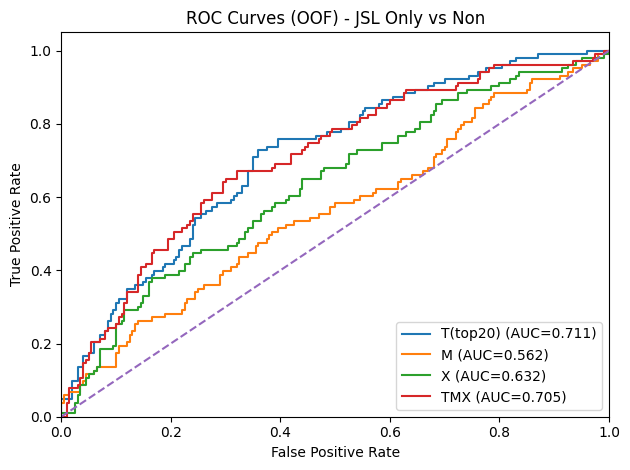


===== TASK: Pain Only vs Non =====
Positive=1: Pain Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]   class_weights=[0.7575000000000001, 1.470873786407767]
T features used (pre-topk): 61   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=303 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)
[Fold 1] top-20 tabular feats: ['Biomediq_V00LateralMeniscus', 'Labcorp_V00Serum_CPII_lc', 'Boneshape_V00nPatellaOAVector', 'V00AGE', 'Boneshape_V00nTibiaOAVector', 'Labcorp_V00Serum_CTXI_lc', 'Labcorp_V00Serum_Comp_lc', 'Labcorp_V00Serum_COLL2_1_NO2_lc', 'V00MCMJSW', 'Biomediq_V00MedialFemoralCartilage'] ...
[Fold 2] top-20 tabular feats: ['Labcorp_V00Serum_CPII_lc', 'Labcorp_V00Serum_PIIANP_lc', 'Labcorp_V00Urine_Col21N2CV', 'Labcorp_V00Serum_Comp_lc', 'Labcorp_V00Serum_MMP_3_lc', 'Labcorp_V00Urine_NTXI_lc', 'Labcorp_V00Serum_COLL2_1_NO2_lc', 'Labcorp_V00Serum_C1_2C_lc', 'Labcorp_V00Urine_Cre

C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

                      precision    recall  f1-score   support

      Non Progressor       0.00      0.00      0.00       200
Pain Only Progressor       0.34      1.00      0.51       103

            accuracy                           0.34       303
           macro avg       0.17      0.50      0.25       303
        weighted avg       0.12      0.34      0.17       303


== XRAY Embedding Expert (PCA+LR) ==
{'AUC': 0.43961165048543693, 'AP': 0.3013748436114721, 'BalAcc@0.5': 0.4818203883495146, 'F1@0.5': 0.3466666666666667, 't*_BalAcc': 0.01, 'BalAcc@t*': 0.49779126213592234, 'F1@t*': 0.5037406483790524}

Confusion @0.5:
[[117  83]
 [ 64  39]]

Report @0.5:
                      precision    recall  f1-score   support

      Non Progressor       0.65      0.58      0.61       200
Pain Only Progressor       0.32      0.38      0.35       103

            accuracy                           0.51       303
           macro avg       0.48      0.48      0.48       303
        weighted avg

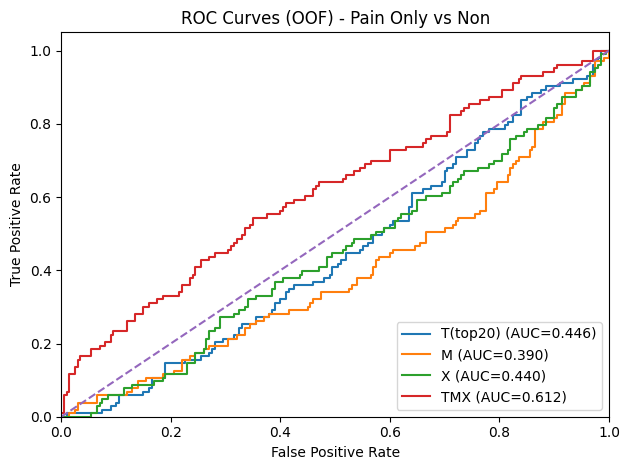

In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

TOP_K_TAB = 20           # <- train tabular expert using top-20 features per fold
PCA_DIM_EMB = 64         # <- PCA for embedding experts (auto-clipped if too large)


# -------------------------
# Tabular features (T) = BASE + BoneShape + Biomediq + Biomarkers
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

FEATS_T = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit

def plot_roc_curves(title, y, probs_dict, save_path=None):
    plt.figure()
    for name, prob in probs_dict.items():
        fpr, tpr, _ = roc_curve(y, prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


# -------------------------
# Build Tabular T
# -------------------------
def build_tabular_T(df, y):
    cols = [c for c in FEATS_T if c in df.columns]
    missing = sorted(set(FEATS_T) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS_T if c in X.columns]

    # Convert non-cat object columns like "<0.5" or ">2.3" to numeric + flags
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    # Ensure cat columns are strings for CatBoost
    for c in cat_cols:
        X[c] = X[c].astype(str)

    # Class weights (balanced)
    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing


# -------------------------
# OOF Experts
# -------------------------
def oof_embedding_expert(E, y, pca_dim=PCA_DIM_EMB):
    # Guard: PCA components cannot exceed (#features - 1) in many settings
    if E.shape[1] <= 1:
        pca_dim_eff = 1
    else:
        pca_dim_eff = int(min(pca_dim, E.shape[1] - 1))

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim_eff, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_tabular_catboost_topk(X_tab, y, cat_cols, class_weights, top_k=TOP_K_TAB):
    """
    Leakage-safe top-k:
      Each fold:
        - fit CatBoost on TRAIN with all tabular features
        - compute TRAIN feature importance
        - pick top-k on TRAIN only
        - refit CatBoost on TRAIN using only top-k
        - predict TEST
    Returns:
      - p_oof: OOF probs for the top-k tabular model
      - imp_df: mean importance across folds for reporting
      - topk_global: global top-k (mean importance)
    """
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    imp_accum = np.zeros(X_tab.shape[1], dtype=float)
    cat_cols = [c for c in cat_cols if c in X_tab.columns]

    for fold, (tr, te) in enumerate(skf.split(X_tab, y), start=1):
        Xtr, Xte = X_tab.iloc[tr].copy(), X_tab.iloc[te].copy()
        ytr = y[tr]

        # Base model on all features
        cat_idx_all = [Xtr.columns.get_loc(c) for c in cat_cols]
        base = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        base.fit(Xtr, ytr, cat_features=cat_idx_all)

        # Importance on training fold
        imp = np.array(base.get_feature_importance(), dtype=float)
        imp_accum += imp

        # Fold-specific top-k
        top_idx = np.argsort(imp)[::-1][:top_k]
        top_feats = Xtr.columns[top_idx].tolist()

        # Refit using fold-specific top-k
        Xtr_k = Xtr[top_feats]
        Xte_k = Xte[top_feats]
        cat_cols_k = [c for c in cat_cols if c in top_feats]
        cat_idx_k = [Xtr_k.columns.get_loc(c) for c in cat_cols_k]

        model_k = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        model_k.fit(Xtr_k, ytr, cat_features=cat_idx_k)
        p[te] = model_k.predict_proba(Xte_k)[:, 1]

        print(f"[Fold {fold}] top-{top_k} tabular feats: {top_feats[:10]}{' ...' if len(top_feats) > 10 else ''}")

    imp_mean = imp_accum / N_SPLITS
    imp_df = pd.DataFrame({"feature": X_tab.columns, "importance_mean": imp_mean})
    imp_df = imp_df.sort_values("importance_mean", ascending=False).reset_index(drop=True)
    topk_global = imp_df["feature"].head(top_k).tolist()

    return p, imp_df, topk_global

def oof_stack_tmx(p_t, p_m, p_x, y):
    Z = np.vstack([p_t, p_m, p_x]).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack


# -------------------------
# Reporting
# -------------------------
def report(name, y, prob, neg_name, pos_name):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t  = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


# -------------------------
# Task runner
# -------------------------
def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column for alignment with embeddings.")
    ids = df["ID"].astype(str).tolist()

    # Build T (tabular with biomarkers)
    X_t, cat_cols, class_weights, missing_cols = build_tabular_T(df, y)

    # Build M and X matrices
    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"T features used (pre-topk): {X_t.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns (not found in CSV): {missing_cols}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    # --- OOF experts ---
    # Tabular: compute importance + train on top-20 per fold (leakage-safe)
    p_t, imp_df, topk_global = oof_tabular_catboost_topk(
        X_t, y, cat_cols, class_weights, top_k=TOP_K_TAB
    )

    print(f"\nTop-{TOP_K_TAB} tabular features by mean CV importance:")
    print(imp_df.head(TOP_K_TAB).to_string(index=False))

    # Embedding experts
    p_m = oof_embedding_expert(E_m, y, pca_dim=PCA_DIM_EMB)
    p_x = oof_embedding_expert(E_x, y, pca_dim=PCA_DIM_EMB)

    # Late fusion ONLY: T(topk) + M + X
    p_tmx = oof_stack_tmx(p_t, p_m, p_x, y)

    # Report late fusion
    report(
        name=f"Late fusion Stack (T(top{TOP_K_TAB})+M+X)",
        y=y,
        prob=p_tmx,
        neg_name=neg_class,
        pos_name=pos_class
    )

    # Also report each component (optional, but helps interpret)
    report(
        name=f"Tabular CatBoost (top{TOP_K_TAB})",
        y=y,
        prob=p_t,
        neg_name=neg_class,
        pos_name=pos_class
    )
    report(
        name="MRI Embedding Expert (PCA+LR)",
        y=y,
        prob=p_m,
        neg_name=neg_class,
        pos_name=pos_class
    )
    report(
        name="XRAY Embedding Expert (PCA+LR)",
        y=y,
        prob=p_x,
        neg_name=neg_class,
        pos_name=pos_class
    )

    # --- ROC plots (OOF) ---
    plot_roc_curves(
        title=f"ROC Curves (OOF) - {task_name}",
        y=y,
        probs_dict={
            f"T(top{TOP_K_TAB})": p_t,
            "M": p_m,
            "X": p_x,
            "TMX": p_tmx
        },
        save_path=None  # or f"roc_{task_name.replace(' ','_')}.png"
    )


# -------------------------
# Main
# -------------------------
def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()


In [ ]:
#contribution of features and modalities

Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]   class_weights=[0.7575000000000001, 1.470873786407767]
T features used (pre-topk): 61   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=303 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)
[Fold 1] top-20 tabular feats: ['Biomediq_V00MedialMeniscus', 'Labcorp_V00Serum_COLL2_1_NO2_lc', 'Biomediq_V00LateralFemoralCartilage', 'Labcorp_V00Serum_Comp_lc', 'Labcorp_V00Serum_PIIANP_lc', 'Boneshape_V00nTibiaOAVector', 'Boneshape_V00nPatellaOAVector', 'Biomediq_V00LateralTibialCartilage', 'Boneshape_V00notch', 'V00MCMJSW'] ...
[Fold 2] top-20 tabular feats: ['Biomediq_V00MedialMeniscus', 'V00AGE', 'Labcorp_V00Serum_Comp_lc', 'Labcorp_V00Serum_PIIANP_lc', 'Labcorp_V00Serum_COLL2_1_NO2_lc', 'Biomediq_V00LateralFemoralCartilage', 'Lab

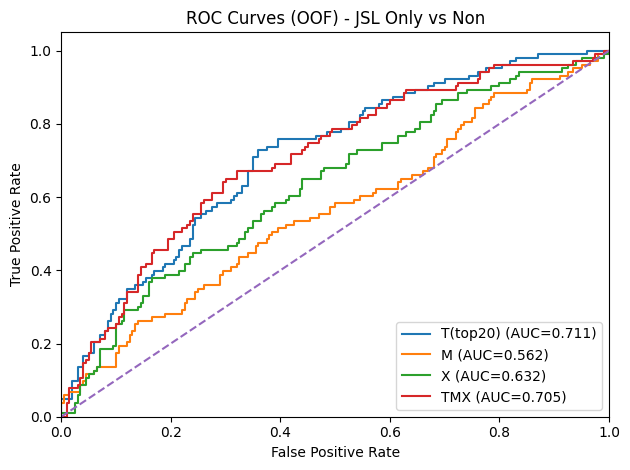


OOF prediction correlation (redundancy indicator):
       T      M      X
T  1.000  0.231  0.205
M  0.231  1.000  0.350
X  0.205  0.350  1.000

=== Modality Ablation (OOF stack) ===
Model      AUC       AP
  T+X 0.708544 0.527715
T+M+X 0.705291 0.526585
    T 0.697864 0.519783
  T+M 0.689223 0.509094
    X 0.627961 0.454194
  M+X 0.623107 0.452030
    M 0.552087 0.408813

Conditional marginal ΔAUC:
ΔAUC(T | M,X) = 0.0822
ΔAUC(M | T,X) = -0.0033
ΔAUC(X | T,M) = 0.0161


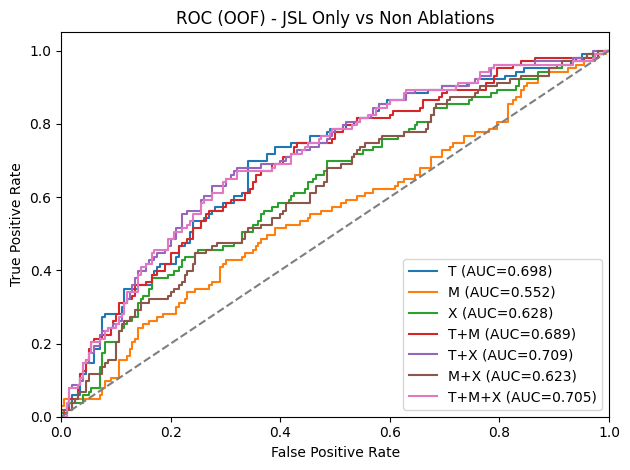


===== TASK: Pain Only vs Non =====
Positive=1: Pain Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]   class_weights=[0.7575000000000001, 1.470873786407767]
T features used (pre-topk): 61   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=303 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)
[Fold 1] top-20 tabular feats: ['Biomediq_V00LateralMeniscus', 'Labcorp_V00Serum_CPII_lc', 'Boneshape_V00nPatellaOAVector', 'V00AGE', 'Boneshape_V00nTibiaOAVector', 'Labcorp_V00Serum_CTXI_lc', 'Labcorp_V00Serum_Comp_lc', 'Labcorp_V00Serum_COLL2_1_NO2_lc', 'V00MCMJSW', 'Biomediq_V00MedialFemoralCartilage'] ...
[Fold 2] top-20 tabular feats: ['Labcorp_V00Serum_CPII_lc', 'Labcorp_V00Serum_PIIANP_lc', 'Labcorp_V00Urine_Col21N2CV', 'Labcorp_V00Serum_Comp_lc', 'Labcorp_V00Serum_MMP_3_lc', 'Labcorp_V00Urine_NTXI_lc', 'Labcorp_V00Serum_COLL2_1_NO2_lc', 'Labcorp_V00Serum_C1_2C_lc', 'Labcorp_V00Urine_Cre

C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


== Late fusion Stack (T(top20)+M+X) ==
{'AUC': 0.6124271844660195, 'AP': 0.48462402958307516, 'BalAcc@0.5': 0.5816990291262136, 'F1@0.5': 0.4789915966386555, 't*_BalAcc': 0.51, 'BalAcc@t*': 0.591990291262136, 'F1@t*': 0.4824561403508772}

Confusion @0.5:
[[122  78]
 [ 46  57]]

Report @0.5:
                      precision    recall  f1-score   support

      Non Progressor       0.73      0.61      0.66       200
Pain Only Progressor       0.42      0.55      0.48       103

            accuracy                           0.59       303
           macro avg       0.57      0.58      0.57       303
        weighted avg       0.62      0.59      0.60       303


Confusion @t* (t*=0.51, best BalAcc=0.5920):
[[130  70]
 [ 48  55]]

Report @t*:
                      precision    recall  f1-score   support

      Non Progressor       0.73      0.65      0.69       200
Pain Only Progressor       0.44      0.53      0.48       103

            accuracy                           0.61       303


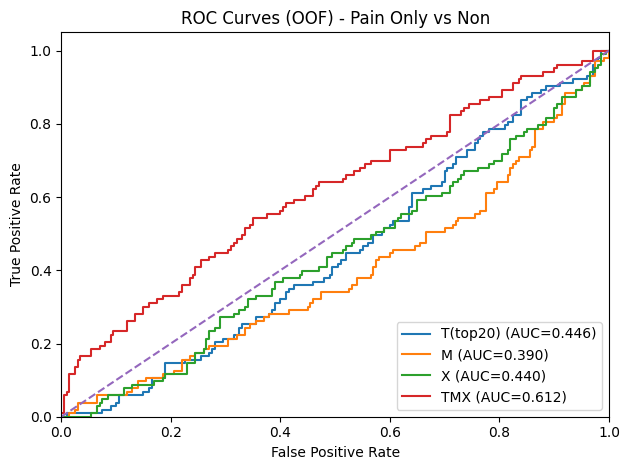


OOF prediction correlation (redundancy indicator):
       T      M      X
T  1.000  0.035  0.140
M  0.035  1.000  0.071
X  0.140  0.071  1.000

=== Modality Ablation (OOF stack) ===
Model      AUC       AP
  T+M 0.619126 0.459788
  M+X 0.613641 0.457375
T+M+X 0.612427 0.484624
    M 0.609029 0.433638
  T+X 0.578301 0.430554
    T 0.554369 0.367175
    X 0.548058 0.403078

Conditional marginal ΔAUC:
ΔAUC(T | M,X) = -0.0012
ΔAUC(M | T,X) = 0.0341
ΔAUC(X | T,M) = -0.0067


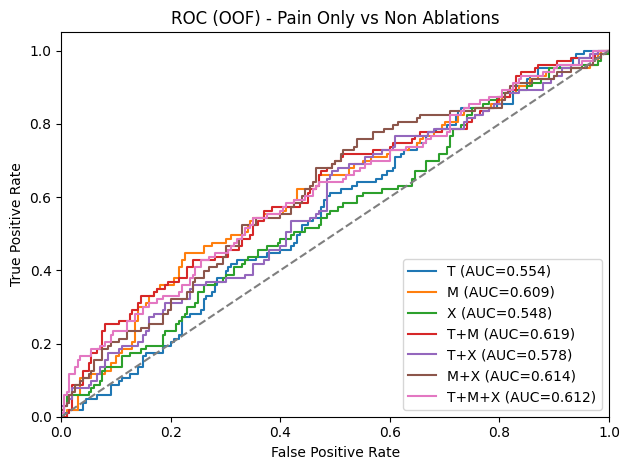

In [3]:
import os
import re
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

TOP_K_TAB = 20           # Train tabular expert on top-K features per fold
PCA_DIM_EMB = 64         # PCA dim for embedding experts (auto-clipped)


# -------------------------
# Tabular features (T) = BASE + BoneShape + Biomediq + Biomarkers
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

FEATS_T = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit

def plot_roc_curves(title, y, probs_dict, save_path=None):
    plt.figure()
    for name, prob in probs_dict.items():
        fpr, tpr, _ = roc_curve(y, prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


# -------------------------
# Build Tabular T
# -------------------------
def build_tabular_T(df, y):
    cols = [c for c in FEATS_T if c in df.columns]
    missing = sorted(set(FEATS_T) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS_T if c in X.columns]

    # Convert non-cat object columns like "<0.5" or ">2.3" to numeric + flags
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    # Ensure cat columns are strings for CatBoost
    for c in cat_cols:
        X[c] = X[c].astype(str)

    # Class weights (balanced)
    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing


# -------------------------
# OOF Experts
# -------------------------
def oof_embedding_expert(E, y, pca_dim=PCA_DIM_EMB):
    if E.shape[1] <= 1:
        pca_dim_eff = 1
    else:
        pca_dim_eff = int(min(pca_dim, E.shape[1] - 1))

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim_eff, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_tabular_catboost_topk(X_tab, y, cat_cols, class_weights, top_k=TOP_K_TAB):
    """
    Leakage-safe top-k:
      Each fold:
        - fit CatBoost on TRAIN with all tabular features
        - compute TRAIN feature importance
        - pick top-k on TRAIN only
        - refit CatBoost on TRAIN using only top-k
        - predict TEST
    Returns:
      - p_oof: OOF probs for the top-k tabular model
      - imp_df: mean importance across folds for reporting
      - topk_global: global top-k (mean importance)
    """
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    imp_accum = np.zeros(X_tab.shape[1], dtype=float)
    cat_cols = [c for c in cat_cols if c in X_tab.columns]

    for fold, (tr, te) in enumerate(skf.split(X_tab, y), start=1):
        Xtr, Xte = X_tab.iloc[tr].copy(), X_tab.iloc[te].copy()
        ytr = y[tr]

        # Base model on all features
        cat_idx_all = [Xtr.columns.get_loc(c) for c in cat_cols]
        base = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        base.fit(Xtr, ytr, cat_features=cat_idx_all)

        # Importance on training fold
        imp = np.array(base.get_feature_importance(), dtype=float)
        imp_accum += imp

        # Fold-specific top-k
        top_idx = np.argsort(imp)[::-1][:top_k]
        top_feats = Xtr.columns[top_idx].tolist()

        # Refit using fold-specific top-k
        Xtr_k = Xtr[top_feats]
        Xte_k = Xte[top_feats]
        cat_cols_k = [c for c in cat_cols if c in top_feats]
        cat_idx_k = [Xtr_k.columns.get_loc(c) for c in cat_cols_k]

        model_k = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        model_k.fit(Xtr_k, ytr, cat_features=cat_idx_k)
        p[te] = model_k.predict_proba(Xte_k)[:, 1]

        print(f"[Fold {fold}] top-{top_k} tabular feats: {top_feats[:10]}{' ...' if len(top_feats) > 10 else ''}")

    imp_mean = imp_accum / N_SPLITS
    imp_df = pd.DataFrame({"feature": X_tab.columns, "importance_mean": imp_mean})
    imp_df = imp_df.sort_values("importance_mean", ascending=False).reset_index(drop=True)
    topk_global = imp_df["feature"].head(top_k).tolist()

    return p, imp_df, topk_global

def oof_stack(Z, y):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p[te] = meta.predict_proba(Z[te])[:, 1]
    return p

def oof_stack_tmx(p_t, p_m, p_x, y):
    Z = np.vstack([p_t, p_m, p_x]).T
    return oof_stack(Z, y)

def prediction_redundancy(p_t, p_m, p_x):
    dfp = pd.DataFrame({"T": p_t, "M": p_m, "X": p_x})
    print("\nOOF prediction correlation (redundancy indicator):")
    print(dfp.corr().round(3))

def modality_ablation_report(y, p_t, p_m, p_x, title_prefix=""):
    variants = {
        "T": np.vstack([p_t]).T,
        "M": np.vstack([p_m]).T,
        "X": np.vstack([p_x]).T,
        "T+M": np.vstack([p_t, p_m]).T,
        "T+X": np.vstack([p_t, p_x]).T,
        "M+X": np.vstack([p_m, p_x]).T,
        "T+M+X": np.vstack([p_t, p_m, p_x]).T,
    }

    rows = []
    probs_for_plot = {}
    for name, Z in variants.items():
        p = oof_stack(Z, y)
        a = roc_auc_score(y, p)
        ap = average_precision_score(y, p)
        rows.append((name, a, ap))
        probs_for_plot[name] = p

    res = pd.DataFrame(rows, columns=["Model", "AUC", "AP"]).sort_values("AUC", ascending=False)
    print("\n=== Modality Ablation (OOF stack) ===")
    print(res.to_string(index=False))

    # Conditional marginal contributions
    auc_dict = {m: a for m, a, _ in rows}
    print("\nConditional marginal ΔAUC:")
    print(f"ΔAUC(T | M,X) = {auc_dict['T+M+X'] - auc_dict['M+X']:.4f}")
    print(f"ΔAUC(M | T,X) = {auc_dict['T+M+X'] - auc_dict['T+X']:.4f}")
    print(f"ΔAUC(X | T,M) = {auc_dict['T+M+X'] - auc_dict['T+M']:.4f}")

    plot_roc_curves(
        title=f"ROC (OOF) - {title_prefix} Ablations",
        y=y,
        probs_dict=probs_for_plot
    )


# -------------------------
# Reporting
# -------------------------
def report(name, y, prob, neg_name, pos_name):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t  = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


# -------------------------
# Task runner
# -------------------------
def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column for alignment with embeddings.")
    ids = df["ID"].astype(str).tolist()

    # Build T (tabular with biomarkers)
    X_t, cat_cols, class_weights, missing_cols = build_tabular_T(df, y)

    # Build M and X matrices
    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"T features used (pre-topk): {X_t.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns (not found in CSV): {missing_cols}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    # --- OOF experts ---
    # Tabular: compute importance + train on top-K per fold (leakage-safe)
    p_t, imp_df, topk_global = oof_tabular_catboost_topk(
        X_t, y, cat_cols, class_weights, top_k=TOP_K_TAB
    )

    print(f"\nTop-{TOP_K_TAB} tabular features by mean CV importance:")
    print(imp_df.head(TOP_K_TAB).to_string(index=False))

    # Embedding experts
    p_m = oof_embedding_expert(E_m, y, pca_dim=PCA_DIM_EMB)
    p_x = oof_embedding_expert(E_x, y, pca_dim=PCA_DIM_EMB)

    # Late fusion ONLY: T(topk) + M + X
    p_tmx = oof_stack_tmx(p_t, p_m, p_x, y)

    # --- Metrics for each component + fusion ---
    report(name=f"Tabular CatBoost (top{TOP_K_TAB})", y=y, prob=p_t, neg_name=neg_class, pos_name=pos_class)
    report(name="MRI Embedding Expert (PCA+LR)", y=y, prob=p_m, neg_name=neg_class, pos_name=pos_class)
    report(name="XRAY Embedding Expert (PCA+LR)", y=y, prob=p_x, neg_name=neg_class, pos_name=pos_class)
    report(name=f"Late fusion Stack (T(top{TOP_K_TAB})+M+X)", y=y, prob=p_tmx, neg_name=neg_class, pos_name=pos_class)

    # --- ROC plot for components + final fusion ---
    plot_roc_curves(
        title=f"ROC Curves (OOF) - {task_name}",
        y=y,
        probs_dict={
            f"T(top{TOP_K_TAB})": p_t,
            "M": p_m,
            "X": p_x,
            "TMX": p_tmx
        }
    )

    # --- Contribution analysis: redundancy + ablations ---
    prediction_redundancy(p_t, p_m, p_x)
    modality_ablation_report(y, p_t, p_m, p_x, title_prefix=task_name)


# -------------------------
# Main
# -------------------------
def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()


In [ ]:
#shap

In [5]:
def shapley_from_ablation_auc(auc_dict):
    """
    Compute modality Shapley values for 3 modalities {T, M, X} using AUC as the value function.
    Requires AUCs for all subsets:
      "T","M","X","T+M","T+X","M+X","T+M+X"
    Optionally "∅" (empty) can be provided; if missing, it is assumed 0.5 (random).
    Returns a DataFrame with Shapley(AUC) and normalized proportions.
    """
    required = ["T", "M", "X", "T+M", "T+X", "M+X", "T+M+X"]
    missing = [k for k in required if k not in auc_dict]
    if missing:
        raise ValueError(f"Missing keys in auc_dict: {missing}")

    v0 = auc_dict.get("∅", 0.5)  # baseline for binary AUC (random classifier)

    vT = auc_dict["T"]
    vM = auc_dict["M"]
    vX = auc_dict["X"]
    vTM = auc_dict["T+M"]
    vTX = auc_dict["T+X"]
    vMX = auc_dict["M+X"]
    vTMX = auc_dict["T+M+X"]

    # Shapley values for 3 players (closed-form)
    phi_T = (1/3)*(vT - v0) + (1/6)*(vTM - vM) + (1/6)*(vTX - vX) + (1/3)*(vTMX - vMX)
    phi_M = (1/3)*(vM - v0) + (1/6)*(vTM - vT) + (1/6)*(vMX - vX) + (1/3)*(vTMX - vTX)
    phi_X = (1/3)*(vX - v0) + (1/6)*(vTX - vT) + (1/6)*(vMX - vM) + (1/3)*(vTMX - vTM)

    shap = np.array([phi_T, phi_M, phi_X], dtype=float)

    # Proportions: by absolute shap (handles negatives) and by positive-only (if any)
    abs_sum = np.sum(np.abs(shap))
    prop_abs = np.abs(shap) / abs_sum if abs_sum > 0 else np.array([np.nan, np.nan, np.nan])

    pos = np.clip(shap, 0, None)
    pos_sum = pos.sum()
    prop_pos = pos / pos_sum if pos_sum > 0 else np.array([np.nan, np.nan, np.nan])

    df = pd.DataFrame({
        "Modality": ["T", "M", "X"],
        "Shapley_AUC": shap,
        "Prop_abs": prop_abs,
        "Prop_pos": prop_pos
    })

    # Sanity check: efficiency (sum of Shapley equals v(TMX)-v0)
    df.attrs["baseline_v0"] = v0
    df.attrs["total_gain"] = vTMX - v0
    df.attrs["sum_shapley"] = float(shap.sum())

    return df


In [7]:
auc_dict = {
    "T": 0.697864,
    "M": 0.552087,
    "X": 0.627961,
    "T+M": 0.689223,
    "T+X": 0.708544,
    "M+X": 0.623107,
    "T+M+X": 0.705291,
    "∅": 0.5
}

shap_df = shapley_from_ablation_auc(auc_dict)
print(shap_df)

print("\nBaseline v0 =", shap_df.attrs["baseline_v0"])
print("Total gain v(TMX)-v0 =", shap_df.attrs["total_gain"])
print("Sum Shapley =", shap_df.attrs["sum_shapley"])


  Modality  Shapley_AUC  Prop_abs  Prop_pos
0        T     0.129636  0.631474  0.631474
1        M     0.014029  0.068336  0.068336
2        X     0.061626  0.300190  0.300190

Baseline v0 = 0.5
Total gain v(TMX)-v0 = 0.205291
Sum Shapley = 0.205291


In [ ]:
#demographic + xray

In [73]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

# Features: demographics + baseline X-ray
FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

# Label mapping
PROGRESSOR = {"JSL Only Progressor", "JSL and Pain Progressor", "Pain Only Progressor"}
NONPROG = {"Non Progressor"}


def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s


def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan


# Censored numeric strings like "< 0.06" or "> 10"
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")


def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))

        out[c] = base.astype("float32")
        # optional indicator flags (harmless if never used)
        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out


def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)


# -------------------------
# Load + build X/y
# -------------------------
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

# Keep only desired features that exist
cols = [c for c in FEATS if c in df.columns]
X = df[cols].copy()
X = X.loc[:, ~X.columns.duplicated()].copy()

# Categorical columns for this experiment
cat_cols = [c for c in ["P02SEX", "P02RACE", "P02HISP"] if c in X.columns]

# Clean censored numeric strings on non-categorical object columns
obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
X = coerce_censored_numeric(X, obj_cols)

# Ensure categoricals are strings for CatBoost
for c in cat_cols:
    X[c] = X[c].astype(str)

cat_idx = [X.columns.get_loc(c) for c in cat_cols]

# Class weights (same scheme you used before)
neg, pos = np.bincount(y)  # neg=0, pos=1 counts
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]

print(f"Rows: {len(X)}")
print(f"Features used ({X.shape[1]}): {list(X.columns)}")
print(f"Class counts [0,1]: {np.bincount(y)}  class_weights: {class_weights}")
print(f"Categoricals: {cat_cols}")

# -------------------------
# 5-fold OOF CV (CatBoost)
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob = np.zeros(len(X), dtype=float)

for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=4000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=42,
        class_weights=class_weights,
        verbose=0,
    )
    model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
    oof_prob[te] = model.predict_proba(X.iloc[te])[:, 1]

# -------------------------
# Metrics @0.5 and @best BalAcc threshold
# -------------------------
t_best, bal_best = pick_best_balacc_threshold(y, oof_prob)
pred05 = (oof_prob >= 0.5).astype(int)
pred_t = (oof_prob >= t_best).astype(int)

out = {
    "AUC": roc_auc_score(y, oof_prob),
    "AP": average_precision_score(y, oof_prob),
    "BalAcc@0.5": balanced_accuracy_score(y, pred05),
    "F1@0.5": f1_score(y, pred05),
    "t*_BalAcc": t_best,
    "BalAcc@t*": balanced_accuracy_score(y, pred_t),
    "F1@t*": f1_score(y, pred_t),
}

print("\n==== Demographics + Baseline X-ray (OOF CV) ====")
print(out)

print("\nConfusion @0.5:")
print(confusion_matrix(y, pred05))
print("\nReport @0.5:")
print(classification_report(y, pred05, target_names=["Non-Progressor", "Progressor"]))

print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
print(confusion_matrix(y, pred_t))
print("\nReport @t*:")
print(classification_report(y, pred_t, target_names=["Non-Progressor", "Progressor"]))


Rows: 600
Features used (8): ['V00AGE', 'P02SEX', 'P02RACE', 'P02HISP', 'V00XRKL', 'V00XRJSM', 'V00XRJSL', 'V00MCMJSW']
Class counts [0,1]: [200 400]  class_weights: [1.5, 0.75]
Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']

==== Demographics + Baseline X-ray (OOF CV) ====
{'AUC': 0.532775, 'AP': 0.6989975921417741, 'BalAcc@0.5': 0.51125, 'F1@0.5': 0.7040572792362768, 't*_BalAcc': 0.7000000000000001, 'BalAcc@t*': 0.5375, 'F1@t*': 0.6631853785900783}

Confusion @0.5:
[[ 57 143]
 [105 295]]

Report @0.5:
                precision    recall  f1-score   support

Non-Progressor       0.35      0.28      0.31       200
    Progressor       0.67      0.74      0.70       400

      accuracy                           0.59       600
     macro avg       0.51      0.51      0.51       600
  weighted avg       0.57      0.59      0.57       600


Confusion @t* (t*=0.70, best BalAcc=0.5375):
[[ 88 112]
 [146 254]]

Report @t*:
                precision    recall  f1-score   support

Non-Progresso

In [ ]:
#demographic + MRI V00MCMJSW

In [75]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score, confusion_matrix
)
from catboost import CatBoostClassifier


CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

# -------------------------
# Label mapping
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor", "JSL and Pain Progressor", "Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan


# -------------------------
# Censored numeric cleaning (handles "< 0.06" or "> 1.2")
# -------------------------
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)
        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        # optional indicators (usually harmless)
        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out


# -------------------------
# Load
# -------------------------
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

print("Rows:", len(df))
print("Class counts [0,1]:", np.bincount(y))

# class weights (inverse freq normalized)
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]
print("class_weights:", class_weights)

# -------------------------
# Features: demographics + MRI V00MCMJSW
# -------------------------
FEATURES = ["V00AGE", "P02SEX", "P02RACE", "P02HISP", "V00MCMJSW"]

# keep only existing columns
FEATURES = [c for c in FEATURES if c in df.columns]
missing = sorted(set(["V00AGE","P02SEX","P02RACE","P02HISP","V00MCMJSW"]) - set(FEATURES))
if missing:
    print("WARNING missing features:", missing)

X = df[FEATURES].copy()
X = X.loc[:, ~X.columns.duplicated()].copy()

# categoricals
cat_cols = [c for c in ["P02SEX", "P02RACE", "P02HISP"] if c in X.columns]

# clean censored numeric on object columns that are NOT categorical
obj_num_cols = [c for c in X.columns if str(X[c].dtype) == "object" and c not in cat_cols]
if obj_num_cols:
    X = coerce_censored_numeric(X, obj_num_cols)

# ensure numeric types for numeric cols
for c in ["V00AGE", "V00MCMJSW"]:
    if c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")

# ensure categoricals are strings
for c in cat_cols:
    X[c] = X[c].astype(str)

cat_idx = [X.columns.get_loc(c) for c in cat_cols]

print("Used features:", list(X.columns))
print("Categoricals:", cat_cols)

# -------------------------
# 5-fold CV (OOF)
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob = np.zeros(len(X), dtype=float)

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=4000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=42,
        class_weights=class_weights,
        verbose=0
    )
    model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
    oof_prob[te] = model.predict_proba(X.iloc[te])[:, 1]

pred05 = (oof_prob >= 0.5).astype(int)

metrics = {
    "AUC": roc_auc_score(y, oof_prob),
    "AP": average_precision_score(y, oof_prob),
    "BalAcc@0.5": balanced_accuracy_score(y, pred05),
    "F1@0.5": f1_score(y, pred05),
}
print("\n== Demographics + V00MCMJSW (OOF 5-fold) ==")
print(metrics)
print("Confusion @0.5:\n", confusion_matrix(y, pred05))


Rows: 600
Class counts [0,1]: [200 400]
class_weights: [1.5, 0.75]
Used features: ['V00AGE', 'P02SEX', 'P02RACE', 'P02HISP', 'V00MCMJSW']
Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']

== Demographics + V00MCMJSW (OOF 5-fold) ==
{'AUC': 0.53401875, 'AP': 0.7059713430176668, 'BalAcc@0.5': 0.52625, 'F1@0.5': 0.7046004842615012}
Confusion @0.5:
 [[ 65 135]
 [109 291]]


In [ ]:
#demographic + MRI more features

In [77]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score, confusion_matrix
)
from catboost import CatBoostClassifier


CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"

# -------------------------
# Label mapping
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor", "JSL and Pain Progressor", "Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan


# -------------------------
# Censored numeric cleaning (handles "< 0.06" or "> 1.2")
# -------------------------
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)
        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out


# -------------------------
# Load
# -------------------------
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

print("Rows:", len(df))
print("Class counts [0,1]:", np.bincount(y))

# class weights (inverse freq normalized)
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]
print("class_weights:", class_weights)


# -------------------------
# Features: demographics + V00MCMJSW + bone shape + biomediq morph
# -------------------------
DEMOGRAPHICS = ["V00AGE", "P02SEX", "P02RACE", "P02HISP"]
MRI_JSW = ["V00MCMJSW"]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

FEATURES = DEMOGRAPHICS + MRI_JSW + BONE_SHAPE + BIOMEDIQ

# keep only existing columns
FEATURES = [c for c in FEATURES if c in df.columns]
missing = sorted(set(DEMOGRAPHICS + MRI_JSW + BONE_SHAPE + BIOMEDIQ) - set(FEATURES))
if missing:
    print("WARNING missing features:", missing)

X = df[FEATURES].copy()
X = X.loc[:, ~X.columns.duplicated()].copy()

# categoricals: only the demographic categorical ones here
cat_cols = [c for c in ["P02SEX", "P02RACE", "P02HISP"] if c in X.columns]

# clean censored numeric on object columns that are NOT categorical
obj_num_cols = [c for c in X.columns if str(X[c].dtype) == "object" and c not in cat_cols]
if obj_num_cols:
    X = coerce_censored_numeric(X, obj_num_cols)

# enforce numeric where expected
numeric_expected = [c for c in X.columns if c not in cat_cols]
for c in numeric_expected:
    X[c] = pd.to_numeric(X[c], errors="coerce").astype("float32")

# ensure categoricals are strings
for c in cat_cols:
    X[c] = X[c].astype(str)

cat_idx = [X.columns.get_loc(c) for c in cat_cols]

print("Used features:", len(X.columns))
print("Categoricals:", cat_cols)


# -------------------------
# 5-fold CV (OOF)
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_prob = np.zeros(len(X), dtype=float)

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=4000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=42,
        class_weights=class_weights,
        verbose=0
    )
    model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
    oof_prob[te] = model.predict_proba(X.iloc[te])[:, 1]

pred05 = (oof_prob >= 0.5).astype(int)

metrics = {
    "AUC": roc_auc_score(y, oof_prob),
    "AP": average_precision_score(y, oof_prob),
    "BalAcc@0.5": balanced_accuracy_score(y, pred05),
    "F1@0.5": f1_score(y, pred05),
}
print("\n== Demographics + V00MCMJSW + BoneShape + Biomediq (OOF 5-fold) ==")
print(metrics)
print("Confusion @0.5:\n", confusion_matrix(y, pred05))


Rows: 600
Class counts [0,1]: [200 400]
class_weights: [1.5, 0.75]
Used features: 24
Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']

== Demographics + V00MCMJSW + BoneShape + Biomediq (OOF 5-fold) ==
{'AUC': 0.5737, 'AP': 0.7274723625484626, 'BalAcc@0.5': 0.53125, 'F1@0.5': 0.7387802071346375}
Confusion @0.5:
 [[ 52 148]
 [ 79 321]]


In [ ]:
#demographic + bio

In [79]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score, confusion_matrix
)
from catboost import CatBoostClassifier

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42

# -------------------------
# Label mapping
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor", "JSL and Pain Progressor", "Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan

# -------------------------
# Handle censored numeric strings like "< 0.06" or "> 1.2"
# -------------------------
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)

        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))

        out[c] = base.astype("float32")

        # Optional: indicator flags (helps sometimes)
        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

# -------------------------
# Features: demographics + selected Labcorp biomarkers
# -------------------------
demographic = ["V00AGE", "P02SEX", "P02RACE", "P02HISP"]

biomarkers = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

FEATURES = demographic + biomarkers

# Which are categorical?
CAT_COLS = ["P02SEX", "P02RACE", "P02HISP"]  # keep as strings for CatBoost

# -------------------------
# Load data
# -------------------------
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

print(f"Rows: {len(df)} Class counts [0,1]: {np.bincount(y)}")

# Class weights (inverse-freq normalized like your earlier runs)
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]
print("class_weights:", class_weights)

# -------------------------
# Build X with only requested features
# -------------------------
cols = [c for c in FEATURES if c in df.columns]
missing = sorted(set(FEATURES) - set(cols))
if missing:
    print("Missing columns (not found in CSV):", missing)

X = df[cols].copy()
X = X.loc[:, ~X.columns.duplicated()].copy()

# Identify categorical columns present
cat_cols = [c for c in CAT_COLS if c in X.columns]

# Coerce censored numeric strings on object columns that are NOT categorical
obj_cols = [c for c in X.columns if str(X[c].dtype) == "object" and c not in cat_cols]
X = coerce_censored_numeric(X, obj_cols)

# Ensure categoricals are strings
for c in cat_cols:
    X[c] = X[c].astype(str)

cat_idx = [X.columns.get_loc(c) for c in cat_cols]
print(f"Selected features: {X.shape[1]}  Categoricals: {cat_cols}")

# -------------------------
# 5-fold OOF evaluation (CatBoost)
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_prob = np.zeros(len(X), dtype=float)

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=5000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=SEED,
        class_weights=class_weights,
        verbose=0
    )
    model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
    oof_prob[te] = model.predict_proba(X.iloc[te])[:, 1]

pred05 = (oof_prob >= 0.5).astype(int)

metrics = {
    "AUC": roc_auc_score(y, oof_prob),
    "AP": average_precision_score(y, oof_prob),
    "BalAcc@0.5": balanced_accuracy_score(y, pred05),
    "F1@0.5": f1_score(y, pred05),
}
print("\n== Demographics + Biomarkers (OOF, 5-fold) ==")
print(metrics)
print("Confusion @0.5:\n", confusion_matrix(y, pred05))


Rows: 600 Class counts [0,1]: [200 400]
class_weights: [1.5, 0.75]
Selected features: 38  Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']

== Demographics + Biomarkers (OOF, 5-fold) ==
{'AUC': 0.5137999999999999, 'AP': 0.6893392100402143, 'BalAcc@0.5': 0.51625, 'F1@0.5': 0.7337142857142858}
Confusion @0.5:
 [[ 46 154]
 [ 79 321]]


In [ ]:
#demographic + bio (more)

In [81]:
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score, confusion_matrix
)
from catboost import CatBoostClassifier

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42

# -------------------------
# Label mapping
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor", "JSL and Pain Progressor", "Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan

# -------------------------
# Handle censored numeric strings like "< 0.06" or "> 1.2"
# -------------------------
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)

        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))

        out[c] = base.astype("float32")

        # Optional: indicator flags (helps sometimes)
        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

# -------------------------
# Features: demographics + Labcorp biomarkers (+ low-limit flags)
# -------------------------
demographic = ["V00AGE", "P02SEX", "P02RACE", "P02HISP"]

biomarkers = [
    # measured values
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

lowlim = [
    "Labcorp_V00Serum_C2C_lowlim",
    "Labcorp_V00Serum_COLL2_1_NO2_lowlim",
    "Labcorp_V00Serum_CPII_lowlim",
    "Labcorp_V00Serum_CS846_lowlim",
    "Labcorp_V00Serum_CTXI_lowlim",
    "Labcorp_V00Serum_Comp_lowlim",
    "Labcorp_V00Serum_HA_lowlim",
    "Labcorp_V00Serum_MMP_3_lowlim",
    "Labcorp_V00Serum_NTXI_lowlim",
    "Labcorp_V00Serum_PIIANP_lowlim",
    "Labcorp_V00Urine_CTXII_lowlim",
    "Labcorp_V00Urine_C1_2C_lowlim",
    "Labcorp_V00Urine_C2C_lowlim",
    "Labcorp_V00Urine_NTXI_lowlim",
    "Labcorp_V00Urine_alpha_lowlim",
    "Labcorp_V00Urine_beta_lowlim",
    "Labcorp_V00Urine_Col21N2_lowlim",
]

FEATURES = demographic + biomarkers + lowlim

# Which are categorical?
CAT_COLS = ["P02SEX", "P02RACE", "P02HISP"]  # keep as strings for CatBoost

# -------------------------
# Load data
# -------------------------
df = pd.read_csv(CSV_PATH)
df = df.loc[:, ~df.columns.duplicated()].copy()

df[TARGET] = df[TARGET].map(norm_label)
y_map = df[TARGET].map(map_binary)
df = df.loc[~y_map.isna()].copy()
y = y_map.loc[df.index].astype(int).values

print(f"Rows: {len(df)} Class counts [0,1]: {np.bincount(y)}")

# Class weights (inverse-freq normalized)
neg, pos = np.bincount(y)
w0 = 0.5 / (neg / (neg + pos))
w1 = 0.5 / (pos / (neg + pos))
class_weights = [float(w0), float(w1)]
print("class_weights:", class_weights)

# -------------------------
# Build X with only requested features
# -------------------------
cols = [c for c in FEATURES if c in df.columns]
missing = sorted(set(FEATURES) - set(cols))
if missing:
    print("Missing columns (not found in CSV):", missing)

X = df[cols].copy()
X = X.loc[:, ~X.columns.duplicated()].copy()

# Identify categorical columns present
cat_cols = [c for c in CAT_COLS if c in X.columns]

# Coerce censored numeric strings on object columns that are NOT categorical
obj_cols = [c for c in X.columns if str(X[c].dtype) == "object" and c not in cat_cols]
X = coerce_censored_numeric(X, obj_cols)

# Ensure categoricals are strings
for c in cat_cols:
    X[c] = X[c].astype(str)

cat_idx = [X.columns.get_loc(c) for c in cat_cols]
print(f"Selected features: {X.shape[1]}  Categoricals: {cat_cols}")

# -------------------------
# 5-fold OOF evaluation (CatBoost)
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_prob = np.zeros(len(X), dtype=float)

for fold, (tr, te) in enumerate(skf.split(X, y), 1):
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=5000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=SEED,
        class_weights=class_weights,
        verbose=0
    )
    model.fit(X.iloc[tr], y[tr], cat_features=cat_idx)
    oof_prob[te] = model.predict_proba(X.iloc[te])[:, 1]

pred05 = (oof_prob >= 0.5).astype(int)

metrics = {
    "AUC": roc_auc_score(y, oof_prob),
    "AP": average_precision_score(y, oof_prob),
    "BalAcc@0.5": balanced_accuracy_score(y, pred05),
    "F1@0.5": f1_score(y, pred05),
}
print("\n== Demographics + Biomarkers (+ lowlim) (OOF, 5-fold) ==")
print(metrics)
print("Confusion @0.5:\n", confusion_matrix(y, pred05))


Rows: 600 Class counts [0,1]: [200 400]
class_weights: [1.5, 0.75]
Selected features: 55  Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']

== Demographics + Biomarkers (+ lowlim) (OOF, 5-fold) ==
{'AUC': 0.5081375, 'AP': 0.6842895078308546, 'BalAcc@0.5': 0.50875, 'F1@0.5': 0.7291428571428571}
Confusion @0.5:
 [[ 44 156]
 [ 81 319]]


In [ ]:
#Demog + V00MCMJSW + BoneShape + Biomediq + MR embeding

In [91]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score, confusion_matrix
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# =========================
# Paths / Config
# =========================
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"


# =========================
# Label mapping
# =========================
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

PROGRESSOR = {"JSL Only Progressor", "JSL and Pain Progressor", "Pain Only Progressor"}
NONPROG = {"Non Progressor"}

def map_binary(g):
    if g in PROGRESSOR:
        return 1
    if g in NONPROG:
        return 0
    return np.nan


# =========================
# Handle censored numeric strings like "< 0.06" or "> 1.2"
# =========================
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)

        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))

        out[c] = base.astype("float32")

        # indicator flags often help with censored assays
        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out


# =========================
# Features: Demog + V00MCMJSW + BoneShape + Biomediq
# =========================
demographic = ["V00AGE", "P02SEX", "P02RACE", "P02HISP"]
mri_scalar = ["V00MCMJSW"]

boneshape = [
    "Boneshape_SIDE",
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

biomediq = [
    "Biomediq_SIDE",
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

FEATURES_TAB = demographic + mri_scalar + boneshape + biomediq
CAT_COLS = ["P02SEX", "P02RACE", "P02HISP", "Boneshape_SIDE", "Biomediq_SIDE"]


# =========================
# Metrics / helpers
# =========================
def compute_metrics(y, prob, thr=0.5):
    pred = (prob >= thr).astype(int)
    return {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@thr": balanced_accuracy_score(y, pred),
        "F1@thr": f1_score(y, pred),
        "thr": float(thr),
        "conf": confusion_matrix(y, pred),
    }

def pick_best_balacc_threshold(y, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    """
    ids: iterable of ID (as str)
    emb_dict: {str(ID): np.array([dim])}
    Returns: E (n, dim + flag if add_missing_flag), hit_mask (n,)
    """
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        # 1 if missing
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


# =========================
# OOF experts + stacking
# =========================
def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p[te] = model.predict_proba(X_tab.iloc[te])[:, 1]
    return p

def oof_embedding_expert(E, y, pca_dim=64):
    """
    Robust embedding expert: impute -> scale -> PCA -> LogisticRegression
    """
    emb_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        emb_pipe.fit(E[tr], y[tr])
        p[te] = emb_pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_k(P_list, y):
    """
    P_list: list of 1D arrays of OOF probs (same length)
    """
    Z = np.vstack(P_list).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack


def report_block(name, y, prob):
    m05 = compute_metrics(y, prob, thr=0.5)
    t_star, bal_star = pick_best_balacc_threshold(y, prob)
    mt = compute_metrics(y, prob, thr=t_star)

    print(f"\n== {name} ==")
    print({k: m05[k] for k in ["AUC", "AP", "BalAcc@thr", "F1@thr", "thr"]})
    print("Confusion @0.5:\n", m05["conf"])
    print(f"Best BalAcc threshold t*={t_star:.2f}  BalAcc={bal_star:.4f}")
    print({k: mt[k] for k in ["BalAcc@thr", "F1@thr", "thr"]})
    print("Confusion @t*:\n", mt["conf"])


def build_tabular(df, y):
    cols = [c for c in FEATURES_TAB if c in df.columns]
    X_tab = df[cols].copy()
    X_tab = X_tab.loc[:, ~X_tab.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS if c in X_tab.columns]

    # coerce censored numeric strings in object cols that aren't categorical
    obj_cols = [c for c in X_tab.columns if str(X_tab[c].dtype) == "object" and c not in cat_cols]
    X_tab = coerce_censored_numeric(X_tab, obj_cols)

    for c in cat_cols:
        X_tab[c] = X_tab[c].astype(str)

    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X_tab, cat_cols, class_weights


def run_setting(df, y, mri_dict, xray_dict, setting_name):
    # Tabular
    X_tab, cat_cols, class_weights = build_tabular(df, y)

    # Embeddings
    ids = df["ID"].astype(str).tolist()

    E_mri, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x,   hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== {setting_name} =====")
    print(f"Rows: {len(df)}  Class counts [0,1]: {np.bincount(y)}  class_weights={class_weights}")
    print(f"Tabular features used: {X_tab.shape[1]}  Categoricals: {cat_cols}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_mri.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    # Experts (OOF)
    p_tab = oof_tabular_catboost(X_tab, y, cat_cols, class_weights)
    p_mri = oof_embedding_expert(E_mri, y, pca_dim=64)
    p_x   = oof_embedding_expert(E_x, y, pca_dim=64)

    # Stacks
    p_tm  = oof_stack_k([p_tab, p_mri], y)
    p_tx  = oof_stack_k([p_tab, p_x], y)
    p_mx  = oof_stack_k([p_mri, p_x], y)
    p_tmx = oof_stack_k([p_tab, p_mri, p_x], y)

    # Reports
    report_block("Expert T: Tabular (CatBoost)", y, p_tab)
    report_block("Expert M: MRI embeddings (PCA+LogReg)", y, p_mri)
    report_block("Expert X: XRAY embeddings (PCA+LogReg)", y, p_x)

    report_block("Stack: T + M", y, p_tm)
    report_block("Stack: T + X", y, p_tx)
    report_block("Stack: M + X", y, p_mx)
    report_block("Stack: T + M + X", y, p_tmx)


# =========================
# Main
# =========================
def norm_id(x) -> str:
    s = str(x).strip()
    s = "".join(ch for ch in s if ch.isdigit())
    return s

def main():
    # Load clinical
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()

    df[TARGET] = df[TARGET].map(norm_label)
    y_map = df[TARGET].map(map_binary)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column for alignment with embeddings.")

    # Normalize ID column (IMPORTANT)
    df["ID"] = df["ID"].map(norm_id)
    df = df[df["ID"] != ""].reset_index(drop=True)
    y = y[:len(df)]  # safe if nothing dropped; otherwise recompute y_map after drop

    # Load embeddings (USE CORRECT VARS)
    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    # Debug prints that catch the issue immediately
    print("Clinical N:", len(df))
    print("MRI dict N:", len(mri_dict))
    print("XRAY dict N:", len(xray_dict))
    miss_m = set(df["ID"]) - set(mri_dict.keys())
    miss_x = set(df["ID"]) - set(xray_dict.keys())
    print("MRI missing IDs:", len(miss_m))
    print("XRAY missing IDs:", len(miss_x))

    # FULL only (intersection is meaningless if you truly have 600/600)
    run_setting(df, y, mri_dict, xray_dict,
                setting_name="[FULL] Tabular(best-so-far) + MRI + XRAY embeddings")


if __name__ == "__main__":
    main()


Clinical N: 600
MRI dict N: 600
XRAY dict N: 600
MRI missing IDs: 0
XRAY missing IDs: 0

===== [FULL] Tabular(best-so-far) + MRI + XRAY embeddings =====
Rows: 600  Class counts [0,1]: [200 400]  class_weights=[1.5, 0.75]
Tabular features used: 26  Categoricals: ['P02SEX', 'P02RACE', 'P02HISP', 'Boneshape_SIDE', 'Biomediq_SIDE']
MRI coverage: hits=600 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=600 missing=0 dim=513 (incl missing-flag)

== Expert T: Tabular (CatBoost) ==
{'AUC': 0.573175, 'AP': 0.729342223270647, 'BalAcc@thr': 0.54625, 'F1@thr': 0.752, 'thr': 0.5}
Confusion @0.5:
 [[ 54 146]
 [ 71 329]]
Best BalAcc threshold t*=0.98  BalAcc=0.5537
{'BalAcc@thr': 0.55375, 'F1@thr': 0.324, 'thr': 0.98}
Confusion @t*:
 [[181  19]
 [319  81]]

== Expert M: MRI embeddings (PCA+LogReg) ==
{'AUC': 0.5253625000000001, 'AP': 0.6852000457846874, 'BalAcc@thr': 0.53125, 'F1@thr': 0.6379542395693136, 'thr': 0.5}
Confusion @0.5:
 [[ 94 106]
 [163 237]]
Best BalAcc threshold t*=0.46  Bal

In [87]:
import pickle
import pandas as pd

CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

df = pd.read_csv(CSV_PATH)
ids = set(df["ID"].astype(str))

with open(MRI_PKL, "rb") as f:
    mri = pickle.load(f)
with open(XRAY_PKL, "rb") as f:
    xray = pickle.load(f)

mri_ids  = set(map(str, mri.keys()))
xray_ids = set(map(str, xray.keys()))

print("Clinical:", len(ids))
print("MRI PKL:", len(mri_ids), "missing:", len(ids - mri_ids))
print("XRAY PKL:", len(xray_ids), "missing:", len(ids - xray_ids))
print("Both present:", len(ids & mri_ids & xray_ids))


Clinical: 600
MRI PKL: 600 missing: 0
XRAY PKL: 600 missing: 0
Both present: 600


In [ ]:
#Transformer SL Only Progressor + JSL and Pain Progressor, Tab, MRI emb, X-ray emb (Biomarkers included in the Tab token)

In [44]:
# Enhanced T + M + X + biomarkers Fusion Transformer
# Task: JSL-progressor (JSL Only + JSL and Pain) vs Non Progressor
# Key upgrades:
# - Fold-safe preprocessing (fit on train fold only)
# - Censored numeric parsing ("< 0.06", "> 1.2") before imputation
# - Focal loss + pos_weight (train-fold)
# - WeightedRandomSampler (train-fold)
# - Early stopping on val AUC
# - Temperature scaling calibration on val logits (fold-safe)
# - Threshold picked on VAL fold for BalAcc/F1 reporting (OOF-safe for CV reporting)

import os
import re
import math
import pickle
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler


# =========================
# CONFIG
# =========================
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

SEED = 42
N_SPLITS = 5

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 120
BATCH_SIZE = 64
LR = 2e-4
WEIGHT_DECAY = 2e-3
PATIENCE = 15
GRAD_CLIP = 1.0

# Transformer
D_MODEL = 160
N_HEADS = 4
N_LAYERS = 2
DROPOUT = 0.30

# Focal
FOCAL_GAMMA = 1.5

# AMP (mixed precision)
USE_AMP = (DEVICE == "cuda")


# =========================
# LABELS
# Positive (1): JSL Only OR JSL and Pain
# Negative (0): Non Progressor
# Drop everything else
# =========================
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

POS_SET = {"JSL Only Progressor", "JSL and Pain Progressor"}
NEG_LABEL = "Non Progressor"

def map_jsl_prog_vs_non(g):
    if g in POS_SET:
        return 1
    if g == NEG_LABEL:
        return 0
    return np.nan


# =========================
# FEATURES
# =========================
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

FEATS = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS
CAT_COLS = ["P02SEX", "P02RACE", "P02HISP"]


# =========================
# REPRO
# =========================
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# =========================
# UTIL: thresholds
# =========================
def pick_best_balacc_threshold(y_true, prob, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)


# =========================
# EMBEDDINGS
# =========================
def load_embedding_dict(pkl_path):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, add_missing_flag=True):
    ids = [str(x) for x in ids]
    dim = infer_dim(emb_dict)
    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)
    for i, pid in enumerate(ids):
        v = emb_dict.get(pid, None)
        if v is None:
            continue
        v = np.asarray(v, dtype=np.float32)
        if v.shape[0] != dim:
            raise ValueError(f"Embedding dim mismatch for ID={pid}: got {v.shape[0]}, expected {dim}")
        E[i] = v
        hit[i] = 1
    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


# =========================
# TABULAR PREPROCESSOR (fold-safe)
# - Parse censored numeric strings before median imputation
# - OneHot for categorical
# =========================
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def _coerce_censored_array(X):
    # X arrives as 2D array-like from ColumnTransformer selecting numeric cols
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    out = X.copy()
    for c in out.columns:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)
        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]
        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base
    return out.to_numpy(dtype=np.float32)

def make_tab_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline(steps=[
        ("coerce_censored", FunctionTransformer(_coerce_censored_array, validate=False)),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", SimpleImputer(strategy="median")),  # placeholder to keep pipeline consistent
    ])
    # Replace placeholder with StandardScaler without breaking older sklearn versions
    # We do it here because some environments differ; this is safe.
    num_pipe.steps[-1] = ("scaler",  __import__("sklearn").preprocessing.StandardScaler())

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


# =========================
# DATASET
# =========================
class FusionDataset(Dataset):
    def __init__(self, X_tab, E_mri, E_x, y):
        self.X_tab = torch.tensor(X_tab, dtype=torch.float32)
        self.E_mri = torch.tensor(E_mri, dtype=torch.float32)
        self.E_x   = torch.tensor(E_x, dtype=torch.float32)
        self.y     = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_tab[i], self.E_mri[i], self.E_x[i], self.y[i]


# =========================
# MODEL
# tokens = [CLS, TAB, MRI, XRAY]
# =========================
class FusionTransformer(nn.Module):
    def __init__(self, tab_dim, mri_dim, x_dim,
                 d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()

        def proj(in_dim):
            return nn.Sequential(
                nn.LayerNorm(in_dim),
                nn.Linear(in_dim, d_model),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(d_model, d_model),
                nn.GELU(),
                nn.Dropout(dropout),
            )

        self.tab_proj = proj(tab_dim)
        self.mri_proj = proj(mri_dim)
        self.x_proj   = proj(x_dim)

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos = nn.Parameter(torch.zeros(1, 4, d_model))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=False,  # removes nested tensor warning in most setups
        )
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )

        nn.init.trunc_normal_(self.cls, std=0.02)
        nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, x_tab, e_mri, e_x):
        B = x_tab.size(0)
        t_cls = self.cls.expand(B, -1, -1)
        t_tab = self.tab_proj(x_tab).unsqueeze(1)
        t_mri = self.mri_proj(e_mri).unsqueeze(1)
        t_x   = self.x_proj(e_x).unsqueeze(1)

        tokens = torch.cat([t_cls, t_tab, t_mri, t_x], dim=1)  # (B, 4, d_model)
        tokens = tokens + self.pos
        h = self.enc(tokens)
        logit = self.head(h[:, 0, :]).squeeze(1)
        return logit


# =========================
# LOSS: Focal with pos_weight
# =========================
class FocalLossWithLogits(nn.Module):
    def __init__(self, gamma=1.5, pos_weight=None):
        super().__init__()
        self.gamma = float(gamma)
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        p = torch.sigmoid(logits)
        pt = torch.where(targets > 0.5, p, 1.0 - p)
        loss = ((1.0 - pt) ** self.gamma) * bce
        return loss.mean()


# =========================
# Temperature scaling (val-fold)
# =========================
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_t = nn.Parameter(torch.zeros(()))

    def forward(self, logits):
        t = torch.exp(self.log_t).clamp(0.5, 10.0)
        return logits / t

@torch.no_grad()
def collect_logits(model, loader):
    model.eval()
    logits, ys = [], []
    for xb_tab, xb_m, xb_x, yb in loader:
        xb_tab = xb_tab.to(DEVICE)
        xb_m   = xb_m.to(DEVICE)
        xb_x   = xb_x.to(DEVICE)
        logit = model(xb_tab, xb_m, xb_x).detach().cpu().numpy()
        logits.append(logit)
        ys.append(yb.numpy())
    return np.concatenate(logits, axis=0), np.concatenate(ys, axis=0)

def fit_temperature(logits_np, y_np):
    scaler = TemperatureScaler().to(DEVICE)
    opt = torch.optim.LBFGS(scaler.parameters(), lr=0.3, max_iter=200)

    logits = torch.tensor(logits_np, dtype=torch.float32, device=DEVICE)
    y      = torch.tensor(y_np, dtype=torch.float32, device=DEVICE)

    loss_fn = nn.BCEWithLogitsLoss()

    def closure():
        opt.zero_grad(set_to_none=True)
        loss = loss_fn(scaler(logits), y)
        loss.backward()
        return loss

    opt.step(closure)
    return scaler


# =========================
# TRAINING
# =========================
def train_one_fold(model, tr_loader, va_loader, y_va):
    # optimizer
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # scheduler on val AUC (maximize)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", factor=0.5, patience=4, min_lr=5e-6, verbose=False
    )

    scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    best_auc = -1.0
    best_state = None
    bad = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()

        for xb_tab, xb_m, xb_x, yb in tr_loader:
            xb_tab = xb_tab.to(DEVICE)
            xb_m   = xb_m.to(DEVICE)
            xb_x   = xb_x.to(DEVICE)
            yb     = yb.to(DEVICE)

            opt.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(xb_tab, xb_m, xb_x)
                # loss_fn injected per fold via attribute
                loss = model._loss_fn(logits, yb)

            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler_amp.step(opt)
            scaler_amp.update()

        # evaluate
        logits_va, _ = collect_logits(model, va_loader)
        p_va = 1.0 / (1.0 + np.exp(-logits_va))
        auc = roc_auc_score(y_va, p_va)

        scheduler.step(auc)

        if auc > best_auc + 1e-5:
            best_auc = auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model


# =========================
# MAIN
# =========================
def main():
    set_seed(SEED)

    # --- load clinical ---
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()

    df[TARGET] = df[TARGET].map(norm_label)
    y_map = df[TARGET].map(map_jsl_prog_vs_non)

    mask = ~y_map.isna()
    df = df.loc[mask].copy().reset_index(drop=True)
    y = y_map.loc[mask].astype(np.int64).to_numpy()

    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include '{ID_COL}' for alignment with embeddings.")

    # --- select features present ---
    feats_present = [c for c in FEATS if c in df.columns]
    missing = sorted(set(FEATS) - set(feats_present))
    if missing:
        print("[WARN] Missing tabular columns (not in CSV):", missing)

    X_raw = df[feats_present].copy()

    # cat vs num
    cat_cols = [c for c in CAT_COLS if c in X_raw.columns]
    num_cols = [c for c in X_raw.columns if c not in cat_cols]

    # --- load embeddings ---
    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Missing MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Missing XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    ids = df[ID_COL].astype(str).tolist()
    E_mri, hit_m = build_embedding_matrix(ids, mri_dict, add_missing_flag=True)
    E_x,   hit_x = build_embedding_matrix(ids, xray_dict, add_missing_flag=True)

    print(f"Rows kept: {len(df)} (Pos=JSL-only + JSL&Pain, Neg=Non)")
    print(f"Class counts [0,1]: {np.bincount(y)}")
    print(f"MRI hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_mri.shape[1]}")
    print(f"Xray hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]}")
    print(f"Tab feats used: {len(feats_present)} (num={len(num_cols)}, cat={len(cat_cols)})")

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    oof_prob = np.zeros(len(df), dtype=float)          # calibrated probabilities
    oof_pred_valt = np.zeros(len(df), dtype=int)       # per-fold val-chosen threshold predictions

    fold_rows = []

    for fold, (tr, va) in enumerate(skf.split(X_raw, y), start=1):
        # --- fold-safe preprocessing ---
        pre = make_tab_preprocessor(num_cols=num_cols, cat_cols=cat_cols)
        pre.fit(X_raw.iloc[tr])

        Xtr = pre.transform(X_raw.iloc[tr]).astype(np.float32)
        Xva = pre.transform(X_raw.iloc[va]).astype(np.float32)

        Mtr, Mva = E_mri[tr], E_mri[va]
        Xrtr, Xrva = E_x[tr], E_x[va]
        ytr, yva = y[tr], y[va]

        # --- train-fold imbalance handling ---
        neg = int((ytr == 0).sum())
        pos = int((ytr == 1).sum())
        pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32, device=DEVICE)

        # Weighted sampler (train only)
        class_count = np.bincount(ytr)
        w0 = 1.0 / max(class_count[0], 1)
        w1 = 1.0 / max(class_count[1], 1)
        sample_w = np.where(ytr == 0, w0, w1).astype(np.float32)
        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_w),
            num_samples=len(sample_w),
            replacement=True
        )

        # loaders
        tr_ds = FusionDataset(Xtr, Mtr, Xrtr, ytr)
        va_ds = FusionDataset(Xva, Mva, Xrva, yva)

        tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, sampler=sampler, drop_last=False)
        va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

        # model
        model = FusionTransformer(
            tab_dim=Xtr.shape[1],
            mri_dim=Mtr.shape[1],
            x_dim=Xrtr.shape[1],
            d_model=D_MODEL,
            n_heads=N_HEADS,
            n_layers=N_LAYERS,
            dropout=DROPOUT,
        ).to(DEVICE)

        # inject fold-specific loss into model (cleaner than global)
        model._loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


        # train
        model = train_one_fold(model, tr_loader, va_loader, yva)

        # --- temperature scaling on validation logits (fold-safe) ---
        logits_va, yva_np = collect_logits(model, va_loader)
        temp = fit_temperature(logits_va, yva_np)

        with torch.no_grad():
            logits_va_t = temp(torch.tensor(logits_va, dtype=torch.float32, device=DEVICE)).cpu().numpy()
        p_va = 1.0 / (1.0 + np.exp(-logits_va_t))

        # store OOF calibrated probabilities
        oof_prob[va] = p_va

        # per-fold metrics (threshold-free)
        auc_fold = roc_auc_score(yva, p_va)
        ap_fold = average_precision_score(yva, p_va)

        # per-fold threshold chosen on validation fold (OOF-safe for CV reporting)
        t_star, bal_star = pick_best_balacc_threshold(yva, p_va)
        pred_va_t = (p_va >= t_star).astype(int)
        oof_pred_valt[va] = pred_va_t

        fold_rows.append((fold, auc_fold, ap_fold, bal_star, t_star))
        print(f"Fold {fold}: AUC={auc_fold:.4f}  AP={ap_fold:.4f}  BalAcc@t*={bal_star:.4f}  (t*={t_star:.2f})")

    # --- OOF metrics ---
    pred05 = (oof_prob >= 0.5).astype(int)

    out = {
        "AUC": roc_auc_score(y, oof_prob),
        "AP": average_precision_score(y, oof_prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "BalAcc@val_t*": balanced_accuracy_score(y, oof_pred_valt),
        "F1@val_t*": f1_score(y, oof_pred_valt),
    }

    print("\n==== OOF Results: Enhanced FusionTransformer (T + M + X + biomarkers) ====")
    print(out)

    # Optional: fold summary table
    print("\nFold summary: [fold, AUC, AP, BalAcc@t*, t*]")
    for r in fold_rows:
        print(r)


if __name__ == "__main__":
    main()


Rows kept: 497 (Pos=JSL-only + JSL&Pain, Neg=Non)
Class counts [0,1]: [200 297]
MRI hits=497 missing=0 dim=513
Xray hits=497 missing=0 dim=513
Tab feats used: 47 (num=44, cat=3)


C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:421: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\13

Fold 1: AUC=0.6479  AP=0.7247  BalAcc@t*=0.6750  (t*=0.53)


C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:421: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\13

Fold 2: AUC=0.6338  AP=0.7251  BalAcc@t*=0.6250  (t*=0.53)


...

Fold 3: AUC=0.6936  AP=0.7454  BalAcc@t*=0.7051  (t*=0.59)


C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:421: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\13

Fold 4: AUC=0.6869  AP=0.7689  BalAcc@t*=0.6341  (t*=0.47)


C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:421: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\135270259.py:438: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\13

Fold 5: AUC=0.6775  AP=0.7357  BalAcc@t*=0.6653  (t*=0.44)

==== OOF Results: Enhanced FusionTransformer (T + M + X + biomarkers) ====
{'AUC': 0.6553367003367003, 'AP': 0.7186857465658498, 'BalAcc@0.5': 0.6202272727272726, 'F1@0.5': 0.6230769230769231, 'BalAcc@val_t*': 0.660429292929293, 'F1@val_t*': 0.6641221374045801}

Fold summary: [fold, AUC, AP, BalAcc@t*, t*]
(1, 0.6479166666666667, 0.7246956532869581, 0.675, 0.53)
(2, 0.63375, 0.7250547820295277, 0.625, 0.53)
(3, 0.6936440677966103, 0.7454077380793339, 0.7050847457627119, 0.59)
(4, 0.686864406779661, 0.7688654713456569, 0.6341101694915254, 0.47000000000000003)
(5, 0.677542372881356, 0.7357107748295602, 0.6652542372881356, 0.44)


In [46]:
import os
import re
import pickle
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# =========================
# CONFIG
# =========================
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"

MRI_PKL  = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

SEED = 42
N_SPLITS = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 200
BATCH_SIZE = 128
LR = 8e-4
WEIGHT_DECAY = 2e-4
PATIENCE = 20
GRAD_CLIP = 1.0
USE_AMP = (DEVICE == "cuda")

# Fusion
D_HID = 256
DROPOUT = 0.15

# Focal
FOCAL_GAMMA = 1.5

# EMA
USE_EMA = True
EMA_DECAY = 0.995


# =========================
# LABELS
# =========================
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

POS_SET = {"JSL Only Progressor", "JSL and Pain Progressor"}
NEG_LABEL = "Non Progressor"

def map_jsl_prog_vs_non(g):
    if g in POS_SET:
        return 1
    if g == NEG_LABEL:
        return 0
    return np.nan


# =========================
# FEATURES
# =========================
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

FEATS = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS
CAT_COLS = ["P02SEX", "P02RACE", "P02HISP"]


# =========================
# REPRO
# =========================
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# =========================
# THRESHOLD SELECTION
# =========================
def pick_best_balacc_threshold(y_true, prob, grid=None):
    if grid is None:
        grid = np.linspace(0.01, 0.99, 99)
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)


# =========================
# EMBEDDINGS
# =========================
def load_embedding_dict(pkl_path):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict):
    ids = [str(x) for x in ids]
    dim = infer_dim(emb_dict)
    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.float32)
    for i, pid in enumerate(ids):
        v = emb_dict.get(pid, None)
        if v is None:
            continue
        v = np.asarray(v, dtype=np.float32)
        if v.shape[0] != dim:
            raise ValueError(f"Embedding dim mismatch for ID={pid}: got {v.shape[0]}, expected {dim}")
        E[i] = v
        hit[i] = 1.0
    return E, hit


# =========================
# TABULAR PREPROCESSOR (fold-safe)
# - censored parsing
# - missingness indicators (numeric)
# - log1p transform for heavy tails (biomarkers + any positive)
# =========================
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def _coerce_censored_df(X):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    out = X.copy()
    for c in out.columns:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)
        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]
        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base
    return out

def _numeric_featurize_with_missing_and_log(X, log_cols_idx=None):
    """
    Input: pd.DataFrame or array-like numeric columns.
    Output: numpy array with [values_imputed_later, missing_indicators, log1p_transformed_subset_imputed_later]
    NOTE: imputation is done later in pipeline. Here we only build raw blocks.
    """
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    miss = X.isna().astype(np.float32).to_numpy()

    Xv = X.to_numpy(dtype=np.float32)

    if log_cols_idx is None or len(log_cols_idx) == 0:
        # Only original + missingness
        return np.hstack([Xv, miss]).astype(np.float32)

    # Signed log1p for safety (handles zeros and negatives)
    Xlog = Xv.copy()
    idx = np.array(log_cols_idx, dtype=int)
    sub = Xlog[:, idx]
    Xlog[:, idx] = np.sign(sub) * np.log1p(np.abs(sub))

    # concat original, missingness, log-transformed copy
    return np.hstack([Xv, miss, Xlog]).astype(np.float32)

def make_tab_preprocessor(num_cols, cat_cols, log_cols):
    # determine which numeric columns should get log transform (by name)
    log_cols = [c for c in log_cols if c in num_cols]
    log_idx = [num_cols.index(c) for c in log_cols]

    num_pipe = Pipeline(steps=[
        ("coerce_censored", FunctionTransformer(_coerce_censored_df, validate=False)),
        ("featurize", FunctionTransformer(lambda X: _numeric_featurize_with_missing_and_log(X, log_idx),
                                          validate=False)),
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


# =========================
# DATASET
# =========================
class FusionDataset(Dataset):
    def __init__(self, X_tab, E_mri, E_x, y, hit_m, hit_x):
        self.X_tab = torch.tensor(X_tab, dtype=torch.float32)
        self.E_mri = torch.tensor(E_mri, dtype=torch.float32)
        self.E_x   = torch.tensor(E_x, dtype=torch.float32)
        self.y     = torch.tensor(y, dtype=torch.float32)
        self.hit_m = torch.tensor(hit_m, dtype=torch.float32)
        self.hit_x = torch.tensor(hit_x, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_tab[i], self.E_mri[i], self.E_x[i], self.hit_m[i], self.hit_x[i], self.y[i]


# =========================
# MODEL: FiLM + Gated Residual Fusion (better inductive bias than Transformer for embeddings)
# =========================
class FilmGateFusion(nn.Module):
    def __init__(self, tab_dim, mri_dim, x_dim, d_hid=D_HID, dropout=DROPOUT):
        super().__init__()

        self.tab = nn.Sequential(
            nn.LayerNorm(tab_dim),
            nn.Linear(tab_dim, d_hid),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_hid, d_hid),
            nn.GELU(),
        )

        self.mri = nn.Sequential(
            nn.LayerNorm(mri_dim),
            nn.Linear(mri_dim, d_hid),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_hid, d_hid),
            nn.GELU(),
        )
        self.xray = nn.Sequential(
            nn.LayerNorm(x_dim),
            nn.Linear(x_dim, d_hid),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_hid, d_hid),
            nn.GELU(),
        )

        # FiLM parameters conditioned on tab embedding
        self.film_m = nn.Linear(d_hid, 2 * d_hid)  # gamma, beta
        self.film_x = nn.Linear(d_hid, 2 * d_hid)

        # Gates
        self.gate_m = nn.Sequential(nn.Linear(2*d_hid, d_hid), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_hid, 1), nn.Sigmoid())
        self.gate_x = nn.Sequential(nn.Linear(2*d_hid, d_hid), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_hid, 1), nn.Sigmoid())

        # Head
        self.head = nn.Sequential(
            nn.LayerNorm(d_hid),
            nn.Dropout(dropout),
            nn.Linear(d_hid, d_hid//2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_hid//2, 1),
        )

    def forward(self, x_tab, e_mri, e_x, hit_m, hit_x):
        zt = self.tab(x_tab)
        zm = self.mri(e_mri)
        zx = self.xray(e_x)

        # FiLM modulate modalities by tab context
        gm, bm = self.film_m(zt).chunk(2, dim=1)
        gx, bx = self.film_x(zt).chunk(2, dim=1)
        zm = zm * (1.0 + torch.tanh(gm)) + bm
        zx = zx * (1.0 + torch.tanh(gx)) + bx

        # Gates + presence masks
        gate_m = self.gate_m(torch.cat([zt, zm], dim=1)) * hit_m.view(-1, 1)
        gate_x = self.gate_x(torch.cat([zt, zx], dim=1)) * hit_x.view(-1, 1)

        z = zt + gate_m * zm + gate_x * zx
        return self.head(z).squeeze(1)


# =========================
# LOSS: Focal with pos_weight (correctly used)
# =========================
class FocalLossWithLogits(nn.Module):
    def __init__(self, gamma=1.5, pos_weight=None):
        super().__init__()
        self.gamma = float(gamma)
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")

    def forward(self, logits, targets):
        bce = self.bce(logits, targets)
        p = torch.sigmoid(logits)
        pt = torch.where(targets > 0.5, p, 1.0 - p)
        loss = ((1.0 - pt) ** self.gamma) * bce
        return loss.mean()


# =========================
# EMA
# =========================
class EMA:
    def __init__(self, model, decay=0.995):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1.0 - self.decay)

    @torch.no_grad()
    def apply_to(self, model):
        model.load_state_dict(self.shadow, strict=True)


# =========================
# Temperature scaling (keep for calibration, not AUC)
# =========================
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_t = nn.Parameter(torch.zeros(()))

    def forward(self, logits):
        t = torch.exp(self.log_t).clamp(0.5, 10.0)
        return logits / t

@torch.no_grad()
def collect_logits(model, loader):
    model.eval()
    all_logits, all_y = [], []
    for xb_tab, xb_m, xb_x, hm, hx, yb in loader:
        xb_tab = xb_tab.to(DEVICE)
        xb_m   = xb_m.to(DEVICE)
        xb_x   = xb_x.to(DEVICE)
        hm     = hm.to(DEVICE)
        hx     = hx.to(DEVICE)

        logit = model(xb_tab, xb_m, xb_x, hm, hx).detach().cpu().numpy()
        all_logits.append(logit)
        all_y.append(yb.numpy())
    return np.concatenate(all_logits), np.concatenate(all_y)

def fit_temperature(logits_np, y_np):
    scaler = TemperatureScaler().to(DEVICE)
    opt = torch.optim.LBFGS(scaler.parameters(), lr=0.3, max_iter=200)
    loss_fn = nn.BCEWithLogitsLoss()

    logits = torch.tensor(logits_np, dtype=torch.float32, device=DEVICE)
    y      = torch.tensor(y_np, dtype=torch.float32, device=DEVICE)

    def closure():
        opt.zero_grad(set_to_none=True)
        loss = loss_fn(scaler(logits), y)
        loss.backward()
        return loss

    opt.step(closure)
    return scaler


# =========================
# TRAINING
# =========================
def train_one_fold(model, tr_loader, va_loader, y_va, loss_fn):
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", factor=0.5, patience=5, min_lr=5e-6, verbose=False
    )
    scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    ema = EMA(model, decay=EMA_DECAY) if USE_EMA else None

    best_auc = -1.0
    best_state = None
    best_ema = None
    bad = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb_tab, xb_m, xb_x, hm, hx, yb in tr_loader:
            xb_tab = xb_tab.to(DEVICE)
            xb_m   = xb_m.to(DEVICE)
            xb_x   = xb_x.to(DEVICE)
            hm     = hm.to(DEVICE)
            hx     = hx.to(DEVICE)
            yb     = yb.to(DEVICE)

            opt.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(xb_tab, xb_m, xb_x, hm, hx)
                loss = loss_fn(logits, yb)

            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler_amp.step(opt)
            scaler_amp.update()

            if ema is not None:
                ema.update(model)

        # Evaluate (use EMA weights if enabled)
        if ema is not None:
            tmp = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            ema.apply_to(model)

        logits_va, _ = collect_logits(model, va_loader)
        p_va = 1.0 / (1.0 + np.exp(-logits_va))
        auc = roc_auc_score(y_va, p_va)

        if ema is not None:
            model.load_state_dict(tmp)

        scheduler.step(auc)

        if auc > best_auc + 1e-5:
            best_auc = auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_ema = ema.shadow.copy() if ema is not None else None
            bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break

    model.load_state_dict(best_state)
    if best_ema is not None:
        model.load_state_dict(best_ema)
    return model


# =========================
# MAIN
# =========================
def main():
    set_seed(SEED)

    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()

    df[TARGET] = df[TARGET].map(norm_label)
    y_map = df[TARGET].map(map_jsl_prog_vs_non)

    mask = ~y_map.isna()
    df = df.loc[mask].copy().reset_index(drop=True)
    y = y_map.loc[mask].astype(np.int64).to_numpy()

    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include '{ID_COL}' for alignment with embeddings.")

    feats_present = [c for c in FEATS if c in df.columns]
    X_raw = df[feats_present].copy()

    cat_cols = [c for c in CAT_COLS if c in X_raw.columns]
    num_cols = [c for c in X_raw.columns if c not in cat_cols]

    # log-transform targets: biomarkers + a few clinical scales often skewed
    log_cols = [c for c in BIOMARKERS if c in num_cols]

    # embeddings
    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Missing MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Missing XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    ids = df[ID_COL].astype(str).tolist()
    E_mri, hit_m = build_embedding_matrix(ids, mri_dict)
    E_x,   hit_x = build_embedding_matrix(ids, xray_dict)

    print(f"Rows kept: {len(df)}")
    print(f"Class counts [0,1]: {np.bincount(y)}")
    print(f"MRI hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_mri.shape[1]}")
    print(f"Xray hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]}")
    print(f"Tab feats used: {len(feats_present)} (num={len(num_cols)}, cat={len(cat_cols)})")

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    oof_prob = np.zeros(len(df), dtype=float)
    oof_pred_valt = np.zeros(len(df), dtype=int)
    fold_rows = []

    for fold, (tr, va) in enumerate(skf.split(X_raw, y), start=1):
        pre = make_tab_preprocessor(num_cols=num_cols, cat_cols=cat_cols, log_cols=log_cols)
        pre.fit(X_raw.iloc[tr])

        Xtr = pre.transform(X_raw.iloc[tr]).astype(np.float32)
        Xva = pre.transform(X_raw.iloc[va]).astype(np.float32)

        Mtr, Mva = E_mri[tr], E_mri[va]
        Xrtr, Xrva = E_x[tr], E_x[va]
        ytr, yva = y[tr], y[va]
        hm_tr, hm_va = hit_m[tr], hit_m[va]
        hx_tr, hx_va = hit_x[tr], hit_x[va]

        # pos_weight from train fold only
        neg = int((ytr == 0).sum())
        pos = int((ytr == 1).sum())
        pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32, device=DEVICE)

        loss_fn = FocalLossWithLogits(gamma=FOCAL_GAMMA, pos_weight=pos_weight)

        tr_ds = FusionDataset(Xtr, Mtr, Xrtr, ytr, hm_tr, hx_tr)
        va_ds = FusionDataset(Xva, Mva, Xrva, yva, hm_va, hx_va)

        tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
        va_loader = DataLoader(va_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

        model = FilmGateFusion(
            tab_dim=Xtr.shape[1],
            mri_dim=Mtr.shape[1],
            x_dim=Xrtr.shape[1],
            d_hid=D_HID,
            dropout=DROPOUT,
        ).to(DEVICE)

        model = train_one_fold(model, tr_loader, va_loader, yva, loss_fn)

        # collect val logits for AUC (UNSCALED)
        logits_va, yva_np = collect_logits(model, va_loader)
        p_va_raw = 1.0 / (1.0 + np.exp(-logits_va))

        auc_fold = roc_auc_score(yva, p_va_raw)
        ap_fold  = average_precision_score(yva, p_va_raw)

        # temperature scaling ONLY for thresholding/calibration
        temp = fit_temperature(logits_va, yva_np)
        with torch.no_grad():
            logits_va_t = temp(torch.tensor(logits_va, dtype=torch.float32, device=DEVICE)).cpu().numpy()
        p_va = 1.0 / (1.0 + np.exp(-logits_va_t))

        oof_prob[va] = p_va

        t_star, bal_star = pick_best_balacc_threshold(yva, p_va)
        pred_va_t = (p_va >= t_star).astype(int)
        oof_pred_valt[va] = pred_va_t

        fold_rows.append((fold, auc_fold, ap_fold, bal_star, t_star))
        print(f"Fold {fold}: AUC(raw)={auc_fold:.4f}  AP(raw)={ap_fold:.4f}  BalAcc@t*={bal_star:.4f}  (t*={t_star:.2f})")

    pred05 = (oof_prob >= 0.5).astype(int)
    out = {
        "AUC": roc_auc_score(y, oof_prob),
        "AP": average_precision_score(y, oof_prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "BalAcc@val_t*": balanced_accuracy_score(y, oof_pred_valt),
        "F1@val_t*": f1_score(y, oof_pred_valt),
    }

    print("\n==== OOF Results: FilmGateFusion (Tab+Labs+MRI+Xray) ====")
    print(out)
    print("\nFold summary: [fold, AUC(raw), AP(raw), BalAcc@t*, t*]")
    for r in fold_rows:
        print(r)


if __name__ == "__main__":
    main()


Rows kept: 497
Class counts [0,1]: [200 297]
MRI hits=497 missing=0 dim=512
Xray hits=497 missing=0 dim=512
Tab feats used: 47 (num=44, cat=3)


C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:453: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:474: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:474: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996

Fold 1: AUC(raw)=0.5921  AP(raw)=0.6853  BalAcc@t*=0.6167  (t*=0.57)


C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:453: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:474: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:474: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996

Fold 2: AUC(raw)=0.6550  AP(raw)=0.7603  BalAcc@t*=0.6625  (t*=0.56)


...

Fold 3: AUC(raw)=0.7487  AP(raw)=0.7847  BalAcc@t*=0.6966  (t*=0.62)


C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:453: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:474: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:474: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996

Fold 4: AUC(raw)=0.6047  AP(raw)=0.7014  BalAcc@t*=0.6193  (t*=0.44)


C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:453: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=USE_AMP)
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:474: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996\1055412008.py:474: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
C:\Users\pahad\AppData\Local\Temp\ipykernel_38996

Fold 5: AUC(raw)=0.6191  AP(raw)=0.7228  BalAcc@t*=0.6426  (t*=0.50)

==== OOF Results: FilmGateFusion (Tab+Labs+MRI+Xray) ====
{'AUC': 0.6421717171717172, 'AP': 0.7278386312736556, 'BalAcc@0.5': 0.5839478114478115, 'F1@0.5': 0.6457242582897034, 'BalAcc@val_t*': 0.6473653198653199, 'F1@val_t*': 0.6834532374100719}

Fold summary: [fold, AUC(raw), AP(raw), BalAcc@t*, t*]
(1, 0.5920833333333333, 0.685286631863591, 0.6166666666666667, 0.5700000000000001)
(2, 0.655, 0.7603324725351066, 0.6625000000000001, 0.56)
(3, 0.748728813559322, 0.7846846266863684, 0.6966101694915254, 0.62)
(4, 0.6046610169491526, 0.7014280523453849, 0.6192796610169492, 0.44)
(5, 0.6190677966101695, 0.7227663246693725, 0.6425847457627119, 0.5)


In [1]:
#jsl prog + jls and pain prog --> progressor vs non

In [3]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"

SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

# Base features: demographics + baseline X-ray + MRI-derived scalar JSW
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

# Add-on features
BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

FEATS = BASE_FEATS + BONE_SHAPE + BIOMEDIQ

NEG_CLASS = "Non Progressor"

# -------------------------
# NEW TASK DEFINITIONS (set-based positives)
# -------------------------
TASKS = [
    (
        "JSL-progressor vs Non",
        {"JSL Only Progressor", "JSL and Pain Progressor"},
        NEG_CLASS,
    ),
    (
        "Pain-progressor vs Non",
        {"Pain Only Progressor", "JSL and Pain Progressor"},
        NEG_CLASS,
    ),
]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_set, neg_class):
    pos_set = set(pos_set)
    def _map(g):
        if g in pos_set:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

# Censored numeric strings like "< 0.06" or "> 10"
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))

        out[c] = base.astype("float32")

        # flags (optional, but can help)
        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=False):
    """
    ids: iterable of ID (as str)
    emb_dict: {str(ID): np.array([dim])}
    Returns: E (n, dim [+1 if add_missing_flag]), hit_mask (n,)
    """
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1
        else:
            hit[i] = 0

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=4000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0,
        )
        model.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p[te] = model.predict_proba(X_tab.iloc[te])[:, 1]
    return p

def oof_embedding_expert(E, y, pca_dim=64):
    """
    Embedding expert: impute -> scale -> PCA -> LogisticRegression
    """
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_k(P_list, y):
    """
    Late fusion (stacking) on OOF expert probs.
    Stacked using CV again to avoid leakage.
    """
    Z = np.vstack(P_list).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack


def build_tabular(df, y):
    cols = [c for c in FEATS if c in df.columns]
    missing = sorted(set(FEATS) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    # categoricals only demographics
    cat_cols = [c for c in ["P02SEX", "P02RACE", "P02HISP"] if c in X.columns]

    # coerce censored numeric on non-categorical objects
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    # ensure categoricals are strings for CatBoost
    for c in cat_cols:
        X[c] = X[c].astype(str)

    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing


def report_metrics(name, y, prob):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)

    pred05 = (prob >= 0.5).astype(int)
    pred_t  = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=["Non", "Pos"]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=["Non", "Pos"]))


def run_task(df_all, mri_dict, xray_dict, task_name, pos_set, neg_class):
    mapper = make_mapper(pos_set, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)

    keep = ~y_map.isna()
    df = df.loc[keep].copy()
    y = y_map.loc[keep].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    # Tabular
    X_tab, cat_cols, class_weights, missing_cols = build_tabular(df, y)

    # Embeddings aligned by ID
    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include '{ID_COL}' for alignment with embeddings.")

    ids = df[ID_COL].astype(str).tolist()

    E_mri, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x,   hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive set: {sorted(list(pos_set))} | Negative: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"Tabular features used: {X_tab.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print("Missing tabular columns (not found in CSV):", missing_cols)
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_mri.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    # OOF experts
    p_t = oof_tabular_catboost(X_tab, y, cat_cols, class_weights)
    p_m = oof_embedding_expert(E_mri, y, pca_dim=64)
    p_x = oof_embedding_expert(E_x, y, pca_dim=64)

    # Late fusion stacks
    p_tm  = oof_stack_k([p_t, p_m], y)
    p_tx  = oof_stack_k([p_t, p_x], y)
    p_mx  = oof_stack_k([p_m, p_x], y)
    p_tmx = oof_stack_k([p_t, p_m, p_x], y)

    # Reports
    report_metrics("Expert T (Tabular CatBoost)", y, p_t)
    report_metrics("Expert M (MRI emb PCA+LR)", y, p_m)
    report_metrics("Expert X (XRAY emb PCA+LR)", y, p_x)

    report_metrics("Late fusion Stack T+M", y, p_tm)
    report_metrics("Late fusion Stack T+X", y, p_tx)
    report_metrics("Late fusion Stack M+X", y, p_mx)
    report_metrics("Late fusion Stack T+M+X", y, p_tmx)


# -------------------------
# Main
# -------------------------
def main():
    # Clinical
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    # Embeddings
    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_set, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_set, neg_class)

if __name__ == "__main__":
    main()


Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL-progressor vs Non =====
Positive set: ['JSL Only Progressor', 'JSL and Pain Progressor'] | Negative: Non Progressor
Rows: 497   Class counts [0,1]: [200 297]   class_weights=[1.2425, 0.8367003367003366]
Tabular features used: 27   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=497 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=497 missing=0 dim=513 (incl missing-flag)

== Expert T (Tabular CatBoost) ==
{'AUC': 0.6532491582491582, 'AP': 0.7339043558469307, 'BalAcc@0.5': 0.599503367003367, 'F1@0.5': 0.7009646302250804, 't*_BalAcc': 0.67, 'BalAcc@t*': 0.6149158249158249, 'F1@t*': 0.6724738675958188}

Confusion @0.5:
[[ 93 107]
 [ 79 218]]

Report @0.5:
              precision    recall  f1-score   support

         Non       0.54      0.47      0.50       200
         Pos       0.67      0.73      0.70       297

    accuracy                           0.63       497
   macro avg     

In [ ]:
##demog + baseline X-ray(tabular) + MRI(tabular) + Embeddings +Biomarkers (JSL and Pain Progressor’, ’Pain/JSL Only Progressor’ --> progressor)

In [5]:
# ============================================================
# Late-fusion (T + M + X) with fold-safe OOF stacking
# Two tasks requested:
#  1) JSL-progressor vs Non:   {JSL Only, JSL and Pain} vs {Non}
#  2) Pain-progressor vs Non:  {Pain Only, JSL and Pain} vs {Non}
#
# T = tabular (BASE + BoneShape + Biomediq + Biomarkers) using CatBoost
# M = MRI embeddings (PCA + LogisticRegression)
# X = XRAY embeddings (PCA + LogisticRegression)
# Meta = LogisticRegression stacked on OOF expert probabilities (fold-safe)
# ============================================================

import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"

SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"

# Two tasks (positive sets)
TASKS = [
    ("JSL-progressor vs Non",  ["JSL Only Progressor", "JSL and Pain Progressor"], NEG_CLASS),
    ("Pain-progressor vs Non", ["Pain Only Progressor", "JSL and Pain Progressor"], NEG_CLASS),
]

# -------------------------
# Tabular features (T) = BASE + BoneShape + Biomediq + Biomarkers
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

FEATS_T = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP"]  # categoricals


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_set, neg_class):
    pos_set = set(pos_set)
    def _map(g):
        if g in pos_set:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

# Censored numeric strings like "< 0.06" or "> 10"
LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    """
    Converts censored strings to numeric values.
    Also creates indicator columns col__lt and col__gt if present.
    """
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


# -------------------------
# OOF experts + late fusion (T+M+X only)
# -------------------------
def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p[te] = model.predict_proba(X_tab.iloc[te])[:, 1]
    return p

def oof_embedding_expert(E, y, pca_dim=64):
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_tmx(p_t, p_m, p_x, y):
    Z = np.vstack([p_t, p_m, p_x]).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack


def build_tabular_T(df, y):
    cols = [c for c in FEATS_T if c in df.columns]
    missing = sorted(set(FEATS_T) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS_T if c in X.columns]
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)

    neg, pos = np.bincount(y)
    # balanced weights (same as your earlier code)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing


def report(name, y, prob, neg_name="Non", pos_name="Progressor"):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


def run_task(df_all, mri_dict, xray_dict, task_name, pos_set, neg_class):
    mapper = make_mapper(pos_set, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include an '{ID_COL}' column for alignment with embeddings.")
    ids = df[ID_COL].astype(str).tolist()

    # Build T (tabular with biomarkers)
    X_t, cat_cols, class_weights, missing_cols = build_tabular_T(df, y)

    # Build M and X matrices
    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive set: {sorted(list(set(pos_set)))} | Negative: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"T features used: {X_t.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns (not found in CSV): {missing_cols}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    # OOF experts
    p_t = oof_tabular_catboost(X_t, y, cat_cols, class_weights)
    p_m = oof_embedding_expert(E_m, y, pca_dim=64)
    p_x = oof_embedding_expert(E_x, y, pca_dim=64)

    # Late fusion ONLY: T + M + X
    p_tmx = oof_stack_tmx(p_t, p_m, p_x, y)

    # Report ONLY the late fusion model
    report(
        name="Late fusion Stack (T+M+X) with Biomarkers in T",
        y=y,
        prob=p_tmx,
        neg_name=neg_class,
        pos_name="Progressor"
    )


def main():
    # Clinical
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    # Embeddings
    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_set, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_set, neg_class)

if __name__ == "__main__":
    main()


Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL-progressor vs Non =====
Positive set: ['JSL Only Progressor', 'JSL and Pain Progressor'] | Negative: Non Progressor
Rows: 497   Class counts [0,1]: [200 297]   class_weights=[1.2425, 0.8367003367003366]
T features used: 61   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=497 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=497 missing=0 dim=513 (incl missing-flag)

== Late fusion Stack (T+M+X) with Biomarkers in T ==
{'AUC': 0.6437542087542087, 'AP': 0.7262852190206432, 'BalAcc@0.5': 0.6022643097643097, 'F1@0.5': 0.6524822695035462, 't*_BalAcc': 0.54, 'BalAcc@t*': 0.618442760942761, 'F1@t*': 0.6090373280943026}

Confusion @0.5:
[[117  83]
 [113 184]]

Report @0.5:
                precision    recall  f1-score   support

Non Progressor       0.51      0.58      0.54       200
    Progressor       0.69      0.62      0.65       297

      accuracy                           0.61       

In [ ]:
#demographic + embedding jsl vs non / pain vs non

In [9]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"
SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

# Demographic features ONLY
DEMO_FEATS = ["V00AGE", "P02SEX", "P02RACE", "P02HISP"]
DEMO_CAT = ["P02SEX", "P02RACE", "P02HISP"]
DEMO_NUM = ["V00AGE"]

# Embedding reduction
PCA_DIM = 64

# Logistic regression
LR_MAX_ITER = 5000


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        v = emb_dict.get(pid, None)
        if v is None:
            continue
        v = np.asarray(v, dtype=np.float32)
        if v.shape[0] != dim:
            raise ValueError(f"Embedding dim mismatch for ID={pid}: got {v.shape[0]}, expected {dim}")
        E[i] = v
        hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit

def make_demo_preprocessor(demo_num, demo_cat):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, demo_num),
            ("cat", cat_pipe, demo_cat),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

def report_metrics(name, y, prob, neg_name="Non", pos_name="Pos"):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)

    pred05 = (prob >= 0.5).astype(int)
    pred_t = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


# -------------------------
# OOF: Demo + Embedding model (separate per modality)
# -------------------------
def oof_demo_plus_embedding(df_demo, E, y, pca_dim=PCA_DIM):
    """
    Fold-safe:
    - fit demo preprocessing on train fold only
    - fit PCA on embeddings on train fold only
    - fit LogisticRegression on concatenated [demo_features, pca(embeddings)]
    """
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for fold, (tr, te) in enumerate(skf.split(df_demo, y), start=1):
        # demo
        demo_pre = make_demo_preprocessor(DEMO_NUM, [c for c in DEMO_CAT if c in df_demo.columns])
        demo_pre.fit(df_demo.iloc[tr])

        Xd_tr = demo_pre.transform(df_demo.iloc[tr]).astype(np.float32)
        Xd_te = demo_pre.transform(df_demo.iloc[te]).astype(np.float32)

        # embeddings: impute -> scale -> pca
        emb_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=True, with_std=True)),
            ("pca", PCA(n_components=pca_dim, random_state=SEED)),
        ])
        emb_pipe.fit(E[tr])

        Xe_tr = emb_pipe.transform(E[tr]).astype(np.float32)
        Xe_te = emb_pipe.transform(E[te]).astype(np.float32)

        # concatenate
        X_tr = np.hstack([Xd_tr, Xe_tr]).astype(np.float32)
        X_te = np.hstack([Xd_te, Xe_te]).astype(np.float32)

        clf = LogisticRegression(
            max_iter=LR_MAX_ITER,
            class_weight="balanced",
            solver="lbfgs"
        )
        clf.fit(X_tr, y[tr])
        p[te] = clf.predict_proba(X_te)[:, 1]

    return p


# -------------------------
# Task runner
# -------------------------
def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include '{ID_COL}' for alignment with embeddings.")
    ids = df[ID_COL].astype(str).tolist()

    # demo df (only)
    demo_cols_present = [c for c in DEMO_FEATS if c in df.columns]
    if len(demo_cols_present) == 0:
        raise ValueError("No demographic columns found in CSV.")
    df_demo = df[demo_cols_present].copy()

    # make sure categorical are strings (fold-safe OHE handles categories)
    for c in [c for c in DEMO_CAT if c in df_demo.columns]:
        df_demo[c] = df_demo[c].astype(str)

    # build embeddings aligned
    E_mri, hit_m = build_embedding_matrix(ids, mri_dict, add_missing_flag=True)
    E_x,   hit_x = build_embedding_matrix(ids, xray_dict, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}")
    print(f"Demo feats used: {df_demo.shape[1]}  (cols={demo_cols_present})")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_mri.shape[1]}")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]}")

    # ---- Model 1: Demo + MRI
    p_demo_mri = oof_demo_plus_embedding(df_demo, E_mri, y, pca_dim=PCA_DIM)
    report_metrics(
        name="Demo + MRI-emb (PCA+LogReg, OOF)",
        y=y,
        prob=p_demo_mri,
        neg_name=neg_class,
        pos_name=pos_class
    )

    # ---- Model 2: Demo + Xray
    p_demo_x = oof_demo_plus_embedding(df_demo, E_x, y, pca_dim=PCA_DIM)
    report_metrics(
        name="Demo + XRAY-emb (PCA+LogReg, OOF)",
        y=y,
        prob=p_demo_x,
        neg_name=neg_class,
        pos_name=pos_class
    )


# -------------------------
# Main
# -------------------------
def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()


Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]
Demo feats used: 4  (cols=['V00AGE', 'P02SEX', 'P02RACE', 'P02HISP'])
MRI coverage: hits=303 missing=0 dim=513
XRAY coverage: hits=303 missing=0 dim=513

== Demo + MRI-emb (PCA+LogReg, OOF) ==
{'AUC': 0.5699514563106796, 'AP': 0.4380279674789946, 'BalAcc@0.5': 0.5258009708737864, 'F1@0.5': 0.40350877192982454, 't*_BalAcc': 0.67, 'BalAcc@t*': 0.5604854368932038, 'F1@t*': 0.36470588235294116}

Confusion @0.5:
[[121  79]
 [ 57  46]]

Report @0.5:
                     precision    recall  f1-score   support

     Non Progressor       0.68      0.60      0.64       200
JSL Only Progressor       0.37      0.45      0.40       103

           accuracy                           0.55       303
          macro avg       0.52      0.53      0.52       303
       weighted avg       0.57      0.55      0

In [ ]:
#add condro

In [1]:
# ============================================================
# Late-fusion (T + M + X) with fold-safe OOF stacking
# Two tasks requested:
#  1) JSL-progressor vs Non:   {JSL Only, JSL and Pain} vs {Non}
#  2) Pain-progressor vs Non:  {Pain Only, JSL and Pain} vs {Non}
#
# T = tabular (BASE + BoneShape + Biomediq + Biomarkers + Chondro) using CatBoost
# M = MRI embeddings (PCA + LogisticRegression)
# X = XRAY embeddings (PCA + LogisticRegression)
# Meta = LogisticRegression stacked on OOF expert probabilities (fold-safe)
# ============================================================

import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"

SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"

TASKS = [
    ("JSL-progressor vs Non",  ["JSL Only Progressor", "JSL and Pain Progressor"], NEG_CLASS),
    ("Pain-progressor vs Non", ["Pain Only Progressor", "JSL and Pain Progressor"], NEG_CLASS),
]


# -------------------------
# Tabular features (T)
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

# --- NEW: Chondro features you provided ---
CHONDRO_FEATS = [
    "Chondro_side",
    "Chondro_V00WMTVCL",
    "Chondro_V00WMTSBA",
    "Chondro_V00WMTVCN",
    "Chondro_V00WMTMTH",
    "Chondro_V00WMTACS",
    "Chondro_V00WMTPD",
    "Chondro_V00WMTCAAB",
    "Chondro_V00WMTMTC",
    "Chondro_V00WMTMAV",
    "Chondro_V00WMTCTS",
    "Chondro_V00WMTACV",
    "Chondro_V00CMTMAT",
    "Chondro_V00CMTMTH",
    "Chondro_V00EMTMTH",
    "Chondro_V00IMTMTH",
    "Chondro_V00AMTMTH",
    "Chondro_V00PMTMTH",
    "Chondro_V00CMTPD",
    "Chondro_V00EMTPD",
    "Chondro_V00IMTPD",
    "Chondro_V00AMTPD",
    "Chondro_V00PMTPD",
    "Chondro_V00BMFVCL",
    "Chondro_V00BMFSBA",
    "Chondro_V00BMFVCN",
    "Chondro_V00BMFMTH",
    "Chondro_V00BMFACS",
    "Chondro_V00BMFPD",
    "Chondro_V00BMFCAAB",
    "Chondro_V00BMFMTC",
    "Chondro_V00BMFMAV",
    "Chondro_V00BMFCTS",
    "Chondro_V00BMFACV",
    "Chondro_V00CBMFMAT",
    "Chondro_V00CBMFMTH",
    "Chondro_V00EBMFMTH",
    "Chondro_V00IBMFMTH",
    "Chondro_V00CBMFPD",
    "Chondro_V00EBMFPD",
    "Chondro_V00IBMFPD",
    "Chondro_V00WMTFVCL",
    "Chondro_V00WMTFVCN",
    "Chondro_V00WMTFMTH",
    "Chondro_V00WMTFMAV",
    "Chondro_V00BMTFMAT",
    "Chondro_V00BMTFMTH",
    "Chondro_V00WLTVCL",
    "Chondro_V00WLTSBA",
    "Chondro_V00WLTVCN",
    "Chondro_V00WLTMTH",
    "Chondro_V00WLTACS",
    "Chondro_V00WLTPD",
    "Chondro_V00WLTCAAB",
    "Chondro_V00WLTMTC",
    "Chondro_V00WLTMAV",
    "Chondro_V00WLTCTS",
    "Chondro_V00WLTACV",
    "Chondro_V00CLTMAT",
    "Chondro_V00CLTMTH",
    "Chondro_V00ELTMTH",
    "Chondro_V00ILTMTH",
    "Chondro_V00ALTMTH",
    "Chondro_V00PLTMTH",
    "Chondro_V00CLTPD",
    "Chondro_V00ELTPD",
    "Chondro_V00ILTPD",
    "Chondro_V00ALTPD",
    "Chondro_V00PLTPD",
    "Chondro_V00BLFVCL",
    "Chondro_V00BLFSBA",
    "Chondro_V00BLFVCN",
    "Chondro_V00BLFMTH",
    "Chondro_V00BLFACS",
    "Chondro_V00BLFPD",
    "Chondro_V00BLFCAAB",
    "Chondro_V00BLFMTC",
    "Chondro_V00BLFMAV",
    "Chondro_V00BLFCTS",
    "Chondro_V00BLFACV",
    "Chondro_V00CBLFMAT",
    "Chondro_V00CBLFMT",   # kept exactly as you wrote it
    "Chondro_V00EBLFMT",
    "Chondro_V00IBLFMT",
    "Chondro_V00CBLFPD",
    "Chondro_V00EBLFPD",
    "Chondro_V00IBLFPD",
    "Chondro_V00WLTFVCL",
    "Chondro_V00WLTFVCN",
    "Chondro_V00WLTFMTH",
    "Chondro_V00WLTFMAV",
    "Chondro_V00BLTFMAT",
    "Chondro_V00BLTFMTH",
]

FEATS_T = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS + CHONDRO_FEATS

# Categoricals: previous + Chondro_side
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP", "Chondro_side"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_set, neg_class):
    pos_set = set(pos_set)
    def _map(g):
        if g in pos_set:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


# -------------------------
# OOF experts + late fusion (T+M+X only)
# -------------------------
def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_cols = [c for c in cat_cols if c in X_tab.columns]
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        Xtr_full = X_tab.iloc[tr].copy()
        ytr_full = y[tr]
        Xte = X_tab.iloc[te].copy()

        # inner split for early stopping
        inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        tr2, va2 = next(inner.split(Xtr_full, ytr_full))

        Xtr = Xtr_full.iloc[tr2]
        ytr = ytr_full[tr2]
        Xva = Xtr_full.iloc[va2]
        yva = ytr_full[va2]

        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=200,
            od_type="Iter",
            od_wait=200,
            use_best_model=True
        )
        model.fit(Xtr, ytr, cat_features=cat_idx, eval_set=(Xva, yva))
        p[te] = model.predict_proba(Xte)[:, 1]

    return p


def oof_embedding_expert(E, y, pca_dim=64):
    # Avoid PCA dimension errors
    if E.shape[1] <= 1:
        pca_dim_eff = 1
    else:
        pca_dim_eff = int(min(pca_dim, E.shape[1] - 1))

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim_eff, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_tmx(p_t, p_m, p_x, y):
    Z = np.vstack([p_t, p_m, p_x]).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack


def build_tabular_T(df, y):
    cols = [c for c in FEATS_T if c in df.columns]
    missing = sorted(set(FEATS_T) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS_T if c in X.columns]

    # Convert non-cat object columns like "<0.5" or ">2.3" to numeric + flags
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    # Ensure cat columns are strings for CatBoost
    for c in cat_cols:
        X[c] = X[c].astype(str)

    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing


def report(name, y, prob, neg_name="Non", pos_name="Progressor"):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


def run_task(df_all, mri_dict, xray_dict, task_name, pos_set, neg_class):
    mapper = make_mapper(pos_set, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include an '{ID_COL}' column for alignment with embeddings.")
    ids = df[ID_COL].astype(str).tolist()

    X_t, cat_cols, class_weights, missing_cols = build_tabular_T(df, y)
    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive set: {sorted(list(set(pos_set)))} | Negative: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"T features used: {X_t.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns (not found in CSV): {missing_cols}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    p_t = oof_tabular_catboost(X_t, y, cat_cols, class_weights)
    p_m = oof_embedding_expert(E_m, y, pca_dim=64)
    p_x = oof_embedding_expert(E_x, y, pca_dim=64)

    p_tmx = oof_stack_tmx(p_t, p_m, p_x, y)

    report(
        name="Late fusion Stack (T+M+X) with Biomarkers + Chondro in T",
        y=y,
        prob=p_tmx,
        neg_name=neg_class,
        pos_name="Progressor"
    )


def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_set, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_set, neg_class)

if __name__ == "__main__":
    main()


Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL-progressor vs Non =====
Positive set: ['JSL Only Progressor', 'JSL and Pain Progressor'] | Negative: Non Progressor
Rows: 497   Class counts [0,1]: [200 297]   class_weights=[1.2425, 0.8367003367003366]
T features used: 154   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP', 'Chondro_side']
MRI coverage: hits=497 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=497 missing=0 dim=513 (incl missing-flag)
0:	test: 0.6412760	best: 0.6412760 (0)	total: 195ms	remaining: 16m 16s
200:	test: 0.6757813	best: 0.6933594 (51)	total: 9.54s	remaining: 3m 47s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.693359375
bestIteration = 51

Shrink model to first 52 iterations.
0:	test: 0.5488281	best: 0.5488281 (0)	total: 61.1ms	remaining: 5m 5s
200:	test: 0.7845052	best: 0.7923177 (189)	total: 9.71s	remaining: 3m 51s
400:	test: 0.7871094	best: 0.8007813 (248)	total: 18.9s	remaining: 3m 36s
Stopped by ov

In [ ]:
#replaced

In [3]:
# ============================================================
# Late-fusion (T + M + X) with fold-safe OOF stacking
# Two tasks requested:
#  1) JSL-progressor vs Non:   {JSL Only, JSL and Pain} vs {Non}
#  2) Pain-progressor vs Non:  {Pain Only, JSL and Pain} vs {Non}
#
# T = tabular (BASE + BoneShape + Biomediq + Biomarkers + Chondro) using CatBoost
# M = MRI embeddings (PCA + LogisticRegression)
# X = XRAY embeddings (PCA + LogisticRegression)
# Meta = LogisticRegression stacked on OOF expert probabilities (fold-safe)
# ============================================================

import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"

SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"

TASKS = [
    ("JSL-progressor vs Non",  ["JSL Only Progressor", "JSL and Pain Progressor"], NEG_CLASS),
    ("Pain-progressor vs Non", ["Pain Only Progressor", "JSL and Pain Progressor"], NEG_CLASS),
]


# -------------------------
# Tabular features (T)
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]


BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

# --- NEW: Chondro features you provided ---
CHONDRO_FEATS = [
    "Chondro_side",
    "Chondro_V00WMTVCL",
    "Chondro_V00WMTSBA",
    "Chondro_V00WMTVCN",
    "Chondro_V00WMTMTH",
    "Chondro_V00WMTACS",
    "Chondro_V00WMTPD",
    "Chondro_V00WMTCAAB",
    "Chondro_V00WMTMTC",
    "Chondro_V00WMTMAV",
    "Chondro_V00WMTCTS",
    "Chondro_V00WMTACV",
    "Chondro_V00CMTMAT",
    "Chondro_V00CMTMTH",
    "Chondro_V00EMTMTH",
    "Chondro_V00IMTMTH",
    "Chondro_V00AMTMTH",
    "Chondro_V00PMTMTH",
    "Chondro_V00CMTPD",
    "Chondro_V00EMTPD",
    "Chondro_V00IMTPD",
    "Chondro_V00AMTPD",
    "Chondro_V00PMTPD",
    "Chondro_V00BMFVCL",
    "Chondro_V00BMFSBA",
    "Chondro_V00BMFVCN",
    "Chondro_V00BMFMTH",
    "Chondro_V00BMFACS",
    "Chondro_V00BMFPD",
    "Chondro_V00BMFCAAB",
    "Chondro_V00BMFMTC",
    "Chondro_V00BMFMAV",
    "Chondro_V00BMFCTS",
    "Chondro_V00BMFACV",
    "Chondro_V00CBMFMAT",
    "Chondro_V00CBMFMTH",
    "Chondro_V00EBMFMTH",
    "Chondro_V00IBMFMTH",
    "Chondro_V00CBMFPD",
    "Chondro_V00EBMFPD",
    "Chondro_V00IBMFPD",
    "Chondro_V00WMTFVCL",
    "Chondro_V00WMTFVCN",
    "Chondro_V00WMTFMTH",
    "Chondro_V00WMTFMAV",
    "Chondro_V00BMTFMAT",
    "Chondro_V00BMTFMTH",
    "Chondro_V00WLTVCL",
    "Chondro_V00WLTSBA",
    "Chondro_V00WLTVCN",
    "Chondro_V00WLTMTH",
    "Chondro_V00WLTACS",
    "Chondro_V00WLTPD",
    "Chondro_V00WLTCAAB",
    "Chondro_V00WLTMTC",
    "Chondro_V00WLTMAV",
    "Chondro_V00WLTCTS",
    "Chondro_V00WLTACV",
    "Chondro_V00CLTMAT",
    "Chondro_V00CLTMTH",
    "Chondro_V00ELTMTH",
    "Chondro_V00ILTMTH",
    "Chondro_V00ALTMTH",
    "Chondro_V00PLTMTH",
    "Chondro_V00CLTPD",
    "Chondro_V00ELTPD",
    "Chondro_V00ILTPD",
    "Chondro_V00ALTPD",
    "Chondro_V00PLTPD",
    "Chondro_V00BLFVCL",
    "Chondro_V00BLFSBA",
    "Chondro_V00BLFVCN",
    "Chondro_V00BLFMTH",
    "Chondro_V00BLFACS",
    "Chondro_V00BLFPD",
    "Chondro_V00BLFCAAB",
    "Chondro_V00BLFMTC",
    "Chondro_V00BLFMAV",
    "Chondro_V00BLFCTS",
    "Chondro_V00BLFACV",
    "Chondro_V00CBLFMAT",
    "Chondro_V00CBLFMT",   # kept exactly as you wrote it
    "Chondro_V00EBLFMT",
    "Chondro_V00IBLFMT",
    "Chondro_V00CBLFPD",
    "Chondro_V00EBLFPD",
    "Chondro_V00IBLFPD",
    "Chondro_V00WLTFVCL",
    "Chondro_V00WLTFVCN",
    "Chondro_V00WLTFMTH",
    "Chondro_V00WLTFMAV",
    "Chondro_V00BLTFMAT",
    "Chondro_V00BLTFMTH",
]

FEATS_T = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS + CHONDRO_FEATS

# Categoricals: previous + Chondro_side
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP", "Chondro_side"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_set, neg_class):
    pos_set = set(pos_set)
    def _map(g):
        if g in pos_set:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


# -------------------------
# OOF experts + late fusion (T+M+X only)
# -------------------------
def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_cols = [c for c in cat_cols if c in X_tab.columns]
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        Xtr_full = X_tab.iloc[tr].copy()
        ytr_full = y[tr]
        Xte = X_tab.iloc[te].copy()

        # inner split for early stopping
        inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        tr2, va2 = next(inner.split(Xtr_full, ytr_full))

        Xtr = Xtr_full.iloc[tr2]
        ytr = ytr_full[tr2]
        Xva = Xtr_full.iloc[va2]
        yva = ytr_full[va2]

        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=200,
            od_type="Iter",
            od_wait=200,
            use_best_model=True
        )
        model.fit(Xtr, ytr, cat_features=cat_idx, eval_set=(Xva, yva))
        p[te] = model.predict_proba(Xte)[:, 1]

    return p


def oof_embedding_expert(E, y, pca_dim=64):
    # Avoid PCA dimension errors
    if E.shape[1] <= 1:
        pca_dim_eff = 1
    else:
        pca_dim_eff = int(min(pca_dim, E.shape[1] - 1))

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim_eff, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_tmx(p_t, p_m, p_x, y):
    Z = np.vstack([p_t, p_m, p_x]).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack


def build_tabular_T(df, y):
    cols = [c for c in FEATS_T if c in df.columns]
    missing = sorted(set(FEATS_T) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS_T if c in X.columns]

    # Convert non-cat object columns like "<0.5" or ">2.3" to numeric + flags
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    # Ensure cat columns are strings for CatBoost
    for c in cat_cols:
        X[c] = X[c].astype(str)

    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing


def report(name, y, prob, neg_name="Non", pos_name="Progressor"):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


def run_task(df_all, mri_dict, xray_dict, task_name, pos_set, neg_class):
    mapper = make_mapper(pos_set, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include an '{ID_COL}' column for alignment with embeddings.")
    ids = df[ID_COL].astype(str).tolist()

    X_t, cat_cols, class_weights, missing_cols = build_tabular_T(df, y)
    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive set: {sorted(list(set(pos_set)))} | Negative: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"T features used: {X_t.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns (not found in CSV): {missing_cols}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    p_t = oof_tabular_catboost(X_t, y, cat_cols, class_weights)
    p_m = oof_embedding_expert(E_m, y, pca_dim=64)
    p_x = oof_embedding_expert(E_x, y, pca_dim=64)

    p_tmx = oof_stack_tmx(p_t, p_m, p_x, y)

    report(
        name="Late fusion Stack (T+M+X) with Biomarkers + Chondro in T",
        y=y,
        prob=p_tmx,
        neg_name=neg_class,
        pos_name="Progressor"
    )


def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_set, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_set, neg_class)

if __name__ == "__main__":
    main()


Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL-progressor vs Non =====
Positive set: ['JSL Only Progressor', 'JSL and Pain Progressor'] | Negative: Non Progressor
Rows: 497   Class counts [0,1]: [200 297]   class_weights=[1.2425, 0.8367003367003366]
T features used: 154   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP', 'Chondro_side']
MRI coverage: hits=497 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=497 missing=0 dim=513 (incl missing-flag)
0:	test: 0.6412760	best: 0.6412760 (0)	total: 45.2ms	remaining: 3m 46s
200:	test: 0.6757813	best: 0.6933594 (51)	total: 9.92s	remaining: 3m 56s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.693359375
bestIteration = 51

Shrink model to first 52 iterations.
0:	test: 0.5488281	best: 0.5488281 (0)	total: 44.1ms	remaining: 3m 40s
200:	test: 0.7845052	best: 0.7923177 (189)	total: 9.69s	remaining: 3m 51s
400:	test: 0.7871094	best: 0.8007813 (248)	total: 19.5s	remaining: 3m 44s
Stopped by o

In [ ]:
#boneshape, biomedIq, and all modality with LR

In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"

SEED = 42
N_SPLITS = 5

MRI_PKL  = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

TOPK_TAB = 20
PCA_DIM  = 64
LR_MAX_ITER = 5000


# -------------------------
# Tabular feature lists (ALL)
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]


FEATS_ALL = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS 

# Categorical tabular columns (CatBoost + OHE)
TAB_CAT = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    """
    Converts censored strings (<x, >x) into numeric values.
    Creates indicator columns col__lt and col__gt where applicable.
    """
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        v = emb_dict.get(pid, None)
        if v is None:
            continue
        v = np.asarray(v, dtype=np.float32)
        if v.shape[0] != dim:
            raise ValueError(f"Embedding dim mismatch for ID={pid}: got {v.shape[0]}, expected {dim}")
        E[i] = v
        hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit

def report_metrics(name, y, prob, neg_name="Non", pos_name="Pos"):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


# -------------------------
# Tabular build + preprocessing
# -------------------------
def build_tabular_all(df):
    """
    Select all available tabular features from FEATS_ALL.
    - Keep categoricals as string
    - Coerce non-categorical object columns that may contain censored numeric strings
    """
    cols = [c for c in FEATS_ALL if c in df.columns]
    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in TAB_CAT if c in X.columns]
    for c in cat_cols:
        X[c] = X[c].astype(str)

    obj_noncat = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    if obj_noncat:
        X = coerce_censored_numeric(X, obj_noncat)

    # update cat_cols in case new indicator columns appeared (they are numeric, so not cats)
    cat_cols = [c for c in TAB_CAT if c in X.columns]
    num_cols = [c for c in X.columns if c not in cat_cols]

    return X, cat_cols, num_cols

def make_tab_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


# -------------------------
# Fold-safe: importance + topK training with embeddings
# -------------------------
def oof_topk_tab_plus_mx(X_tab, cat_cols, num_cols, E_mri, E_xray, y, topk=TOPK_TAB, pca_dim=PCA_DIM):
    """
    Fold-safe topK selection:
      - CatBoost fit + importance computed ONLY on train fold
      - select topK tabular features per fold
      - train LR on [topK tabular (OHE/scaled) + PCA(MRI) + PCA(XRAY)]
    """
    from sklearn.model_selection import StratifiedShuffleSplit

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    all_cols = list(X_tab.columns)
    imp_sum = pd.Series(0.0, index=all_cols)

    for fold, (tr, te) in enumerate(skf.split(X_tab, y), start=1):
        Xtr = X_tab.iloc[tr].copy()
        ytr = y[tr]
        Xte = X_tab.iloc[te].copy()

        # CatBoost categorical indices
        fold_cat = [c for c in cat_cols if c in Xtr.columns]
        cat_idx = [Xtr.columns.get_loc(c) for c in fold_cat]

        # class weights (balanced) computed on TRAIN fold only
        neg, pos = np.bincount(ytr)
        w0 = 0.5 / (neg / (neg + pos))
        w1 = 0.5 / (pos / (neg + pos))
        class_weights = [float(w0), float(w1)]

        # -------- inner split (train/val) for early stopping (NO leakage) --------
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED + fold)
        tr2_idx, va2_idx = next(sss.split(Xtr, ytr))

        Xtr2 = Xtr.iloc[tr2_idx]
        ytr2 = ytr[tr2_idx]
        Xva  = Xtr.iloc[va2_idx]
        yva  = ytr[va2_idx]

        cb = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=2000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=200,
            od_type="Iter",
            od_wait=200,
            use_best_model=True
        )

        cb.fit(Xtr2, ytr2, cat_features=cat_idx, eval_set=(Xva, yva))

        # importance on features (same columns)
        imp = cb.get_feature_importance(type="PredictionValuesChange")
        imp_s = pd.Series(imp, index=Xtr2.columns)

        imp_sum = imp_sum.add(imp_s, fill_value=0.0)

        # fold-specific topK
        top_cols = imp_s.sort_values(ascending=False).head(topk).index.tolist()

        # preprocess selected tabular features
        sel_cat = [c for c in top_cols if c in fold_cat]
        sel_num = [c for c in top_cols if c not in sel_cat]
        tab_pre = make_tab_preprocessor(sel_num, sel_cat)

        tab_pre.fit(Xtr[top_cols])
        Xt_tr = tab_pre.transform(Xtr[top_cols]).astype(np.float32)
        Xt_te = tab_pre.transform(Xte[top_cols]).astype(np.float32)

        # embeddings PCA (fit on train fold only)
        def fit_emb_pipe(E_tr, E_te):
            if E_tr.shape[1] <= 1:
                pca_eff = 1
            else:
                pca_eff = int(min(pca_dim, E_tr.shape[1] - 1))

            emb_pipe = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler(with_mean=True, with_std=True)),
                ("pca", PCA(n_components=pca_eff, random_state=SEED)),
            ])
            emb_pipe.fit(E_tr)
            return emb_pipe.transform(E_tr).astype(np.float32), emb_pipe.transform(E_te).astype(np.float32)

        Xm_tr, Xm_te = fit_emb_pipe(E_mri[tr],  E_mri[te])
        Xx_tr, Xx_te = fit_emb_pipe(E_xray[tr], E_xray[te])

        # final model: LR on concatenated features
        X_tr = np.hstack([Xt_tr, Xm_tr, Xx_tr]).astype(np.float32)
        X_te = np.hstack([Xt_te, Xm_te, Xx_te]).astype(np.float32)

        clf = LogisticRegression(
            max_iter=LR_MAX_ITER,
            class_weight="balanced",
            solver="lbfgs"
        )
        clf.fit(X_tr, ytr)
        p[te] = clf.predict_proba(X_te)[:, 1]

    imp_mean = (imp_sum / N_SPLITS).sort_values(ascending=False)
    return p, imp_mean



# -------------------------
# Task runner
# -------------------------
def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include '{ID_COL}' for alignment with embeddings.")
    ids = df[ID_COL].astype(str).tolist()

    # build full tabular
    X_tab, cat_cols, num_cols = build_tabular_all(df)

    # build aligned embeddings
    E_mri, hit_m = build_embedding_matrix(ids, mri_dict, add_missing_flag=True)
    E_x,   hit_x = build_embedding_matrix(ids, xray_dict, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}")
    print(f"Tabular cols present: {X_tab.shape[1]} (cats={len(cat_cols)}, nums={len(num_cols)})")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_mri.shape[1]}")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]}")

    # OOF model: top-20 tabular + MRI + XRAY
    p, imp_mean = oof_topk_tab_plus_mx(
        X_tab=X_tab,
        cat_cols=cat_cols,
        num_cols=num_cols,
        E_mri=E_mri,
        E_xray=E_x,
        y=y,
        topk=TOPK_TAB,
        pca_dim=PCA_DIM
    )

    # report global top-20 (mean importance across folds)
    print("\nTop-20 tabular features by mean CatBoost importance (across folds):")
    print(imp_mean.head(TOPK_TAB))

    report_metrics(
        name=f"Top{TOPK_TAB} Tabular + MRI + XRAY (PCA+LogReg, OOF, fold-safe topK)",
        y=y,
        prob=p,
        neg_name=neg_class,
        pos_name=pos_class
    )


# -------------------------
# Main
# -------------------------
def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict  = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()


Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]
Tabular cols present: 61 (cats=3, nums=58)
MRI coverage: hits=303 missing=0 dim=513
XRAY coverage: hits=303 missing=0 dim=513
0:	test: 0.7104779	best: 0.7104779 (0)	total: 209ms	remaining: 6m 57s
200:	test: 0.7665441	best: 0.7702206 (183)	total: 8.51s	remaining: 1m 16s
400:	test: 0.7665441	best: 0.7738971 (209)	total: 16.8s	remaining: 1m 6s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7738970588
bestIteration = 209

Shrink model to first 210 iterations.
0:	test: 0.3676471	best: 0.3676471 (0)	total: 34.9ms	remaining: 1m 9s
200:	test: 0.5716912	best: 0.5882353 (112)	total: 8.33s	remaining: 1m 14s
400:	test: 0.5661765	best: 0.5992647 (269)	total: 17s	remaining: 1m 7s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.5992647059
bestIteration = 269

Shri

In [ ]:
#removed biomediq and keep boneshape and chondro

In [1]:
# ============================================================
# Late-fusion (T + M + X) with fold-safe OOF stacking
# Two tasks requested:
#  1) JSL-progressor vs Non:   {JSL Only, JSL and Pain} vs {Non}
#  2) Pain-progressor vs Non:  {Pain Only, JSL and Pain} vs {Non}
#
# T = tabular (BASE + BoneShape + Biomediq + Biomarkers + Chondro) using CatBoost
# M = MRI embeddings (PCA + LogisticRegression)
# X = XRAY embeddings (PCA + LogisticRegression)
# Meta = LogisticRegression stacked on OOF expert probabilities (fold-safe)
# ============================================================

import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"

SEED = 42
N_SPLITS = 5

MRI_PKL = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"

TASKS = [
    ("JSL-progressor vs Non",  ["JSL Only Progressor", "JSL and Pain Progressor"], NEG_CLASS),
    ("Pain-progressor vs Non", ["Pain Only Progressor", "JSL and Pain Progressor"], NEG_CLASS),
]


# -------------------------
# Tabular features (T)
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]


BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

# --- NEW: Chondro features you provided ---
CHONDRO_FEATS = [
    "Chondro_side",
    "Chondro_V00WMTVCL",
    "Chondro_V00WMTSBA",
    "Chondro_V00WMTVCN",
    "Chondro_V00WMTMTH",
    "Chondro_V00WMTACS",
    "Chondro_V00WMTPD",
    "Chondro_V00WMTCAAB",
    "Chondro_V00WMTMTC",
    "Chondro_V00WMTMAV",
    "Chondro_V00WMTCTS",
    "Chondro_V00WMTACV",
    "Chondro_V00CMTMAT",
    "Chondro_V00CMTMTH",
    "Chondro_V00EMTMTH",
    "Chondro_V00IMTMTH",
    "Chondro_V00AMTMTH",
    "Chondro_V00PMTMTH",
    "Chondro_V00CMTPD",
    "Chondro_V00EMTPD",
    "Chondro_V00IMTPD",
    "Chondro_V00AMTPD",
    "Chondro_V00PMTPD",
    "Chondro_V00BMFVCL",
    "Chondro_V00BMFSBA",
    "Chondro_V00BMFVCN",
    "Chondro_V00BMFMTH",
    "Chondro_V00BMFACS",
    "Chondro_V00BMFPD",
    "Chondro_V00BMFCAAB",
    "Chondro_V00BMFMTC",
    "Chondro_V00BMFMAV",
    "Chondro_V00BMFCTS",
    "Chondro_V00BMFACV",
    "Chondro_V00CBMFMAT",
    "Chondro_V00CBMFMTH",
    "Chondro_V00EBMFMTH",
    "Chondro_V00IBMFMTH",
    "Chondro_V00CBMFPD",
    "Chondro_V00EBMFPD",
    "Chondro_V00IBMFPD",
    "Chondro_V00WMTFVCL",
    "Chondro_V00WMTFVCN",
    "Chondro_V00WMTFMTH",
    "Chondro_V00WMTFMAV",
    "Chondro_V00BMTFMAT",
    "Chondro_V00BMTFMTH",
    "Chondro_V00WLTVCL",
    "Chondro_V00WLTSBA",
    "Chondro_V00WLTVCN",
    "Chondro_V00WLTMTH",
    "Chondro_V00WLTACS",
    "Chondro_V00WLTPD",
    "Chondro_V00WLTCAAB",
    "Chondro_V00WLTMTC",
    "Chondro_V00WLTMAV",
    "Chondro_V00WLTCTS",
    "Chondro_V00WLTACV",
    "Chondro_V00CLTMAT",
    "Chondro_V00CLTMTH",
    "Chondro_V00ELTMTH",
    "Chondro_V00ILTMTH",
    "Chondro_V00ALTMTH",
    "Chondro_V00PLTMTH",
    "Chondro_V00CLTPD",
    "Chondro_V00ELTPD",
    "Chondro_V00ILTPD",
    "Chondro_V00ALTPD",
    "Chondro_V00PLTPD",
    "Chondro_V00BLFVCL",
    "Chondro_V00BLFSBA",
    "Chondro_V00BLFVCN",
    "Chondro_V00BLFMTH",
    "Chondro_V00BLFACS",
    "Chondro_V00BLFPD",
    "Chondro_V00BLFCAAB",
    "Chondro_V00BLFMTC",
    "Chondro_V00BLFMAV",
    "Chondro_V00BLFCTS",
    "Chondro_V00BLFACV",
    "Chondro_V00CBLFMAT",
    "Chondro_V00CBLFMT",   # kept exactly as you wrote it
    "Chondro_V00EBLFMT",
    "Chondro_V00IBLFMT",
    "Chondro_V00CBLFPD",
    "Chondro_V00EBLFPD",
    "Chondro_V00IBLFPD",
    "Chondro_V00WLTFVCL",
    "Chondro_V00WLTFVCN",
    "Chondro_V00WLTFMTH",
    "Chondro_V00WLTFMAV",
    "Chondro_V00BLTFMAT",
    "Chondro_V00BLTFMTH",
]

FEATS_T = BASE_FEATS + BONE_SHAPE  + BIOMARKERS + CHONDRO_FEATS

# Categoricals: previous + Chondro_side
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP", "Chondro_side"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_set, neg_class):
    pos_set = set(pos_set)
    def _map(g):
        if g in pos_set:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


# -------------------------
# OOF experts + late fusion (T+M+X only)
# -------------------------
def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_cols = [c for c in cat_cols if c in X_tab.columns]
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        Xtr_full = X_tab.iloc[tr].copy()
        ytr_full = y[tr]
        Xte = X_tab.iloc[te].copy()

        # inner split for early stopping
        inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        tr2, va2 = next(inner.split(Xtr_full, ytr_full))

        Xtr = Xtr_full.iloc[tr2]
        ytr = ytr_full[tr2]
        Xva = Xtr_full.iloc[va2]
        yva = ytr_full[va2]

        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=200,
            od_type="Iter",
            od_wait=200,
            use_best_model=True
        )
        model.fit(Xtr, ytr, cat_features=cat_idx, eval_set=(Xva, yva))
        p[te] = model.predict_proba(Xte)[:, 1]

    return p


def oof_embedding_expert(E, y, pca_dim=64):
    # Avoid PCA dimension errors
    if E.shape[1] <= 1:
        pca_dim_eff = 1
    else:
        pca_dim_eff = int(min(pca_dim, E.shape[1] - 1))

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_dim_eff, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_tmx(p_t, p_m, p_x, y):
    Z = np.vstack([p_t, p_m, p_x]).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack


def build_tabular_T(df, y):
    cols = [c for c in FEATS_T if c in df.columns]
    missing = sorted(set(FEATS_T) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS_T if c in X.columns]

    # Convert non-cat object columns like "<0.5" or ">2.3" to numeric + flags
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    # Ensure cat columns are strings for CatBoost
    for c in cat_cols:
        X[c] = X[c].astype(str)

    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing


def report(name, y, prob, neg_name="Non", pos_name="Progressor"):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


def run_task(df_all, mri_dict, xray_dict, task_name, pos_set, neg_class):
    mapper = make_mapper(pos_set, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include an '{ID_COL}' column for alignment with embeddings.")
    ids = df[ID_COL].astype(str).tolist()

    X_t, cat_cols, class_weights, missing_cols = build_tabular_T(df, y)
    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive set: {sorted(list(set(pos_set)))} | Negative: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"T features used: {X_t.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns (not found in CSV): {missing_cols}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    p_t = oof_tabular_catboost(X_t, y, cat_cols, class_weights)
    p_m = oof_embedding_expert(E_m, y, pca_dim=64)
    p_x = oof_embedding_expert(E_x, y, pca_dim=64)

    p_tmx = oof_stack_tmx(p_t, p_m, p_x, y)

    report(
        name="Late fusion Stack (T+M+X) with Biomarkers + Chondro in T",
        y=y,
        prob=p_tmx,
        neg_name=neg_class,
        pos_name="Progressor"
    )


def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_set, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_set, neg_class)

if __name__ == "__main__":
    main()


Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL-progressor vs Non =====
Positive set: ['JSL Only Progressor', 'JSL and Pain Progressor'] | Negative: Non Progressor
Rows: 497   Class counts [0,1]: [200 297]   class_weights=[1.2425, 0.8367003367003366]
T features used: 147   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP', 'Chondro_side']
MRI coverage: hits=497 missing=0 dim=513 (incl missing-flag)
XRAY coverage: hits=497 missing=0 dim=513 (incl missing-flag)
0:	test: 0.5680339	best: 0.5680339 (0)	total: 222ms	remaining: 18m 30s
200:	test: 0.7044271	best: 0.7167969 (113)	total: 10.9s	remaining: 4m 19s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.716796875
bestIteration = 113

Shrink model to first 114 iterations.
0:	test: 0.6865234	best: 0.6865234 (0)	total: 41.6ms	remaining: 3m 28s
200:	test: 0.7376302	best: 0.7389323 (196)	total: 10.6s	remaining: 4m 13s
400:	test: 0.7376302	best: 0.7486979 (241)	total: 21.3s	remaining: 4m 3s
Stopped by

In [ ]:
#deep model, replace MLP with LR

Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]
Tabular cols present: 61 (cats=3, nums=58)
MRI coverage: hits=303 missing=0 dim=513
XRAY coverage: hits=303 missing=0 dim=513
0:	test: 0.5560662	best: 0.5560662 (0)	total: 38.2ms	remaining: 3m 10s
200:	test: 0.5275735	best: 0.6148897 (2)	total: 8.86s	remaining: 3m 31s
400:	test: 0.5238971	best: 0.6148897 (2)	total: 17.8s	remaining: 3m 24s
Stopped by overfitting detector  (500 iterations wait)

bestTest = 0.6148897059
bestIteration = 2

Shrink model to first 3 iterations.
0:	total: 32.5ms	remaining: 26s
200:	total: 8.87s	remaining: 26.4s
400:	total: 17.9s	remaining: 17.8s
600:	total: 26.9s	remaining: 8.9s
799:	total: 35.9s	remaining: 0us
[Outer fold 1] done. Top features example: ['Biomediq_V00MedialMeniscus', 'Labcorp_V00Serum_COLL2_1_NO2_lc', 'Biomediq_V00LateralFemoralCartilage', 'Labcorp_

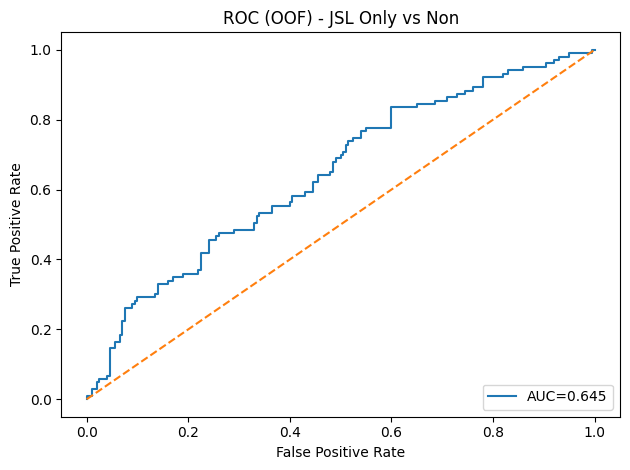


===== TASK: Pain Only vs Non =====
Positive=1: Pain Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]
Tabular cols present: 61 (cats=3, nums=58)
MRI coverage: hits=303 missing=0 dim=513
XRAY coverage: hits=303 missing=0 dim=513
0:	test: 0.4209559	best: 0.4209559 (0)	total: 37ms	remaining: 3m 4s
200:	test: 0.3915441	best: 0.4742647 (46)	total: 8.89s	remaining: 3m 32s
400:	test: 0.3988971	best: 0.4742647 (46)	total: 18s	remaining: 3m 26s
Stopped by overfitting detector  (500 iterations wait)

bestTest = 0.4742647059
bestIteration = 46

Shrink model to first 47 iterations.
0:	total: 38.8ms	remaining: 31s
200:	total: 9.15s	remaining: 27.3s
400:	total: 18.4s	remaining: 18.3s
600:	total: 28.1s	remaining: 9.31s
799:	total: 38s	remaining: 0us
[Outer fold 1] done. Top features example: ['V00AGE', 'Boneshape_V00nPatellaOAVector', 'Biomediq_V00LateralMeniscus', 'Boneshape_V00nTibiaOAVector', 'Labcorp_V00Serum_CPII_lc']
[Outer fold 1] t*=0.27  BalAcc(test @t*)

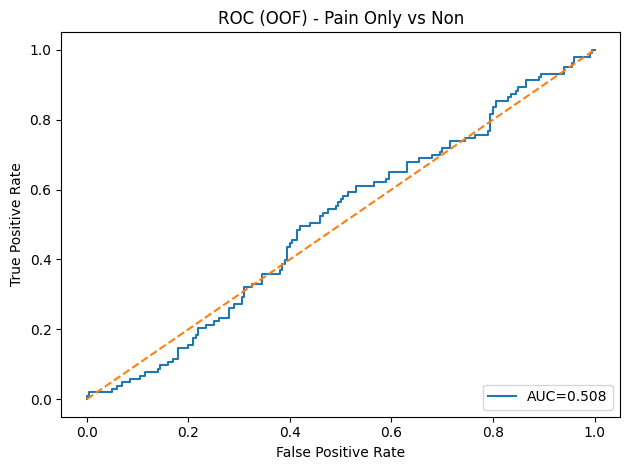

In [7]:
# ============================================================
# Fold-safe topK tabular + imaging embeddings (PCA components) + LogisticRegression
# Fixes implemented:
#  1) Stabilize CatBoost early stopping: larger od_wait, fallback refit if best_it < MIN_TREES
#  2) Leakage-safe topK selection: importance computed on OUTER-TRAIN only (CatBoost fit on train)
#  3) Imaging contributes more than a single probability: we fuse PCA COMPONENTS (not only probs)
#  4) Threshold selection is fold-safe: choose t* on OUTER-TRAIN using inner OOF, apply to OUTER-TEST
#  5) Outputs: OOF metrics + ROC curve plot (overall)
# ============================================================

import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"

SEED = 42
N_SPLITS = 5

MRI_PKL  = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

TOPK_TAB = 20

# Imaging PCA used as features in fusion (stronger than “one scalar prob per modality”)
PCA_M = 16
PCA_X = 16

LR_MAX_ITER = 5000

# CatBoost stability
CB_ITER = 5000
CB_LR = 0.03
CB_DEPTH = 6
CB_L2 = 6
CB_OD_WAIT = 500
MIN_TREES = 50          # if early stopping returns < MIN_TREES, do fallback refit
FALLBACK_TREES = 800    # fixed refit to reduce “bestIteration=0/1” cases

# Inner OOF for threshold selection on outer-train
INNER_K = 3


# -------------------------
# Tabular feature lists (ALL)
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

FEATS_ALL = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS
TAB_CAT = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    return {str(k): np.asarray(v, dtype=np.float32) for k, v in d.items()}

def infer_dim(emb_dict):
    if not emb_dict:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        v = emb_dict.get(pid, None)
        if v is None:
            continue
        v = np.asarray(v, dtype=np.float32)
        if v.shape[0] != dim:
            raise ValueError(f"Embedding dim mismatch for ID={pid}: got {v.shape[0]}, expected {dim}")
        E[i] = v
        hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit

def build_tabular_all(df):
    cols = [c for c in FEATS_ALL if c in df.columns]
    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in TAB_CAT if c in X.columns]
    for c in cat_cols:
        X[c] = X[c].astype(str)

    obj_noncat = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    if obj_noncat:
        X = coerce_censored_numeric(X, obj_noncat)

    cat_cols = [c for c in TAB_CAT if c in X.columns]
    num_cols = [c for c in X.columns if c not in cat_cols]
    return X, cat_cols, num_cols

def make_tab_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, num_cols),
            ("cat", cat_pipe, cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal, best_t = bal, t
    return float(best_t), float(best_bal)

def report_metrics(name, y, prob, neg_name="Non", pos_name="Pos", threshold=None):
    auc = roc_auc_score(y, prob)
    ap  = average_precision_score(y, prob)

    pred05 = (prob >= 0.5).astype(int)
    bal05  = balanced_accuracy_score(y, pred05)
    f105   = f1_score(y, pred05)

    if threshold is None:
        t_best, bal_best = pick_best_balacc_threshold(y, prob)
    else:
        t_best = float(threshold)
        bal_best = balanced_accuracy_score(y, (prob >= t_best).astype(int))

    predt = (prob >= t_best).astype(int)
    f1t = f1_score(y, predt)

    out = {
        "AUC": auc,
        "AP": ap,
        "BalAcc@0.5": bal05,
        "F1@0.5": f105,
        "t*_BalAcc": t_best,
        "BalAcc@t*": bal_best,
        "F1@t*": f1t,
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}):")
    print(confusion_matrix(y, predt))
    print("\nReport @t*:")
    print(classification_report(y, predt, target_names=[neg_name, pos_name]))

    return out

def fit_pca_features(E_tr, E_te, pca_dim, seed):
    # safe pca dim
    if E_tr.shape[1] <= 1:
        pca_eff = 1
    else:
        pca_eff = int(min(pca_dim, E_tr.shape[1] - 1))

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=pca_eff, random_state=seed)),
    ])
    pipe.fit(E_tr)
    return pipe.transform(E_tr).astype(np.float32), pipe.transform(E_te).astype(np.float32)


# -------------------------
# Core: outer-fold model + fold-safe thresholding
# -------------------------
def fit_catboost_for_importance(Xtr, ytr, cat_cols, fold_seed):
    fold_cat = [c for c in cat_cols if c in Xtr.columns]
    cat_idx = [Xtr.columns.get_loc(c) for c in fold_cat]

    neg, pos = np.bincount(ytr)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    # inner split for early stopping
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=fold_seed)
    tr2_idx, va2_idx = next(sss.split(Xtr, ytr))
    Xtr2, ytr2 = Xtr.iloc[tr2_idx], ytr[tr2_idx]
    Xva,  yva  = Xtr.iloc[va2_idx], ytr[va2_idx]

    cb = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=CB_ITER,
        learning_rate=CB_LR,
        depth=CB_DEPTH,
        l2_leaf_reg=CB_L2,
        random_seed=fold_seed,
        class_weights=class_weights,
        verbose=200,
        od_type="Iter",
        od_wait=CB_OD_WAIT,
        random_strength=1.0,
        min_data_in_leaf=10,
        use_best_model=True
    )
    cb.fit(Xtr2, ytr2, cat_features=cat_idx, eval_set=(Xva, yva))

    best_it = cb.get_best_iteration()
    if best_it is None or best_it < MIN_TREES:
        # fallback refit (more stable, avoids “1-tree models”)
        cb = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=FALLBACK_TREES,
            learning_rate=CB_LR,
            depth=CB_DEPTH,
            l2_leaf_reg=CB_L2,
            random_seed=fold_seed,
            class_weights=class_weights,
            verbose=200,
            random_strength=1.0,
            min_data_in_leaf=10
        )
        cb.fit(Xtr, ytr, cat_features=cat_idx)

    # importance aligned to columns used in fit (Xtr columns)
    imp = cb.get_feature_importance(type="PredictionValuesChange")
    imp_s = pd.Series(imp, index=Xtr.columns)

    return imp_s, fold_cat

def build_and_fit_fusion_model(
    Xtr, ytr, Xte,
    E_m_tr, E_m_te,
    E_x_tr, E_x_te,
    top_cols, fold_cat, seed
):
    # tab preprocessing on selected features
    sel_cat = [c for c in top_cols if c in fold_cat]
    sel_num = [c for c in top_cols if c not in sel_cat]
    tab_pre = make_tab_preprocessor(sel_num, sel_cat)
    tab_pre.fit(Xtr[top_cols])
    Xt_tr = tab_pre.transform(Xtr[top_cols]).astype(np.float32)
    Xt_te = tab_pre.transform(Xte[top_cols]).astype(np.float32)

    # PCA components for MRI and XRAY
    Xm_tr, Xm_te = fit_pca_features(E_m_tr, E_m_te, PCA_M, seed)
    Xx_tr, Xx_te = fit_pca_features(E_x_tr, E_x_te, PCA_X, seed)

    # concatenate: [topK tab] + [MRI comps] + [XRAY comps]
    Xf_tr = np.hstack([Xt_tr, Xm_tr, Xx_tr]).astype(np.float32)
    Xf_te = np.hstack([Xt_te, Xm_te, Xx_te]).astype(np.float32)

    clf = LogisticRegression(
        max_iter=LR_MAX_ITER,
        class_weight="balanced",
        solver="lbfgs"
    )
    clf.fit(Xf_tr, ytr)

    return clf, tab_pre

def inner_oof_threshold(
    Xtr, ytr,
    E_m_tr, E_x_tr,
    cat_cols, top_cols, seed
):
    """
    Pick t* using OUTER-TRAIN only, via INNER OOF.
    We re-train the same type of fusion model inside the train split.
    """
    skf_in = StratifiedKFold(n_splits=INNER_K, shuffle=True, random_state=seed)
    p_in = np.zeros(len(ytr), dtype=float)

    fold_cat = [c for c in cat_cols if c in Xtr.columns]

    for tr_in, te_in in skf_in.split(Xtr, ytr):
        X_a = Xtr.iloc[tr_in]
        y_a = ytr[tr_in]
        X_b = Xtr.iloc[te_in]

        Em_a, Em_b = E_m_tr[tr_in], E_m_tr[te_in]
        Ex_a, Ex_b = E_x_tr[tr_in], E_x_tr[te_in]

        clf, _ = build_and_fit_fusion_model(
            X_a, y_a, X_b,
            Em_a, Em_b,
            Ex_a, Ex_b,
            top_cols=top_cols,
            fold_cat=fold_cat,
            seed=seed
        )
        # Need the same transformed features; easiest is to rebuild inside build_and_fit_fusion_model,
        # but we already trained on (X_a -> X_b) there; we just use its predict_proba on the features
        # that build_and_fit_fusion_model used internally, so re-run the feature construction here.

        # Reconstruct features for X_b using the fitted preprocessing from that call is not returned;
        # therefore, for clarity and correctness, we do the feature construction again here:
        # (This duplication is acceptable; INNER_K is small.)

        # ---- reconstruct using the same logic, but fit tab_pre and PCA on X_a only ----
        sel_cat = [c for c in top_cols if c in fold_cat]
        sel_num = [c for c in top_cols if c not in sel_cat]
        tab_pre = make_tab_preprocessor(sel_num, sel_cat)
        tab_pre.fit(X_a[top_cols])

        Xt_a = tab_pre.transform(X_a[top_cols]).astype(np.float32)
        Xt_b = tab_pre.transform(X_b[top_cols]).astype(np.float32)

        Xm_a, Xm_b = fit_pca_features(Em_a, Em_b, PCA_M, seed)
        Xx_a, Xx_b = fit_pca_features(Ex_a, Ex_b, PCA_X, seed)

        Xf_a = np.hstack([Xt_a, Xm_a, Xx_a]).astype(np.float32)
        Xf_b = np.hstack([Xt_b, Xm_b, Xx_b]).astype(np.float32)

        clf2 = LogisticRegression(max_iter=LR_MAX_ITER, class_weight="balanced", solver="lbfgs")
        clf2.fit(Xf_a, y_a)
        p_in[te_in] = clf2.predict_proba(Xf_b)[:, 1]

    t_best, _ = pick_best_balacc_threshold(ytr, p_in)
    return t_best


def oof_topk_fusion(X_tab, cat_cols, E_mri, E_xray, y):
    """
    Outer OOF:
      - importance + topK per fold (train only)
      - fusion model trains on outer-train, predicts outer-test
      - threshold picked on outer-train only via inner OOF
    Returns:
      - p_oof: outer OOF probabilities
      - t_oof: per-fold thresholds (for inspection)
      - imp_mean: mean CatBoost importance across outer folds
    """
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    p_oof = np.zeros(len(y), dtype=float)
    t_folds = []

    imp_sum = pd.Series(0.0, index=X_tab.columns)

    for fold, (tr, te) in enumerate(skf.split(X_tab, y), start=1):
        Xtr = X_tab.iloc[tr].copy()
        ytr = y[tr]
        Xte = X_tab.iloc[te].copy()
        yte = y[te]

        Em_tr, Em_te = E_mri[tr], E_mri[te]
        Ex_tr, Ex_te = E_xray[tr], E_xray[te]

        # 1) fold-safe importance on outer-train
        imp_s, fold_cat = fit_catboost_for_importance(Xtr, ytr, cat_cols, fold_seed=SEED + 1000 * fold)
        imp_sum = imp_sum.add(imp_s, fill_value=0.0)

        # 2) select topK per fold
        top_cols = imp_s.sort_values(ascending=False).head(TOPK_TAB).index.tolist()

        print(f"[Outer fold {fold}] done. Top features example: {top_cols[:5]}")

        # 3) train fusion model on outer-train, predict outer-test
        clf, _ = build_and_fit_fusion_model(
            Xtr, ytr, Xte,
            Em_tr, Em_te,
            Ex_tr, Ex_te,
            top_cols=top_cols,
            fold_cat=fold_cat,
            seed=SEED + 2000 * fold
        )

        # Recreate outer-test features exactly (train-fit on Xtr only)
        sel_cat = [c for c in top_cols if c in fold_cat]
        sel_num = [c for c in top_cols if c not in sel_cat]
        tab_pre = make_tab_preprocessor(sel_num, sel_cat)
        tab_pre.fit(Xtr[top_cols])

        Xt_tr = tab_pre.transform(Xtr[top_cols]).astype(np.float32)
        Xt_te = tab_pre.transform(Xte[top_cols]).astype(np.float32)

        Xm_tr, Xm_te = fit_pca_features(Em_tr, Em_te, PCA_M, SEED + 2000 * fold)
        Xx_tr, Xx_te = fit_pca_features(Ex_tr, Ex_te, PCA_X, SEED + 2000 * fold)

        Xf_tr = np.hstack([Xt_tr, Xm_tr, Xx_tr]).astype(np.float32)
        Xf_te = np.hstack([Xt_te, Xm_te, Xx_te]).astype(np.float32)

        clf_final = LogisticRegression(max_iter=LR_MAX_ITER, class_weight="balanced", solver="lbfgs")
        clf_final.fit(Xf_tr, ytr)
        p_te = clf_final.predict_proba(Xf_te)[:, 1]
        p_oof[te] = p_te

        # 4) fold-safe threshold selection: inner OOF on OUTER-TRAIN only
        t_star = inner_oof_threshold(
            Xtr, ytr,
            Em_tr, Ex_tr,
            cat_cols=cat_cols,
            top_cols=top_cols,
            seed=SEED + 3000 * fold
        )
        t_folds.append(t_star)

        # Optional: fold-level thresholded confusion
        pred_te = (p_te >= t_star).astype(int)
        bal_te = balanced_accuracy_score(yte, pred_te)
        print(f"[Outer fold {fold}] t*={t_star:.2f}  BalAcc(test @t*)={bal_te:.4f}")

    imp_mean = (imp_sum / N_SPLITS).sort_values(ascending=False)
    return p_oof, t_folds, imp_mean


def plot_roc_curve(y, prob, title):
    fpr, tpr, _ = roc_curve(y, prob)
    auc = roc_auc_score(y, prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


# -------------------------
# Task runner
# -------------------------
def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include '{ID_COL}' for alignment with embeddings.")
    ids = df[ID_COL].astype(str).tolist()

    # full tabular
    X_tab, cat_cols, num_cols = build_tabular_all(df)

    # embeddings
    E_mri, hit_m = build_embedding_matrix(ids, mri_dict, add_missing_flag=True)
    E_x,   hit_x = build_embedding_matrix(ids, xray_dict, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}")
    print(f"Tabular cols present: {X_tab.shape[1]} (cats={len(cat_cols)}, nums={len(num_cols)})")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_mri.shape[1]}")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]}")

    # Strict outer OOF with stabilized CatBoost topK + PCA-components fusion
    p_oof, t_folds, imp_mean = oof_topk_fusion(X_tab, cat_cols, E_mri, E_x, y)

    print("\nTop-20 tabular features by mean CatBoost importance (across outer folds):")
    print(imp_mean.head(TOPK_TAB))

    # For reporting one global threshold: use median of fold thresholds (stable)
    t_global = float(np.median(t_folds))
    print(f"\nFold thresholds: {[round(t,2) for t in t_folds]}  |  global (median) t*={t_global:.2f}")

    report_metrics(
        name="STRICT OOF: Top20 Tabular + PCA(MRI comps) + PCA(XRAY comps) + LR fusion",
        y=y,
        prob=p_oof,
        neg_name=neg_class,
        pos_name=pos_class,
        threshold=t_global
    )

    plot_roc_curve(y, p_oof, title=f"ROC (OOF) - {task_name}")


# -------------------------
# Main
# -------------------------
def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict  = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()

In [13]:
# ============================================================
# STRICT OOF (fold-safe) pipeline with:
#   - Tabular topK selection via CatBoost feature importance (train-fold only)
#   - Deep "imaging experts" on embeddings: MLP -> (prob, hidden features)
#   - Fusion model: LogisticRegression on [tab_processed, p_tab, h_mri, h_xray]
#   - Standardization at fusion stage to avoid scale dominance
#   - Diagnostics: AUC for MRI-only, XRAY-only, and fused; AUC of (1 - p) to detect sign inversion
#   - ROC curve saved per task
# ============================================================

import os
import re
import pickle
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier

import matplotlib.pyplot as plt

# ---- Deep part (PyTorch) ----
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_OK = True
except Exception:
    TORCH_OK = False
    torch = None
    nn = None
    DataLoader = None
    TensorDataset = None


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
ID_COL = "ID"

SEED = 42
N_SPLITS = 5

MRI_PKL  = r"D:\PhD\CC\embeddings_out\fnhi_mri_embeddings_resnet18.pkl"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

TOPK_TAB = 20

# CatBoost (tabular importance)
CB_ITER = 2000
CB_LR = 0.03
CB_DEPTH = 6
CB_L2 = 6
CB_OD_WAIT = 200
CB_VERBOSE = 200

# Imaging MLP
# Keep small + strong regularization (your dataset is small per fold)
MLP_WIDTH = 128
MLP_HIDDEN_DIM = 32      # what you concatenate into fusion
MLP_DROPOUT = 0.5
MLP_LR = 1e-3
MLP_WEIGHT_DECAY = 1e-3
MLP_EPOCHS = 200
MLP_BATCH = 64
MLP_PATIENCE = 10

# Fusion LR
LR_MAX_ITER = 5000


# -------------------------
# Tabular feature lists (ALL)
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

FEATS_ALL = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS

TAB_CAT = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers
# -------------------------
def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_OK:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1.0
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def infer_dim(emb_dict):
    if len(emb_dict) == 0:
        raise ValueError("Empty embedding dict.")
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        v = emb_dict.get(pid, None)
        if v is None:
            continue
        v = np.asarray(v, dtype=np.float32)
        if v.shape[0] != dim:
            raise ValueError(f"Embedding dim mismatch for ID={pid}: got {v.shape[0]}, expected {dim}")
        E[i] = v
        hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit

def report_metrics(name, y, prob, neg_name="Non", pos_name="Pos"):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))

def save_roc_curve(y, prob, title, out_png):
    fpr, tpr, _ = roc_curve(y, prob)
    auc = roc_auc_score(y, prob)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.close()
    print(f"[Saved] {out_png}")


# -------------------------
# Tabular build + preprocessing
# -------------------------
def build_tabular_all(df):
    cols = [c for c in FEATS_ALL if c in df.columns]
    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in TAB_CAT if c in X.columns]
    for c in cat_cols:
        X[c] = X[c].astype(str)

    obj_noncat = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    if obj_noncat:
        X = coerce_censored_numeric(X, obj_noncat)

    cat_cols = [c for c in TAB_CAT if c in X.columns]
    return X, cat_cols

def make_tab_preprocessor(selected_cols, cat_cols_all):
    sel_cat = [c for c in selected_cols if c in cat_cols_all]
    sel_num = [c for c in selected_cols if c not in sel_cat]

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ("num", num_pipe, sel_num),
            ("cat", cat_pipe, sel_cat),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


# -------------------------
# Deep Imaging Expert (MLP)
# -------------------------
class MLPExpert(nn.Module):
    def __init__(self, in_dim: int, width: int, hidden_dim: int, dropout: float):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Linear(in_dim, width),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(width, hidden_dim),
            nn.ReLU(),
        )
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        h = self.feat(x)
        logit = self.head(h).squeeze(1)
        return logit, h

def train_mlp_expert_strict(X_tr, y_tr, X_te, seed: int):
    """
    Strict within-train:
      - inner split train/val for early stopping
      - return:
          prob_te (sigmoid),
          h_te (hidden features),
          prob_te_flip_auc diagnostic can be computed outside
    """
    if not TORCH_OK:
        raise RuntimeError("PyTorch is not available in your environment. Install torch or use a sklearn fallback.")

    set_all_seeds(seed)

    # inner split for early stopping
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    tr_idx, va_idx = next(sss.split(X_tr, y_tr))

    Xtr2, ytr2 = X_tr[tr_idx], y_tr[tr_idx]
    Xva,  yva  = X_tr[va_idx], y_tr[va_idx]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = MLPExpert(
        in_dim=X_tr.shape[1],
        width=MLP_WIDTH,
        hidden_dim=MLP_HIDDEN_DIM,
        dropout=MLP_DROPOUT
    ).to(device)

    # class imbalance: pos_weight = neg/pos
    neg = int((ytr2 == 0).sum())
    pos = int((ytr2 == 1).sum())
    pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32, device=device)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt = torch.optim.AdamW(model.parameters(), lr=MLP_LR, weight_decay=MLP_WEIGHT_DECAY)

    def make_loader(X, y, shuffle):
        ds = TensorDataset(
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )
        return DataLoader(ds, batch_size=MLP_BATCH, shuffle=shuffle, drop_last=False)

    dl_tr = make_loader(Xtr2, ytr2, shuffle=True)
    dl_va = make_loader(Xva,  yva,  shuffle=False)

    best_auc = -1.0
    best_state = None
    patience = 0

    for epoch in range(1, MLP_EPOCHS + 1):
        model.train()
        for xb, yb in dl_tr:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            logit, _ = model(xb)
            loss = criterion(logit, yb)
            loss.backward()
            opt.step()

        # val AUC
        model.eval()
        va_probs = []
        va_true = []
        with torch.no_grad():
            for xb, yb in dl_va:
                xb = xb.to(device)
                logit, _ = model(xb)
                prob = torch.sigmoid(logit).detach().cpu().numpy()
                va_probs.append(prob)
                va_true.append(yb.numpy())
        va_probs = np.concatenate(va_probs)
        va_true = np.concatenate(va_true).astype(int)

        # guard when val has a single class (rare but possible in tiny folds)
        try:
            auc = roc_auc_score(va_true, va_probs)
        except Exception:
            auc = 0.5

        if auc > best_auc + 1e-4:
            best_auc = auc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
        else:
            patience += 1

        if patience >= MLP_PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    # inference on test fold
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(X_te, dtype=torch.float32, device=device)
        logit_te, h_te = model(xt)
        prob_te = torch.sigmoid(logit_te).detach().cpu().numpy().astype(np.float64)
        h_te = h_te.detach().cpu().numpy().astype(np.float32)

    return prob_te, h_te


# -------------------------
# Fold-safe topK + deep imaging + fusion
# -------------------------
def oof_topk_tab_plus_deep_mx(X_tab, cat_cols, E_mri, E_xray, y, topk=TOPK_TAB):
    """
    Outer CV:
      - Train-fold: CatBoost importance => topK features (train only)
      - Train-fold: fit tab preprocessor (topK) and create Xt
      - Train-fold: CatBoost p_tab for topK features (same cb model used for importance)
      - Train-fold: scale embeddings and train MLP expert (MRI) => hM, pM
      - Train-fold: scale embeddings and train MLP expert (XRAY) => hX, pX
      - Fusion: LogisticRegression on standardized [Xt, p_tab, hM, hX]
    Returns:
      - p_oof_fused
      - mean feature importance across folds
    """
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    p_fused = np.zeros(len(y), dtype=float)

    all_cols = list(X_tab.columns)
    imp_sum = pd.Series(0.0, index=all_cols)

    for fold, (tr, te) in enumerate(skf.split(X_tab, y), start=1):
        set_all_seeds(SEED + fold)

        Xtr = X_tab.iloc[tr].copy()
        ytr = y[tr]
        Xte = X_tab.iloc[te].copy()
        yte = y[te]

        # CatBoost categorical indices
        fold_cat = [c for c in cat_cols if c in Xtr.columns]
        cat_idx = [Xtr.columns.get_loc(c) for c in fold_cat]

        # balanced weights from TRAIN fold only
        neg, pos = np.bincount(ytr)
        w0 = 0.5 / (neg / (neg + pos))
        w1 = 0.5 / (pos / (neg + pos))
        class_weights = [float(w0), float(w1)]

        # inner split for CatBoost early stopping (train only)
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED + fold)
        tr2_idx, va2_idx = next(sss.split(Xtr, ytr))
        Xtr2, ytr2 = Xtr.iloc[tr2_idx], ytr[tr2_idx]
        Xva,  yva  = Xtr.iloc[va2_idx], ytr[va2_idx]

        cb = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=CB_ITER,
            learning_rate=CB_LR,
            depth=CB_DEPTH,
            l2_leaf_reg=CB_L2,
            random_seed=SEED + fold,
            class_weights=class_weights,
            verbose=CB_VERBOSE,
            od_type="Iter",
            od_wait=CB_OD_WAIT,
            use_best_model=True
        )
        cb.fit(Xtr2, ytr2, cat_features=cat_idx, eval_set=(Xva, yva))

        # importance on train-only columns
        imp = cb.get_feature_importance(type="PredictionValuesChange")
        imp_s = pd.Series(imp, index=Xtr2.columns)
        imp_sum = imp_sum.add(imp_s, fill_value=0.0)

        # fold-specific topK
        top_cols = imp_s.sort_values(ascending=False).head(topk).index.tolist()
        print(f"[Outer fold {fold}] done. Top features example: {top_cols[:5]}")

        # tabular preprocessor fit on train fold only
        tab_pre = make_tab_preprocessor(top_cols, cat_cols_all=fold_cat)
        tab_pre.fit(Xtr[top_cols])

        Xt_tr = tab_pre.transform(Xtr[top_cols]).astype(np.float32)
        Xt_te = tab_pre.transform(Xte[top_cols]).astype(np.float32)

        # tabular prob from CatBoost (stabilizes fusion)
        p_tab_tr = cb.predict_proba(Xtr)[:, 1].reshape(-1, 1).astype(np.float32)
        p_tab_te = cb.predict_proba(Xte)[:, 1].reshape(-1, 1).astype(np.float32)

        # embeddings: standardize using train fold only
        def scale_embed(E_tr, E_te):
            sc = StandardScaler(with_mean=True, with_std=True)
            E_tr_s = sc.fit_transform(E_tr).astype(np.float32)
            E_te_s = sc.transform(E_te).astype(np.float32)
            return E_tr_s, E_te_s

        Em_tr, Em_te = scale_embed(E_mri[tr],  E_mri[te])
        Ex_tr, Ex_te = scale_embed(E_xray[tr], E_xray[te])

        # train MLP experts (train fold only)
        p_m_te, h_m_te = train_mlp_expert_strict(Em_tr, ytr, Em_te, seed=SEED + 1000 + fold)
        p_x_te, h_x_te = train_mlp_expert_strict(Ex_tr, ytr, Ex_te, seed=SEED + 2000 + fold)

        # diagnostics: imaging-only AUC (and flipped AUC) on this fold
        try:
            auc_m = roc_auc_score(yte, p_m_te)
            auc_m_flip = roc_auc_score(yte, 1.0 - p_m_te)
        except Exception:
            auc_m, auc_m_flip = 0.5, 0.5

        try:
            auc_x = roc_auc_score(yte, p_x_te)
            auc_x_flip = roc_auc_score(yte, 1.0 - p_x_te)
        except Exception:
            auc_x, auc_x_flip = 0.5, 0.5

        print(f"[Fold {fold}] MRI-only AUC={auc_m:.3f} (flip={auc_m_flip:.3f}) | XRAY-only AUC={auc_x:.3f} (flip={auc_x_flip:.3f})")

        # fusion features: [tab_processed, p_tab, hidden_m, hidden_x]
        Xf_tr = np.hstack([Xt_tr, p_tab_tr,  # tab block
                           # NOTE: we do NOT use imaging probs here, only hidden reps
                           # but you could add them as extra 2 scalars if you want
                           ]).astype(np.float32)

        # We need train hidden features too for LR.
        # Re-run the MLP forward on TRAIN fold to extract hidden reps consistently:
        # simplest approach: train_mlp_expert_strict returns only test hidden; so we do a second pass:
        # --> easiest robust way: train expert once more with X_tr as "test" after training.
        # To avoid refactor, just train again with the same seed but swapping X_te=Em_tr to get train h:
        _, h_m_tr = train_mlp_expert_strict(Em_tr, ytr, Em_tr, seed=SEED + 1000 + fold)
        _, h_x_tr = train_mlp_expert_strict(Ex_tr, ytr, Ex_tr, seed=SEED + 2000 + fold)

        Xf_tr = np.hstack([Xt_tr, p_tab_tr, h_m_tr, h_x_tr]).astype(np.float32)
        Xf_te = np.hstack([Xt_te, p_tab_te, h_m_te, h_x_te]).astype(np.float32)

        # IMPORTANT: standardize fusion matrix (train only)
        sc_fuse = StandardScaler(with_mean=True, with_std=True)
        Xf_tr = sc_fuse.fit_transform(Xf_tr).astype(np.float32)
        Xf_te = sc_fuse.transform(Xf_te).astype(np.float32)

        clf = LogisticRegression(
            max_iter=LR_MAX_ITER,
            class_weight="balanced",
            solver="lbfgs"
        )
        clf.fit(Xf_tr, ytr)
        p_fused[te] = clf.predict_proba(Xf_te)[:, 1]

    imp_mean = (imp_sum / N_SPLITS).sort_values(ascending=False)
    return p_fused, imp_mean


# -------------------------
# Task runner
# -------------------------
def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if ID_COL not in df.columns:
        raise ValueError(f"Clinical CSV must include '{ID_COL}' for alignment with embeddings.")
    ids = df[ID_COL].astype(str).tolist()

    # tabular
    X_tab, cat_cols = build_tabular_all(df)

    # embeddings aligned
    E_mri, hit_m = build_embedding_matrix(ids, mri_dict, add_missing_flag=True)
    E_x,   hit_x = build_embedding_matrix(ids, xray_dict, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}")
    print(f"Tabular cols present: {X_tab.shape[1]} (cats={len(cat_cols)})")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_mri.shape[1]}")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]}")

    if not TORCH_OK:
        raise RuntimeError("PyTorch not available. Please install torch to run the MLP imaging experts.")

    # strict OOF fused
    p_oof, imp_mean = oof_topk_tab_plus_deep_mx(
        X_tab=X_tab,
        cat_cols=cat_cols,
        E_mri=E_mri,
        E_xray=E_x,
        y=y,
        topk=TOPK_TAB
    )

    # show global topK (mean importance across folds)
    print("\nTop-20 tabular features by mean CatBoost importance (across folds):")
    print(imp_mean.head(TOPK_TAB))

    # global diagnostics: check if flipping improves a lot (sign inversion indicator)
    auc = roc_auc_score(y, p_oof)
    auc_flip = roc_auc_score(y, 1.0 - p_oof)
    print(f"\n[OOF check] Fused AUC={auc:.4f} | Flip AUC={auc_flip:.4f}")

    report_metrics(
        name=f"STRICT OOF: Top{TOPK_TAB} Tabular + MLP(MRI hidden) + MLP(XRAY hidden) + LR fusion",
        y=y,
        prob=p_oof,
        neg_name=neg_class,
        pos_name=pos_class
    )

    # save ROC
    out_png = f"roc_{task_name.replace(' ', '_').replace('/', '_')}.png"
    save_roc_curve(y, p_oof, title=f"ROC - {task_name}", out_png=out_png)


# -------------------------
# Main
# -------------------------
def main():
    set_all_seeds(SEED)

    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if not os.path.exists(MRI_PKL):
        raise FileNotFoundError(f"Could not find MRI PKL: {MRI_PKL}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict  = load_embedding_dict(MRI_PKL)
    xray_dict = load_embedding_dict(XRAY_PKL)

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()

Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600

===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]
Tabular cols present: 61 (cats=3)
MRI coverage: hits=303 missing=0 dim=513
XRAY coverage: hits=303 missing=0 dim=513
0:	test: 0.7674632	best: 0.7674632 (0)	total: 40.1ms	remaining: 1m 20s
200:	test: 0.7187500	best: 0.7757353 (18)	total: 9.64s	remaining: 1m 26s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7757352941
bestIteration = 18

Shrink model to first 19 iterations.
[Outer fold 1] done. Top features example: ['Biomediq_V00MedialMeniscus', 'Biomediq_V00LateralFemoralCartilage', 'Labcorp_V00Serum_PIIANP_lc', 'Labcorp_V00Serum_Comp_lc', 'Labcorp_V00Serum_CS846_lc']
[Fold 1] MRI-only AUC=0.732 (flip=0.268) | XRAY-only AUC=0.675 (flip=0.325)
0:	test: 0.5349265	best: 0.5349265 (0)	total: 36.7ms	remaining: 1m 13s
200:	test: 0.5625000	best: 0.5716912 (57)	total: 9.48s	re

**Improved MRI Embedding**

In [10]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5

# New MRI embeddings
MRI_EMB_NPY = r"C:\Users\pahad\Desktop\CCF-New\Multimodal\Segmentation\mri_mpr_embeddings_final\patient_mri_embeddings.npy"
MRI_META_CSV = r"C:\Users\pahad\Desktop\CCF-New\Multimodal\Segmentation\mri_mpr_embeddings_final\embedding_metadata.csv"

# Existing X-ray embeddings
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

# -------------------------
# Tabular features (T) = BASE + BoneShape + Biomediq + Biomarkers
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

FEATS_T = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def load_mri_embedding_dict_from_npy_and_metadata(npy_path: str, meta_path: str):
    if not os.path.exists(npy_path):
        raise FileNotFoundError(f"Could not find MRI embedding matrix: {npy_path}")
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"Could not find MRI embedding metadata: {meta_path}")

    emb = np.load(npy_path)

    meta_lower = meta_path.lower()
    if meta_lower.endswith(".csv"):
        meta = pd.read_csv(meta_path)
    elif meta_lower.endswith(".xlsx") or meta_lower.endswith(".xls"):
        meta = pd.read_excel(meta_path, engine="openpyxl")
    else:
        raise ValueError(f"Unsupported metadata file format: {meta_path}")

    if "patient_id" not in meta.columns:
        raise ValueError("Metadata file must contain a 'patient_id' column")

    if len(meta) != emb.shape[0]:
        raise ValueError(
            f"Row mismatch: metadata has {len(meta)} rows but embedding matrix has {emb.shape[0]} rows"
        )

    out = {}
    for i, pid in enumerate(meta["patient_id"].astype(str).tolist()):
        out[pid] = np.asarray(emb[i], dtype=np.float32)

    return out, meta

def infer_dim(emb_dict):
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


# -------------------------
# OOF experts + late fusion (ONLY T+M+X)
# -------------------------
def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p[te] = model.predict_proba(X_tab.iloc[te])[:, 1]
    return p

def oof_embedding_expert(E, y, pca_dim=64):
    n_train = len(y) - len(y) // N_SPLITS
    max_pca = min(pca_dim, n_train - 1, E.shape[1])
    if max_pca < 1:
        max_pca = 1

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=max_pca, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_tmx(p_t, p_m, p_x, y):
    Z = np.vstack([p_t, p_m, p_x]).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack

def build_tabular_T(df, y):
    cols = [c for c in FEATS_T if c in df.columns]
    missing = sorted(set(FEATS_T) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS_T if c in X.columns]
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)

    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing

def report(name, y, prob, neg_name, pos_name):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t  = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))

def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column for alignment with embeddings.")
    ids = df["ID"].astype(str).tolist()

    X_t, cat_cols, class_weights, missing_cols = build_tabular_T(df, y)

    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"T features used: {X_t.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns (not found in CSV): {missing_cols}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    p_t = oof_tabular_catboost(X_t, y, cat_cols, class_weights)
    p_m = oof_embedding_expert(E_m, y, pca_dim=64)
    p_x = oof_embedding_expert(E_x, y, pca_dim=64)

    p_tmx = oof_stack_tmx(p_t, p_m, p_x, y)

    report(
        name="Late fusion Stack (T+M+X) with Biomarkers in T",
        y=y,
        prob=p_tmx,
        neg_name=neg_class,
        pos_name=pos_class
    )

def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column.")

    if not os.path.exists(MRI_EMB_NPY):
        raise FileNotFoundError(f"Could not find MRI embedding matrix: {MRI_EMB_NPY}")
    if not os.path.exists(MRI_META_CSV):
        raise FileNotFoundError(f"Could not find MRI embedding metadata: {MRI_META_CSV}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict, mri_meta = load_mri_embedding_dict_from_npy_and_metadata(MRI_EMB_NPY, MRI_META_CSV)
    xray_dict = load_embedding_dict(XRAY_PKL)
    
    clinical_ids = set(df["ID"].astype(str))
    mri_ids = set(mri_dict.keys())
    xray_ids = set(xray_dict.keys())

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")
    print(f"Clinical unique IDs: {len(clinical_ids)}")
    print(f"Clinical-MRI overlap: {len(clinical_ids & mri_ids)}")
    print(f"Clinical-XRAY overlap: {len(clinical_ids & xray_ids)}")

    if "selected_series_description" in mri_meta.columns:
        print("\nMRI orientation counts:")
        print(mri_meta["selected_series_description"].value_counts(dropna=False))

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()

Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600
Clinical unique IDs: 600
Clinical-MRI overlap: 600
Clinical-XRAY overlap: 600

MRI orientation counts:
selected_series_description
AX_MPR_LEFT              482
AX_MPR_RIGHT             108
COR_IW_TSE_LEFT            6
COR_T1_3D_FLASH_RIGHT      1
COR_MPR_RIGHT              1
MP_LOCATOR_LEFT            1
COR_MPR_LEFT               1
Name: count, dtype: int64

===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]   class_weights=[0.7575000000000001, 1.470873786407767]
T features used: 61   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=303 missing=0 dim=1025 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)

== Late fusion Stack (T+M+X) with Biomarkers in T ==
{'AUC': 0.715631067961165, 'AP': 0.5667000428410509, 'BalAcc@0.5': 0.6748058252427185, 'F1@0.5': 0.5857740585774058, 't*_BalAcc': 0.5, 'Bal

In [ ]:
#increase PCS Dim
#no improvement

In [3]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from collections import Counter

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5
INNER_SPLITS = 3

MRI_EMB_NPY = r"C:\Users\pahad\Desktop\CCF-New\Multimodal\Segmentation\mri_mpr_embeddings_final\patient_mri_embeddings.npy"
MRI_META_CSV = r"C:\Users\pahad\Desktop\CCF-New\Multimodal\Segmentation\mri_mpr_embeddings_final\embedding_metadata.csv"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

# Separate grids
MRI_PCA_GRID = [16, 32, 64, 96, 128, 160, 192, 256]
XRAY_PCA_GRID = [16, 32, 64, 96, 128]

# Metric used for inner model selection
SELECTION_METRIC = "auc"   # options: "auc", "ap", "balacc"


# -------------------------
# Tabular features
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

FEATS_T = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def load_mri_embedding_dict_from_npy_and_metadata(npy_path: str, meta_path: str):
    if not os.path.exists(npy_path):
        raise FileNotFoundError(f"Could not find MRI embedding matrix: {npy_path}")
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"Could not find MRI embedding metadata: {meta_path}")

    emb = np.load(npy_path)

    meta_lower = meta_path.lower()
    if meta_lower.endswith(".csv"):
        meta = pd.read_csv(meta_path)
    elif meta_lower.endswith(".xlsx") or meta_lower.endswith(".xls"):
        meta = pd.read_excel(meta_path, engine="openpyxl")
    else:
        raise ValueError(f"Unsupported metadata file format: {meta_path}")

    if "patient_id" not in meta.columns:
        raise ValueError("Metadata file must contain a 'patient_id' column")

    if len(meta) != emb.shape[0]:
        raise ValueError(
            f"Row mismatch: metadata has {len(meta)} rows but embedding matrix has {emb.shape[0]} rows"
        )

    out = {}
    for i, pid in enumerate(meta["patient_id"].astype(str).tolist()):
        out[pid] = np.asarray(emb[i], dtype=np.float32)

    return out, meta

def infer_dim(emb_dict):
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit

def build_tabular_T(df, y):
    cols = [c for c in FEATS_T if c in df.columns]
    missing = sorted(set(FEATS_T) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS_T if c in X.columns]
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)

    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing

def report(name, y, prob, neg_name, pos_name):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t  = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))

def safe_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, prob)

def safe_ap(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, prob)

def best_balacc_from_prob(y_true, prob):
    t, bal = pick_best_balacc_threshold(y_true, prob)
    return bal

def score_prob(y_true, prob, metric="auc"):
    if metric == "auc":
        return safe_auc(y_true, prob)
    if metric == "ap":
        return safe_ap(y_true, prob)
    if metric == "balacc":
        return best_balacc_from_prob(y_true, prob)
    raise ValueError(f"Unsupported metric: {metric}")

def max_valid_pca_dim_for_matrix(X):
    n_samples, n_features = X.shape
    return max(1, min(n_samples, n_features))

def clamp_pca_dim(requested_dim, X):
    return min(requested_dim, max_valid_pca_dim_for_matrix(X))

def build_embedding_pipeline_for_fit(X_fit, requested_n_components):
    safe_n_components = clamp_pca_dim(requested_n_components, X_fit)
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=safe_n_components, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

def valid_pca_dims_global(requested_dims, X_train):
    """
    Valid for a single matrix only.
    Useful for outer-train sanity checks.
    """
    max_allowed = max_valid_pca_dim_for_matrix(X_train)
    dims = sorted(set([d for d in requested_dims if 1 <= d <= max_allowed]))
    if not dims:
        dims = [max_allowed]
    return dims

def valid_pca_dims_for_inner_cv(requested_dims, X_train, y_train, inner_splits):
    """
    Only keep PCA dims that are valid for *every* inner training fold.
    This is the key fix for your error.
    """
    if len(y_train) < inner_splits:
        return [1]

    skf_inner = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=SEED)
    max_dims = []

    for tr_i, _ in skf_inner.split(X_train, y_train):
        X_tr = X_train[tr_i]
        max_dims.append(max_valid_pca_dim_for_matrix(X_tr))

    global_max = min(max_dims)
    dims = sorted(set([d for d in requested_dims if 1 <= d <= global_max]))
    if not dims:
        dims = [global_max]
    return dims

def select_pca_dim_inner_cv(X_train, y_train, pca_grid, metric="auc", inner_splits=3):
    dims = valid_pca_dims_for_inner_cv(
        requested_dims=pca_grid,
        X_train=X_train,
        y_train=y_train,
        inner_splits=inner_splits
    )

    if len(np.unique(y_train)) < 2:
        return dims[0], {d: np.nan for d in dims}

    skf_inner = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=SEED)
    dim_scores = {}

    for dim in dims:
        fold_scores = []

        for tr_i, va_i in skf_inner.split(X_train, y_train):
            X_tr, X_va = X_train[tr_i], X_train[va_i]
            y_tr, y_va = y_train[tr_i], y_train[va_i]

            pipe = build_embedding_pipeline_for_fit(X_tr, dim)
            pipe.fit(X_tr, y_tr)
            prob = pipe.predict_proba(X_va)[:, 1]

            s = score_prob(y_va, prob, metric=metric)
            if not np.isnan(s):
                fold_scores.append(s)

        dim_scores[dim] = float(np.mean(fold_scores)) if fold_scores else np.nan

    best_dim = None
    best_score = -np.inf
    for dim in dims:
        s = dim_scores[dim]
        if np.isnan(s):
            continue
        if s > best_score:
            best_score = s
            best_dim = dim

    if best_dim is None:
        best_dim = dims[0]

    return best_dim, dim_scores

def oof_embedding_expert_nested(E, y, pca_grid, metric="auc", inner_splits=3, verbose_name="embedding"):
    skf_outer = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)
    selected_dims = []
    per_fold_dim_scores = []

    for fold, (tr, te) in enumerate(skf_outer.split(E, y), start=1):
        X_tr, X_te = E[tr], E[te]
        y_tr, y_te = y[tr], y[te]

        best_dim, dim_scores = select_pca_dim_inner_cv(
            X_train=X_tr,
            y_train=y_tr,
            pca_grid=pca_grid,
            metric=metric,
            inner_splits=inner_splits
        )
        selected_dims.append(best_dim)
        per_fold_dim_scores.append(dim_scores)

        pipe = build_embedding_pipeline_for_fit(X_tr, best_dim)
        pipe.fit(X_tr, y_tr)
        p[te] = pipe.predict_proba(X_te)[:, 1]

        actual_pca_dim = pipe.named_steps["pca"].n_components
        print(f"[{verbose_name}] outer fold {fold}: selected PCA dim = {best_dim}, fitted PCA dim = {actual_pca_dim}")

    return p, selected_dims, per_fold_dim_scores

def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p[te] = model.predict_proba(X_tab.iloc[te])[:, 1]
    return p

def oof_stack_tmx(p_t, p_m, p_x, y):
    Z = np.vstack([p_t, p_m, p_x]).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack

def summarize_selected_dims(name, dims):
    c = Counter(dims)
    print(f"\n{name} selected PCA dims across outer folds:")
    for k in sorted(c):
        print(f"  dim={k}: {c[k]} fold(s)")
    print(f"  raw sequence: {dims}")

def print_inner_dim_scores(name, fold_dim_scores):
    print(f"\n{name} inner-CV scores by outer fold:")
    for i, d in enumerate(fold_dim_scores, start=1):
        ordered = ", ".join(
            [f"{k}:{d[k]:.4f}" if not np.isnan(d[k]) else f"{k}:nan" for k in sorted(d)]
        )
        print(f"  fold {i}: {ordered}")

def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column for alignment with embeddings.")
    ids = df["ID"].astype(str).tolist()

    X_t, cat_cols, class_weights, missing_cols = build_tabular_T(df, y)

    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"T features used: {X_t.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns (not found in CSV): {missing_cols}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    # Tabular expert
    p_t = oof_tabular_catboost(X_t, y, cat_cols, class_weights)

    # MRI expert with nested PCA selection
    p_m, mri_selected_dims, mri_dim_scores = oof_embedding_expert_nested(
        E=E_m,
        y=y,
        pca_grid=MRI_PCA_GRID,
        metric=SELECTION_METRIC,
        inner_splits=INNER_SPLITS,
        verbose_name="MRI"
    )

    # X-ray expert with nested PCA selection
    p_x, xray_selected_dims, xray_dim_scores = oof_embedding_expert_nested(
        E=E_x,
        y=y,
        pca_grid=XRAY_PCA_GRID,
        metric=SELECTION_METRIC,
        inner_splits=INNER_SPLITS,
        verbose_name="XRAY"
    )

    summarize_selected_dims("MRI", mri_selected_dims)
    summarize_selected_dims("XRAY", xray_selected_dims)

    print_inner_dim_scores("MRI", mri_dim_scores)
    print_inner_dim_scores("XRAY", xray_dim_scores)

    # Individual modality reports
    report(
        name="MRI expert only",
        y=y,
        prob=p_m,
        neg_name=neg_class,
        pos_name=pos_class
    )

    report(
        name="XRAY expert only",
        y=y,
        prob=p_x,
        neg_name=neg_class,
        pos_name=pos_class
    )

    # Late fusion
    p_tmx = oof_stack_tmx(p_t, p_m, p_x, y)

    report(
        name="Late fusion Stack (T+M+X) with tuned MRI/XRAY PCA",
        y=y,
        prob=p_tmx,
        neg_name=neg_class,
        pos_name=pos_class
    )

def main():
    df = pd.read_csv(CSV_PATH)
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column.")

    if not os.path.exists(MRI_EMB_NPY):
        raise FileNotFoundError(f"Could not find MRI embedding matrix: {MRI_EMB_NPY}")
    if not os.path.exists(MRI_META_CSV):
        raise FileNotFoundError(f"Could not find MRI embedding metadata: {MRI_META_CSV}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict, mri_meta = load_mri_embedding_dict_from_npy_and_metadata(MRI_EMB_NPY, MRI_META_CSV)
    xray_dict = load_embedding_dict(XRAY_PKL)

    clinical_ids = set(df["ID"].astype(str))
    mri_ids = set(mri_dict.keys())
    xray_ids = set(xray_dict.keys())

    print(f"Clinical rows (raw): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")
    print(f"Clinical unique IDs: {len(clinical_ids)}")
    print(f"Clinical-MRI overlap: {len(clinical_ids & mri_ids)}")
    print(f"Clinical-XRAY overlap: {len(clinical_ids & xray_ids)}")
    print(f"MRI PCA grid: {MRI_PCA_GRID}")
    print(f"XRAY PCA grid: {XRAY_PCA_GRID}")
    print(f"Inner selection metric: {SELECTION_METRIC}")

    if "selected_series_description" in mri_meta.columns:
        print("\nMRI orientation counts:")
        print(mri_meta["selected_series_description"].value_counts(dropna=False))

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()

Clinical rows (raw): 600
MRI dict N: 600 | XRAY dict N: 600
Clinical unique IDs: 600
Clinical-MRI overlap: 600
Clinical-XRAY overlap: 600
MRI PCA grid: [16, 32, 64, 96, 128, 160, 192, 256]
XRAY PCA grid: [16, 32, 64, 96, 128]
Inner selection metric: auc

MRI orientation counts:
selected_series_description
AX_MPR_LEFT              482
AX_MPR_RIGHT             108
COR_IW_TSE_LEFT            6
COR_T1_3D_FLASH_RIGHT      1
COR_MPR_RIGHT              1
MP_LOCATOR_LEFT            1
COR_MPR_LEFT               1
Name: count, dtype: int64

===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]   class_weights=[0.7575000000000001, 1.470873786407767]
T features used: 61   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=303 missing=0 dim=1025 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)
[MRI] outer fold 1: selected PCA dim = 160, fitted PCA dim = 160
[MRI] outer 

In [ ]:
#add more features, osteophytes, moaks based
#merging

In [2]:
import pandas as pd
import numpy as np

# -------------------------
# File paths
# -------------------------
MAIN_FILE = "Clinical_FNIH_merged_all_tables.csv"
MRI_FILE = "kMRI_FNIH_SQ_MOAKS_BICL00.csv"
OUTPUT_FILE = "Clinical_FNIH_merged_all_tables_with_MOAKS_baseline.csv"

# -------------------------
# Load files
# -------------------------
df_main = pd.read_csv(MAIN_FILE)
df_mri = pd.read_csv(MRI_FILE)

print("Main shape:", df_main.shape)
print("MRI shape:", df_mri.shape)

# -------------------------
# Standardize column names
# -------------------------
df_main.columns = df_main.columns.str.strip()
df_mri.columns = df_mri.columns.str.strip()

# -------------------------
# Standardize ID and SIDE
# -------------------------
if "ID" not in df_main.columns or "ID" not in df_mri.columns:
    raise ValueError("Both files must contain an 'ID' column.")

df_main["ID"] = df_main["ID"].astype(str).str.strip()
df_mri["ID"] = df_mri["ID"].astype(str).str.strip()

if "SIDE" in df_main.columns and "SIDE" in df_mri.columns:
    df_main["SIDE"] = df_main["SIDE"].astype(str).str.strip()
    df_mri["SIDE"] = df_mri["SIDE"].astype(str).str.strip()

# -------------------------
# Keep only baseline MRI rows
# -------------------------
# Your sample suggests baseline is VERSION == 0.1
if "VERSION" in df_mri.columns:
    df_mri["VERSION"] = pd.to_numeric(df_mri["VERSION"], errors="coerce")
    df_mri_base = df_mri[df_mri["VERSION"] == 0.1].copy()
else:
    raise ValueError("MRI file does not contain 'VERSION'. Cannot isolate baseline rows.")

print("Baseline MRI shape:", df_mri_base.shape)

# -------------------------
# Decide merge keys
# -------------------------
use_side = ("SIDE" in df_main.columns) and ("SIDE" in df_mri_base.columns)

if use_side:
    merge_keys = ["ID", "SIDE"]
else:
    merge_keys = ["ID"]
    print("\nWARNING: Merging only on ID.")
    print("If both knees exist for a subject, this may create duplicate or incorrect matches.")
    print("Using ID + SIDE is strongly preferred for knee-level data.\n")

print("Merge keys:", merge_keys)

# -------------------------
# Check duplicates in MRI baseline file
# -------------------------
dup_counts = df_mri_base.groupby(merge_keys).size().reset_index(name="n")
dups = dup_counts[dup_counts["n"] > 1]

if not dups.empty:
    print("\nWARNING: Duplicate baseline MRI rows found for merge keys.")
    print(dups.head(20))

    # Keep first row per key to avoid exploding merge
    # You may replace this with a better rule if needed
    df_mri_base = df_mri_base.sort_values(merge_keys).drop_duplicates(subset=merge_keys, keep="first").copy()
    print("After dropping duplicates, baseline MRI shape:", df_mri_base.shape)

# -------------------------
# Select MRI columns to add
# -------------------------
# Keep all MRI columns except merge keys already present in main
# Also drop VERSION because once baseline is filtered it is not very informative
exclude_cols = set(merge_keys + ["VERSION"])

mri_feature_cols = [c for c in df_mri_base.columns if c not in exclude_cols]

# Avoid overwriting columns already in main
overlap_cols = [c for c in mri_feature_cols if c in df_main.columns]
if overlap_cols:
    print("\nOverlapping columns found. They will be renamed with prefix 'MOAKS_':")
    print(overlap_cols[:20], "..." if len(overlap_cols) > 20 else "")

rename_map = {c: f"MOAKS_{c}" for c in overlap_cols}
df_mri_base = df_mri_base.rename(columns=rename_map)

# Rebuild feature columns after rename
mri_feature_cols = [c for c in df_mri_base.columns if c not in merge_keys + ["VERSION"]]

# -------------------------
# Merge
# -------------------------
df_merged = df_main.merge(
    df_mri_base[merge_keys + mri_feature_cols],
    on=merge_keys,
    how="left"
)

print("Merged shape:", df_merged.shape)

# -------------------------
# Match statistics
# -------------------------
added_cols = [c for c in df_merged.columns if c not in df_main.columns]

if added_cols:
    first_added_col = added_cols[0]
    matched_rows = df_merged[first_added_col].notna().sum()
else:
    matched_rows = 0

print(f"Number of added MRI columns: {len(added_cols)}")
print(f"Rows with at least one MRI match: {matched_rows} / {len(df_merged)}")

# -------------------------
# Save
# -------------------------
df_merged.to_csv(OUTPUT_FILE, index=False)
print(f"\nSaved merged file to: {OUTPUT_FILE}")

Main shape: (600, 202)
MRI shape: (600, 122)
Baseline MRI shape: (600, 122)
Merge keys: ['ID', 'SIDE']
Merged shape: (600, 321)
Number of added MRI columns: 119
Rows with at least one MRI match: 600 / 600

Saved merged file to: Clinical_FNIH_merged_all_tables_with_MOAKS_baseline.csv


**run multimodal with MOAKS data added**

In [4]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
MOAKS_PATH = "kMRI_FNIH_SQ_MOAKS_BICL00.csv"

TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5

# New MRI embeddings
MRI_EMB_NPY = r"C:\Users\pahad\Desktop\CCF-New\Multimodal\Segmentation\mri_mpr_embeddings_final\patient_mri_embeddings.npy"
MRI_META_CSV = r"C:\Users\pahad\Desktop\CCF-New\Multimodal\Segmentation\mri_mpr_embeddings_final\embedding_metadata.csv"

# Existing X-ray embeddings
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non",  "JSL Only Progressor",  NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

# -------------------------
# Tabular features (existing T)
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

# -------------------------
# MOAKS feature groups
# You can shrink this list later if needed
# -------------------------
MOAKS_FEATS = [
    c for c in [
        "V00MCMPM", "V00MCMPL", "V00MCMFMA", "V00MCMFLA", "V00MCMFMP", "V00MCMFLP",
        "V00MCMFMC", "V00MCMFLC", "V00MCMTMA", "V00MCMTLA", "V00MCMTMC", "V00MCMTLC",
        "V00MCMTMP", "V00MCMTLP",

        "V00MBMSFMA", "V00MBMPFMA", "V00MBMNFMA", "V00MBMSFLA", "V00MBMPFLA", "V00MBMNFLA",
        "V00MBMSFMC", "V00MBMPFMC", "V00MBMNFMC", "V00MBMSFLC", "V00MBMPFLC", "V00MBMNFLC",
        "V00MBMSFMP", "V00MBMPFMP", "V00MBMNFMP", "V00MBMSFLP", "V00MBMPFLP", "V00MBMNFLP",
        "V00MBMSSS", "V00MBMPSS", "V00MBMNSS", "V00MBMSTMA", "V00MBMPTMA", "V00MBMNTMA",
        "V00MBMSTLA", "V00MBMPTLA", "V00MBMNTLA", "V00MBMSTMC", "V00MBMPTMC", "V00MBMNTMC",
        "V00MBMSTLC", "V00MBMPTLC", "V00MBMNTLC", "V00MBMSTMP", "V00MBMPTMP", "V00MBMNTMP",
        "V00MBMSTLP", "V00MBMPTLP", "V00MBMNTLP", "V00MBMSPM", "V00MBMPPM", "V00MBMNPM",
        "V00MBMSPL", "V00MBMPPL", "V00MBMNPL",

        "V00MMTMA", "V00MMTLA", "V00MMTMB", "V00MMTLB", "V00MMTMP", "V00MMTLP",
        "V00MMHMA", "V00MMHLA", "V00MMHMB", "V00MMHLB", "V00MMHMP", "V00MMHLP",
        "V00MMSMA", "V00MMSLA", "V00MMSMB", "V00MMSLB", "V00MMSMP", "V00MMSLP",
        "V00MMXMM", "V00MMXMA", "V00MMXLA", "V00MMXLL", "V00MMRTM", "V00MMRTL",

        "V00MOSPS", "V00MOSPI", "V00MOSPM", "V00MOSPL",
        "V00MOSFMA", "V00MOSFLA", "V00MOSFMP", "V00MOSFLP", "V00MOSFMC", "V00MOSFLC",
        "V00MOSTM", "V00MOSTL",

        "V00MACLTR", "V00MACLBML", "V00MACLRP",
        "V00MPCLTR", "V00MPCLBML", "V00MPCLRP",
        "V00MPTSIG", "V00MGCACL", "V00MGCPCL", "V00MGCTIB", "V00MGCSM", "V00MGSST",
        "V00MGCOTH", "V00MANSBUR", "V00MIPBUR", "V00MPPBUR", "V00MSYIC", "V00MEFFWK",
        "V00MITBSIG", "V00MPOPCYS", "V00MCMNTS", "V00MTCMNTS"
    ]
]

FEATS_T = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS + MOAKS_FEATS
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
PREFIX_NUM_PATTERN = re.compile(r"^\s*([-+]?\d*\.?\d+)\s*:")
PURE_NUM_PATTERN = re.compile(r"^\s*([-+]?\d*\.?\d+)\s*$")

def normalize_side(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "right" in s or s == "1":
        return "RIGHT"
    if "left" in s or s == "2":
        return "LEFT"
    return np.nan

def parse_moaks_value(x):
    """
    Convert MOAKS string formats to numeric ordinal values.

    Examples:
      '2: 10-75% area, no full thickness' -> 2.0
      '2.2: 10-75% area, 10-75% full thickness' -> 2.2
      '0: None' -> 0.0
      '.: Missing Form/Incomplete Workbook' -> NaN
      '' -> NaN
    """
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s == "" or s == "." or s.lower().startswith(".:"):
        return np.nan

    m = PREFIX_NUM_PATTERN.match(s)
    if m:
        try:
            return float(m.group(1))
        except Exception:
            return np.nan

    m2 = PURE_NUM_PATTERN.match(s)
    if m2:
        try:
            return float(m2.group(1))
        except Exception:
            return np.nan

    return np.nan

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def load_mri_embedding_dict_from_npy_and_metadata(npy_path: str, meta_path: str):
    if not os.path.exists(npy_path):
        raise FileNotFoundError(f"Could not find MRI embedding matrix: {npy_path}")
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"Could not find MRI embedding metadata: {meta_path}")

    emb = np.load(npy_path)

    meta_lower = meta_path.lower()
    if meta_lower.endswith(".csv"):
        meta = pd.read_csv(meta_path)
    elif meta_lower.endswith(".xlsx") or meta_lower.endswith(".xls"):
        meta = pd.read_excel(meta_path, engine="openpyxl")
    else:
        raise ValueError(f"Unsupported metadata file format: {meta_path}")

    if "patient_id" not in meta.columns:
        raise ValueError("Metadata file must contain a 'patient_id' column")

    if len(meta) != emb.shape[0]:
        raise ValueError(
            f"Row mismatch: metadata has {len(meta)} rows but embedding matrix has {emb.shape[0]} rows"
        )

    out = {}
    for i, pid in enumerate(meta["patient_id"].astype(str).tolist()):
        out[pid] = np.asarray(emb[i], dtype=np.float32)

    return out, meta

def infer_dim(emb_dict):
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


# -------------------------
# MOAKS merge and preprocessing
# -------------------------
def load_and_merge_moaks(df_main: pd.DataFrame, moaks_path: str) -> pd.DataFrame:
    if not os.path.exists(moaks_path):
        raise FileNotFoundError(f"Could not find MOAKS file: {moaks_path}")

    df_moaks = pd.read_csv(moaks_path)
    df_moaks.columns = df_moaks.columns.str.strip()

    required = ["ID", "SIDE", "VERSION"]
    missing_req = [c for c in required if c not in df_moaks.columns]
    if missing_req:
        raise ValueError(f"MOAKS file missing required columns: {missing_req}")

    # standardize keys
    df_main = df_main.copy()
    df_main["ID"] = df_main["ID"].astype(str).str.strip()
    df_moaks["ID"] = df_moaks["ID"].astype(str).str.strip()

    if "SIDE" not in df_main.columns:
        raise ValueError("Main clinical file must contain SIDE to safely merge MOAKS knee-level data.")

    df_main["SIDE"] = df_main["SIDE"].apply(normalize_side)
    df_moaks["SIDE"] = df_moaks["SIDE"].apply(normalize_side)

    # baseline only
    df_moaks["VERSION"] = pd.to_numeric(df_moaks["VERSION"], errors="coerce")
    df_moaks = df_moaks[df_moaks["VERSION"] == 0.1].copy()

    # keep available MOAKS columns only
    keep_cols = ["ID", "SIDE"] + [c for c in MOAKS_FEATS if c in df_moaks.columns]
    df_moaks = df_moaks[keep_cols].copy()

    # preprocess string MOAKS fields
    for c in [c for c in MOAKS_FEATS if c in df_moaks.columns]:
        df_moaks[c] = df_moaks[c].apply(parse_moaks_value).astype("float32")

    # deduplicate by ID+SIDE if needed
    df_moaks = df_moaks.sort_values(["ID", "SIDE"]).drop_duplicates(subset=["ID", "SIDE"], keep="first")

    # merge
    df_merged = df_main.merge(df_moaks, on=["ID", "SIDE"], how="left")

    matched = df_merged[[c for c in MOAKS_FEATS if c in df_merged.columns]].notna().any(axis=1).sum()
    print(f"\nMOAKS baseline rows after filtering: {len(df_moaks)}")
    print(f"Rows matched with MOAKS: {matched} / {len(df_merged)}")

    return df_merged


# -------------------------
# OOF experts + late fusion (ONLY T+M+X)
# -------------------------
def oof_tabular_catboost(X_tab, y, cat_cols, class_weights):
    cat_idx = [X_tab.columns.get_loc(c) for c in cat_cols]
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(X_tab, y):
        model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=5000,
            learning_rate=0.03,
            depth=6,
            l2_leaf_reg=6,
            random_seed=SEED,
            class_weights=class_weights,
            verbose=0
        )
        model.fit(X_tab.iloc[tr], y[tr], cat_features=cat_idx)
        p[te] = model.predict_proba(X_tab.iloc[te])[:, 1]
    return p

def oof_embedding_expert(E, y, pca_dim=64):
    n_train = len(y) - len(y) // N_SPLITS
    max_pca = min(pca_dim, n_train - 1, E.shape[1])
    if max_pca < 1:
        max_pca = 1

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=max_pca, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_stack_tmx(p_t, p_m, p_x, y):
    Z = np.vstack([p_t, p_m, p_x]).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack

def build_tabular_T(df, y):
    cols = [c for c in FEATS_T if c in df.columns]
    missing = sorted(set(FEATS_T) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    # categorical columns are only the explicitly listed clinical ones
    cat_cols = [c for c in CAT_COLS_T if c in X.columns]

    # all other object columns get coerced
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)

    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    class_weights = [float(w0), float(w1)]

    return X, cat_cols, class_weights, missing

def report(name, y, prob, neg_name, pos_name):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t  = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))

def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column for alignment with embeddings.")
    ids = df["ID"].astype(str).tolist()

    X_t, cat_cols, class_weights, missing_cols = build_tabular_T(df, y)

    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n===== TASK: {task_name} =====")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)}   Class counts [0,1]: {np.bincount(y)}   class_weights={class_weights}")
    print(f"T features used: {X_t.shape[1]}   Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns (not found in CSV): {missing_cols[:30]}{' ...' if len(missing_cols) > 30 else ''}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    p_t = oof_tabular_catboost(X_t, y, cat_cols, class_weights)
    p_m = oof_embedding_expert(E_m, y, pca_dim=64)
    p_x = oof_embedding_expert(E_x, y, pca_dim=64)

    p_tmx = oof_stack_tmx(p_t, p_m, p_x, y)

    report(
        name="Late fusion Stack (T+M+X) with Biomarkers + baseline MOAKS in T",
        y=y,
        prob=p_tmx,
        neg_name=neg_class,
        pos_name=pos_class
    )

def main():
    df = pd.read_csv(CSV_PATH)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column.")
    if "SIDE" not in df.columns:
        raise ValueError("Clinical CSV must include a 'SIDE' column to merge MOAKS knee-level features.")

    # standardize keys before merge
    df["ID"] = df["ID"].astype(str).str.strip()
    df["SIDE"] = df["SIDE"].apply(normalize_side)

    # merge baseline MOAKS
    df = load_and_merge_moaks(df, MOAKS_PATH)

    if not os.path.exists(MRI_EMB_NPY):
        raise FileNotFoundError(f"Could not find MRI embedding matrix: {MRI_EMB_NPY}")
    if not os.path.exists(MRI_META_CSV):
        raise FileNotFoundError(f"Could not find MRI embedding metadata: {MRI_META_CSV}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict, mri_meta = load_mri_embedding_dict_from_npy_and_metadata(MRI_EMB_NPY, MRI_META_CSV)
    xray_dict = load_embedding_dict(XRAY_PKL)

    clinical_ids = set(df["ID"].astype(str))
    mri_ids = set(mri_dict.keys())
    xray_ids = set(xray_dict.keys())

    print(f"Clinical rows (raw, after MOAKS merge): {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")
    print(f"Clinical unique IDs: {len(clinical_ids)}")
    print(f"Clinical-MRI overlap: {len(clinical_ids & mri_ids)}")
    print(f"Clinical-XRAY overlap: {len(clinical_ids & xray_ids)}")

    moaks_present = [c for c in MOAKS_FEATS if c in df.columns]
    print(f"MOAKS features available after merge: {len(moaks_present)}")

    if "selected_series_description" in mri_meta.columns:
        print("\nMRI orientation counts:")
        print(mri_meta["selected_series_description"].value_counts(dropna=False))

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()


MOAKS baseline rows after filtering: 600
Rows matched with MOAKS: 600 / 600
Clinical rows (raw, after MOAKS merge): 600
MRI dict N: 600 | XRAY dict N: 600
Clinical unique IDs: 600
Clinical-MRI overlap: 600
Clinical-XRAY overlap: 600
MOAKS features available after merge: 117

MRI orientation counts:
selected_series_description
AX_MPR_LEFT              482
AX_MPR_RIGHT             108
COR_IW_TSE_LEFT            6
COR_T1_3D_FLASH_RIGHT      1
COR_MPR_RIGHT              1
MP_LOCATOR_LEFT            1
COR_MPR_LEFT               1
Name: count, dtype: int64

===== TASK: JSL Only vs Non =====
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303   Class counts [0,1]: [200 103]   class_weights=[0.7575000000000001, 1.470873786407767]
T features used: 178   Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=303 missing=0 dim=1025 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)

== Late fusion Stack (T+M+X) with Biomarkers + baseli

feature selection on tabular, top 20

In [1]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from collections import Counter, defaultdict

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
MOAKS_PATH = "kMRI_FNIH_SQ_MOAKS_BICL00.csv"

TARGET = "GROUPTYPE"
SEED = 42
N_SPLITS = 5
TOP_K = 20

# MRI embeddings
MRI_EMB_NPY = r"C:\Users\pahad\Desktop\CCF-New\Multimodal\Segmentation\mri_mpr_embeddings_final\patient_mri_embeddings.npy"
MRI_META_CSV = r"C:\Users\pahad\Desktop\CCF-New\Multimodal\Segmentation\mri_mpr_embeddings_final\embedding_metadata.csv"

# X-ray embeddings
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non", "JSL Only Progressor", NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]

# Embedding PCA kept unchanged
EMB_PCA_DIM = 64


# -------------------------
# Tabular features
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

MOAKS_FEATS = [
    "V00MCMPM", "V00MCMPL", "V00MCMFMA", "V00MCMFLA", "V00MCMFMP", "V00MCMFLP",
    "V00MCMFMC", "V00MCMFLC", "V00MCMTMA", "V00MCMTLA", "V00MCMTMC", "V00MCMTLC",
    "V00MCMTMP", "V00MCMTLP",

    "V00MBMSFMA", "V00MBMPFMA", "V00MBMNFMA", "V00MBMSFLA", "V00MBMPFLA", "V00MBMNFLA",
    "V00MBMSFMC", "V00MBMPFMC", "V00MBMNFMC", "V00MBMSFLC", "V00MBMPFLC", "V00MBMNFLC",
    "V00MBMSFMP", "V00MBMPFMP", "V00MBMNFMP", "V00MBMSFLP", "V00MBMPFLP", "V00MBMNFLP",
    "V00MBMSSS", "V00MBMPSS", "V00MBMNSS", "V00MBMSTMA", "V00MBMPTMA", "V00MBMNTMA",
    "V00MBMSTLA", "V00MBMPTLA", "V00MBMNTLA", "V00MBMSTMC", "V00MBMPTMC", "V00MBMNTMC",
    "V00MBMSTLC", "V00MBMPTLC", "V00MBMNTLC", "V00MBMSTMP", "V00MBMPTMP", "V00MBMNTMP",
    "V00MBMSTLP", "V00MBMPTLP", "V00MBMNTLP", "V00MBMSPM", "V00MBMPPM", "V00MBMNPM",
    "V00MBMSPL", "V00MBMPPL", "V00MBMNPL",

    "V00MMTMA", "V00MMTLA", "V00MMTMB", "V00MMTLB", "V00MMTMP", "V00MMTLP",
    "V00MMHMA", "V00MMHLA", "V00MMHMB", "V00MMHLB", "V00MMHMP", "V00MMHLP",
    "V00MMSMA", "V00MMSLA", "V00MMSMB", "V00MMSLB", "V00MMSMP", "V00MMSLP",
    "V00MMXMM", "V00MMXMA", "V00MMXLA", "V00MMXLL", "V00MMRTM", "V00MMRTL",

    "V00MOSPS", "V00MOSPI", "V00MOSPM", "V00MOSPL",
    "V00MOSFMA", "V00MOSFLA", "V00MOSFMP", "V00MOSFLP", "V00MOSFMC", "V00MOSFLC",
    "V00MOSTM", "V00MOSTL",

    "V00MACLTR", "V00MACLBML", "V00MACLRP",
    "V00MPCLTR", "V00MPCLBML", "V00MPCLRP",
    "V00MPTSIG", "V00MGCACL", "V00MGCPCL", "V00MGCTIB", "V00MGCSM", "V00MGSST",
    "V00MGCOTH", "V00MANSBUR", "V00MIPBUR", "V00MPPBUR", "V00MSYIC", "V00MEFFWK",
    "V00MITBSIG", "V00MPOPCYS", "V00MCMNTS", "V00MTCMNTS"
]

FEATS_T = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS + MOAKS_FEATS
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
PREFIX_NUM_PATTERN = re.compile(r"^\s*([-+]?\d*\.?\d+)\s*:")
PURE_NUM_PATTERN = re.compile(r"^\s*([-+]?\d*\.?\d+)\s*$")

def normalize_side(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "right" in s or s == "1":
        return "RIGHT"
    if "left" in s or s == "2":
        return "LEFT"
    return np.nan

def parse_moaks_value(x):
    if pd.isna(x):
        return np.nan

    s = str(x).strip()

    if s == "" or s == "." or s.lower().startswith(".:"):
        return np.nan

    m = PREFIX_NUM_PATTERN.match(s)
    if m:
        try:
            return float(m.group(1))
        except Exception:
            return np.nan

    m2 = PURE_NUM_PATTERN.match(s)
    if m2:
        try:
            return float(m2.group(1))
        except Exception:
            return np.nan

    return np.nan

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    out = {}
    for k, v in d.items():
        out[str(k)] = np.asarray(v, dtype=np.float32)
    return out

def load_mri_embedding_dict_from_npy_and_metadata(npy_path: str, meta_path: str):
    if not os.path.exists(npy_path):
        raise FileNotFoundError(f"Could not find MRI embedding matrix: {npy_path}")
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"Could not find MRI embedding metadata: {meta_path}")

    emb = np.load(npy_path)

    meta_lower = meta_path.lower()
    if meta_lower.endswith(".csv"):
        meta = pd.read_csv(meta_path)
    elif meta_lower.endswith(".xlsx") or meta_lower.endswith(".xls"):
        meta = pd.read_excel(meta_path, engine="openpyxl")
    else:
        raise ValueError(f"Unsupported metadata file format: {meta_path}")

    if "patient_id" not in meta.columns:
        raise ValueError("Metadata file must contain a 'patient_id' column")

    if len(meta) != emb.shape[0]:
        raise ValueError(
            f"Row mismatch: metadata has {len(meta)} rows but embedding matrix has {emb.shape[0]} rows"
        )

    out = {}
    for i, pid in enumerate(meta["patient_id"].astype(str).tolist()):
        out[pid] = np.asarray(emb[i], dtype=np.float32)

    return out, meta

def infer_dim(emb_dict):
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit


# -------------------------
# MOAKS merge
# -------------------------
def load_and_merge_moaks(df_main: pd.DataFrame, moaks_path: str) -> pd.DataFrame:
    if not os.path.exists(moaks_path):
        raise FileNotFoundError(f"Could not find MOAKS file: {moaks_path}")

    df_moaks = pd.read_csv(moaks_path)
    df_moaks.columns = df_moaks.columns.str.strip()

    required = ["ID", "SIDE", "VERSION"]
    missing_req = [c for c in required if c not in df_moaks.columns]
    if missing_req:
        raise ValueError(f"MOAKS file missing required columns: {missing_req}")

    df_main = df_main.copy()
    df_main["ID"] = df_main["ID"].astype(str).str.strip()
    df_moaks["ID"] = df_moaks["ID"].astype(str).str.strip()

    if "SIDE" not in df_main.columns:
        raise ValueError("Main clinical file must contain SIDE to safely merge MOAKS knee-level data.")

    df_main["SIDE"] = df_main["SIDE"].apply(normalize_side)
    df_moaks["SIDE"] = df_moaks["SIDE"].apply(normalize_side)

    df_moaks["VERSION"] = pd.to_numeric(df_moaks["VERSION"], errors="coerce")
    df_moaks = df_moaks[df_moaks["VERSION"] == 0.1].copy()

    keep_cols = ["ID", "SIDE"] + [c for c in MOAKS_FEATS if c in df_moaks.columns]
    df_moaks = df_moaks[keep_cols].copy()

    for c in [c for c in MOAKS_FEATS if c in df_moaks.columns]:
        df_moaks[c] = df_moaks[c].apply(parse_moaks_value).astype("float32")

    df_moaks = df_moaks.sort_values(["ID", "SIDE"]).drop_duplicates(subset=["ID", "SIDE"], keep="first")

    df_merged = df_main.merge(df_moaks, on=["ID", "SIDE"], how="left")

    moaks_present = [c for c in MOAKS_FEATS if c in df_merged.columns]
    matched = df_merged[moaks_present].notna().any(axis=1).sum() if moaks_present else 0

    print(f"\nMOAKS baseline rows after filtering: {len(df_moaks)}")
    print(f"Rows matched with MOAKS: {matched} / {len(df_merged)}")

    return df_merged


# -------------------------
# Modeling utilities
# -------------------------
def get_class_weights(y):
    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    return [float(w0), float(w1)]

def build_tabular_T(df, y):
    cols = [c for c in FEATS_T if c in df.columns]
    missing = sorted(set(FEATS_T) - set(cols))

    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS_T if c in X.columns]
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)

    class_weights = get_class_weights(y)
    return X, cat_cols, class_weights, missing

def make_catboost_model(class_weights):
    return CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=5000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=SEED,
        class_weights=class_weights,
        verbose=0
    )

def select_top_k_features_catboost(X_train, y_train, cat_cols, class_weights, top_k=20):
    cat_idx = [X_train.columns.get_loc(c) for c in cat_cols if c in X_train.columns]
    model = make_catboost_model(class_weights)
    model.fit(X_train, y_train, cat_features=cat_idx)

    imp = model.get_feature_importance()
    imp_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": imp
    }).sort_values("importance", ascending=False)

    selected = imp_df["feature"].head(min(top_k, len(imp_df))).tolist()
    return selected, imp_df

def oof_tabular_catboost(X_tab, y, cat_cols, class_weights, top_k=None):
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)
    selected_feature_lists = []

    for fold, (tr, te) in enumerate(skf.split(X_tab, y), start=1):
        X_tr = X_tab.iloc[tr].copy()
        X_te = X_tab.iloc[te].copy()
        y_tr = y[tr]

        if top_k is not None:
            selected_feats, _ = select_top_k_features_catboost(
                X_train=X_tr,
                y_train=y_tr,
                cat_cols=cat_cols,
                class_weights=class_weights,
                top_k=top_k
            )
            selected_feature_lists.append(selected_feats)
            X_tr = X_tr[selected_feats].copy()
            X_te = X_te[selected_feats].copy()
            fold_cat_cols = [c for c in cat_cols if c in selected_feats]
        else:
            selected_feature_lists.append(list(X_tr.columns))
            fold_cat_cols = [c for c in cat_cols if c in X_tr.columns]

        cat_idx = [X_tr.columns.get_loc(c) for c in fold_cat_cols]
        model = make_catboost_model(class_weights)
        model.fit(X_tr, y_tr, cat_features=cat_idx)
        p[te] = model.predict_proba(X_te)[:, 1]

        if top_k is not None:
            print(f"[Tabular top{top_k}] fold {fold}: selected {selected_feats}")

    return p, selected_feature_lists

def summarize_top_features(selected_feature_lists, top_n_show=30):
    counter = Counter()
    for lst in selected_feature_lists:
        counter.update(lst)
    return counter.most_common(top_n_show)

def oof_embedding_expert(E, y, pca_dim=64):
    n_train = len(y) - len(y) // N_SPLITS
    max_pca = min(pca_dim, n_train - 1, E.shape[1])
    if max_pca < 1:
        max_pca = 1

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=max_pca, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(E, y):
        pipe.fit(E[tr], y[tr])
        p[te] = pipe.predict_proba(E[te])[:, 1]
    return p

def oof_pair_stack(p_a, p_b, y):
    Z = np.vstack([p_a, p_b]).T
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    p_stack = np.zeros(len(y), dtype=float)

    for tr, te in skf.split(Z, y):
        meta = LogisticRegression(max_iter=4000, class_weight="balanced")
        meta.fit(Z[tr], y[tr])
        p_stack[te] = meta.predict_proba(Z[te])[:, 1]
    return p_stack

def report(name, y, prob, neg_name, pos_name):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)

    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))

    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


# -------------------------
# Task runner
# -------------------------
def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column for alignment with embeddings.")

    ids = df["ID"].astype(str).tolist()

    X_t, cat_cols, class_weights, missing_cols = build_tabular_T(df, y)
    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n{'=' * 80}")
    print(f"TASK: {task_name}")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)} | Class counts [0,1]: {np.bincount(y)} | class_weights={class_weights}")
    print(f"T features used: {X_t.shape[1]} | Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns (not found in merged dataframe): {missing_cols[:30]}{' ...' if len(missing_cols) > 30 else ''}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    # Base experts
    p_tab_all, selected_all = oof_tabular_catboost(
        X_tab=X_t,
        y=y,
        cat_cols=cat_cols,
        class_weights=class_weights,
        top_k=None
    )

    p_tab_top20, selected_top20 = oof_tabular_catboost(
        X_tab=X_t,
        y=y,
        cat_cols=cat_cols,
        class_weights=class_weights,
        top_k=TOP_K
    )

    p_mri = oof_embedding_expert(E_m, y, pca_dim=EMB_PCA_DIM)
    p_xray = oof_embedding_expert(E_x, y, pca_dim=EMB_PCA_DIM)

    # Pairwise stacks
    p_tab_mri = oof_pair_stack(p_tab_all, p_mri, y)
    p_tab_xray = oof_pair_stack(p_tab_all, p_xray, y)
    p_top20_mri = oof_pair_stack(p_tab_top20, p_mri, y)
    p_top20_xray = oof_pair_stack(p_tab_top20, p_xray, y)

    # Feature summary for top20
    top20_summary = summarize_top_features(selected_top20, top_n_show=30)
    print(f"\nTop-{TOP_K} feature frequency across folds:")
    for feat, cnt in top20_summary:
        print(f"  {feat}: {cnt}/{N_SPLITS}")

    # Reports
    report("Tabular only", y, p_tab_all, neg_class, pos_class)
    report("Tabular + MRI embedding", y, p_tab_mri, neg_class, pos_class)
    report("Tabular + Xray embedding", y, p_tab_xray, neg_class, pos_class)

    report(f"Tabular top {TOP_K} only", y, p_tab_top20, neg_class, pos_class)
    report(f"Tabular top {TOP_K} + MRI embedding", y, p_top20_mri, neg_class, pos_class)
    report(f"Tabular top {TOP_K} + Xray embedding", y, p_top20_xray, neg_class, pos_class)


# -------------------------
# Main
# -------------------------
def main():
    df = pd.read_csv(CSV_PATH)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column.")
    if "SIDE" not in df.columns:
        raise ValueError("Clinical CSV must include a 'SIDE' column to merge MOAKS knee-level features.")

    df["ID"] = df["ID"].astype(str).str.strip()
    df["SIDE"] = df["SIDE"].apply(normalize_side)

    # Merge MOAKS baseline
    df = load_and_merge_moaks(df, MOAKS_PATH)

    if not os.path.exists(MRI_EMB_NPY):
        raise FileNotFoundError(f"Could not find MRI embedding matrix: {MRI_EMB_NPY}")
    if not os.path.exists(MRI_META_CSV):
        raise FileNotFoundError(f"Could not find MRI embedding metadata: {MRI_META_CSV}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict, mri_meta = load_mri_embedding_dict_from_npy_and_metadata(MRI_EMB_NPY, MRI_META_CSV)
    xray_dict = load_embedding_dict(XRAY_PKL)

    clinical_ids = set(df["ID"].astype(str))
    mri_ids = set(mri_dict.keys())
    xray_ids = set(xray_dict.keys())

    print(f"Clinical rows after MOAKS merge: {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")
    print(f"Clinical unique IDs: {len(clinical_ids)}")
    print(f"Clinical-MRI overlap: {len(clinical_ids & mri_ids)}")
    print(f"Clinical-XRAY overlap: {len(clinical_ids & xray_ids)}")

    moaks_present = [c for c in MOAKS_FEATS if c in df.columns]
    print(f"MOAKS features available after merge: {len(moaks_present)}")

    if "selected_series_description" in mri_meta.columns:
        print("\nMRI orientation counts:")
        print(mri_meta["selected_series_description"].value_counts(dropna=False))

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()


MOAKS baseline rows after filtering: 600
Rows matched with MOAKS: 600 / 600
Clinical rows after MOAKS merge: 600
MRI dict N: 600 | XRAY dict N: 600
Clinical unique IDs: 600
Clinical-MRI overlap: 600
Clinical-XRAY overlap: 600
MOAKS features available after merge: 117

MRI orientation counts:
selected_series_description
AX_MPR_LEFT              482
AX_MPR_RIGHT             108
COR_IW_TSE_LEFT            6
COR_T1_3D_FLASH_RIGHT      1
COR_MPR_RIGHT              1
MP_LOCATOR_LEFT            1
COR_MPR_LEFT               1
Name: count, dtype: int64

TASK: JSL Only vs Non
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303 | Class counts [0,1]: [200 103] | class_weights=[0.7575000000000001, 1.470873786407767]
T features used: 178 | Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=303 missing=0 dim=1025 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)
[Tabular top20] fold 1: selected ['Biomediq_V00MedialMeniscus', 'Labcorp_

C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\pahad\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i


== Tabular top 20 + MRI embedding ==
{'AUC': 0.5751456310679611, 'AP': 0.40221588159599037, 'BalAcc@0.5': 0.5428883495145631, 'F1@0.5': 0.4714285714285714, 't*_BalAcc': 0.51, 'BalAcc@t*': 0.5659708737864078, 'F1@t*': 0.47876447876447875}

Confusion @0.5:
[[ 89 111]
 [ 37  66]]

Report @0.5:
                      precision    recall  f1-score   support

      Non Progressor       0.71      0.45      0.55       200
Pain Only Progressor       0.37      0.64      0.47       103

            accuracy                           0.51       303
           macro avg       0.54      0.54      0.51       303
        weighted avg       0.59      0.51      0.52       303


Confusion @t* (t*=0.51, best BalAcc=0.5660):
[[106  94]
 [ 41  62]]

Report @t*:
                      precision    recall  f1-score   support

      Non Progressor       0.72      0.53      0.61       200
Pain Only Progressor       0.40      0.60      0.48       103

            accuracy                           0.55       303


Fully nested CV

In [2]:
import os
import re
import pickle
import numpy as np
import pandas as pd

from collections import Counter

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    balanced_accuracy_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from catboost import CatBoostClassifier


# -------------------------
# Config
# -------------------------
CSV_PATH = "Clinical_FNIH_merged_all_tables.csv"
MOAKS_PATH = "kMRI_FNIH_SQ_MOAKS_BICL00.csv"

TARGET = "GROUPTYPE"
SEED = 42
OUTER_SPLITS = 5
INNER_SPLITS = 4
TOP_K = 20
EMB_PCA_DIM = 64

MRI_EMB_NPY = r"C:\Users\pahad\Desktop\CCF-New\Multimodal\Segmentation\mri_mpr_embeddings_final\patient_mri_embeddings.npy"
MRI_META_CSV = r"C:\Users\pahad\Desktop\CCF-New\Multimodal\Segmentation\mri_mpr_embeddings_final\embedding_metadata.csv"
XRAY_PKL = r"embeddings_out\fnhi_xray_embeddings_resnet18.pkl"

NEG_CLASS = "Non Progressor"
TASKS = [
    ("JSL Only vs Non", "JSL Only Progressor", NEG_CLASS),
    ("Pain Only vs Non", "Pain Only Progressor", NEG_CLASS),
]


# -------------------------
# Tabular features
# -------------------------
BASE_FEATS = [
    "V00AGE", "P02SEX", "P02RACE", "P02HISP",
    "V00XRKL", "V00XRJSM", "V00XRJSL", "V00MCMJSW",
]

BONE_SHAPE = [
    "Boneshape_V00MF_tAB",
    "Boneshape_V00LF_tAB",
    "Boneshape_V00MT_tAB",
    "Boneshape_V00LT_tAB",
    "Boneshape_V00MP_tAB",
    "Boneshape_V00LP_tAB",
    "Boneshape_V00notch",
    "Boneshape_V00TrFLat",
    "Boneshape_V00TrFMed",
    "Boneshape_V00nFemurOAVector",
    "Boneshape_V00nTibiaOAVector",
    "Boneshape_V00nPatellaOAVector",
]

BIOMEDIQ = [
    "Biomediq_V00MedialTibialCartilage",
    "Biomediq_V00LateralTibialCartilage",
    "Biomediq_V00MedialFemoralCartilage",
    "Biomediq_V00LateralFemoralCartilage",
    "Biomediq_V00PatellarCartilage",
    "Biomediq_V00MedialMeniscus",
    "Biomediq_V00LateralMeniscus",
]

BIOMARKERS = [
    "Labcorp_V00Serum_C1_2C_lc",
    "Labcorp_V00Serum_C2C_lc",
    "Labcorp_V00Serum_COLL2_1_NO2_lc",
    "Labcorp_V00Serum_CPII_lc",
    "Labcorp_V00Serum_CS846_lc",
    "Labcorp_V00Serum_CTXI_lc",
    "Labcorp_V00Serum_Comp_lc",
    "Labcorp_V00Serum_HA_lc",
    "Labcorp_V00Serum_MMP_3_lc",
    "Labcorp_V00Serum_NTXI_lc",
    "Labcorp_V00Serum_PIIANP_lc",
    "Labcorp_V00Urine_CTXII_lc",
    "Labcorp_V00Urine_C1_2C_lc",
    "Labcorp_V00Urine_C2C_lc",
    "Labcorp_V00Urine_Creatinine_lc",
    "Labcorp_V00Urine_NTXI_lc",
    "Labcorp_V00Urine_alpha_lc",
    "Labcorp_V00Urine_beta_lc",
    "Labcorp_V00Urine_Col21N2SD",
    "Labcorp_V00Urine_Col21N2CV",
]

# Removed note/comment columns:
# V00MCMNTS, V00MTCMNTS
MOAKS_FEATS = [
    "V00MCMPM", "V00MCMPL", "V00MCMFMA", "V00MCMFLA", "V00MCMFMP", "V00MCMFLP",
    "V00MCMFMC", "V00MCMFLC", "V00MCMTMA", "V00MCMTLA", "V00MCMTMC", "V00MCMTLC",
    "V00MCMTMP", "V00MCMTLP",

    "V00MBMSFMA", "V00MBMPFMA", "V00MBMNFMA", "V00MBMSFLA", "V00MBMPFLA", "V00MBMNFLA",
    "V00MBMSFMC", "V00MBMPFMC", "V00MBMNFMC", "V00MBMSFLC", "V00MBMPFLC", "V00MBMNFLC",
    "V00MBMSFMP", "V00MBMPFMP", "V00MBMNFMP", "V00MBMSFLP", "V00MBMPFLP", "V00MBMNFLP",
    "V00MBMSSS", "V00MBMPSS", "V00MBMNSS", "V00MBMSTMA", "V00MBMPTMA", "V00MBMNTMA",
    "V00MBMSTLA", "V00MBMPTLA", "V00MBMNTLA", "V00MBMSTMC", "V00MBMPTMC", "V00MBMNTMC",
    "V00MBMSTLC", "V00MBMPTLC", "V00MBMNTLC", "V00MBMSTMP", "V00MBMPTMP", "V00MBMNTMP",
    "V00MBMSTLP", "V00MBMPTLP", "V00MBMNTLP", "V00MBMSPM", "V00MBMPPM", "V00MBMNPM",
    "V00MBMSPL", "V00MBMPPL", "V00MBMNPL",

    "V00MMTMA", "V00MMTLA", "V00MMTMB", "V00MMTLB", "V00MMTMP", "V00MMTLP",
    "V00MMHMA", "V00MMHLA", "V00MMHMB", "V00MMHLB", "V00MMHMP", "V00MMHLP",
    "V00MMSMA", "V00MMSLA", "V00MMSMB", "V00MMSLB", "V00MMSMP", "V00MMSLP",
    "V00MMXMM", "V00MMXMA", "V00MMXLA", "V00MMXLL", "V00MMRTM", "V00MMRTL",

    "V00MOSPS", "V00MOSPI", "V00MOSPM", "V00MOSPL",
    "V00MOSFMA", "V00MOSFLA", "V00MOSFMP", "V00MOSFLP", "V00MOSFMC", "V00MOSFLC",
    "V00MOSTM", "V00MOSTL",

    "V00MACLTR", "V00MACLBML", "V00MACLRP",
    "V00MPCLTR", "V00MPCLBML", "V00MPCLRP",
    "V00MPTSIG", "V00MGCACL", "V00MGCPCL", "V00MGCTIB", "V00MGCSM", "V00MGSST",
    "V00MGCOTH", "V00MANSBUR", "V00MIPBUR", "V00MPPBUR", "V00MSYIC", "V00MEFFWK",
    "V00MITBSIG", "V00MPOPCYS"
]

FEATS_T = BASE_FEATS + BONE_SHAPE + BIOMEDIQ + BIOMARKERS + MOAKS_FEATS
CAT_COLS_T = ["P02SEX", "P02RACE", "P02HISP"]


# -------------------------
# Helpers
# -------------------------
def norm_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    s = re.sub(r"\s+", " ", s)
    return s

def make_mapper(pos_class, neg_class):
    def _map(g):
        if g == pos_class:
            return 1
        if g == neg_class:
            return 0
        return np.nan
    return _map

LT_PATTERN = re.compile(r"^\s*<\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
GT_PATTERN = re.compile(r"^\s*>\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\s*$")
PREFIX_NUM_PATTERN = re.compile(r"^\s*([-+]?\d*\.?\d+)\s*:")
PURE_NUM_PATTERN = re.compile(r"^\s*([-+]?\d*\.?\d+)\s*$")

def normalize_side(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if "right" in s or s == "1":
        return "RIGHT"
    if "left" in s or s == "2":
        return "LEFT"
    return np.nan

def parse_moaks_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == "" or s == "." or s.lower().startswith(".:"):
        return np.nan

    m = PREFIX_NUM_PATTERN.match(s)
    if m:
        try:
            return float(m.group(1))
        except Exception:
            return np.nan

    m2 = PURE_NUM_PATTERN.match(s)
    if m2:
        try:
            return float(m2.group(1))
        except Exception:
            return np.nan

    return np.nan

def coerce_censored_numeric(df: pd.DataFrame, cols):
    out = df.copy()
    for c in cols:
        s = out[c].astype(str)
        lt = s.str.match(LT_PATTERN)
        gt = s.str.match(GT_PATTERN)

        lt_val = s.str.extract(LT_PATTERN)[0]
        gt_val = s.str.extract(GT_PATTERN)[0]

        base = pd.to_numeric(out[c], errors="coerce")
        base = base.where(~lt, pd.to_numeric(lt_val, errors="coerce"))
        base = base.where(~gt, pd.to_numeric(gt_val, errors="coerce"))
        out[c] = base.astype("float32")

        if lt.any():
            out[c + "__lt"] = lt.astype("int8")
        if gt.any():
            out[c + "__gt"] = gt.astype("int8")
    return out

def get_class_weights(y):
    neg, pos = np.bincount(y)
    w0 = 0.5 / (neg / (neg + pos))
    w1 = 0.5 / (pos / (neg + pos))
    return [float(w0), float(w1)]

def pick_best_balacc_threshold(y_true, prob, grid=np.linspace(0.01, 0.99, 99)):
    best_t, best_bal = 0.5, -1
    for t in grid:
        pred = (prob >= t).astype(int)
        bal = balanced_accuracy_score(y_true, pred)
        if bal > best_bal:
            best_bal = bal
            best_t = t
    return float(best_t), float(best_bal)

def load_embedding_dict(pkl_path: str):
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    return {str(k): np.asarray(v, dtype=np.float32) for k, v in d.items()}

def load_mri_embedding_dict_from_npy_and_metadata(npy_path: str, meta_path: str):
    if not os.path.exists(npy_path):
        raise FileNotFoundError(f"Could not find MRI embedding matrix: {npy_path}")
    if not os.path.exists(meta_path):
        raise FileNotFoundError(f"Could not find MRI embedding metadata: {meta_path}")

    emb = np.load(npy_path)
    meta_lower = meta_path.lower()
    if meta_lower.endswith(".csv"):
        meta = pd.read_csv(meta_path)
    elif meta_lower.endswith(".xlsx") or meta_lower.endswith(".xls"):
        meta = pd.read_excel(meta_path, engine="openpyxl")
    else:
        raise ValueError(f"Unsupported metadata file format: {meta_path}")

    if "patient_id" not in meta.columns:
        raise ValueError("Metadata file must contain a 'patient_id' column")
    if len(meta) != emb.shape[0]:
        raise ValueError(f"Row mismatch: metadata has {len(meta)} rows but embedding matrix has {emb.shape[0]} rows")

    out = {}
    for i, pid in enumerate(meta["patient_id"].astype(str).tolist()):
        out[pid] = np.asarray(emb[i], dtype=np.float32)
    return out, meta

def infer_dim(emb_dict):
    any_key = next(iter(emb_dict.keys()))
    return int(np.asarray(emb_dict[any_key]).shape[0])

def build_embedding_matrix(ids, emb_dict, dim=None, add_missing_flag=True):
    ids = [str(x) for x in ids]
    if dim is None:
        dim = infer_dim(emb_dict)

    E = np.zeros((len(ids), dim), dtype=np.float32)
    hit = np.zeros(len(ids), dtype=np.int8)

    for i, pid in enumerate(ids):
        if pid in emb_dict:
            vec = np.asarray(emb_dict[pid], dtype=np.float32)
            if vec.shape[0] != dim:
                raise ValueError(f"Embedding dim mismatch for ID={pid}: got {vec.shape[0]}, expected {dim}")
            E[i] = vec
            hit[i] = 1

    if add_missing_flag:
        E = np.hstack([E, (1 - hit).reshape(-1, 1).astype(np.float32)])
    return E, hit

def report(name, y, prob, neg_name, pos_name):
    t_best, bal_best = pick_best_balacc_threshold(y, prob)
    pred05 = (prob >= 0.5).astype(int)
    pred_t = (prob >= t_best).astype(int)

    out = {
        "AUC": roc_auc_score(y, prob),
        "AP": average_precision_score(y, prob),
        "BalAcc@0.5": balanced_accuracy_score(y, pred05),
        "F1@0.5": f1_score(y, pred05),
        "t*_BalAcc": t_best,
        "BalAcc@t*": balanced_accuracy_score(y, pred_t),
        "F1@t*": f1_score(y, pred_t),
    }

    print(f"\n== {name} ==")
    print(out)
    print("\nConfusion @0.5:")
    print(confusion_matrix(y, pred05))
    print("\nReport @0.5:")
    print(classification_report(y, pred05, target_names=[neg_name, pos_name]))
    print(f"\nConfusion @t* (t*={t_best:.2f}, best BalAcc={bal_best:.4f}):")
    print(confusion_matrix(y, pred_t))
    print("\nReport @t*:")
    print(classification_report(y, pred_t, target_names=[neg_name, pos_name]))


# -------------------------
# MOAKS merge
# -------------------------
def load_and_merge_moaks(df_main: pd.DataFrame, moaks_path: str) -> pd.DataFrame:
    if not os.path.exists(moaks_path):
        raise FileNotFoundError(f"Could not find MOAKS file: {moaks_path}")

    df_moaks = pd.read_csv(moaks_path)
    df_moaks.columns = df_moaks.columns.str.strip()

    required = ["ID", "SIDE", "VERSION"]
    missing_req = [c for c in required if c not in df_moaks.columns]
    if missing_req:
        raise ValueError(f"MOAKS file missing required columns: {missing_req}")

    df_main = df_main.copy()
    df_main["ID"] = df_main["ID"].astype(str).str.strip()
    df_moaks["ID"] = df_moaks["ID"].astype(str).str.strip()

    if "SIDE" not in df_main.columns:
        raise ValueError("Main clinical file must contain SIDE to safely merge MOAKS knee-level data.")

    df_main["SIDE"] = df_main["SIDE"].apply(normalize_side)
    df_moaks["SIDE"] = df_moaks["SIDE"].apply(normalize_side)

    df_moaks["VERSION"] = pd.to_numeric(df_moaks["VERSION"], errors="coerce")
    df_moaks = df_moaks[df_moaks["VERSION"] == 0.1].copy()

    keep_cols = ["ID", "SIDE"] + [c for c in MOAKS_FEATS if c in df_moaks.columns]
    df_moaks = df_moaks[keep_cols].copy()

    for c in [c for c in MOAKS_FEATS if c in df_moaks.columns]:
        df_moaks[c] = df_moaks[c].apply(parse_moaks_value).astype("float32")

    df_moaks = df_moaks.sort_values(["ID", "SIDE"]).drop_duplicates(subset=["ID", "SIDE"], keep="first")
    df_merged = df_main.merge(df_moaks, on=["ID", "SIDE"], how="left")

    moaks_present = [c for c in MOAKS_FEATS if c in df_merged.columns]
    matched = df_merged[moaks_present].notna().any(axis=1).sum() if moaks_present else 0
    print(f"\nMOAKS baseline rows after filtering: {len(df_moaks)}")
    print(f"Rows matched with MOAKS: {matched} / {len(df_merged)}")
    return df_merged


# -------------------------
# Tabular preparation
# -------------------------
def build_tabular_matrix(df):
    cols = [c for c in FEATS_T if c in df.columns]
    X = df[cols].copy()
    X = X.loc[:, ~X.columns.duplicated()].copy()

    cat_cols = [c for c in CAT_COLS_T if c in X.columns]
    obj_cols = [c for c in X.columns if (str(X[c].dtype) == "object" and c not in cat_cols)]
    X = coerce_censored_numeric(X, obj_cols)

    for c in cat_cols:
        X[c] = X[c].astype(str)

    missing = sorted(set(FEATS_T) - set(cols))
    return X, cat_cols, missing

def make_catboost_model(class_weights):
    return CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        iterations=5000,
        learning_rate=0.03,
        depth=6,
        l2_leaf_reg=6,
        random_seed=SEED,
        class_weights=class_weights,
        verbose=0
    )

def fit_tabular_model(X_train, y_train, cat_cols):
    class_weights = get_class_weights(y_train)
    cat_idx = [X_train.columns.get_loc(c) for c in cat_cols if c in X_train.columns]
    model = make_catboost_model(class_weights)
    model.fit(X_train, y_train, cat_features=cat_idx)
    return model

def select_top_k_features_catboost(X_train, y_train, cat_cols, top_k=20):
    model = fit_tabular_model(X_train, y_train, cat_cols)
    imp = model.get_feature_importance()
    imp_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": imp
    }).sort_values("importance", ascending=False)
    selected = imp_df["feature"].head(min(top_k, len(imp_df))).tolist()
    return selected, imp_df

def fit_embedding_model(E_train, y_train, pca_dim=64):
    max_pca = min(pca_dim, E_train.shape[0] - 1, E_train.shape[1])
    if max_pca < 1:
        max_pca = 1
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", PCA(n_components=max_pca, random_state=SEED)),
        ("clf", LogisticRegression(max_iter=4000, class_weight="balanced"))
    ])
    pipe.fit(E_train, y_train)
    return pipe


# -------------------------
# Fully nested predictors
# -------------------------
def outer_cv_predict_tabular_only(X, y, cat_cols, top_k=None, model_name="Tabular"):
    outer = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=SEED)
    p_outer = np.zeros(len(y), dtype=float)
    selected_feature_lists = []

    for fold, (tr, te) in enumerate(outer.split(X, y), start=1):
        X_tr = X.iloc[tr].copy()
        X_te = X.iloc[te].copy()
        y_tr = y[tr]

        if top_k is not None:
            selected_feats, _ = select_top_k_features_catboost(X_tr, y_tr, cat_cols, top_k=top_k)
            selected_feature_lists.append(selected_feats)
            X_tr = X_tr[selected_feats].copy()
            X_te = X_te[selected_feats].copy()
            fold_cat_cols = [c for c in cat_cols if c in selected_feats]
            print(f"[{model_name}] outer fold {fold}: top-{top_k} = {selected_feats}")
        else:
            selected_feature_lists.append(list(X_tr.columns))
            fold_cat_cols = [c for c in cat_cols if c in X_tr.columns]

        model = fit_tabular_model(X_tr, y_tr, fold_cat_cols)
        p_outer[te] = model.predict_proba(X_te)[:, 1]

    return p_outer, selected_feature_lists

def outer_cv_predict_stacked(X_tab, E_emb, y, cat_cols, top_k=None, emb_name="MRI"):
    """
    Fully nested stacked model:
    For each outer fold:
      - optionally select top-k tabular features using outer-train only
      - create inner OOF predictions on outer-train for tabular and embedding branches
      - fit stacker on those inner OOF predictions
      - refit base learners on full outer-train
      - predict outer-test
    """
    outer = StratifiedKFold(n_splits=OUTER_SPLITS, shuffle=True, random_state=SEED)
    p_outer = np.zeros(len(y), dtype=float)
    selected_feature_lists = []

    for outer_fold, (tr_outer, te_outer) in enumerate(outer.split(X_tab, y), start=1):
        Xtr_full = X_tab.iloc[tr_outer].copy()
        Xte_full = X_tab.iloc[te_outer].copy()
        Etr_full = E_emb[tr_outer]
        Ete_full = E_emb[te_outer]
        ytr_full = y[tr_outer]

        # outer-train feature selection only
        if top_k is not None:
            selected_feats, _ = select_top_k_features_catboost(Xtr_full, ytr_full, cat_cols, top_k=top_k)
            selected_feature_lists.append(selected_feats)
            Xtr_full = Xtr_full[selected_feats].copy()
            Xte_full = Xte_full[selected_feats].copy()
            fold_cat_cols = [c for c in cat_cols if c in selected_feats]
            print(f"[Stack {emb_name}] outer fold {outer_fold}: top-{top_k} = {selected_feats}")
        else:
            selected_feature_lists.append(list(Xtr_full.columns))
            fold_cat_cols = [c for c in cat_cols if c in Xtr_full.columns]

        # inner OOF predictions on outer-train
        inner = StratifiedKFold(n_splits=INNER_SPLITS, shuffle=True, random_state=SEED + outer_fold)
        p_tab_inner = np.zeros(len(ytr_full), dtype=float)
        p_emb_inner = np.zeros(len(ytr_full), dtype=float)

        for tr_in, va_in in inner.split(Xtr_full, ytr_full):
            Xtr_in = Xtr_full.iloc[tr_in].copy()
            Xva_in = Xtr_full.iloc[va_in].copy()
            Etr_in = Etr_full[tr_in]
            Eva_in = Etr_full[va_in]
            ytr_in = ytr_full[tr_in]

            tab_model = fit_tabular_model(Xtr_in, ytr_in, fold_cat_cols)
            emb_model = fit_embedding_model(Etr_in, ytr_in, pca_dim=EMB_PCA_DIM)

            p_tab_inner[va_in] = tab_model.predict_proba(Xva_in)[:, 1]
            p_emb_inner[va_in] = emb_model.predict_proba(Eva_in)[:, 1]

        Z_inner = np.vstack([p_tab_inner, p_emb_inner]).T
        stacker = LogisticRegression(max_iter=4000, class_weight="balanced")
        stacker.fit(Z_inner, ytr_full)

        # refit base learners on full outer-train
        tab_model_full = fit_tabular_model(Xtr_full, ytr_full, fold_cat_cols)
        emb_model_full = fit_embedding_model(Etr_full, ytr_full, pca_dim=EMB_PCA_DIM)

        p_tab_test = tab_model_full.predict_proba(Xte_full)[:, 1]
        p_emb_test = emb_model_full.predict_proba(Ete_full)[:, 1]

        Z_test = np.vstack([p_tab_test, p_emb_test]).T
        p_outer[te_outer] = stacker.predict_proba(Z_test)[:, 1]

    return p_outer, selected_feature_lists


# -------------------------
# Utilities
# -------------------------
def summarize_top_features(selected_feature_lists, top_n_show=30):
    counter = Counter()
    for lst in selected_feature_lists:
        counter.update(lst)
    return counter.most_common(top_n_show)


# -------------------------
# Task runner
# -------------------------
def run_task(df_all, mri_dict, xray_dict, task_name, pos_class, neg_class):
    mapper = make_mapper(pos_class, neg_class)

    df = df_all.copy()
    y_map = df[TARGET].map(mapper)
    df = df.loc[~y_map.isna()].copy()
    y = y_map.loc[df.index].astype(int).values

    if len(df) == 0:
        print(f"\n[SKIP] {task_name}: no rows after filtering labels.")
        return

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column.")

    ids = df["ID"].astype(str).tolist()
    X_t, cat_cols, missing_cols = build_tabular_matrix(df)
    E_m, hit_m = build_embedding_matrix(ids, mri_dict, dim=None, add_missing_flag=True)
    E_x, hit_x = build_embedding_matrix(ids, xray_dict, dim=None, add_missing_flag=True)

    print(f"\n{'=' * 90}")
    print(f"TASK: {task_name}")
    print(f"Positive=1: {pos_class} | Negative=0: {neg_class}")
    print(f"Rows: {len(df)} | Class counts [0,1]: {np.bincount(y)}")
    print(f"T features used: {X_t.shape[1]} | Categoricals: {cat_cols}")
    if missing_cols:
        print(f"Missing T columns: {missing_cols[:30]}{' ...' if len(missing_cols) > 30 else ''}")
    print(f"MRI coverage: hits={int(hit_m.sum())} missing={int((1-hit_m).sum())} dim={E_m.shape[1]} (incl missing-flag)")
    print(f"XRAY coverage: hits={int(hit_x.sum())} missing={int((1-hit_x).sum())} dim={E_x.shape[1]} (incl missing-flag)")

    # 1) tabular only
    p_tab, selected_all = outer_cv_predict_tabular_only(
        X=X_t, y=y, cat_cols=cat_cols, top_k=None, model_name="Tabular"
    )

    # 2) tabular + MRI
    p_tab_mri, selected_tab_mri = outer_cv_predict_stacked(
        X_tab=X_t, E_emb=E_m, y=y, cat_cols=cat_cols, top_k=None, emb_name="MRI"
    )

    # 3) tabular + Xray
    p_tab_xray, selected_tab_xray = outer_cv_predict_stacked(
        X_tab=X_t, E_emb=E_x, y=y, cat_cols=cat_cols, top_k=None, emb_name="XRAY"
    )

    # 4) tabular top 20 only
    p_tab20, selected_top20 = outer_cv_predict_tabular_only(
        X=X_t, y=y, cat_cols=cat_cols, top_k=TOP_K, model_name=f"Tabular top{TOP_K}"
    )

    # 5) tabular top 20 + MRI
    p_tab20_mri, selected_top20_mri = outer_cv_predict_stacked(
        X_tab=X_t, E_emb=E_m, y=y, cat_cols=cat_cols, top_k=TOP_K, emb_name="MRI"
    )

    # 6) tabular top 20 + Xray
    p_tab20_xray, selected_top20_xray = outer_cv_predict_stacked(
        X_tab=X_t, E_emb=E_x, y=y, cat_cols=cat_cols, top_k=TOP_K, emb_name="XRAY"
    )

    top20_summary = summarize_top_features(selected_top20, top_n_show=30)
    print(f"\nTop-{TOP_K} feature frequency across outer folds:")
    for feat, cnt in top20_summary:
        print(f"  {feat}: {cnt}/{OUTER_SPLITS}")

    report("Tabular only", y, p_tab, neg_class, pos_class)
    report("Tabular + MRI embedding", y, p_tab_mri, neg_class, pos_class)
    report("Tabular + Xray embedding", y, p_tab_xray, neg_class, pos_class)

    report(f"Tabular top {TOP_K} only", y, p_tab20, neg_class, pos_class)
    report(f"Tabular top {TOP_K} + MRI embedding", y, p_tab20_mri, neg_class, pos_class)
    report(f"Tabular top {TOP_K} + Xray embedding", y, p_tab20_xray, neg_class, pos_class)


# -------------------------
# Main
# -------------------------
def main():
    df = pd.read_csv(CSV_PATH)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.duplicated()].copy()
    df[TARGET] = df[TARGET].map(norm_label)

    if "ID" not in df.columns:
        raise ValueError("Clinical CSV must include an 'ID' column.")
    if "SIDE" not in df.columns:
        raise ValueError("Clinical CSV must include a 'SIDE' column to merge MOAKS knee-level features.")

    df["ID"] = df["ID"].astype(str).str.strip()
    df["SIDE"] = df["SIDE"].apply(normalize_side)

    df = load_and_merge_moaks(df, MOAKS_PATH)

    if not os.path.exists(MRI_EMB_NPY):
        raise FileNotFoundError(f"Could not find MRI embedding matrix: {MRI_EMB_NPY}")
    if not os.path.exists(MRI_META_CSV):
        raise FileNotFoundError(f"Could not find MRI embedding metadata: {MRI_META_CSV}")
    if not os.path.exists(XRAY_PKL):
        raise FileNotFoundError(f"Could not find XRAY PKL: {XRAY_PKL}")

    mri_dict, mri_meta = load_mri_embedding_dict_from_npy_and_metadata(MRI_EMB_NPY, MRI_META_CSV)
    xray_dict = load_embedding_dict(XRAY_PKL)

    clinical_ids = set(df["ID"].astype(str))
    mri_ids = set(mri_dict.keys())
    xray_ids = set(xray_dict.keys())

    print(f"Clinical rows after MOAKS merge: {len(df)}")
    print(f"MRI dict N: {len(mri_dict)} | XRAY dict N: {len(xray_dict)}")
    print(f"Clinical unique IDs: {len(clinical_ids)}")
    print(f"Clinical-MRI overlap: {len(clinical_ids & mri_ids)}")
    print(f"Clinical-XRAY overlap: {len(clinical_ids & xray_ids)}")

    moaks_present = [c for c in MOAKS_FEATS if c in df.columns]
    print(f"MOAKS features available after merge: {len(moaks_present)}")

    if "selected_series_description" in mri_meta.columns:
        print("\nMRI orientation counts:")
        print(mri_meta["selected_series_description"].value_counts(dropna=False))

    for task_name, pos_class, neg_class in TASKS:
        run_task(df, mri_dict, xray_dict, task_name, pos_class, neg_class)

if __name__ == "__main__":
    main()


MOAKS baseline rows after filtering: 600
Rows matched with MOAKS: 600 / 600
Clinical rows after MOAKS merge: 600
MRI dict N: 600 | XRAY dict N: 600
Clinical unique IDs: 600
Clinical-MRI overlap: 600
Clinical-XRAY overlap: 600
MOAKS features available after merge: 115

MRI orientation counts:
selected_series_description
AX_MPR_LEFT              482
AX_MPR_RIGHT             108
COR_IW_TSE_LEFT            6
COR_T1_3D_FLASH_RIGHT      1
COR_MPR_RIGHT              1
MP_LOCATOR_LEFT            1
COR_MPR_LEFT               1
Name: count, dtype: int64

TASK: JSL Only vs Non
Positive=1: JSL Only Progressor | Negative=0: Non Progressor
Rows: 303 | Class counts [0,1]: [200 103]
T features used: 176 | Categoricals: ['P02SEX', 'P02RACE', 'P02HISP']
MRI coverage: hits=303 missing=0 dim=1025 (incl missing-flag)
XRAY coverage: hits=303 missing=0 dim=513 (incl missing-flag)
[Tabular top20] outer fold 1: top-20 = ['Biomediq_V00MedialMeniscus', 'Labcorp_V00Serum_PIIANP_lc', 'Labcorp_V00Serum_COLL2_1_NO2